# Complete Potato Disease CNN–ViT Research Pipeline

This master Google Colab notebook combines the complete workflow from **15 previously executed notebooks** into one sequential research notebook.

## Included workflow
1. Dataset verification
2. External dataset verification
3. Cleaning and duplicate audit
4. Leakage-aware dataset splitting
5. Data loading and preprocessing
6. CNN baseline training
7. ViT baseline training
8. CNN–ViT concatenation baseline
9. Proposed attention-guided CNN–ViT model
10. Multi-seed and external evaluation
11. Additional seed training
12. Statistical comparison and Grad-CAM
13. Ablation and error analysis
14. Efficiency benchmarking and final tables
15. Final figures and paper package

## Important execution note
The original **saved code outputs/results are preserved** in this combined notebook. If you run the notebook again from top to bottom, some cells may recreate files, retrain models, or overwrite generated experiment artifacts in Google Drive. For reproducibility, review each section before re-running expensive training cells.

## Research datasets
- **PlantVillage Potato**: training, validation, and internal testing
- **PLDD-UP**: external natural-field testing only

## Models
- EfficientNet-B0 CNN baseline
- DeiT-Tiny ViT baseline
- CNN–ViT simple concatenation
- Attention-Guided CNN–ViT proposed model


# Table of Contents

1. 01. Dataset Verification — PlantVillage
2. 02. PLDD-UP Verification
3. 03. Dataset Cleaning and Duplicate Audit
4. 04. Dataset Splitting
5. 05. DataLoader and Preprocessing
6. 06. CNN Baseline Training — EfficientNet-B0
7. 07. ViT Baseline Training — DeiT-Tiny
8. 08. CNN–ViT Concatenation Training
9. 09. Attention-Guided CNN–ViT Training
10. 10. Multi-Seed and External Evaluation
11. 11. Additional Seed Training
12. 12. Statistical Comparison and Grad-CAM
13. 13. Ablation and Error Analysis
14. 14. Efficiency and Final Tables
15. 15. Final Figures and Paper Package


---

# Part 01 — 01. Dataset Verification — PlantVillage

**Purpose:** Verify the PlantVillage potato dataset structure, expected classes, image counts, integrity, metadata, and sample visualizations. Raw images are not modified.

**Source notebook:** `01_Dataset_Verification.ipynb`

**Preservation note:** The original code cells and their saved execution outputs are retained below. Textual headings/comments are lightly normalized into English where possible without changing experiment logic.


# 01 — PlantVillage Dataset Verification

This notebook শুধু PlantVillage Potato dataset will verify। এটি কোনো image will not be deleted, renamed, or resized।

**Expected classes**
- `Potato___Early_blight`
- `Potato___Late_blight`
- `Potato___healthy`


In [1]:
# Cell 1: Google Drive mount
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
# Cell 2: Imports and settings
from pathlib import Path
from datetime import datetime
import random
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

RANDOM_SEED = 42
random.seed(RANDOM_SEED)

IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp', '.tif', '.tiff'}
EXPECTED_CLASSES = [
    'Potato___Early_blight',
    'Potato___Late_blight',
    'Potato___healthy',
]

print('Imports completed.')


Imports completed.


In [3]:
# Cell 3: Automatically find the project and PlantVillage folders
# The shared project folder (or its parent) must be added as a shortcut in My Drive.

from pathlib import Path

MY_DRIVE = Path("/content/drive/MyDrive")

EXPECTED_CLASSES_FOR_SEARCH = [
    "Potato___Early_blight",
    "Potato___Late_blight",
    "Potato___healthy",
]

def is_valid_plantvillage_folder(folder: Path) -> bool:
    return (
        folder.is_dir()
        and all(
            (folder / class_name).is_dir()
            for class_name in EXPECTED_CLASSES_FOR_SEARCH
        )
    )

standard_path = (
    MY_DRIVE
    / "Potato_CNN_ViT_Research"
    / "02_data"
    / "raw"
    / "plantvillage"
)

valid_folders = []

if is_valid_plantvillage_folder(standard_path):
    valid_folders.append(standard_path)

if not valid_folders:
    print("Standard path পাওয়া যায়নি। My Drive-এর ভেতরে automatic search চলছে...")

    for candidate in MY_DRIVE.rglob("plantvillage"):
        if is_valid_plantvillage_folder(candidate):
            valid_folders.append(candidate)

if not valid_folders:
    raise FileNotFoundError(
        "PlantVillage folder পাওয়া যায়নি।\n\n"
        "Google Drive-এ এই কাজ করো:\n"
        "1. Shared with me খুলে Potato_CNN_ViT_Research নির্বাচন করো।\n"
        "2. Right-click → Organize → Add shortcut.\n"
        "3. My Drive নির্বাচন করে Add চাপো।\n"
        "4. Colab-এর Drive mount cell আবার চালাও।\n\n"
        "Expected structure:\n"
        "Potato_CNN_ViT_Research/02_data/raw/plantvillage/\n"
        "  ├── Potato___Early_blight\n"
        "  ├── Potato___Late_blight\n"
        "  └── Potato___healthy"
    )

if len(valid_folders) > 1:
    print("একাধিক valid PlantVillage folder পাওয়া গেছে:")
    for index, folder in enumerate(valid_folders):
        print(f"[{index}] {folder}")
    print("প্রথম valid folder ব্যবহার করা হচ্ছে।")

PLANTVILLAGE_DIR = valid_folders[0]
PROJECT_ROOT = PLANTVILLAGE_DIR.parents[2]

METADATA_DIR = PROJECT_ROOT / "02_data" / "metadata"
METADATA_DIR.mkdir(parents=True, exist_ok=True)

print("\n✅ Project folder পাওয়া গেছে")
print("PROJECT_ROOT:", PROJECT_ROOT)

print("\n✅ PlantVillage folder পাওয়া গেছে")
print("PLANTVILLAGE_DIR:", PLANTVILLAGE_DIR)

print("\n✅ Metadata output folder")
print("METADATA_DIR:", METADATA_DIR)



✅ Project folder পাওয়া গেছে
PROJECT_ROOT: /content/drive/MyDrive/Potato_CNN_ViT_Research

✅ PlantVillage folder পাওয়া গেছে
PLANTVILLAGE_DIR: /content/drive/MyDrive/Potato_CNN_ViT_Research/02_data/raw/plantvillage

✅ Metadata output folder
METADATA_DIR: /content/drive/MyDrive/Potato_CNN_ViT_Research/02_data/metadata


আপনার `FileNotFoundError` এর সমাধান করতে হলে, আপনাকে ম্যানুয়ালি Google Drive-এ শর্টকাট তৈরি করতে হবে। যদি শর্টকাট তৈরি করে থাকেন, তাহলে নিম্নলিখিত কমান্ডটি চালিয়ে এটি আপনার Google Drive-এ বিদ্যমান কিনা তা যাচাই করুন:

In [4]:
print('আপনার Google Drive-এর কন্টেন্ট:')
!ls /content/drive/MyDrive

আপনার Google Drive-এর কন্টেন্ট:
 0242310005341250.ipynb
 0242310005341250_.ipynb
 0242310005341250.pdf
 0242310005341250..pdf
'0242310005341250_SE112(A2).pptx'
 0814.mp4
'1144  1159 39D University  Management System Final Report.gdoc'
'(1250,1206,1226)DS-331_(40A)'
 1250_A.pdf
 1250A.pdf
 1250_A_SE225.pdf
 1250LabFinal.pdf
'40th Batch SWE CR Info of Fall - 2023'$'\t\t\t\t\t\t\t''.xlsx'
'advising course.gsheet'
'Advising Course in Spring-2024 .gform'
 algorithm-presentation-video
'All Cover pages Format .pdf'
 ApprovalForm-1250.jpeg
'Apu Paul.gsite'
 architecture-video
'A Sample Google Site for DEFENSE.gsite'
 attendance_report173099.gdoc
 attendance_report173099.pdf
 attendance_report173100.gdoc
 attendance_report173100.pdf
'AWS Account Invitation – DS Major Students .gform'
'AWS Account Invitation – DS Major Students  (Responses).gsheet'
'Book report.gdoc'
 capstoneactivity.drawio
'Capstone project proposal.gdoc'
 capstoneSequencediagram.drawio
 capstoneusecase.drawio
'Case Descriptio

In [5]:
# Cell 4: Verify required folders
if not PLANTVILLAGE_DIR.exists():
    raise FileNotFoundError(f'PlantVillage folder not found: {PLANTVILLAGE_DIR}')

folder_records = []
for class_name in EXPECTED_CLASSES:
    class_dir = PLANTVILLAGE_DIR / class_name
    folder_records.append({
        'class_name': class_name,
        'folder_path': str(class_dir),
        'folder_exists': class_dir.exists(),
    })

folder_df = pd.DataFrame(folder_records)
display(folder_df)

missing = folder_df.loc[~folder_df['folder_exists'], 'class_name'].tolist()
if missing:
    raise FileNotFoundError(f'Missing class folders: {missing}')

print('All three class folders were found.')


,class_name,folder_path,folder_exists
0,Potato___Early_blight,/content/drive/MyDrive/Potato_CNN_ViT_Research...,True
1,Potato___Late_blight,/content/drive/MyDrive/Potato_CNN_ViT_Research...,True
2,Potato___healthy,/content/drive/MyDrive/Potato_CNN_ViT_Research...,True


All three class folders were found.


In [6]:
# Cell 5: Count all images and create inventory
inventory_records = []

label_map = {
    'Potato___Early_blight': 'Early_Blight',
    'Potato___Late_blight': 'Late_Blight',
    'Potato___healthy': 'Healthy',
}

for class_name in EXPECTED_CLASSES:
    class_dir = PLANTVILLAGE_DIR / class_name
    for file_path in class_dir.rglob('*'):
        if file_path.is_file() and file_path.suffix.lower() in IMAGE_EXTENSIONS:
            inventory_records.append({
                'source_dataset': 'PlantVillage',
                'original_class': class_name,
                'unified_class': label_map[class_name],
                'file_name': file_path.name,
                'file_path': str(file_path),
                'extension': file_path.suffix.lower(),
                'file_size_bytes': file_path.stat().st_size,
            })

inventory_df = pd.DataFrame(inventory_records)

if inventory_df.empty:
    raise ValueError('No images were found in the expected folders.')

class_count_df = (
    inventory_df.groupby(['original_class', 'unified_class'])
    .size()
    .reset_index(name='image_count')
    .sort_values('original_class')
    .reset_index(drop=True)
)

display(class_count_df)
print('Total images:', len(inventory_df))


,original_class,unified_class,image_count
0,Potato___Early_blight,Early_Blight,1000
1,Potato___Late_blight,Late_Blight,1000
2,Potato___healthy,Healthy,152


Total images: 2152


In [7]:
# Cell 6: Compare with common expected counts
expected_counts = {
    'Potato___Early_blight': 1000,
    'Potato___Late_blight': 1000,
    'Potato___healthy': 152,
}

actual_count_map = dict(zip(class_count_df['original_class'], class_count_df['image_count']))
comparison_records = []

for class_name in EXPECTED_CLASSES:
    actual = int(actual_count_map.get(class_name, 0))
    expected = expected_counts[class_name]
    comparison_records.append({
        'class_name': class_name,
        'expected_count': expected,
        'actual_count': actual,
        'difference': actual - expected,
        'status': 'MATCH' if actual == expected else 'CHECK',
    })

count_comparison_df = pd.DataFrame(comparison_records)
display(count_comparison_df)


,class_name,expected_count,actual_count,difference,status
0,Potato___Early_blight,1000,1000,0,MATCH
1,Potato___Late_blight,1000,1000,0,MATCH
2,Potato___healthy,152,152,0,MATCH


In [9]:
# Cell 7: Check whether every image can be opened
verification_records = []

for row in inventory_df.itertuples(index=False):
    image_path = Path(row.file_path)
    record = {
        'file_path': str(image_path),
        'original_class': row.original_class,
        'is_readable': False,
        'width': None,
        'height': None,
        'mode': None,
        'format': None,
        'error': '',
    }

    try:
        with Image.open(image_path) as image:
            image.verify()

        with Image.open(image_path) as image:
            record['is_readable'] = True
            record['width'], record['height'] = image.size
            record['mode'] = image.mode
            record['format'] = image.format

    except Exception as exc:
        record['error'] = str(exc)

    verification_records.append(record)

verification_df = pd.DataFrame(verification_records)
unreadable_df = verification_df[~verification_df['is_readable']].copy()

print('Readable images:', int(verification_df['is_readable'].sum()))
print('Unreadable images:', len(unreadable_df))

if not unreadable_df.empty:
    display(unreadable_df.head(20))


Readable images: 2152
Unreadable images: 0


In [10]:
# Cell 8: Show resolution and format summaries
readable_df = verification_df[verification_df['is_readable']].copy()

resolution_summary_df = (
    readable_df.groupby('original_class')
    .agg(
        image_count=('file_path', 'count'),
        min_width=('width', 'min'),
        max_width=('width', 'max'),
        mean_width=('width', 'mean'),
        min_height=('height', 'min'),
        max_height=('height', 'max'),
        mean_height=('height', 'mean'),
    )
    .reset_index()
)

display(resolution_summary_df.round(2))

print('Image modes:')
display(
    readable_df['mode']
    .value_counts(dropna=False)
    .rename_axis('mode')
    .reset_index(name='count')
)

print('Image formats:')
display(
    readable_df['format']
    .value_counts(dropna=False)
    .rename_axis('format')
    .reset_index(name='count')
)


,original_class,image_count,min_width,max_width,mean_width,min_height,max_height,mean_height
0,Potato___Early_blight,1000,256,256,256.0,256,256,256.0
1,Potato___Late_blight,1000,256,256,256.0,256,256,256.0
2,Potato___healthy,152,256,256,256.0,256,256,256.0


Image modes:


,mode,count
0,RGB,2152


Image formats:


,format,count
0,JPEG,2152


In [11]:
# Cell 9: Display random sample images
SAMPLES_PER_CLASS = 5

fig, axes = plt.subplots(
    len(EXPECTED_CLASSES),
    SAMPLES_PER_CLASS,
    figsize=(15, 9)
)

for row_index, class_name in enumerate(EXPECTED_CLASSES):
    class_files = inventory_df.loc[
        inventory_df['original_class'] == class_name,
        'file_path'
    ].tolist()

    selected_files = random.sample(
        class_files,
        min(SAMPLES_PER_CLASS, len(class_files))
    )

    for column_index in range(SAMPLES_PER_CLASS):
        axis = axes[row_index, column_index]
        axis.axis('off')

        if column_index < len(selected_files):
            image_path = selected_files[column_index]
            with Image.open(image_path) as image:
                axis.imshow(image.convert('RGB'))
            axis.set_title(class_name.replace('Potato___', ''), fontsize=9)

plt.suptitle('Random PlantVillage Potato Samples', fontsize=14)
plt.tight_layout()
plt.show()


Output hidden; open in https://colab.research.google.com to view.

In [12]:
# Cell 10: Create PlantVillage class mapping
class_mapping_df = pd.DataFrame([
    {
        'source_dataset': 'PlantVillage',
        'original_label': 'Potato___Early_blight',
        'unified_label': 'Early_Blight',
        'class_id': 0,
        'include_in_training': 'Yes',
        'include_in_external_test': 'Yes',
        'notes': 'Maps to PLDD-UP EB after PLDD-UP verification',
    },
    {
        'source_dataset': 'PlantVillage',
        'original_label': 'Potato___Late_blight',
        'unified_label': 'Late_Blight',
        'class_id': 1,
        'include_in_training': 'Yes',
        'include_in_external_test': 'Yes',
        'notes': 'Maps to PLDD-UP LB after PLDD-UP verification',
    },
    {
        'source_dataset': 'PlantVillage',
        'original_label': 'Potato___healthy',
        'unified_label': 'Healthy',
        'class_id': 2,
        'include_in_training': 'Yes',
        'include_in_external_test': 'Yes',
        'notes': 'Maps to PLDD-UP Healthy after PLDD-UP verification',
    },
])

display(class_mapping_df)


,source_dataset,original_label,unified_label,class_id,include_in_training,include_in_external_test,notes
0,PlantVillage,Potato___Early_blight,Early_Blight,0,Yes,Yes,Maps to PLDD-UP EB after PLDD-UP verification
1,PlantVillage,Potato___Late_blight,Late_Blight,1,Yes,Yes,Maps to PLDD-UP LB after PLDD-UP verification
2,PlantVillage,Potato___healthy,Healthy,2,Yes,Yes,Maps to PLDD-UP Healthy after PLDD-UP verifica...


In [13]:
# Cell 11: Create dataset information record
dataset_information_df = pd.DataFrame([
    {
        'dataset_name': 'PlantVillage Potato Subset',
        'source_repository': 'https://github.com/spMohanty/PlantVillage-Dataset',
        'associated_paper_doi': '10.3389/fpls.2016.01419',
        'version_or_commit': 'Write the downloaded repository commit/date manually',
        'license': 'Verify repository/dataset terms before publication',
        'access_date': datetime.now().date().isoformat(),
        'purpose': 'Training, validation, and internal testing',
        'environment': 'Controlled/background-consistent leaf images',
        'number_of_classes': len(EXPECTED_CLASSES),
        'total_images_found': len(inventory_df),
        'verification_status': 'Folder scan completed; manual sample review required',
    }
])

display(dataset_information_df.T)


,0
dataset_name,PlantVillage Potato Subset
source_repository,https://github.com/spMohanty/PlantVillage-Dataset
associated_paper_doi,10.3389/fpls.2016.01419
version_or_commit,Write the downloaded repository commit/date ma...
license,Verify repository/dataset terms before publica...
access_date,2026-08-06
purpose,"Training, validation, and internal testing"
environment,Controlled/background-consistent leaf images
number_of_classes,3
total_images_found,2152


In [14]:
# Cell 12: Save all outputs to Google Drive
output_files = {
    'plantvillage_class_count.csv': class_count_df,
    'plantvillage_count_comparison.csv': count_comparison_df,
    'plantvillage_file_inventory.csv': inventory_df,
    'plantvillage_image_verification.csv': verification_df,
    'plantvillage_unreadable_images.csv': unreadable_df,
    'plantvillage_resolution_summary.csv': resolution_summary_df,
    'plantvillage_class_mapping.csv': class_mapping_df,
    'plantvillage_dataset_information.csv': dataset_information_df,
}

for file_name, dataframe in output_files.items():
    output_path = METADATA_DIR / file_name
    dataframe.to_csv(output_path, index=False)
    print('Saved:', output_path)

print('All verification files were saved successfully.')


Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/02_data/metadata/plantvillage_class_count.csv
Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/02_data/metadata/plantvillage_count_comparison.csv
Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/02_data/metadata/plantvillage_file_inventory.csv
Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/02_data/metadata/plantvillage_image_verification.csv
Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/02_data/metadata/plantvillage_unreadable_images.csv
Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/02_data/metadata/plantvillage_resolution_summary.csv
Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/02_data/metadata/plantvillage_class_mapping.csv
Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/02_data/metadata/plantvillage_dataset_information.csv
All verification files were saved successfully.


In [15]:
# Cell 13: Final report
all_folders_found = folder_df['folder_exists'].all()
all_images_readable = unreadable_df.empty
expected_counts_match = (count_comparison_df['status'] == 'MATCH').all()

final_report = pd.DataFrame([
    {'check': 'All required class folders found', 'passed': bool(all_folders_found)},
    {'check': 'At least one image found', 'passed': len(inventory_df) > 0},
    {'check': 'All images readable', 'passed': bool(all_images_readable)},
    {'check': 'Counts match common expected values', 'passed': bool(expected_counts_match)},
    {'check': 'Metadata files saved', 'passed': True},
])

display(final_report)

if final_report['passed'].all():
    print('✅ PlantVillage verification completed successfully.')
    print('Next step: verify PLDD-UP EB, LB, and Healthy classes.')
else:
    print('⚠️ Verification finished with warnings.')
    print('Review the tables before dataset cleaning or splitting.')


,check,passed
0,All required class folders found,True
1,At least one image found,True
2,All images readable,True
3,Counts match common expected values,True
4,Metadata files saved,True


✅ PlantVillage verification completed successfully.
Next step: verify PLDD-UP EB, LB, and Healthy classes.


---

# Part 02 — 02. PLDD-UP Verification

**Purpose:** Verify the PLDD-UP external dataset, validate the expected class folders and counts, and prepare metadata for external testing only.

**Source notebook:** `02_PLDDUP_Verification.ipynb`

**Preservation note:** The original code cells and their saved execution outputs are retained below. Textual headings/comments are lightly normalized into English where possible without changing experiment logic.


# 02 — PLDD-UP Dataset Verification

This notebook PLDD-UP-এর `Early_Blight`, `Late_blight`, এবং `Healthy` folder will verify।  
Raw images delete, rename, resize বা modify করবে না।  
This dataset শুধু **External Test** হিসেবে ব্যবহার হবে।


In [3]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [4]:
from pathlib import Path
from datetime import datetime
import random
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

random.seed(42)

IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp', '.tif', '.tiff'}
EXPECTED_FOLDERS = ['Early_Blight', 'Late_blight', 'Healthy']

UNIFIED_LABELS = {
    'Early_Blight': 'Early_Blight',
    'Late_blight': 'Late_Blight',
    'Healthy': 'Healthy',
}

CLASS_IDS = {'Early_Blight': 0, 'Late_Blight': 1, 'Healthy': 2}

EXPECTED_COUNTS = {
    'Early_Blight': 4803,
    'Late_blight': 6116,
    'Healthy': 4600,
}


In [5]:
# Automatically find the PLDD-UP folder in My Drive
MY_DRIVE = Path('/content/drive/MyDrive')

def valid_pldd_up(folder):
    return folder.is_dir() and all((folder / name).is_dir() for name in EXPECTED_FOLDERS)

standard = MY_DRIVE / 'Potato_CNN_ViT_Research' / '02_data' / 'raw' / 'pldd_up'
matches = [standard] if valid_pldd_up(standard) else []

if not matches:
    for candidate in MY_DRIVE.rglob('pldd_up'):
        if valid_pldd_up(candidate):
            matches.append(candidate)

if not matches:
    raise FileNotFoundError(
        'PLDD-UP folder পাওয়া যায়নি। Expected path:\n'
        'Potato_CNN_ViT_Research/02_data/raw/pldd_up/'
    )

PLDDUP_DIR = matches[0]
PROJECT_ROOT = PLDDUP_DIR.parents[2]
METADATA_DIR = PROJECT_ROOT / '02_data' / 'metadata'
METADATA_DIR.mkdir(parents=True, exist_ok=True)

print('PROJECT_ROOT:', PROJECT_ROOT)
print('PLDDUP_DIR:', PLDDUP_DIR)
print('METADATA_DIR:', METADATA_DIR)


PROJECT_ROOT: /content/drive/MyDrive/Potato_CNN_ViT_Research
PLDDUP_DIR: /content/drive/MyDrive/Potato_CNN_ViT_Research/02_data/raw/pldd_up
METADATA_DIR: /content/drive/MyDrive/Potato_CNN_ViT_Research/02_data/metadata


In [6]:
# Verify folders and count images
folder_rows = []
inventory_rows = []

for raw_name in EXPECTED_FOLDERS:
    folder = PLDDUP_DIR / raw_name
    folder_rows.append({
        'raw_folder_name': raw_name,
        'folder_exists': folder.exists(),
        'folder_path': str(folder),
        'unified_label': UNIFIED_LABELS[raw_name],
    })

    if folder.exists():
        for path in folder.rglob('*'):
            if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS:
                unified = UNIFIED_LABELS[raw_name]
                inventory_rows.append({
                    'source_dataset': 'PLDD-UP',
                    'raw_folder_name': raw_name,
                    'unified_label': unified,
                    'class_id': CLASS_IDS[unified],
                    'file_name': path.name,
                    'file_path': str(path),
                    'extension': path.suffix.lower(),
                    'file_size_bytes': path.stat().st_size,
                })

folder_df = pd.DataFrame(folder_rows)
inventory_df = pd.DataFrame(inventory_rows)

display(folder_df)

if not folder_df['folder_exists'].all():
    missing = folder_df.loc[~folder_df['folder_exists'], 'raw_folder_name'].tolist()
    raise FileNotFoundError(f'Missing folders: {missing}')

if inventory_df.empty:
    raise ValueError('কোনো image পাওয়া যায়নি।')

class_count_df = (
    inventory_df.groupby(['raw_folder_name', 'unified_label', 'class_id'])
    .size()
    .reset_index(name='actual_image_count')
    .sort_values('class_id')
)

display(class_count_df)
print('Total images found:', len(inventory_df))


,raw_folder_name,folder_exists,folder_path,unified_label
0,Early_Blight,True,/content/drive/MyDrive/Potato_CNN_ViT_Research...,Early_Blight
1,Late_blight,True,/content/drive/MyDrive/Potato_CNN_ViT_Research...,Late_Blight
2,Healthy,True,/content/drive/MyDrive/Potato_CNN_ViT_Research...,Healthy


,raw_folder_name,unified_label,class_id,actual_image_count
0,Early_Blight,Early_Blight,0,4826
2,Late_blight,Late_Blight,1,6116
1,Healthy,Healthy,2,4600


Total images found: 15542


In [7]:
# Compare actual counts with dataset-page counts
actual_map = dict(zip(class_count_df['raw_folder_name'], class_count_df['actual_image_count']))

comparison_df = pd.DataFrame([
    {
        'raw_folder_name': name,
        'unified_label': UNIFIED_LABELS[name],
        'expected_count': EXPECTED_COUNTS[name],
        'actual_count': int(actual_map.get(name, 0)),
        'difference': int(actual_map.get(name, 0)) - EXPECTED_COUNTS[name],
        'status': 'MATCH' if int(actual_map.get(name, 0)) == EXPECTED_COUNTS[name] else 'CHECK',
    }
    for name in EXPECTED_FOLDERS
])

display(comparison_df)


,raw_folder_name,unified_label,expected_count,actual_count,difference,status
0,Early_Blight,Early_Blight,4803,4826,23,CHECK
1,Late_blight,Late_Blight,6116,6116,0,MATCH
2,Healthy,Healthy,4600,4600,0,MATCH


In [9]:
# Check whether images are readable
# Faster PLDD-UP readability verification
# প্রতিটি image একবার open করবে এবং parallelভাবে check করবে

from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path
from PIL import Image
import pandas as pd

def verify_one_image(row):
    image_path = Path(row.file_path)

    result = {
        "file_path": str(image_path),
        "raw_folder_name": row.raw_folder_name,
        "unified_label": row.unified_label,
        "is_readable": False,
        "width": None,
        "height": None,
        "mode": None,
        "format": None,
        "error": "",
    }

    try:
        with Image.open(image_path) as image:
            # Properties আগে সংগ্রহ
            result["width"], result["height"] = image.size
            result["mode"] = image.mode
            result["format"] = image.format

            # File integrity check
            image.verify()

            result["is_readable"] = True

    except Exception as error:
        result["error"] = str(error)

    return result


all_rows = list(inventory_df.itertuples(index=False))
verification_rows = []

print("Fast readability check শুরু হয়েছে...")
print("Total images:", len(all_rows))

# Google Drive-এর ওপর অতিরিক্ত চাপ এড়াতে 8 workers
with ThreadPoolExecutor(max_workers=8) as executor:

    futures = [
        executor.submit(verify_one_image, row)
        for row in all_rows
    ]

    for index, future in enumerate(
        as_completed(futures),
        start=1
    ):
        verification_rows.append(future.result())

        if index % 1000 == 0:
            print(
                f"Checked {index}/{len(all_rows)} images"
            )


verification_df = pd.DataFrame(
    verification_rows
).sort_values("file_path").reset_index(drop=True)

unreadable_df = verification_df[
    verification_df["is_readable"] == False
].copy()

print("\nReadable images:",
      int(verification_df["is_readable"].sum()))

print("Unreadable images:",
      len(unreadable_df))

if unreadable_df.empty:
    print("✅ কোনো corrupted image পাওয়া যায়নি।")
else:
    print("⚠️ কিছু unreadable image পাওয়া গেছে:")
    display(unreadable_df.head(20))


Fast readability check শুরু হয়েছে...
Total images: 15542
Checked 1000/15542 images
Checked 2000/15542 images
Checked 3000/15542 images
Checked 4000/15542 images
Checked 5000/15542 images
Checked 6000/15542 images
Checked 7000/15542 images
Checked 8000/15542 images
Checked 9000/15542 images
Checked 10000/15542 images
Checked 11000/15542 images
Checked 12000/15542 images
Checked 13000/15542 images
Checked 14000/15542 images
Checked 15000/15542 images

Readable images: 15542
Unreadable images: 0
✅ কোনো corrupted image পাওয়া যায়নি।


,raw_folder_name,unified_label,image_count,min_width,max_width,avg_width,min_height,max_height,avg_height
0,Early_Blight,Early_Blight,4826,224,8160,2776.38,198,4624,1850.30
1,Healthy,Healthy,4600,116,8160,2794.27,214,4624,2276.44
2,Late_blight,Late_Blight,6116,202,8160,2026.84,224,4624,1868.20


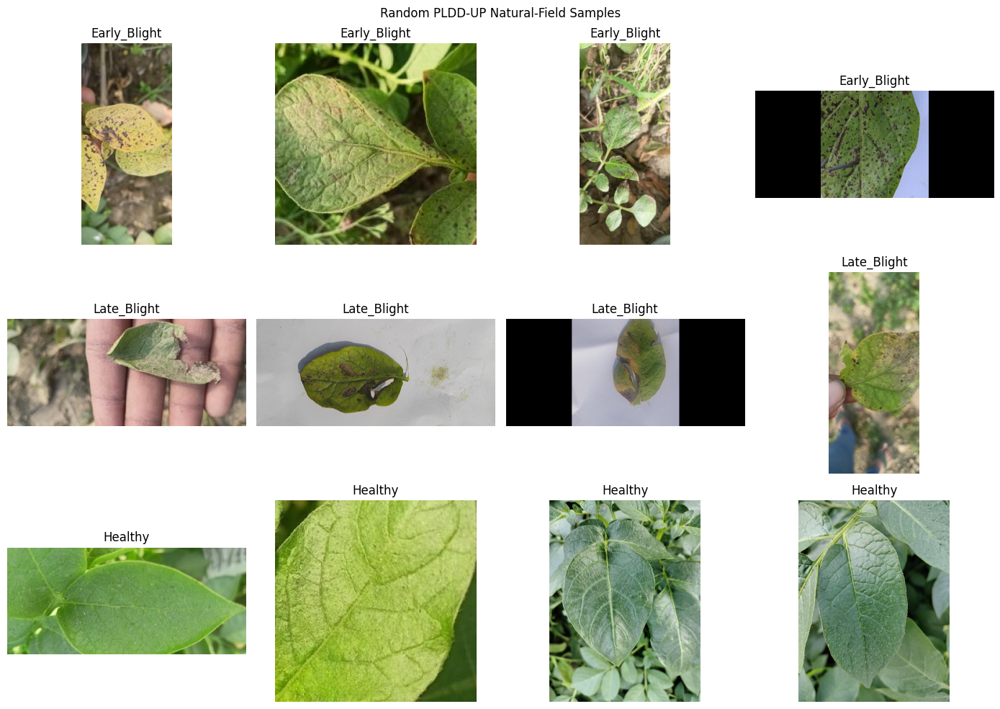

In [10]:
# Resolution summary and random samples
readable_df = verification_df[verification_df['is_readable']].copy()

resolution_summary_df = (
    readable_df.groupby(['raw_folder_name', 'unified_label'])
    .agg(
        image_count=('file_path', 'count'),
        min_width=('width', 'min'),
        max_width=('width', 'max'),
        avg_width=('width', 'mean'),
        min_height=('height', 'min'),
        max_height=('height', 'max'),
        avg_height=('height', 'mean'),
    )
    .reset_index()
)

display(resolution_summary_df.round(2))

fig, axes = plt.subplots(3, 4, figsize=(14, 10))

for r, raw_name in enumerate(EXPECTED_FOLDERS):
    files = inventory_df.loc[inventory_df['raw_folder_name'] == raw_name, 'file_path'].tolist()
    samples = random.sample(files, min(4, len(files)))

    for c in range(4):
        axes[r, c].axis('off')
        if c < len(samples):
            with Image.open(samples[c]) as img:
                axes[r, c].imshow(img.convert('RGB'))
            axes[r, c].set_title(UNIFIED_LABELS[raw_name])

plt.suptitle('Random PLDD-UP Natural-Field Samples')
plt.tight_layout()
plt.show()


In [11]:
# Class mapping and dataset information
class_mapping_df = pd.DataFrame([
    ['PLDD-UP', 'Early_Blight', 'Early_Blight', 0, 'No', 'Yes', 'Potato___Early_blight'],
    ['PLDD-UP', 'Late_blight', 'Late_Blight', 1, 'No', 'Yes', 'Potato___Late_blight'],
    ['PLDD-UP', 'Healthy', 'Healthy', 2, 'No', 'Yes', 'Potato___healthy'],
], columns=[
    'source_dataset', 'original_label', 'unified_label', 'class_id',
    'include_in_training', 'include_in_external_test',
    'maps_to_plantvillage_label'
])

dataset_information_df = pd.DataFrame([{
    'dataset_name': 'PLDD-UP: Potato Leaf Disease Dataset from Uttar Pradesh, India',
    'source': 'https://data.mendeley.com/datasets/3j4nfkvp2n/1',
    'doi': '10.17632/3j4nfkvp2n.1',
    'version': '1',
    'published_date': '2026-04-21',
    'license': 'Verify from Mendeley dataset page before publication',
    'access_date': datetime.now().date().isoformat(),
    'purpose': 'External natural-field testing only',
    'expected_total_images': sum(EXPECTED_COUNTS.values()),
    'actual_total_images_found': len(inventory_df),
}])

display(class_mapping_df)
display(dataset_information_df.T)


,source_dataset,original_label,unified_label,class_id,include_in_training,include_in_external_test,maps_to_plantvillage_label
0,PLDD-UP,Early_Blight,Early_Blight,0,No,Yes,Potato___Early_blight
1,PLDD-UP,Late_blight,Late_Blight,1,No,Yes,Potato___Late_blight
2,PLDD-UP,Healthy,Healthy,2,No,Yes,Potato___healthy


,0
dataset_name,PLDD-UP: Potato Leaf Disease Dataset from Utta...
source,https://data.mendeley.com/datasets/3j4nfkvp2n/1
doi,10.17632/3j4nfkvp2n.1
version,1
published_date,2026-04-21
license,Verify from Mendeley dataset page before publi...
access_date,2026-08-06
purpose,External natural-field testing only
expected_total_images,15519
actual_total_images_found,15542


In [12]:
# Save all outputs directly to Google Drive
outputs = {
    'plddup_class_count.csv': class_count_df,
    'plddup_count_comparison.csv': comparison_df,
    'plddup_file_inventory.csv': inventory_df,
    'plddup_image_verification.csv': verification_df,
    'plddup_unreadable_images.csv': unreadable_df,
    'plddup_resolution_summary.csv': resolution_summary_df,
    'plddup_class_mapping.csv': class_mapping_df,
    'plddup_dataset_information.csv': dataset_information_df,
}

for name, df in outputs.items():
    path = METADATA_DIR / name
    df.to_csv(path, index=False)
    print('Saved:', path)

final_report = pd.DataFrame([
    {'check': 'All required PLDD-UP folders found', 'passed': bool(folder_df['folder_exists'].all())},
    {'check': 'At least one image found', 'passed': len(inventory_df) > 0},
    {'check': 'All images readable', 'passed': unreadable_df.empty},
    {'check': 'Counts match dataset-page values', 'passed': bool((comparison_df['status'] == 'MATCH').all())},
    {'check': 'Metadata files saved', 'passed': True},
])

display(final_report)

if final_report['passed'].all():
    print('✅ PLDD-UP verification completed successfully.')
    print('Next step: combine both datasets\' class mappings.')
else:
    print('⚠️ Verification completed with warnings. Check upload completeness or unreadable files.')


Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/02_data/metadata/plddup_class_count.csv
Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/02_data/metadata/plddup_count_comparison.csv
Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/02_data/metadata/plddup_file_inventory.csv
Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/02_data/metadata/plddup_image_verification.csv
Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/02_data/metadata/plddup_unreadable_images.csv
Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/02_data/metadata/plddup_resolution_summary.csv
Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/02_data/metadata/plddup_class_mapping.csv
Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/02_data/metadata/plddup_dataset_information.csv


,check,passed
0,All required PLDD-UP folders found,True
1,At least one image found,True
2,All images readable,True
3,Counts match dataset-page values,False
4,Metadata files saved,True


⚠️ Verification completed with warnings. Check upload completeness or unreadable files.


In [15]:
# কোন class-এ image count বেশি বা কম হয়েছে দেখো

display(comparison_df)

print("\nActual class counts:")

actual_counts = (
    inventory_df
    .groupby(["raw_folder_name", "unified_label"])
    .size()
    .reset_index(name="actual_count")
)

display(actual_counts)

,raw_folder_name,unified_label,expected_count,actual_count,difference,status
0,Early_Blight,Early_Blight,4803,4826,23,CHECK
1,Late_blight,Late_Blight,6116,6116,0,MATCH
2,Healthy,Healthy,4600,4600,0,MATCH



Actual class counts:


,raw_folder_name,unified_label,actual_count
0,Early_Blight,Early_Blight,4826
1,Healthy,Healthy,4600
2,Late_blight,Late_Blight,6116


In [16]:
from pathlib import Path
import pandas as pd

# Project folder runtime-এ না থাকলে খুঁজে নেবে
if "PROJECT_ROOT" not in globals():
    PROJECT_ROOT = Path(
        "/content/drive/MyDrive/Potato_CNN_ViT_Research"
    )

METADATA_DIR = PROJECT_ROOT / "02_data" / "metadata"

plant_mapping_path = (
    METADATA_DIR / "plantvillage_class_mapping.csv"
)

plddup_mapping_path = (
    METADATA_DIR / "plddup_class_mapping.csv"
)

# প্রয়োজনীয় file আছে কি না পরীক্ষা
if not plant_mapping_path.exists():
    raise FileNotFoundError(
        f"PlantVillage mapping পাওয়া যায়নি: {plant_mapping_path}"
    )

if not plddup_mapping_path.exists():
    raise FileNotFoundError(
        f"PLDD-UP mapping পাওয়া যায়নি: {plddup_mapping_path}"
    )

# দুইটি mapping পড়া
plant_mapping = pd.read_csv(plant_mapping_path)
plddup_mapping = pd.read_csv(plddup_mapping_path)

# শুধু common প্রয়োজনীয় column রাখা
required_columns = [
    "source_dataset",
    "original_label",
    "unified_label",
    "class_id",
    "include_in_training",
    "include_in_external_test",
]

plant_final = plant_mapping[required_columns].copy()
plddup_final = plddup_mapping[required_columns].copy()

# একত্র করা
final_mapping = pd.concat(
    [plant_final, plddup_final],
    ignore_index=True
)

# Class ID অনুযায়ী সাজানো
final_mapping = final_mapping.sort_values(
    ["class_id", "source_dataset"]
).reset_index(drop=True)

# Save
final_mapping_path = (
    METADATA_DIR / "class_mapping_final.csv"
)

final_mapping.to_csv(
    final_mapping_path,
    index=False
)

display(final_mapping)

print("✅ Final mapping saved:")
print(final_mapping_path)

,source_dataset,original_label,unified_label,class_id,include_in_training,include_in_external_test
0,PLDD-UP,Early_Blight,Early_Blight,0,No,Yes
1,PlantVillage,Potato___Early_blight,Early_Blight,0,Yes,Yes
2,PLDD-UP,Late_blight,Late_Blight,1,No,Yes
3,PlantVillage,Potato___Late_blight,Late_Blight,1,Yes,Yes
4,PLDD-UP,Healthy,Healthy,2,No,Yes
5,PlantVillage,Potato___healthy,Healthy,2,Yes,Yes


✅ Final mapping saved:
/content/drive/MyDrive/Potato_CNN_ViT_Research/02_data/metadata/class_mapping_final.csv


In [17]:
import pandas as pd

final_mapping_path = (
    PROJECT_ROOT
    / "02_data"
    / "metadata"
    / "class_mapping_final.csv"
)

final_mapping = pd.read_csv(final_mapping_path)

# সঠিক dataset usage
final_mapping.loc[
    final_mapping["source_dataset"] == "PlantVillage",
    "include_in_training"
] = "Yes"

final_mapping.loc[
    final_mapping["source_dataset"] == "PlantVillage",
    "include_in_external_test"
] = "No"

final_mapping.loc[
    final_mapping["source_dataset"] == "PLDD-UP",
    "include_in_training"
] = "No"

final_mapping.loc[
    final_mapping["source_dataset"] == "PLDD-UP",
    "include_in_external_test"
] = "Yes"

final_mapping.to_csv(final_mapping_path, index=False)

display(final_mapping)

print("✅ Corrected final mapping saved:")
print(final_mapping_path)

,source_dataset,original_label,unified_label,class_id,include_in_training,include_in_external_test
0,PLDD-UP,Early_Blight,Early_Blight,0,No,Yes
1,PlantVillage,Potato___Early_blight,Early_Blight,0,Yes,No
2,PLDD-UP,Late_blight,Late_Blight,1,No,Yes
3,PlantVillage,Potato___Late_blight,Late_Blight,1,Yes,No
4,PLDD-UP,Healthy,Healthy,2,No,Yes
5,PlantVillage,Potato___healthy,Healthy,2,Yes,No


✅ Corrected final mapping saved:
/content/drive/MyDrive/Potato_CNN_ViT_Research/02_data/metadata/class_mapping_final.csv


---

# Part 03 — 03. Dataset Cleaning and Duplicate Audit

**Purpose:** Audit both datasets for corrupted files, exact duplicates, cross-dataset leakage, and near-duplicate groups while preserving the raw images.

**Source notebook:** `03_Dataset_Cleaning.ipynb`

**Preservation note:** The original code cells and their saved execution outputs are retained below. Textual headings/comments are lightly normalized into English where possible without changing experiment logic.


# 03 — Dataset Cleaning and Duplicate Audit

This notebook দুইটি dataset-এর cleaning audit করবে:

- **PlantVillage Potato** — Training, Validation, Internal Test
- **PLDD-UP** — External Field Test only

## Important rules

- Raw images **will not be deleted, renamed, resized, or overwritten**।
- Corrupted/unreadable image cleaned manifest থেকে বাদ যাবে।
- Exact duplicate একই class-এ থাকলে একটি রাখা হবে, বাকিগুলো manifest থেকে বাদ যাবে।
- PlantVillage ও PLDD-UP-এর মধ্যে exact duplicate থাকলে PLDD-UP copy external test থেকে বাদ যাবে, যাতে data leakage না হয়।
- Near-duplicate image এখনই delete হবে না; group ID তৈরি হবে, যাতে পরে group-aware split করা যায়।
- Storage বাঁচাতে defaultভাবে image copy করা হবে না। `cleaned_manifest_*.csv`-ই cleaned dataset-এর তালিকা হিসেবে ব্যবহার হবে।


In [1]:
# Cell 1: Mount Google Drive and install ImageHash
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

!pip -q install ImageHash


Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 5.2 MB/s eta 0:00:00


In [2]:
# Cell 2: Imports and settings
from pathlib import Path
from datetime import datetime
from concurrent.futures import ThreadPoolExecutor, as_completed
from collections import defaultdict
import hashlib
import json
import random
import shutil

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageFile
import imagehash

ImageFile.LOAD_TRUNCATED_IMAGES = False

RANDOM_SEED = 42
random.seed(RANDOM_SEED)

MAX_WORKERS = 8
PHASH_DISTANCE_THRESHOLD = 4
SAVE_PROGRESS_EVERY = 1000
MAX_NEAR_PAIRS = 200000

PLANT_EXPECTED_CLASSES = {
    'Potato___Early_blight': ('Early_Blight', 0),
    'Potato___Late_blight': ('Late_Blight', 1),
    'Potato___healthy': ('Healthy', 2),
}

PLDDUP_EXPECTED_CLASSES = {
    'Early_Blight': ('Early_Blight', 0),
    'Late_blight': ('Late_Blight', 1),
    'Healthy': ('Healthy', 2),
}

PLDDUP_PAGE_COUNTS = {
    'Early_Blight': 4803,
    'Late_Blight': 6116,
    'Healthy': 4600,
}

print('Settings loaded.')


Settings loaded.


In [3]:
# Cell 3: Automatically locate the project folders
MY_DRIVE = Path('/content/drive/MyDrive')

def valid_plant_folder(folder: Path) -> bool:
    return (
        folder.is_dir()
        and all((folder / name).is_dir() for name in PLANT_EXPECTED_CLASSES)
    )

def valid_plddup_folder(folder: Path) -> bool:
    return (
        folder.is_dir()
        and all((folder / name).is_dir() for name in PLDDUP_EXPECTED_CLASSES)
    )

plant_standard = (
    MY_DRIVE / 'Potato_CNN_ViT_Research'
    / '02_data' / 'raw' / 'plantvillage'
)
plddup_standard = (
    MY_DRIVE / 'Potato_CNN_ViT_Research'
    / '02_data' / 'raw' / 'pldd_up'
)

plant_matches = [plant_standard] if valid_plant_folder(plant_standard) else []
plddup_matches = [plddup_standard] if valid_plddup_folder(plddup_standard) else []

if not plant_matches:
    plant_matches = [
        p for p in MY_DRIVE.rglob('plantvillage')
        if valid_plant_folder(p)
    ]

if not plddup_matches:
    plddup_matches = [
        p for p in MY_DRIVE.rglob('pldd_up')
        if valid_plddup_folder(p)
    ]

if not plant_matches:
    raise FileNotFoundError('Valid PlantVillage folder পাওয়া যায়নি।')
if not plddup_matches:
    raise FileNotFoundError('Valid PLDD-UP folder পাওয়া যায়নি।')

PLANT_DIR = plant_matches[0]
PLDDUP_DIR = plddup_matches[0]

PROJECT_ROOT = PLANT_DIR.parents[2]

if PROJECT_ROOT != PLDDUP_DIR.parents[2]:
    raise RuntimeError(
        'PlantVillage এবং PLDD-UP একই project root-এর মধ্যে নেই।'
    )

DATA_DIR = PROJECT_ROOT / '02_data'
METADATA_DIR = DATA_DIR / 'metadata'
CLEANED_DIR = DATA_DIR / 'cleaned'
CLEANED_DIR.mkdir(parents=True, exist_ok=True)
METADATA_DIR.mkdir(parents=True, exist_ok=True)

print('PROJECT_ROOT:', PROJECT_ROOT)
print('PLANT_DIR:', PLANT_DIR)
print('PLDDUP_DIR:', PLDDUP_DIR)
print('METADATA_DIR:', METADATA_DIR)
print('CLEANED_DIR:', CLEANED_DIR)


PROJECT_ROOT: /content/drive/MyDrive/Potato_CNN_ViT_Research
PLANT_DIR: /content/drive/MyDrive/Potato_CNN_ViT_Research/02_data/raw/plantvillage
PLDDUP_DIR: /content/drive/MyDrive/Potato_CNN_ViT_Research/02_data/raw/pldd_up
METADATA_DIR: /content/drive/MyDrive/Potato_CNN_ViT_Research/02_data/metadata
CLEANED_DIR: /content/drive/MyDrive/Potato_CNN_ViT_Research/02_data/cleaned


In [4]:
# Cell 4: Load and normalize existing verification inventories
plant_inventory_path = METADATA_DIR / 'plantvillage_file_inventory.csv'
plddup_inventory_path = METADATA_DIR / 'plddup_file_inventory.csv'

if not plant_inventory_path.exists():
    raise FileNotFoundError(
        f'PlantVillage inventory পাওয়া যায়নি: {plant_inventory_path}'
    )

if not plddup_inventory_path.exists():
    raise FileNotFoundError(
        f'PLDD-UP inventory পাওয়া যায়নি: {plddup_inventory_path}'
    )

plant_df = pd.read_csv(plant_inventory_path)
plddup_df = pd.read_csv(plddup_inventory_path)

# PlantVillage inventory uses:
# original_class + unified_class
plant_df = plant_df.rename(
    columns={
        'original_class': 'raw_label',
    }
)

# PLDD-UP inventory uses:
# raw_folder_name + unified_label
plddup_df = plddup_df.rename(
    columns={
        'raw_folder_name': 'raw_label',
        'unified_label': 'unified_class',
    }
)

plant_df['source_dataset'] = 'PlantVillage'
plddup_df['source_dataset'] = 'PLDD-UP'

class_id_map = {
    'Early_Blight': 0,
    'Late_Blight': 1,
    'Healthy': 2,
}

for frame_name, frame in [
    ('PlantVillage', plant_df),
    ('PLDD-UP', plddup_df),
]:
    required_columns = {
        'source_dataset',
        'raw_label',
        'unified_class',
        'file_name',
        'file_path',
        'extension',
        'file_size_bytes',
    }

    missing_columns = required_columns - set(frame.columns)

    if missing_columns:
        raise KeyError(
            f'{frame_name} inventory-তে column missing: '
            f'{sorted(missing_columns)}'
        )

    if 'class_id' not in frame.columns:
        frame['class_id'] = frame['unified_class'].map(class_id_map)

    frame['class_id'] = frame['class_id'].fillna(
        frame['unified_class'].map(class_id_map)
    )

all_inventory_df = pd.concat(
    [
        plant_df[
            [
                'source_dataset',
                'raw_label',
                'unified_class',
                'class_id',
                'file_name',
                'file_path',
                'extension',
                'file_size_bytes',
            ]
        ],
        plddup_df[
            [
                'source_dataset',
                'raw_label',
                'unified_class',
                'class_id',
                'file_name',
                'file_path',
                'extension',
                'file_size_bytes',
            ]
        ],
    ],
    ignore_index=True,
)

all_inventory_df['file_exists'] = (
    all_inventory_df['file_path']
    .astype(str)
    .map(lambda value: Path(value).exists())
)

display(
    all_inventory_df
    .groupby(
        [
            'source_dataset',
            'raw_label',
            'unified_class',
        ]
    )
    .size()
    .reset_index(name='image_count')
)

print('Total inventory records:', len(all_inventory_df))
print('Missing files:', int((~all_inventory_df['file_exists']).sum()))


,source_dataset,raw_label,unified_class,image_count
0,PLDD-UP,Early_Blight,Early_Blight,4826
1,PLDD-UP,Healthy,Healthy,4600
2,PLDD-UP,Late_blight,Late_Blight,6116
3,PlantVillage,Potato___Early_blight,Early_Blight,1000
4,PlantVillage,Potato___Late_blight,Late_Blight,1000
5,PlantVillage,Potato___healthy,Healthy,152


Total inventory records: 17694
Missing files: 0


In [5]:
# Cell 5: Load unreadable-image reports from verification notebooks
plant_unreadable_path = METADATA_DIR / 'plantvillage_unreadable_images.csv'
plddup_unreadable_path = METADATA_DIR / 'plddup_unreadable_images.csv'

unreadable_paths = set()

for report_path in [plant_unreadable_path, plddup_unreadable_path]:
    if report_path.exists():
        report_df = pd.read_csv(report_path)
        if 'file_path' in report_df.columns:
            unreadable_paths.update(
                report_df['file_path'].dropna().astype(str).tolist()
            )

all_inventory_df['reported_unreadable'] = (
    all_inventory_df['file_path'].isin(unreadable_paths)
)

print('Reported unreadable images:', len(unreadable_paths))


Reported unreadable images: 0


In [6]:
# Cell 6: Compute SHA-256 and perceptual hash (resume supported)
HASH_CACHE_PATH = METADATA_DIR / 'image_hashes.csv'

def hash_one_image(row):
    path = Path(row.file_path)

    result = {
        'file_path': str(path),
        'source_dataset': row.source_dataset,
        'raw_label': row.raw_label,
        'unified_class': row.unified_class,
        'class_id': row.class_id,
        'file_size_bytes': row.file_size_bytes,
        'sha256': None,
        'phash': None,
        'hash_success': False,
        'hash_error': '',
    }

    try:
        sha = hashlib.sha256()
        with path.open('rb') as file_handle:
            for chunk in iter(lambda: file_handle.read(1024 * 1024), b''):
                sha.update(chunk)
        result['sha256'] = sha.hexdigest()

        with Image.open(path) as image:
            result['phash'] = str(
                imagehash.phash(image.convert('RGB'))
            )

        result['hash_success'] = True

    except Exception as exc:
        result['hash_error'] = str(exc)

    return result


if HASH_CACHE_PATH.exists():
    hash_df = pd.read_csv(HASH_CACHE_PATH)
    completed_paths = set(
        hash_df.loc[hash_df['hash_success'] == True, 'file_path']
        .astype(str)
        .tolist()
    )
    print('Loaded cached hashes:', len(completed_paths))
else:
    hash_df = pd.DataFrame()
    completed_paths = set()
    print('No previous hash cache found.')

rows_to_hash = [
    row
    for row in all_inventory_df.itertuples(index=False)
    if (
        row.file_exists
        and not row.reported_unreadable
        and row.file_path not in completed_paths
    )
]

print('Images remaining to hash:', len(rows_to_hash))

new_hash_rows = []

if rows_to_hash:
    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
        futures = [
            executor.submit(hash_one_image, row)
            for row in rows_to_hash
        ]

        for index, future in enumerate(
            as_completed(futures),
            start=1,
        ):
            new_hash_rows.append(future.result())

            if index % SAVE_PROGRESS_EVERY == 0:
                temp_df = pd.concat(
                    [hash_df, pd.DataFrame(new_hash_rows)],
                    ignore_index=True,
                )
                temp_df = temp_df.drop_duplicates(
                    subset=['file_path'],
                    keep='last',
                )
                temp_df.to_csv(HASH_CACHE_PATH, index=False)
                print(
                    f'Hashed {index}/{len(rows_to_hash)} new images; '
                    'progress saved.'
                )

    hash_df = pd.concat(
        [hash_df, pd.DataFrame(new_hash_rows)],
        ignore_index=True,
    )
    hash_df = hash_df.drop_duplicates(
        subset=['file_path'],
        keep='last',
    )
    hash_df.to_csv(HASH_CACHE_PATH, index=False)

print('Total hash records:', len(hash_df))
print('Hash failures:', int((hash_df['hash_success'] != True).sum()))
print('Saved:', HASH_CACHE_PATH)


No previous hash cache found.
Images remaining to hash: 17694
Hashed 1000/17694 new images; progress saved.
Hashed 2000/17694 new images; progress saved.
Hashed 3000/17694 new images; progress saved.
Hashed 4000/17694 new images; progress saved.
Hashed 5000/17694 new images; progress saved.
Hashed 6000/17694 new images; progress saved.
Hashed 7000/17694 new images; progress saved.
Hashed 8000/17694 new images; progress saved.
Hashed 9000/17694 new images; progress saved.
Hashed 10000/17694 new images; progress saved.
Hashed 11000/17694 new images; progress saved.
Hashed 12000/17694 new images; progress saved.
Hashed 13000/17694 new images; progress saved.
Hashed 14000/17694 new images; progress saved.
Hashed 15000/17694 new images; progress saved.
Hashed 16000/17694 new images; progress saved.
Hashed 17000/17694 new images; progress saved.
Total hash records: 17694
Hash failures: 0
Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/02_data/metadata/image_hashes.csv


In [7]:
# Cell 7: Exact duplicate detection and decisions
valid_hash_df = hash_df[
    (hash_df['hash_success'] == True)
    & hash_df['sha256'].notna()
].copy()

duplicate_hashes = (
    valid_hash_df.groupby('sha256')
    .size()
    .loc[lambda series: series > 1]
    .index
)

exact_duplicates_df = valid_hash_df[
    valid_hash_df['sha256'].isin(duplicate_hashes)
].copy()

if not exact_duplicates_df.empty:
    group_map = {
        hash_value: f'EXACT_{index:05d}'
        for index, hash_value in enumerate(
            sorted(exact_duplicates_df['sha256'].unique()),
            start=1,
        )
    }
    exact_duplicates_df['exact_group_id'] = (
        exact_duplicates_df['sha256'].map(group_map)
    )
else:
    exact_duplicates_df['exact_group_id'] = pd.Series(dtype='object')

decision_rows = []

for sha_value, group in exact_duplicates_df.groupby('sha256'):
    group = group.sort_values(
        ['source_dataset', 'unified_class', 'file_path']
    ).reset_index(drop=True)

    labels = set(group['unified_class'])
    sources = set(group['source_dataset'])
    group_id = group['exact_group_id'].iloc[0]

    if len(labels) > 1:
        # Same bytes with different labels: never auto-delete.
        for row in group.itertuples(index=False):
            decision_rows.append({
                'file_path': row.file_path,
                'exact_group_id': group_id,
                'action': 'manual_review',
                'reason': 'Exact same bytes appear under different labels',
                'keep_path': '',
            })
        continue

    if sources == {'PlantVillage', 'PLDD-UP'}:
        # Keep PlantVillage copy; exclude PLDD-UP duplicate from external test.
        plant_group = group[group['source_dataset'] == 'PlantVillage']
        keep_path = plant_group.iloc[0]['file_path']

        for row in group.itertuples(index=False):
            if row.source_dataset == 'PlantVillage':
                action = 'keep'
                reason = 'Training-source copy retained'
            else:
                action = 'exclude_exact_duplicate'
                reason = 'Cross-source exact duplicate; prevents external-test leakage'

            decision_rows.append({
                'file_path': row.file_path,
                'exact_group_id': group_id,
                'action': action,
                'reason': reason,
                'keep_path': keep_path,
            })
        continue

    # Same source and same label: keep the first path only.
    keep_path = group.iloc[0]['file_path']

    for position, row in enumerate(group.itertuples(index=False)):
        decision_rows.append({
            'file_path': row.file_path,
            'exact_group_id': group_id,
            'action': 'keep' if position == 0 else 'exclude_exact_duplicate',
            'reason': (
                'First path retained within exact-duplicate group'
                if position == 0
                else 'Repeated exact duplicate within same source and label'
            ),
            'keep_path': keep_path,
        })

exact_decisions_df = pd.DataFrame(decision_rows)

EXACT_DUPLICATES_PATH = METADATA_DIR / 'exact_duplicates.csv'
EXACT_DECISIONS_PATH = METADATA_DIR / 'exact_duplicate_decisions.csv'

exact_duplicates_df.to_csv(EXACT_DUPLICATES_PATH, index=False)
exact_decisions_df.to_csv(EXACT_DECISIONS_PATH, index=False)

print('Exact duplicate images:', len(exact_duplicates_df))
print('Exact duplicate groups:', exact_duplicates_df['exact_group_id'].nunique())
if not exact_decisions_df.empty:
    display(exact_decisions_df['action'].value_counts().reset_index())
print('Saved:', EXACT_DUPLICATES_PATH)
print('Saved:', EXACT_DECISIONS_PATH)


Exact duplicate images: 502
Exact duplicate groups: 225


,action,count
0,exclude_exact_duplicate,272
1,keep,220
2,manual_review,10


Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/02_data/metadata/exact_duplicates.csv
Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/02_data/metadata/exact_duplicate_decisions.csv


In [8]:
# Cell 8: Cross-source exact duplicate report
if exact_duplicates_df.empty:
    cross_source_exact_df = pd.DataFrame()
else:
    cross_source_group_ids = (
        exact_duplicates_df.groupby('exact_group_id')['source_dataset']
        .nunique()
        .loc[lambda series: series > 1]
        .index
    )
    cross_source_exact_df = exact_duplicates_df[
        exact_duplicates_df['exact_group_id'].isin(cross_source_group_ids)
    ].copy()

CROSS_SOURCE_PATH = METADATA_DIR / 'cross_source_exact_duplicates.csv'
cross_source_exact_df.to_csv(CROSS_SOURCE_PATH, index=False)

print('Cross-source exact duplicate images:', len(cross_source_exact_df))
print('Saved:', CROSS_SOURCE_PATH)


Cross-source exact duplicate images: 0
Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/02_data/metadata/cross_source_exact_duplicates.csv


In [9]:
# Cell 9: Near-duplicate detection using perceptual hashes
# Near duplicates are reported and grouped, not deleted automatically.

class BKNode:
    def __init__(self, value, row_index):
        self.value = value
        self.row_indices = [row_index]
        self.children = {}


class BKTree:
    def __init__(self):
        self.root = None

    @staticmethod
    def distance(a, b):
        return (a ^ b).bit_count()

    def add(self, value, row_index):
        if self.root is None:
            self.root = BKNode(value, row_index)
            return

        node = self.root

        while True:
            distance = self.distance(value, node.value)

            if distance == 0:
                node.row_indices.append(row_index)
                return

            if distance not in node.children:
                node.children[distance] = BKNode(value, row_index)
                return

            node = node.children[distance]

    def query(self, value, threshold):
        if self.root is None:
            return []

        matches = []
        stack = [self.root]

        while stack:
            node = stack.pop()
            distance = self.distance(value, node.value)

            if distance <= threshold:
                matches.extend(
                    (row_index, distance)
                    for row_index in node.row_indices
                )

            lower = distance - threshold
            upper = distance + threshold

            for edge_distance, child in node.children.items():
                if lower <= edge_distance <= upper:
                    stack.append(child)

        return matches


near_pair_rows = []

for unified_class, class_group in valid_hash_df.groupby('unified_class'):
    class_group = class_group.sort_values('file_path').reset_index(drop=True)
    tree = BKTree()

    for row_index, row in class_group.iterrows():
        phash_int = int(str(row['phash']), 16)

        matches = tree.query(
            phash_int,
            PHASH_DISTANCE_THRESHOLD,
        )

        for previous_index, distance in matches:
            previous = class_group.iloc[previous_index]

            # Exact byte duplicates are already handled separately.
            if previous['sha256'] == row['sha256']:
                continue

            near_pair_rows.append({
                'unified_class': unified_class,
                'file_path_a': previous['file_path'],
                'source_dataset_a': previous['source_dataset'],
                'file_path_b': row['file_path'],
                'source_dataset_b': row['source_dataset'],
                'phash_a': previous['phash'],
                'phash_b': row['phash'],
                'hamming_distance': distance,
                'cross_source': (
                    previous['source_dataset']
                    != row['source_dataset']
                ),
            })

            if len(near_pair_rows) >= MAX_NEAR_PAIRS:
                print(
                    'Near-pair limit reached. '
                    'Increase MAX_NEAR_PAIRS only if needed.'
                )
                break

        tree.add(phash_int, row_index)

        if len(near_pair_rows) >= MAX_NEAR_PAIRS:
            break

    if len(near_pair_rows) >= MAX_NEAR_PAIRS:
        break

near_pairs_df = pd.DataFrame(near_pair_rows)

NEAR_PAIRS_PATH = METADATA_DIR / 'near_duplicate_pairs.csv'
near_pairs_df.to_csv(NEAR_PAIRS_PATH, index=False)

print('Near-duplicate pairs found:', len(near_pairs_df))
if not near_pairs_df.empty:
    display(
        near_pairs_df['hamming_distance']
        .value_counts()
        .sort_index()
        .reset_index()
    )
print('Saved:', NEAR_PAIRS_PATH)


Near-duplicate pairs found: 3635


,hamming_distance,count
0,0,1644
1,2,927
2,4,1064


Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/02_data/metadata/near_duplicate_pairs.csv


In [10]:
# Cell 10: Build connected near-duplicate groups
class UnionFind:
    def __init__(self):
        self.parent = {}
        self.rank = {}

    def add(self, item):
        if item not in self.parent:
            self.parent[item] = item
            self.rank[item] = 0

    def find(self, item):
        self.add(item)
        if self.parent[item] != item:
            self.parent[item] = self.find(self.parent[item])
        return self.parent[item]

    def union(self, a, b):
        root_a = self.find(a)
        root_b = self.find(b)

        if root_a == root_b:
            return

        if self.rank[root_a] < self.rank[root_b]:
            root_a, root_b = root_b, root_a

        self.parent[root_b] = root_a

        if self.rank[root_a] == self.rank[root_b]:
            self.rank[root_a] += 1


union_find = UnionFind()

if not near_pairs_df.empty:
    for row in near_pairs_df.itertuples(index=False):
        union_find.union(row.file_path_a, row.file_path_b)

group_members = defaultdict(list)

for file_path in union_find.parent:
    group_members[union_find.find(file_path)].append(file_path)

near_group_rows = []
near_group_map = {}

for group_index, members in enumerate(
    sorted(group_members.values(), key=lambda items: items[0]),
    start=1,
):
    group_id = f'NEAR_{group_index:05d}'

    for file_path in sorted(members):
        near_group_map[file_path] = group_id
        near_group_rows.append({
            'near_duplicate_group_id': group_id,
            'file_path': file_path,
            'group_size': len(members),
        })

near_groups_df = pd.DataFrame(near_group_rows)

NEAR_GROUPS_PATH = METADATA_DIR / 'near_duplicate_groups.csv'
near_groups_df.to_csv(NEAR_GROUPS_PATH, index=False)

print('Near-duplicate groups:', near_groups_df['near_duplicate_group_id'].nunique() if not near_groups_df.empty else 0)
print('Images in near-duplicate groups:', len(near_groups_df))
print('Saved:', NEAR_GROUPS_PATH)


Near-duplicate groups: 2308
Images in near-duplicate groups: 5203
Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/02_data/metadata/near_duplicate_groups.csv


In [11]:
# Cell 11: Build storage-efficient cleaned manifests
manifest_df = all_inventory_df.copy()

manifest_df['exclude_from_cleaned_manifest'] = False
manifest_df['cleaning_reason'] = ''
manifest_df['exact_group_id'] = ''
manifest_df['near_duplicate_group_id'] = (
    manifest_df['file_path'].map(near_group_map).fillna('')
)

# Missing files
missing_mask = ~manifest_df['file_exists']
manifest_df.loc[missing_mask, 'exclude_from_cleaned_manifest'] = True
manifest_df.loc[missing_mask, 'cleaning_reason'] = 'Missing file'

# Unreadable files
unreadable_mask = manifest_df['reported_unreadable']
manifest_df.loc[unreadable_mask, 'exclude_from_cleaned_manifest'] = True
manifest_df.loc[unreadable_mask, 'cleaning_reason'] = 'Unreadable/corrupted file'

# Hash failures
hash_failure_paths = set(
    hash_df.loc[hash_df['hash_success'] != True, 'file_path']
    .astype(str)
    .tolist()
)
hash_failure_mask = manifest_df['file_path'].isin(hash_failure_paths)
manifest_df.loc[hash_failure_mask, 'exclude_from_cleaned_manifest'] = True
manifest_df.loc[hash_failure_mask, 'cleaning_reason'] = 'Hash/read failure'

# Exact duplicate exclusions
if not exact_decisions_df.empty:
    decision_map = exact_decisions_df.set_index('file_path')['action'].to_dict()
    reason_map = exact_decisions_df.set_index('file_path')['reason'].to_dict()
    exact_group_map = exact_decisions_df.set_index('file_path')['exact_group_id'].to_dict()

    manifest_df['exact_group_id'] = (
        manifest_df['file_path'].map(exact_group_map).fillna('')
    )

    exclude_exact_mask = (
        manifest_df['file_path'].map(decision_map)
        == 'exclude_exact_duplicate'
    )

    manifest_df.loc[
        exclude_exact_mask,
        'exclude_from_cleaned_manifest'
    ] = True

    manifest_df.loc[
        exclude_exact_mask,
        'cleaning_reason'
    ] = manifest_df.loc[
        exclude_exact_mask,
        'file_path'
    ].map(reason_map)

    manual_review_mask = (
        manifest_df['file_path'].map(decision_map)
        == 'manual_review'
    )
    manifest_df.loc[
        manual_review_mask,
        'cleaning_reason'
    ] = 'Manual review required: exact bytes have conflicting labels'

manifest_df['include_in_cleaned_manifest'] = (
    ~manifest_df['exclude_from_cleaned_manifest']
)

plant_clean_manifest_df = manifest_df[
    (manifest_df['source_dataset'] == 'PlantVillage')
    & manifest_df['include_in_cleaned_manifest']
].copy()

plddup_clean_manifest_df = manifest_df[
    (manifest_df['source_dataset'] == 'PLDD-UP')
    & manifest_df['include_in_cleaned_manifest']
].copy()

ALL_MANIFEST_PATH = METADATA_DIR / 'cleaned_manifest_all.csv'
PLANT_MANIFEST_PATH = METADATA_DIR / 'cleaned_manifest_plantvillage.csv'
PLDDUP_MANIFEST_PATH = METADATA_DIR / 'cleaned_manifest_plddup.csv'
CLEANING_LOG_PATH = METADATA_DIR / 'cleaning_log.csv'

manifest_df.to_csv(ALL_MANIFEST_PATH, index=False)
plant_clean_manifest_df.to_csv(PLANT_MANIFEST_PATH, index=False)
plddup_clean_manifest_df.to_csv(PLDDUP_MANIFEST_PATH, index=False)

cleaning_log_df = manifest_df[
    (
        manifest_df['exclude_from_cleaned_manifest']
        | manifest_df['cleaning_reason'].astype(str).str.len().gt(0)
    )
].copy()
cleaning_log_df.to_csv(CLEANING_LOG_PATH, index=False)

print('PlantVillage cleaned manifest:', len(plant_clean_manifest_df))
print('PLDD-UP cleaned manifest:', len(plddup_clean_manifest_df))
print('Excluded records:', int(manifest_df['exclude_from_cleaned_manifest'].sum()))
print('Saved:', PLANT_MANIFEST_PATH)
print('Saved:', PLDDUP_MANIFEST_PATH)
print('Saved:', CLEANING_LOG_PATH)


PlantVillage cleaned manifest: 2152
PLDD-UP cleaned manifest: 15270
Excluded records: 272
Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/02_data/metadata/cleaned_manifest_plantvillage.csv
Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/02_data/metadata/cleaned_manifest_plddup.csv
Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/02_data/metadata/cleaning_log.csv


In [12]:
# Cell 12: Create cleaned folder structure without copying images
# Training notebooks will read image paths from cleaned manifests.

for dataset_folder, raw_mapping in [
    (
        CLEANED_DIR / 'plantvillage',
        {
            'Early_Blight': 'Early_Blight',
            'Late_Blight': 'Late_Blight',
            'Healthy': 'Healthy',
        },
    ),
    (
        CLEANED_DIR / 'pldd_up',
        {
            'Early_Blight': 'Early_Blight',
            'Late_Blight': 'Late_Blight',
            'Healthy': 'Healthy',
        },
    ),
]:
    for folder_name in raw_mapping.values():
        (dataset_folder / folder_name).mkdir(
            parents=True,
            exist_ok=True,
        )

print('Cleaned folder structure created:')
print(CLEANED_DIR)
print(
    'Images were not copied because manifest-based cleaning '
    'saves Google Drive storage.'
)


Cleaned folder structure created:
/content/drive/MyDrive/Potato_CNN_ViT_Research/02_data/cleaned
Images were not copied because manifest-based cleaning saves Google Drive storage.


In [13]:
# Cell 13: Optional physical copy — OFF by default
# WARNING: Copying PLDD-UP will require several extra GB in Google Drive.

MATERIALIZE_PLANTVILLAGE = False
MATERIALIZE_PLDDUP = False

def copy_manifest_images(
    manifest,
    destination_root,
):
    copied = 0

    for row in manifest.itertuples(index=False):
        source_path = Path(row.file_path)
        destination_dir = destination_root / row.unified_class
        destination_dir.mkdir(parents=True, exist_ok=True)

        destination_name = (
            f'{row.source_dataset.replace("-", "")}_'
            f'{copied:06d}_{source_path.name}'
        )
        destination_path = destination_dir / destination_name

        shutil.copy2(source_path, destination_path)
        copied += 1

        if copied % 500 == 0:
            print(f'Copied {copied} images...')

    return copied


if MATERIALIZE_PLANTVILLAGE:
    copied_count = copy_manifest_images(
        plant_clean_manifest_df,
        CLEANED_DIR / 'plantvillage',
    )
    print('PlantVillage copied:', copied_count)

if MATERIALIZE_PLDDUP:
    copied_count = copy_manifest_images(
        plddup_clean_manifest_df,
        CLEANED_DIR / 'pldd_up',
    )
    print('PLDD-UP copied:', copied_count)

if not MATERIALIZE_PLANTVILLAGE and not MATERIALIZE_PLDDUP:
    print(
        'No images copied. This is recommended for your limited Drive storage.'
    )


No images copied. This is recommended for your limited Drive storage.


In [14]:
# Cell 14: Cleaning summary and the PLDD-UP count mismatch
summary_rows = []

for dataset_name, source_df, clean_df in [
    ('PlantVillage', plant_df, plant_clean_manifest_df),
    ('PLDD-UP', plddup_df, plddup_clean_manifest_df),
]:
    for unified_class in ['Early_Blight', 'Late_Blight', 'Healthy']:
        original_count = int(
            (source_df['unified_class'] == unified_class).sum()
        )
        cleaned_count = int(
            (clean_df['unified_class'] == unified_class).sum()
        )

        summary_rows.append({
            'source_dataset': dataset_name,
            'unified_class': unified_class,
            'original_count': original_count,
            'cleaned_manifest_count': cleaned_count,
            'excluded_count': original_count - cleaned_count,
        })

cleaning_summary_df = pd.DataFrame(summary_rows)

CLEANING_SUMMARY_PATH = METADATA_DIR / 'cleaning_summary.csv'
cleaning_summary_df.to_csv(CLEANING_SUMMARY_PATH, index=False)

display(cleaning_summary_df)

plddup_raw_counts = (
    plddup_df.groupby('raw_label')
    .size()
    .to_dict()
)

mismatch_rows = []

for raw_label, expected_count in PLDDUP_PAGE_COUNTS.items():
    actual_count = int(plddup_raw_counts.get(raw_label, 0))

    mismatch_rows.append({
        'raw_label': raw_label,
        'dataset_page_count': expected_count,
        'downloaded_raw_count': actual_count,
        'raw_difference': actual_count - expected_count,
    })

plddup_mismatch_df = pd.DataFrame(mismatch_rows)

PLDDUP_MISMATCH_PATH = METADATA_DIR / 'plddup_count_mismatch_analysis.csv'
plddup_mismatch_df.to_csv(PLDDUP_MISMATCH_PATH, index=False)

print('\nPLDD-UP count mismatch:')
display(plddup_mismatch_df)

print('\nExact duplicate decisions:')
if exact_decisions_df.empty:
    print('No exact duplicate decisions.')
else:
    display(
        exact_decisions_df['action']
        .value_counts()
        .reset_index()
    )

print('Saved:', CLEANING_SUMMARY_PATH)
print('Saved:', PLDDUP_MISMATCH_PATH)


,source_dataset,unified_class,original_count,cleaned_manifest_count,excluded_count
0,PlantVillage,Early_Blight,1000,1000,0
1,PlantVillage,Late_Blight,1000,1000,0
2,PlantVillage,Healthy,152,152,0
3,PLDD-UP,Early_Blight,4826,4748,78
4,PLDD-UP,Late_Blight,6116,6069,47
5,PLDD-UP,Healthy,4600,4453,147



PLDD-UP count mismatch:


,raw_label,dataset_page_count,downloaded_raw_count,raw_difference
0,Early_Blight,4803,4826,23
1,Late_Blight,6116,0,-6116
2,Healthy,4600,4600,0



Exact duplicate decisions:


,action,count
0,exclude_exact_duplicate,272
1,keep,220
2,manual_review,10


Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/02_data/metadata/cleaning_summary.csv
Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/02_data/metadata/plddup_count_mismatch_analysis.csv


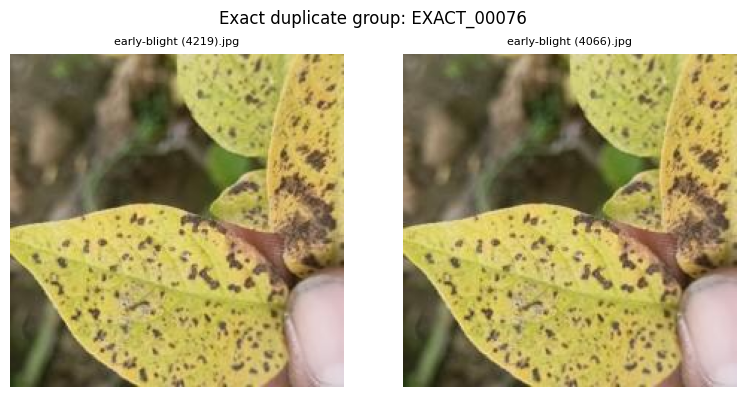

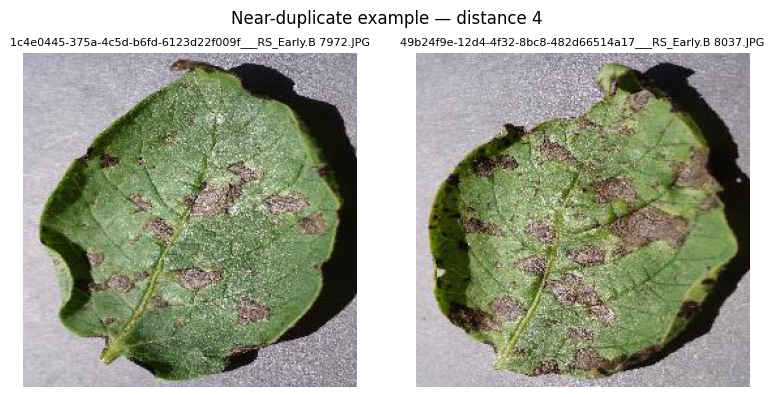

In [15]:
# Cell 15: Show a few duplicate examples for manual review
def show_paths(paths, title, max_images=6):
    paths = list(paths)[:max_images]

    if not paths:
        print(f'No images to show for: {title}')
        return

    fig, axes = plt.subplots(
        1,
        len(paths),
        figsize=(4 * len(paths), 4),
    )

    if len(paths) == 1:
        axes = [axes]

    for axis, file_path in zip(axes, paths):
        axis.axis('off')
        try:
            with Image.open(file_path) as image:
                axis.imshow(image.convert('RGB'))
            axis.set_title(Path(file_path).name, fontsize=8)
        except Exception as exc:
            axis.set_title(f'Open error: {exc}', fontsize=8)

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


if not exact_duplicates_df.empty:
    first_group = exact_duplicates_df['exact_group_id'].iloc[0]
    paths = exact_duplicates_df.loc[
        exact_duplicates_df['exact_group_id'] == first_group,
        'file_path'
    ].tolist()
    show_paths(paths, f'Exact duplicate group: {first_group}')

if not near_pairs_df.empty:
    first_pair = near_pairs_df.iloc[0]
    show_paths(
        [first_pair['file_path_a'], first_pair['file_path_b']],
        (
            'Near-duplicate example — '
            f'distance {first_pair["hamming_distance"]}'
        ),
        max_images=2,
    )


In [16]:
# Cell 16: Final cleaning report
manual_review_count = 0

if not exact_decisions_df.empty:
    manual_review_count = int(
        (exact_decisions_df['action'] == 'manual_review').sum()
    )

final_report_df = pd.DataFrame([
    {
        'check': 'Raw datasets remain untouched',
        'passed': True,
    },
    {
        'check': 'Image hashes completed',
        'passed': bool((hash_df['hash_success'] == True).all()),
    },
    {
        'check': 'Exact duplicate report saved',
        'passed': EXACT_DUPLICATES_PATH.exists(),
    },
    {
        'check': 'Near-duplicate report saved',
        'passed': NEAR_PAIRS_PATH.exists(),
    },
    {
        'check': 'Cleaned PlantVillage manifest saved',
        'passed': PLANT_MANIFEST_PATH.exists(),
    },
    {
        'check': 'Cleaned PLDD-UP manifest saved',
        'passed': PLDDUP_MANIFEST_PATH.exists(),
    },
    {
        'check': 'No conflicting-label exact duplicates',
        'passed': manual_review_count == 0,
    },
])

display(final_report_df)

if final_report_df['passed'].all():
    print('✅ Dataset cleaning audit completed successfully.')
    print('Next step: 04_Dataset_Splitting.ipynb')
else:
    print('⚠️ Cleaning audit completed with warnings.')
    print(
        'Conflicting-label duplicate থাকলে manual review করে '
        'cleaning_decision update করতে হবে।'
    )


,check,passed
0,Raw datasets remain untouched,True
1,Image hashes completed,True
2,Exact duplicate report saved,True
3,Near-duplicate report saved,True
4,Cleaned PlantVillage manifest saved,True
5,Cleaned PLDD-UP manifest saved,True
6,No conflicting-label exact duplicates,False


⚠️ Cleaning audit completed with warnings.
Conflicting-label duplicate থাকলে manual review করে cleaning_decision update করতে হবে।


Conflicting image records: 10
Conflicting groups: 5

Group ID: EXACT_00082


,source_dataset,raw_label,unified_class,file_path,sha256
2420,PLDD-UP,Early_Blight,Early_Blight,/content/drive/MyDrive/Potato_CNN_ViT_Research...,5750e5fd370343e938ec2272794bc53ca2ef15a958e7c0...
13955,PLDD-UP,Healthy,Healthy,/content/drive/MyDrive/Potato_CNN_ViT_Research...,5750e5fd370343e938ec2272794bc53ca2ef15a958e7c0...


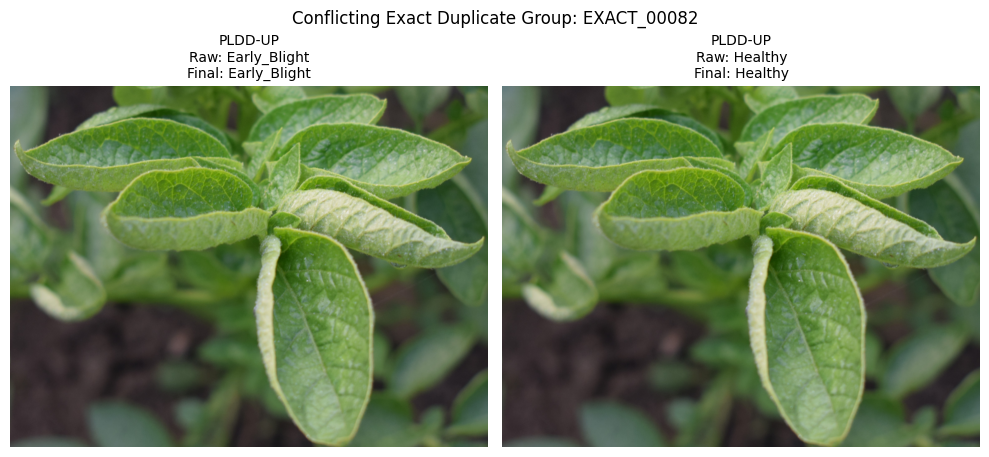


Group ID: EXACT_00109


,source_dataset,raw_label,unified_class,file_path,sha256
2189,PLDD-UP,Early_Blight,Early_Blight,/content/drive/MyDrive/Potato_CNN_ViT_Research...,76469905b91d8f1e46443e1c4ea305ac3124bd144b2afc...
16191,PLDD-UP,Healthy,Healthy,/content/drive/MyDrive/Potato_CNN_ViT_Research...,76469905b91d8f1e46443e1c4ea305ac3124bd144b2afc...


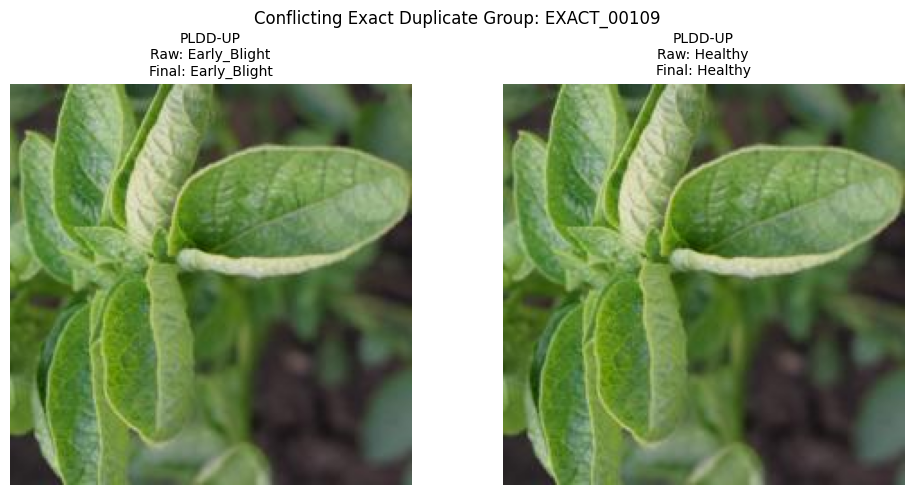


Group ID: EXACT_00116


,source_dataset,raw_label,unified_class,file_path,sha256
2153,PLDD-UP,Early_Blight,Early_Blight,/content/drive/MyDrive/Potato_CNN_ViT_Research...,836ed53ca232ec4c987e0d937018a58c68ac8cf762626d...
16202,PLDD-UP,Healthy,Healthy,/content/drive/MyDrive/Potato_CNN_ViT_Research...,836ed53ca232ec4c987e0d937018a58c68ac8cf762626d...


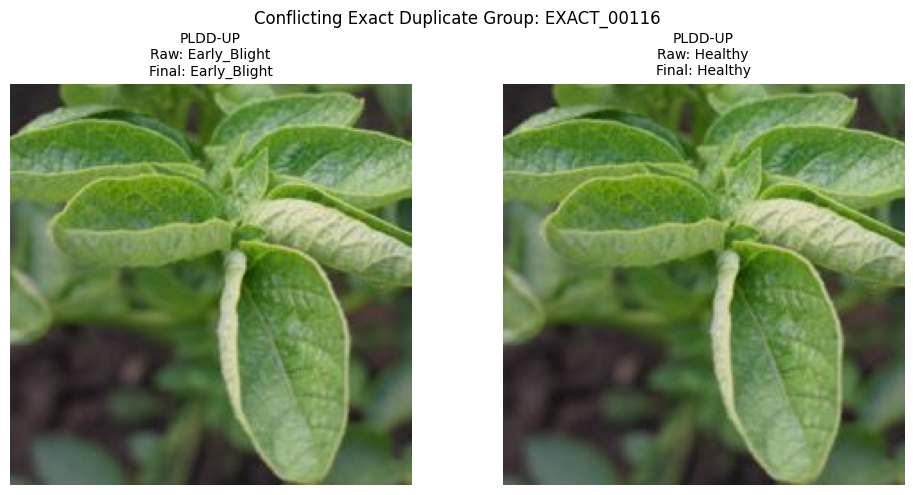


Group ID: EXACT_00131


,source_dataset,raw_label,unified_class,file_path,sha256
4129,PLDD-UP,Early_Blight,Early_Blight,/content/drive/MyDrive/Potato_CNN_ViT_Research...,9433da9e4da4efac37c71780320cb026d3e6ca93c6b8f6...
16130,PLDD-UP,Healthy,Healthy,/content/drive/MyDrive/Potato_CNN_ViT_Research...,9433da9e4da4efac37c71780320cb026d3e6ca93c6b8f6...


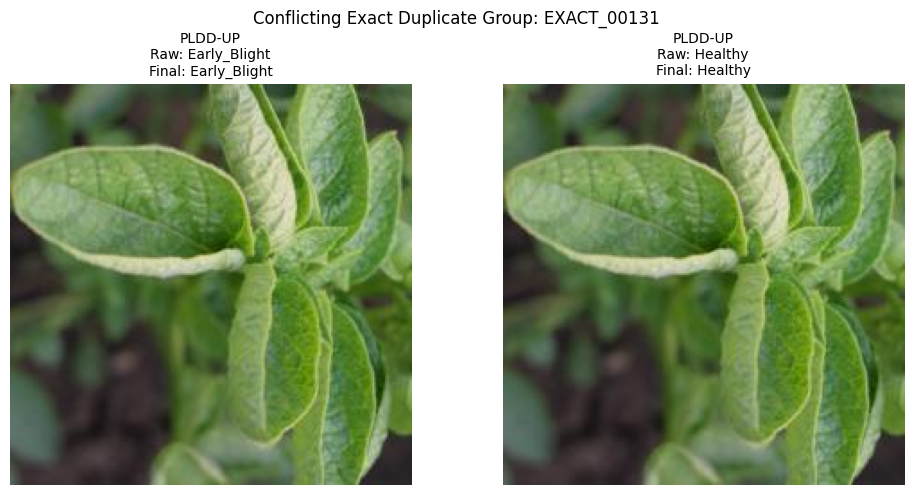


Group ID: EXACT_00160


,source_dataset,raw_label,unified_class,file_path,sha256
4137,PLDD-UP,Early_Blight,Early_Blight,/content/drive/MyDrive/Potato_CNN_ViT_Research...,b178a8c0b871c213e568c7414f1345bec4b5d7ff4a63ee...
16224,PLDD-UP,Healthy,Healthy,/content/drive/MyDrive/Potato_CNN_ViT_Research...,b178a8c0b871c213e568c7414f1345bec4b5d7ff4a63ee...


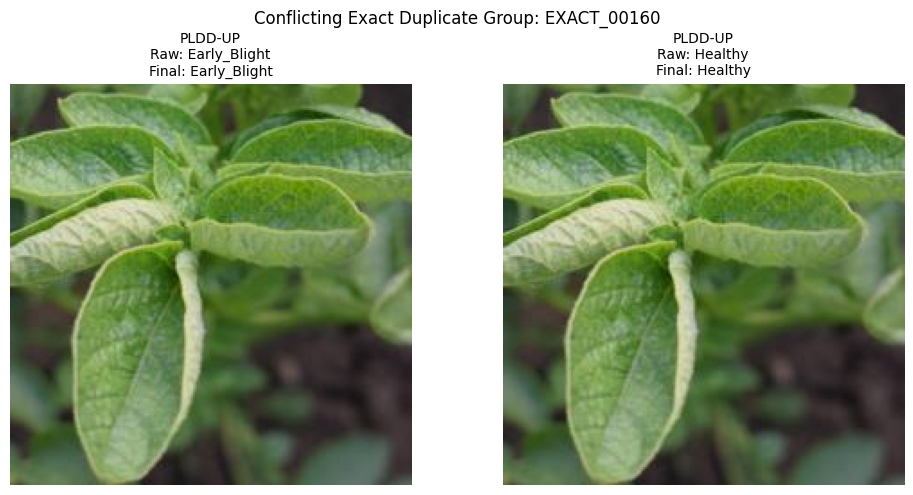

In [17]:
# Conflicting-label exact duplicate images দেখানো

conflict_decisions = exact_decisions_df[
    exact_decisions_df["action"] == "manual_review"
].copy()

print("Conflicting image records:", len(conflict_decisions))

if conflict_decisions.empty:
    print("✅ কোনো conflicting-label duplicate নেই।")

else:
    conflict_group_ids = (
        conflict_decisions["exact_group_id"]
        .dropna()
        .unique()
    )

    print("Conflicting groups:", len(conflict_group_ids))

    for group_id in conflict_group_ids:

        group = exact_duplicates_df[
            exact_duplicates_df["exact_group_id"] == group_id
        ].copy()

        print("\n" + "=" * 70)
        print("Group ID:", group_id)

        display(
            group[
                [
                    "source_dataset",
                    "raw_label",
                    "unified_class",
                    "file_path",
                    "sha256",
                ]
            ]
        )

        number_of_images = len(group)

        fig, axes = plt.subplots(
            1,
            number_of_images,
            figsize=(5 * number_of_images, 5)
        )

        if number_of_images == 1:
            axes = [axes]

        for axis, row in zip(
            axes,
            group.itertuples(index=False)
        ):
            axis.axis("off")

            try:
                with Image.open(row.file_path) as image:
                    axis.imshow(image.convert("RGB"))

                axis.set_title(
                    f"{row.source_dataset}\n"
                    f"Raw: {row.raw_label}\n"
                    f"Final: {row.unified_class}",
                    fontsize=10
                )

            except Exception as error:
                axis.set_title(
                    f"Open error:\n{error}",
                    fontsize=9
                )

        plt.suptitle(
            f"Conflicting Exact Duplicate Group: {group_id}"
        )

        plt.tight_layout()
        plt.show()

In [18]:
# Conflicting-label exact duplicates cleaned manifest থেকে বাদ দেওয়া

conflict_mask = (
    exact_decisions_df["action"] == "manual_review"
)

conflict_paths = set(
    exact_decisions_df.loc[
        conflict_mask,
        "file_path"
    ].astype(str)
)

print("Conflicting images to exclude:", len(conflict_paths))

# Decision report update
exact_decisions_df.loc[
    conflict_mask,
    "action"
] = "exclude_conflicting_label"

exact_decisions_df.loc[
    conflict_mask,
    "reason"
] = "Exact same image appears with conflicting class labels"

exact_decisions_df.to_csv(
    EXACT_DECISIONS_PATH,
    index=False
)

# Main manifest update
manifest_conflict_mask = (
    manifest_df["file_path"].astype(str).isin(conflict_paths)
)

manifest_df.loc[
    manifest_conflict_mask,
    "exclude_from_cleaned_manifest"
] = True

manifest_df.loc[
    manifest_conflict_mask,
    "cleaning_reason"
] = "Excluded because exact duplicate has conflicting labels"

manifest_df["include_in_cleaned_manifest"] = (
    ~manifest_df["exclude_from_cleaned_manifest"]
)

# নতুন cleaned manifests
plant_clean_manifest_df = manifest_df[
    (manifest_df["source_dataset"] == "PlantVillage")
    & manifest_df["include_in_cleaned_manifest"]
].copy()

plddup_clean_manifest_df = manifest_df[
    (manifest_df["source_dataset"] == "PLDD-UP")
    & manifest_df["include_in_cleaned_manifest"]
].copy()

# Save updated files
manifest_df.to_csv(
    ALL_MANIFEST_PATH,
    index=False
)

plant_clean_manifest_df.to_csv(
    PLANT_MANIFEST_PATH,
    index=False
)

plddup_clean_manifest_df.to_csv(
    PLDDUP_MANIFEST_PATH,
    index=False
)

cleaning_log_df = manifest_df[
    (
        manifest_df["exclude_from_cleaned_manifest"]
        | manifest_df["cleaning_reason"].astype(str).str.len().gt(0)
    )
].copy()

cleaning_log_df.to_csv(
    CLEANING_LOG_PATH,
    index=False
)

print("✅ Conflicting-label images excluded.")
print("PlantVillage cleaned images:", len(plant_clean_manifest_df))
print("PLDD-UP cleaned images:", len(plddup_clean_manifest_df))

Conflicting images to exclude: 10
✅ Conflicting-label images excluded.
PlantVillage cleaned images: 2152
PLDD-UP cleaned images: 15260


In [19]:
remaining_manual_review = (
    exact_decisions_df["action"] == "manual_review"
).sum()

print("Remaining manual-review records:", remaining_manual_review)

if remaining_manual_review == 0:
    print("✅ Dataset cleaning completed.")
    print("Next step: 04_Dataset_Splitting.ipynb")
else:
    print("⚠️ কিছু conflict এখনো review করা বাকি।")

Remaining manual-review records: 0
✅ Dataset cleaning completed.
Next step: 04_Dataset_Splitting.ipynb


---

# Part 04 — 04. Dataset Splitting

**Purpose:** Create leakage-aware PlantVillage train/validation/internal-test splits and keep PLDD-UP as the external test set.

**Source notebook:** `04_Dataset_Splitting.ipynb`

**Preservation note:** The original code cells and their saved execution outputs are retained below. Textual headings/comments are lightly normalized into English where possible without changing experiment logic.


# 04 — Dataset Splitting

This notebook cleaned manifest using:

- PlantVillage → 70% Train, 15% Validation, 15% Internal Test
- PLDD-UP → 100% External Test

একই near-duplicate group একাধিক split-এ যাবে না। Raw images move/delete হবে না।


In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [2]:
from pathlib import Path
from datetime import datetime
import json, random
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
RATIOS = {'train': 0.70, 'val': 0.15, 'internal_test': 0.15}
CLASS_ORDER = ['Early_Blight', 'Late_Blight', 'Healthy']
CLASS_ID = {'Early_Blight': 0, 'Late_Blight': 1, 'Healthy': 2}


In [3]:
# Automatically locate project
MY_DRIVE = Path('/content/drive/MyDrive')
standard = MY_DRIVE / 'Potato_CNN_ViT_Research'
PROJECT_ROOT = standard if standard.is_dir() else None

if PROJECT_ROOT is None:
    matches = [p for p in MY_DRIVE.rglob('Potato_CNN_ViT_Research') if p.is_dir()]
    if not matches:
        raise FileNotFoundError('Potato_CNN_ViT_Research folder My Drive-এ পাওয়া যায়নি।')
    PROJECT_ROOT = matches[0]

DATA_DIR = PROJECT_ROOT / '02_data'
METADATA_DIR = DATA_DIR / 'metadata'
SPLITS_DIR = DATA_DIR / 'splits'
FIGURES_DIR = PROJECT_ROOT / '05_results' / 'figures'
SPLITS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print('PROJECT_ROOT:', PROJECT_ROOT)
print('SPLITS_DIR:', SPLITS_DIR)


PROJECT_ROOT: /content/drive/MyDrive/Potato_CNN_ViT_Research
SPLITS_DIR: /content/drive/MyDrive/Potato_CNN_ViT_Research/02_data/splits


In [4]:
# Load cleaned manifests
plant_path = METADATA_DIR / 'cleaned_manifest_plantvillage.csv'
pldd_path = METADATA_DIR / 'cleaned_manifest_plddup.csv'

if not plant_path.exists():
    raise FileNotFoundError(plant_path)
if not pldd_path.exists():
    raise FileNotFoundError(pldd_path)

plant_df = pd.read_csv(plant_path)
pldd_df = pd.read_csv(pldd_path)

for frame in [plant_df, pldd_df]:
    if 'unified_label' in frame.columns and 'unified_class' not in frame.columns:
        frame.rename(columns={'unified_label':'unified_class'}, inplace=True)
    if 'class_id' not in frame.columns:
        frame['class_id'] = frame['unified_class'].map(CLASS_ID)
    frame['class_id'] = frame['class_id'].fillna(frame['unified_class'].map(CLASS_ID)).astype(int)
    frame['file_path'] = frame['file_path'].astype(str)

print('PlantVillage cleaned:', len(plant_df))
print('PLDD-UP cleaned:', len(pldd_df))
display(plant_df.groupby('unified_class').size().reset_index(name='count'))
display(pldd_df.groupby('unified_class').size().reset_index(name='count'))


PlantVillage cleaned: 2152
PLDD-UP cleaned: 15260


,unified_class,count
0,Early_Blight,1000
1,Healthy,152
2,Late_Blight,1000


,unified_class,count
0,Early_Blight,4743
1,Healthy,4448
2,Late_Blight,6069


In [5]:
# Build leakage-safe split groups
def clean_group(value):
    if pd.isna(value):
        return ''
    value = str(value).strip()
    return '' if value.lower() in {'', 'nan', 'none'} else value

plant_df = plant_df.reset_index(drop=True).copy()

def make_group(row, idx):
    near = clean_group(row.get('near_duplicate_group_id', ''))
    if near:
        return f'NEAR::{near}'
    exact = clean_group(row.get('exact_group_id', ''))
    if exact:
        return f'EXACT::{exact}'
    return f'UNIQUE::{idx:07d}'

plant_df['split_group_id'] = [make_group(row, idx) for idx, row in plant_df.iterrows()]

# A group must belong to only one class
conflict = plant_df.groupby('split_group_id')['unified_class'].nunique()
if (conflict > 1).any():
    raise ValueError('একটি duplicate group-এ একাধিক class পাওয়া গেছে।')

print('Total split groups:', plant_df['split_group_id'].nunique())


Total split groups: 2149


In [6]:
# Group-aware stratified 70/15/15 split
def targets(total):
    val = round(total * RATIOS['val'])
    test = round(total * RATIOS['internal_test'])
    train = total - val - test
    return {'train': train, 'val': val, 'internal_test': test}

def assign_class(class_df, seed):
    rng = random.Random(seed)
    groups = class_df.groupby('split_group_id').size().reset_index(name='size').to_dict('records')
    rng.shuffle(groups)
    groups.sort(key=lambda x: x['size'], reverse=True)
    target = targets(len(class_df))
    current = {k:0 for k in RATIOS}
    result = {}

    for item in groups:
        scores = {s:(target[s]-current[s])/max(target[s],1) for s in RATIOS}
        chosen = max(RATIOS, key=lambda s:(scores[s], -current[s], s))
        result[item['split_group_id']] = chosen
        current[chosen] += int(item['size'])
    return result, target, current

assignments = {}
target_rows = []
for i, cls in enumerate(CLASS_ORDER):
    cdf = plant_df[plant_df['unified_class']==cls]
    if cdf.empty:
        raise ValueError(f'Class empty: {cls}')
    mapping, target, actual = assign_class(cdf, SEED+i)
    assignments.update(mapping)
    for split in RATIOS:
        target_rows.append({'unified_class':cls,'split':split,'target_count':target[split],'actual_count':actual[split],'difference':actual[split]-target[split]})

plant_df['split'] = plant_df['split_group_id'].map(assignments)
if plant_df['split'].isna().any():
    raise RuntimeError('কিছু image-এ split assign হয়নি।')

display(pd.DataFrame(target_rows))


,unified_class,split,target_count,actual_count,difference
0,Early_Blight,train,700,700,0
1,Early_Blight,val,150,150,0
2,Early_Blight,internal_test,150,150,0
3,Late_Blight,train,700,700,0
4,Late_Blight,val,150,150,0
5,Late_Blight,internal_test,150,150,0
6,Healthy,train,106,106,0
7,Healthy,val,23,23,0
8,Healthy,internal_test,23,23,0


In [7]:
# Create final split tables
optional_cols = ['file_name','raw_label','exact_group_id','near_duplicate_group_id']
for col in optional_cols:
    if col not in plant_df.columns:
        plant_df[col] = ''
    if col not in pldd_df.columns:
        pldd_df[col] = ''

columns = ['file_path','file_name','source_dataset','raw_label','unified_class','class_id','split','split_group_id','exact_group_id','near_duplicate_group_id']

train_df = plant_df[plant_df['split']=='train'][columns].reset_index(drop=True)
val_df = plant_df[plant_df['split']=='val'][columns].reset_index(drop=True)
internal_test_df = plant_df[plant_df['split']=='internal_test'][columns].reset_index(drop=True)

pldd_df = pldd_df.reset_index(drop=True).copy()
pldd_df['split'] = 'external_test'
pldd_df['split_group_id'] = [
    f'NEAR::{clean_group(row.get("near_duplicate_group_id", ""))}'
    if clean_group(row.get('near_duplicate_group_id',''))
    else f'EXTERNAL_UNIQUE::{idx:07d}'
    for idx, row in pldd_df.iterrows()
]
external_test_df = pldd_df[columns].reset_index(drop=True)

print('Train:', len(train_df))
print('Validation:', len(val_df))
print('Internal test:', len(internal_test_df))
print('External test:', len(external_test_df))


Train: 1506
Validation: 323
Internal test: 323
External test: 15260


In [8]:
# Leakage audit
def s(frame, column):
    return set(frame[column].astype(str))

audit=[]
frames={'train':train_df,'val':val_df,'internal_test':internal_test_df}
for a,b in [('train','val'),('train','internal_test'),('val','internal_test')]:
    path_overlap = s(frames[a],'file_path') & s(frames[b],'file_path')
    group_overlap = s(frames[a],'split_group_id') & s(frames[b],'split_group_id')
    audit.append({'check':f'Path overlap {a} vs {b}','overlap_count':len(path_overlap),'passed':len(path_overlap)==0})
    audit.append({'check':f'Group overlap {a} vs {b}','overlap_count':len(group_overlap),'passed':len(group_overlap)==0})

leakage_audit_df = pd.DataFrame(audit)
display(leakage_audit_df)
if not leakage_audit_df['passed'].all():
    raise RuntimeError('Leakage audit failed.')
print('✅ Leakage audit passed.')


,check,overlap_count,passed
0,Path overlap train vs val,0,True
1,Group overlap train vs val,0,True
2,Path overlap train vs internal_test,0,True
3,Group overlap train vs internal_test,0,True
4,Path overlap val vs internal_test,0,True
5,Group overlap val vs internal_test,0,True


✅ Leakage audit passed.


In [9]:
# Save CSV files and reports
paths = {
    'train.csv': train_df,
    'val.csv': val_df,
    'internal_test.csv': internal_test_df,
    'external_test.csv': external_test_df,
}
for name, frame in paths.items():
    out = SPLITS_DIR / name
    frame.to_csv(out, index=False)
    print('Saved:', out)

summary_df = pd.concat([
    train_df.groupby(['unified_class','class_id']).size().reset_index(name='count').assign(split='train'),
    val_df.groupby(['unified_class','class_id']).size().reset_index(name='count').assign(split='val'),
    internal_test_df.groupby(['unified_class','class_id']).size().reset_index(name='count').assign(split='internal_test'),
    external_test_df.groupby(['unified_class','class_id']).size().reset_index(name='count').assign(split='external_test'),
], ignore_index=True)
summary_df.to_csv(METADATA_DIR / 'split_summary.csv', index=False)
leakage_audit_df.to_csv(METADATA_DIR / 'split_leakage_audit.csv', index=False)
pd.DataFrame(target_rows).to_csv(METADATA_DIR / 'split_target_vs_actual.csv', index=False)

config = {
    'created_at': datetime.now().isoformat(),
    'random_seed': SEED,
    'ratios': RATIOS,
    'plantvillage_total': len(plant_df),
    'plddup_external_total': len(pldd_df),
    'group_aware': True,
    'external_used_for_training': False,
}
with open(METADATA_DIR / 'split_config.json','w',encoding='utf-8') as f:
    json.dump(config,f,ensure_ascii=False,indent=2)

display(summary_df)


Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/02_data/splits/train.csv
Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/02_data/splits/val.csv
Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/02_data/splits/internal_test.csv
Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/02_data/splits/external_test.csv


,unified_class,class_id,count,split
0,Early_Blight,0,700,train
1,Healthy,2,106,train
2,Late_Blight,1,700,train
3,Early_Blight,0,150,val
4,Healthy,2,23,val
5,Late_Blight,1,150,val
6,Early_Blight,0,150,internal_test
7,Healthy,2,23,internal_test
8,Late_Blight,1,150,internal_test
9,Early_Blight,0,4743,external_test


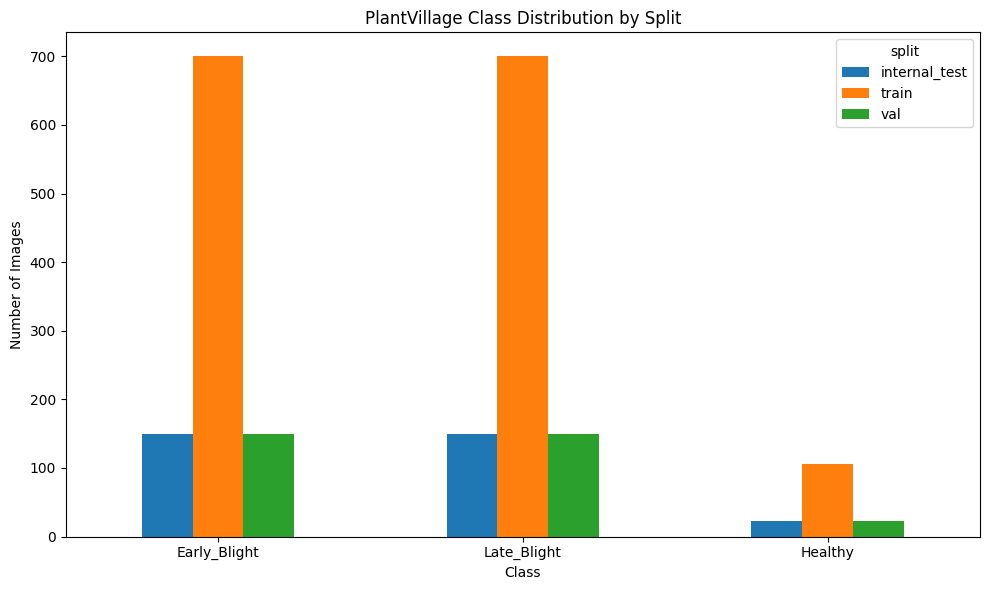

,check,passed
0,Train CSV saved,True
1,Validation CSV saved,True
2,Internal test CSV saved,True
3,External test CSV saved,True
4,No split leakage,True
5,All PlantVillage images assigned once,True
6,All PLDD-UP images assigned to external test,True


✅ Dataset splitting completed successfully.
Next step: 05_DataLoader_and_Preprocessing.ipynb


In [10]:
# Plot and final report
pivot = summary_df[summary_df['split'].isin(['train','val','internal_test'])].pivot(index='unified_class',columns='split',values='count').reindex(CLASS_ORDER).fillna(0)
ax = pivot.plot(kind='bar', figsize=(10,6))
ax.set_title('PlantVillage Class Distribution by Split')
ax.set_xlabel('Class')
ax.set_ylabel('Number of Images')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
fig_path = FIGURES_DIR / 'plantvillage_split_class_distribution.png'
plt.savefig(fig_path, dpi=200, bbox_inches='tight')
plt.show()

final_report = pd.DataFrame([
    {'check':'Train CSV saved','passed':(SPLITS_DIR/'train.csv').exists()},
    {'check':'Validation CSV saved','passed':(SPLITS_DIR/'val.csv').exists()},
    {'check':'Internal test CSV saved','passed':(SPLITS_DIR/'internal_test.csv').exists()},
    {'check':'External test CSV saved','passed':(SPLITS_DIR/'external_test.csv').exists()},
    {'check':'No split leakage','passed':bool(leakage_audit_df['passed'].all())},
    {'check':'All PlantVillage images assigned once','passed':len(train_df)+len(val_df)+len(internal_test_df)==len(plant_df)},
    {'check':'All PLDD-UP images assigned to external test','passed':len(external_test_df)==len(pldd_df)},
])
display(final_report)

if final_report['passed'].all():
    print('✅ Dataset splitting completed successfully.')
    print('Next step: 05_DataLoader_and_Preprocessing.ipynb')
else:
    print('⚠️ Dataset splitting completed with warnings.')


---

# Part 05 — 05. DataLoader and Preprocessing

**Purpose:** Build preprocessing pipelines, augmentation, PyTorch Dataset/DataLoader objects, class weights, and batch-level validation.

**Source notebook:** `05_DataLoader_and_Preprocessing.ipynb`

**Preservation note:** The original code cells and their saved execution outputs are retained below. Textual headings/comments are lightly normalized into English where possible without changing experiment logic.


# 05 — DataLoader and Preprocessing

Dataset splitting after completion This notebook run this notebook।

## This notebook will perform the following tasks

- `train.csv`, `val.csv`, `internal_test.csv`, `external_test.csv` will load
- সব image path ও class label will verify
- Training augmentation will create
- Validation/Test preprocessing will create
- PyTorch `Dataset` ও `DataLoader` will create
- Training class imbalance will calculate
- Class weights will save
- একটি training batch ও একটি external-test batch will test
- Preprocessing configuration Drive-এ will save

## Important rules

- Random augmentation শুধু training set-এ হবে
- Validation, internal test ও external test-এ random augmentation হবে না
- Image size হবে `224 × 224`
- Class ID:
  - `0 = Early_Blight`
  - `1 = Late_Blight`
  - `2 = Healthy`


In [1]:
# Cell 1: Mount Google Drive
from google.colab import drive

drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [2]:
# Cell 2: Imports and configuration
from pathlib import Path
from datetime import datetime
import json
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

RANDOM_SEED = 42
IMAGE_SIZE = 224
RESIZE_SIZE = 256
BATCH_SIZE = 16
NUM_WORKERS = 2

CLASS_NAMES = [
    'Early_Blight',
    'Late_Blight',
    'Healthy',
]

CLASS_ID_MAP = {
    'Early_Blight': 0,
    'Late_Blight': 1,
    'Healthy': 2,
}

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

DEVICE = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
)

print('PyTorch version:', torch.__version__)
print('Torchvision available')
print('Device:', DEVICE)


PyTorch version: 2.11.0+cpu
Torchvision available
Device: cpu


In [3]:
# Cell 3: Locate project folders
MY_DRIVE = Path('/content/drive/MyDrive')

standard_project = MY_DRIVE / 'Potato_CNN_ViT_Research'

if standard_project.is_dir():
    PROJECT_ROOT = standard_project
else:
    matches = [
        path
        for path in MY_DRIVE.rglob('Potato_CNN_ViT_Research')
        if path.is_dir()
    ]

    if not matches:
        raise FileNotFoundError(
            'Potato_CNN_ViT_Research folder My Drive-এ পাওয়া যায়নি।'
        )

    PROJECT_ROOT = matches[0]

DATA_DIR = PROJECT_ROOT / '02_data'
SPLITS_DIR = DATA_DIR / 'splits'
METADATA_DIR = DATA_DIR / 'metadata'
CONFIG_DIR = PROJECT_ROOT / '03_configs'
FIGURES_DIR = PROJECT_ROOT / '05_results' / 'figures'

CONFIG_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print('PROJECT_ROOT:', PROJECT_ROOT)
print('SPLITS_DIR:', SPLITS_DIR)
print('CONFIG_DIR:', CONFIG_DIR)
print('FIGURES_DIR:', FIGURES_DIR)


PROJECT_ROOT: /content/drive/MyDrive/Potato_CNN_ViT_Research
SPLITS_DIR: /content/drive/MyDrive/Potato_CNN_ViT_Research/02_data/splits
CONFIG_DIR: /content/drive/MyDrive/Potato_CNN_ViT_Research/03_configs
FIGURES_DIR: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/figures


In [4]:
# Cell 4: Load all split CSV files
split_paths = {
    'train': SPLITS_DIR / 'train.csv',
    'val': SPLITS_DIR / 'val.csv',
    'internal_test': SPLITS_DIR / 'internal_test.csv',
    'external_test': SPLITS_DIR / 'external_test.csv',
}

for split_name, split_path in split_paths.items():
    if not split_path.exists():
        raise FileNotFoundError(
            f'{split_name} CSV পাওয়া যায়নি: {split_path}'
        )

train_df = pd.read_csv(split_paths['train'])
val_df = pd.read_csv(split_paths['val'])
internal_test_df = pd.read_csv(split_paths['internal_test'])
external_test_df = pd.read_csv(split_paths['external_test'])

split_frames = {
    'train': train_df,
    'val': val_df,
    'internal_test': internal_test_df,
    'external_test': external_test_df,
}

required_columns = {
    'file_path',
    'unified_class',
    'class_id',
    'split',
}

for split_name, frame in split_frames.items():
    missing_columns = required_columns - set(frame.columns)

    if missing_columns:
        raise KeyError(
            f'{split_name} CSV-তে column missing: '
            f'{sorted(missing_columns)}'
        )

    frame['file_path'] = frame['file_path'].astype(str)
    frame['unified_class'] = frame['unified_class'].astype(str)
    frame['class_id'] = frame['class_id'].astype(int)

print('Train images:', len(train_df))
print('Validation images:', len(val_df))
print('Internal-test images:', len(internal_test_df))
print('External-test images:', len(external_test_df))


Train images: 1506
Validation images: 323
Internal-test images: 323
External-test images: 15260


In [5]:
# Cell 5: Validate labels, class IDs, and file paths
audit_rows = []

for split_name, frame in split_frames.items():
    invalid_class_names = sorted(
        set(frame['unified_class']) - set(CLASS_NAMES)
    )

    invalid_class_ids = sorted(
        set(frame['class_id']) - set(CLASS_ID_MAP.values())
    )

    mapping_mismatch_count = int(
        (
            frame['unified_class'].map(CLASS_ID_MAP)
            != frame['class_id']
        ).sum()
    )

    missing_file_count = int(
        (~frame['file_path'].map(lambda value: Path(value).exists())).sum()
    )

    audit_rows.append({
        'split': split_name,
        'image_count': len(frame),
        'invalid_class_names': str(invalid_class_names),
        'invalid_class_ids': str(invalid_class_ids),
        'mapping_mismatch_count': mapping_mismatch_count,
        'missing_file_count': missing_file_count,
        'passed': (
            len(invalid_class_names) == 0
            and len(invalid_class_ids) == 0
            and mapping_mismatch_count == 0
            and missing_file_count == 0
        ),
    })

data_audit_df = pd.DataFrame(audit_rows)
display(data_audit_df)

if not data_audit_df['passed'].all():
    raise RuntimeError(
        'Split CSV audit failed. উপরের table দেখে সমস্যা ঠিক করো।'
    )

print('✅ All split CSV files passed label and path validation.')


,split,image_count,invalid_class_names,invalid_class_ids,mapping_mismatch_count,missing_file_count,passed
0,train,1506,[],[],0,0,True
1,val,323,[],[],0,0,True
2,internal_test,323,[],[],0,0,True
3,external_test,15260,[],[],0,0,True


✅ All split CSV files passed label and path validation.


In [6]:
# Cell 6: Show class distribution
distribution_rows = []

for split_name, frame in split_frames.items():
    class_counts = (
        frame.groupby(['unified_class', 'class_id'])
        .size()
        .reset_index(name='image_count')
    )

    class_counts['split'] = split_name
    distribution_rows.append(class_counts)

class_distribution_df = pd.concat(
    distribution_rows,
    ignore_index=True,
)

display(
    class_distribution_df[
        [
            'split',
            'unified_class',
            'class_id',
            'image_count',
        ]
    ]
)

distribution_path = (
    METADATA_DIR / 'dataloader_class_distribution.csv'
)

class_distribution_df.to_csv(
    distribution_path,
    index=False,
)

print('Saved:', distribution_path)


,split,unified_class,class_id,image_count
0,train,Early_Blight,0,700
1,train,Healthy,2,106
2,train,Late_Blight,1,700
3,val,Early_Blight,0,150
4,val,Healthy,2,23
5,val,Late_Blight,1,150
6,internal_test,Early_Blight,0,150
7,internal_test,Healthy,2,23
8,internal_test,Late_Blight,1,150
9,external_test,Early_Blight,0,4743


Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/02_data/metadata/dataloader_class_distribution.csv


In [7]:
# Cell 7: Define training and evaluation transforms
train_transform = transforms.Compose([
    transforms.Resize(
        (RESIZE_SIZE, RESIZE_SIZE)
    ),
    transforms.RandomResizedCrop(
        IMAGE_SIZE,
        scale=(0.80, 1.00),
        ratio=(0.90, 1.10),
    ),
    transforms.RandomHorizontalFlip(
        p=0.5
    ),
    transforms.RandomRotation(
        degrees=15
    ),
    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.10,
        hue=0.02,
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD,
    ),
    transforms.RandomErasing(
        p=0.10,
        scale=(0.02, 0.08),
        ratio=(0.5, 2.0),
        value='random',
    ),
])

eval_transform = transforms.Compose([
    transforms.Resize(
        (RESIZE_SIZE, RESIZE_SIZE)
    ),
    transforms.CenterCrop(
        IMAGE_SIZE
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD,
    ),
])

print('Training transform:')
print(train_transform)

print('\nEvaluation transform:')
print(eval_transform)


Training transform:
Compose(
    Resize(size=(256, 256), interpolation=bilinear, max_size=None, antialias=True)
    RandomResizedCrop(size=(224, 224), scale=(0.8, 1.0), ratio=(0.9, 1.1), interpolation=bilinear, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.85, 1.15), contrast=(0.85, 1.15), saturation=(0.9, 1.1), hue=(-0.02, 0.02))
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    RandomErasing(p=0.1, scale=(0.02, 0.08), ratio=(0.5, 2.0), value=random, inplace=False)
)

Evaluation transform:
Compose(
    Resize(size=(256, 256), interpolation=bilinear, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


In [8]:
# Cell 8: Define the CSV-based PyTorch Dataset
class PotatoLeafDataset(Dataset):
    def __init__(
        self,
        dataframe,
        transform=None,
    ):
        self.dataframe = dataframe.reset_index(
            drop=True
        ).copy()

        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]
        image_path = row['file_path']

        with Image.open(image_path) as image:
            image = image.convert('RGB')

        if self.transform is not None:
            image = self.transform(image)

        label = int(row['class_id'])

        sample = {
            'image': image,
            'label': torch.tensor(
                label,
                dtype=torch.long,
            ),
            'file_path': str(image_path),
            'class_name': str(
                row['unified_class']
            ),
            'source_dataset': str(
                row.get(
                    'source_dataset',
                    '',
                )
            ),
            'split': str(
                row.get(
                    'split',
                    '',
                )
            ),
        }

        return sample


train_dataset = PotatoLeafDataset(
    train_df,
    transform=train_transform,
)

val_dataset = PotatoLeafDataset(
    val_df,
    transform=eval_transform,
)

internal_test_dataset = PotatoLeafDataset(
    internal_test_df,
    transform=eval_transform,
)

external_test_dataset = PotatoLeafDataset(
    external_test_df,
    transform=eval_transform,
)

print('Train dataset:', len(train_dataset))
print('Validation dataset:', len(val_dataset))
print('Internal-test dataset:', len(internal_test_dataset))
print('External-test dataset:', len(external_test_dataset))


Train dataset: 1506
Validation dataset: 323
Internal-test dataset: 323
External-test dataset: 15260


In [9]:
# Cell 9: Compute class weights from the training split
train_class_counts = (
    train_df['class_id']
    .value_counts()
    .sort_index()
    .reindex(
        range(len(CLASS_NAMES)),
        fill_value=0,
    )
)

if (train_class_counts == 0).any():
    raise ValueError(
        'Training split-এর এক বা একাধিক class-এ কোনো image নেই।'
    )

total_training_images = int(
    train_class_counts.sum()
)

number_of_classes = len(CLASS_NAMES)

class_weights = (
    total_training_images
    / (
        number_of_classes
        * train_class_counts.values
    )
)

class_weights_tensor = torch.tensor(
    class_weights,
    dtype=torch.float32,
    device=DEVICE,
)

class_weights_df = pd.DataFrame({
    'class_id': list(range(number_of_classes)),
    'class_name': CLASS_NAMES,
    'training_image_count': train_class_counts.values,
    'class_weight': class_weights,
})

display(class_weights_df)

class_weights_path = (
    METADATA_DIR / 'training_class_weights.csv'
)

class_weights_df.to_csv(
    class_weights_path,
    index=False,
)

print('Class weights tensor:', class_weights_tensor)
print('Saved:', class_weights_path)

# Later training notebooks can use:
# criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)


,class_id,class_name,training_image_count,class_weight
0,0,Early_Blight,700,0.717143
1,1,Late_Blight,700,0.717143
2,2,Healthy,106,4.735849


Class weights tensor: tensor([0.7171, 0.7171, 4.7358])
Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/02_data/metadata/training_class_weights.csv


In [10]:
# Cell 10: Create DataLoaders
pin_memory_enabled = torch.cuda.is_available()

loader_generator = torch.Generator()
loader_generator.manual_seed(RANDOM_SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory_enabled,
    persistent_workers=(
        NUM_WORKERS > 0
    ),
    generator=loader_generator,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory_enabled,
    persistent_workers=(
        NUM_WORKERS > 0
    ),
)

internal_test_loader = DataLoader(
    internal_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory_enabled,
    persistent_workers=(
        NUM_WORKERS > 0
    ),
)

external_test_loader = DataLoader(
    external_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory_enabled,
    persistent_workers=(
        NUM_WORKERS > 0
    ),
)

print('Train batches:', len(train_loader))
print('Validation batches:', len(val_loader))
print('Internal-test batches:', len(internal_test_loader))
print('External-test batches:', len(external_test_loader))


Train batches: 95
Validation batches: 21
Internal-test batches: 21
External-test batches: 954


In [11]:
# Cell 11: Test one batch from every DataLoader
loader_map = {
    'train': train_loader,
    'val': val_loader,
    'internal_test': internal_test_loader,
    'external_test': external_test_loader,
}

batch_audit_rows = []

for loader_name, loader in loader_map.items():
    batch = next(iter(loader))

    images = batch['image']
    labels = batch['label']

    batch_audit_rows.append({
        'loader': loader_name,
        'batch_size': int(images.shape[0]),
        'image_shape': str(
            tuple(images.shape)
        ),
        'label_shape': str(
            tuple(labels.shape)
        ),
        'minimum_label': int(
            labels.min().item()
        ),
        'maximum_label': int(
            labels.max().item()
        ),
        'contains_nan': bool(
            torch.isnan(images).any().item()
        ),
        'passed': (
            images.ndim == 4
            and images.shape[1:] == (
                3,
                IMAGE_SIZE,
                IMAGE_SIZE,
            )
            and labels.ndim == 1
            and not torch.isnan(images).any()
        ),
    })

batch_audit_df = pd.DataFrame(
    batch_audit_rows
)

display(batch_audit_df)

if not batch_audit_df['passed'].all():
    raise RuntimeError(
        'এক বা একাধিক DataLoader batch validation failed।'
    )

print('✅ All DataLoaders produced valid batches.')


,loader,batch_size,image_shape,label_shape,minimum_label,maximum_label,contains_nan,passed
0,train,16,"(16, 3, 224, 224)","(16,)",0,2,False,True
1,val,16,"(16, 3, 224, 224)","(16,)",0,0,False,True
2,internal_test,16,"(16, 3, 224, 224)","(16,)",0,0,False,True
3,external_test,16,"(16, 3, 224, 224)","(16,)",0,0,False,True


✅ All DataLoaders produced valid batches.


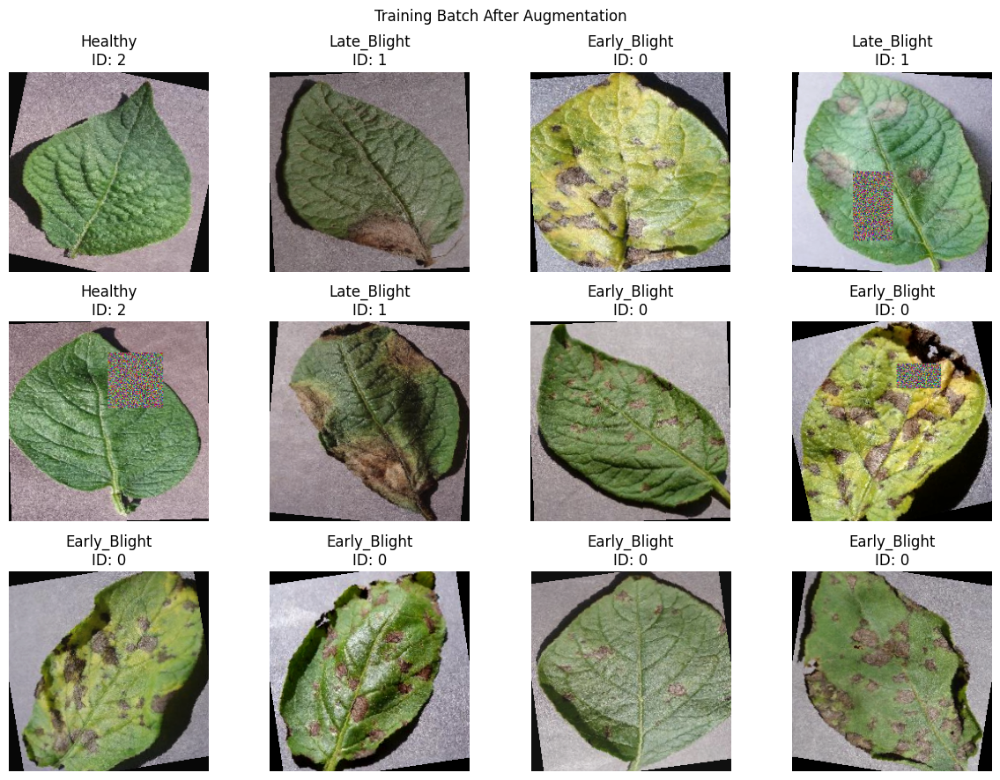

Figure saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/figures/training_batch_after_augmentation.png


In [12]:
# Cell 12: Visualize one training batch
def denormalize(image_tensor):
    mean = torch.tensor(
        IMAGENET_MEAN
    ).view(3, 1, 1)

    std = torch.tensor(
        IMAGENET_STD
    ).view(3, 1, 1)

    image = (
        image_tensor.cpu() * std + mean
    )

    return image.clamp(0, 1)


batch = next(iter(train_loader))

images = batch['image']
labels = batch['label']
class_names = batch['class_name']

number_to_show = min(
    12,
    images.shape[0],
)

fig, axes = plt.subplots(
    3,
    4,
    figsize=(12, 9),
)

axes = axes.flatten()

for index, axis in enumerate(axes):
    axis.axis('off')

    if index < number_to_show:
        image = denormalize(
            images[index]
        ).permute(1, 2, 0)

        axis.imshow(image)
        axis.set_title(
            f'{class_names[index]}\n'
            f'ID: {int(labels[index])}'
        )

plt.suptitle(
    'Training Batch After Augmentation'
)

plt.tight_layout()

training_batch_figure_path = (
    FIGURES_DIR
    / 'training_batch_after_augmentation.png'
)

plt.savefig(
    training_batch_figure_path,
    dpi=200,
    bbox_inches='tight',
)

plt.show()

print('Figure saved:', training_batch_figure_path)


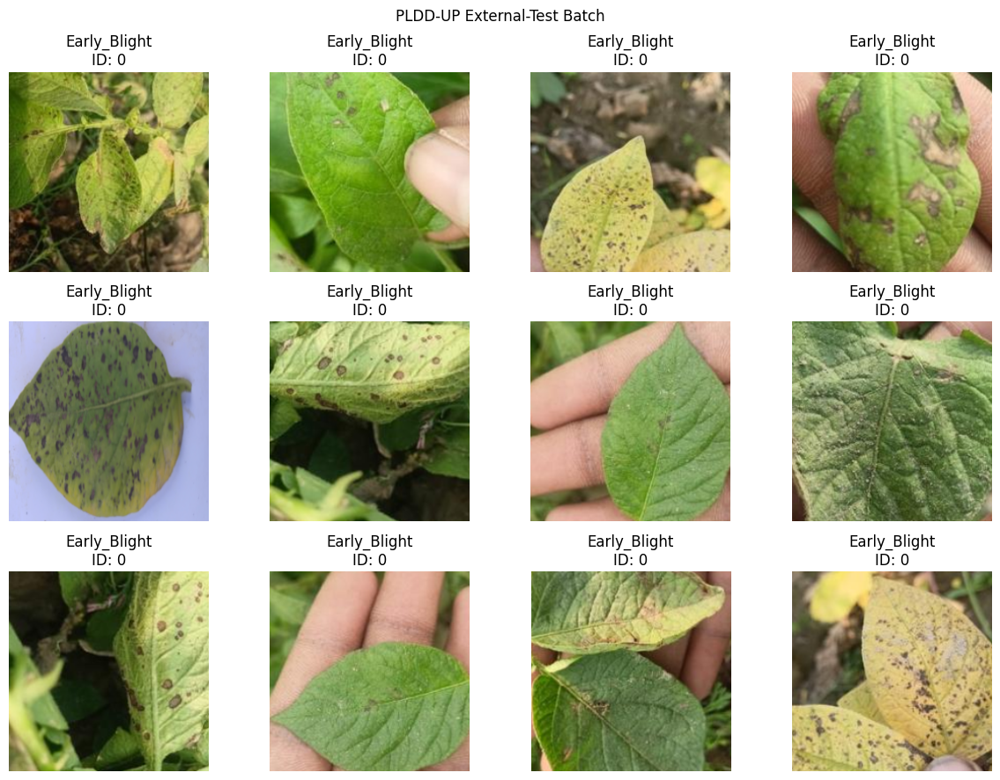

Figure saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/figures/external_test_batch.png


In [13]:
# Cell 13: Visualize one external-test batch
batch = next(iter(external_test_loader))

images = batch['image']
labels = batch['label']
class_names = batch['class_name']

number_to_show = min(
    12,
    images.shape[0],
)

fig, axes = plt.subplots(
    3,
    4,
    figsize=(12, 9),
)

axes = axes.flatten()

for index, axis in enumerate(axes):
    axis.axis('off')

    if index < number_to_show:
        image = denormalize(
            images[index]
        ).permute(1, 2, 0)

        axis.imshow(image)
        axis.set_title(
            f'{class_names[index]}\n'
            f'ID: {int(labels[index])}'
        )

plt.suptitle(
    'PLDD-UP External-Test Batch'
)

plt.tight_layout()

external_batch_figure_path = (
    FIGURES_DIR
    / 'external_test_batch.png'
)

plt.savefig(
    external_batch_figure_path,
    dpi=200,
    bbox_inches='tight',
)

plt.show()

print('Figure saved:', external_batch_figure_path)


In [14]:
# Cell 14: Save preprocessing and DataLoader configuration
preprocessing_config = {
    'created_at': datetime.now().isoformat(),
    'random_seed': RANDOM_SEED,
    'image_size': IMAGE_SIZE,
    'resize_size': RESIZE_SIZE,
    'batch_size': BATCH_SIZE,
    'num_workers': NUM_WORKERS,
    'class_names': CLASS_NAMES,
    'class_id_map': CLASS_ID_MAP,
    'normalization_mean': IMAGENET_MEAN,
    'normalization_std': IMAGENET_STD,
    'training_augmentation': {
        'resize': [RESIZE_SIZE, RESIZE_SIZE],
        'random_resized_crop': {
            'output_size': IMAGE_SIZE,
            'scale': [0.80, 1.00],
            'ratio': [0.90, 1.10],
        },
        'horizontal_flip_probability': 0.5,
        'rotation_degrees': 15,
        'color_jitter': {
            'brightness': 0.15,
            'contrast': 0.15,
            'saturation': 0.10,
            'hue': 0.02,
        },
        'random_erasing': {
            'probability': 0.10,
            'scale': [0.02, 0.08],
            'ratio': [0.5, 2.0],
        },
    },
    'evaluation_preprocessing': {
        'resize': [RESIZE_SIZE, RESIZE_SIZE],
        'center_crop': IMAGE_SIZE,
        'random_augmentation': False,
    },
    'class_weights': {
        CLASS_NAMES[index]: float(
            class_weights[index]
        )
        for index in range(
            len(CLASS_NAMES)
        )
    },
}

config_path = (
    CONFIG_DIR
    / 'dataloader_preprocessing_config.json'
)

with config_path.open(
    'w',
    encoding='utf-8',
) as file_handle:
    json.dump(
        preprocessing_config,
        file_handle,
        ensure_ascii=False,
        indent=2,
    )

data_audit_path = (
    METADATA_DIR
    / 'dataloader_split_audit.csv'
)

batch_audit_path = (
    METADATA_DIR
    / 'dataloader_batch_audit.csv'
)

data_audit_df.to_csv(
    data_audit_path,
    index=False,
)

batch_audit_df.to_csv(
    batch_audit_path,
    index=False,
)

print('Saved:', config_path)
print('Saved:', data_audit_path)
print('Saved:', batch_audit_path)


Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/03_configs/dataloader_preprocessing_config.json
Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/02_data/metadata/dataloader_split_audit.csv
Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/02_data/metadata/dataloader_batch_audit.csv


In [15]:
# Cell 15: Final DataLoader verification report
final_report_df = pd.DataFrame([
    {
        'check': 'All split CSV files loaded',
        'passed': True,
    },
    {
        'check': 'All file paths and labels valid',
        'passed': bool(
            data_audit_df['passed'].all()
        ),
    },
    {
        'check': 'Training transform created',
        'passed': train_transform is not None,
    },
    {
        'check': 'Evaluation transform created',
        'passed': eval_transform is not None,
    },
    {
        'check': 'All four DataLoaders created',
        'passed': all(
            loader is not None
            for loader in loader_map.values()
        ),
    },
    {
        'check': 'All DataLoader batches valid',
        'passed': bool(
            batch_audit_df['passed'].all()
        ),
    },
    {
        'check': 'Class weights saved',
        'passed': class_weights_path.exists(),
    },
    {
        'check': 'Preprocessing config saved',
        'passed': config_path.exists(),
    },
])

display(final_report_df)

if final_report_df['passed'].all():
    print(
        '✅ DataLoader and preprocessing '
        'completed successfully.'
    )
    print(
        'Next step: 06_CNN_Baseline_Training.ipynb'
    )
else:
    print(
        '⚠️ DataLoader/preprocessing '
        'completed with warnings.'
    )


,check,passed
0,All split CSV files loaded,True
1,All file paths and labels valid,True
2,Training transform created,True
3,Evaluation transform created,True
4,All four DataLoaders created,True
5,All DataLoader batches valid,True
6,Class weights saved,True
7,Preprocessing config saved,True


✅ DataLoader and preprocessing completed successfully.
Next step: 06_CNN_Baseline_Training.ipynb


---

# Part 06 — 06. CNN Baseline Training — EfficientNet-B0

**Purpose:** Train the CNN baseline with EfficientNet-B0 using the fixed data split, weighted cross-entropy, validation Macro-F1 checkpointing, and internal evaluation.

**Source notebook:** `06_CNN_Baseline_Training.ipynb`

**Preservation note:** The original code cells and their saved execution outputs are retained below. Textual headings/comments are lightly normalized into English where possible without changing experiment logic.


# 06 — CNN Baseline Training (EfficientNet-B0)

This notebook প্রথম baseline model train করবে।

## Model
- Pretrained `EfficientNet-B0`
- Output classes: 3
- `0 = Early_Blight`
- `1 = Late_Blight`
- `2 = Healthy`

## Training policy
- Training data: PlantVillage `train.csv`
- Validation data: PlantVillage `val.csv`
- Internal test: PlantVillage `internal_test.csv`
- External PLDD-UP এখানে will not be used for training or tuning
- Loss: Weighted Cross-Entropy
- Optimizer: AdamW
- Early stopping metric: Validation Macro F1
- Best checkpoint Google Drive-এ save হবে
- Mixed precision GPU থাকলে ব্যবহার হবে


In [1]:
# Cell 1: Mount Drive
from google.colab import drive

drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [2]:
# Cell 2: Imports and reproducibility
from pathlib import Path
from datetime import datetime
import copy
import json
import os
import random
import shutil
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import (
    efficientnet_b0,
    EfficientNet_B0_Weights,
)

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
)

RANDOM_SEED = 42
CLASS_NAMES = ['Early_Blight', 'Late_Blight', 'Healthy']
CLASS_ID_MAP = {
    'Early_Blight': 0,
    'Late_Blight': 1,
    'Healthy': 2,
}

IMAGE_SIZE = 224
RESIZE_SIZE = 256
BATCH_SIZE = 16
NUM_WORKERS = 2
MAX_EPOCHS = 25
EARLY_STOPPING_PATIENCE = 6
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
DROPOUT = 0.30

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

seed_everything(RANDOM_SEED)

DEVICE = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
)

print('PyTorch:', torch.__version__)
print('Device:', DEVICE)

if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))


PyTorch: 2.11.0+cu128
Device: cuda
GPU: Tesla T4


In [3]:
# Cell 3: Locate project folders
MY_DRIVE = Path('/content/drive/MyDrive')

standard_project = MY_DRIVE / 'Potato_CNN_ViT_Research'

if standard_project.is_dir():
    PROJECT_ROOT = standard_project
else:
    matches = [
        path
        for path in MY_DRIVE.rglob('Potato_CNN_ViT_Research')
        if path.is_dir()
    ]

    if not matches:
        raise FileNotFoundError(
            'Potato_CNN_ViT_Research folder My Drive-এ পাওয়া যায়নি।'
        )

    PROJECT_ROOT = matches[0]

DATA_DIR = PROJECT_ROOT / '02_data'
SPLITS_DIR = DATA_DIR / 'splits'
METADATA_DIR = DATA_DIR / 'metadata'
CONFIG_DIR = PROJECT_ROOT / '03_configs'
CHECKPOINT_DIR = PROJECT_ROOT / '04_checkpoints' / 'cnn'
METRICS_DIR = PROJECT_ROOT / '05_results' / 'metrics'
FIGURES_DIR = PROJECT_ROOT / '05_results' / 'training_curves'
PREDICTIONS_DIR = PROJECT_ROOT / '05_results' / 'predictions'
CONFUSION_DIR = PROJECT_ROOT / '05_results' / 'confusion_matrices'

for folder in [
    CONFIG_DIR,
    CHECKPOINT_DIR,
    METRICS_DIR,
    FIGURES_DIR,
    PREDICTIONS_DIR,
    CONFUSION_DIR,
]:
    folder.mkdir(parents=True, exist_ok=True)

print('PROJECT_ROOT:', PROJECT_ROOT)
print('CHECKPOINT_DIR:', CHECKPOINT_DIR)


PROJECT_ROOT: /content/drive/MyDrive/Potato_CNN_ViT_Research
CHECKPOINT_DIR: /content/drive/MyDrive/Potato_CNN_ViT_Research/04_checkpoints/cnn


In [4]:
# Cell 4: Load split CSVs and class weights
train_path = SPLITS_DIR / 'train.csv'
val_path = SPLITS_DIR / 'val.csv'
internal_test_path = SPLITS_DIR / 'internal_test.csv'
class_weights_path = METADATA_DIR / 'training_class_weights.csv'

for path in [
    train_path,
    val_path,
    internal_test_path,
    class_weights_path,
]:
    if not path.exists():
        raise FileNotFoundError(f'File পাওয়া যায়নি: {path}')

train_df = pd.read_csv(train_path)
val_df = pd.read_csv(val_path)
internal_test_df = pd.read_csv(internal_test_path)
class_weights_df = pd.read_csv(class_weights_path)

for frame_name, frame in [
    ('train', train_df),
    ('val', val_df),
    ('internal_test', internal_test_df),
]:
    frame['file_path'] = frame['file_path'].astype(str)
    frame['class_id'] = frame['class_id'].astype(int)
    frame['unified_class'] = frame['unified_class'].astype(str)

    missing_count = int(
        (~frame['file_path'].map(lambda x: Path(x).exists())).sum()
    )

    if missing_count:
        raise FileNotFoundError(
            f'{frame_name} split-এ {missing_count}টি image path missing।'
        )

class_weights_df = class_weights_df.sort_values('class_id')
class_weights_tensor = torch.tensor(
    class_weights_df['class_weight'].values,
    dtype=torch.float32,
    device=DEVICE,
)

print('Train:', len(train_df))
print('Validation:', len(val_df))
print('Internal test:', len(internal_test_df))
print('Class weights:', class_weights_tensor)


Train: 1506
Validation: 323
Internal test: 323
Class weights: tensor([0.7171, 0.7171, 4.7358], device='cuda:0')


In [5]:
# Cell 5: Optional local copy for faster Colab training
# PlantVillage ছোট হওয়ায় /content-এ copy করলে Drive I/O অনেক কমে।

USE_LOCAL_COPY = True
LOCAL_ROOT = Path('/content/plantvillage_local')

def build_local_path(original_path):
    original_path = Path(original_path)
    class_folder = original_path.parent.name
    return LOCAL_ROOT / class_folder / original_path.name


if USE_LOCAL_COPY:
    source_plant_root = None

    sample_path = Path(train_df.iloc[0]['file_path'])
    source_plant_root = sample_path.parent.parent

    if not LOCAL_ROOT.exists():
        print('PlantVillage dataset /content-এ copy হচ্ছে...')
        shutil.copytree(
            source_plant_root,
            LOCAL_ROOT,
            dirs_exist_ok=True,
        )
        print('Local copy completed.')
    else:
        print('Existing local copy ব্যবহার করা হচ্ছে.')

    for frame in [train_df, val_df, internal_test_df]:
        frame['original_drive_path'] = frame['file_path']
        frame['file_path'] = frame['file_path'].map(
            lambda value: str(build_local_path(value))
        )

        missing_local = int(
            (~frame['file_path'].map(lambda x: Path(x).exists())).sum()
        )

        if missing_local:
            raise FileNotFoundError(
                f'Local copy-তে {missing_local}টি image missing।'
            )

print('Dataset path mode:',
      'Colab local storage' if USE_LOCAL_COPY else 'Google Drive')


PlantVillage dataset /content-এ copy হচ্ছে...
Local copy completed.
Dataset path mode: Colab local storage


In [6]:
# Cell 6: Define preprocessing
train_transform = transforms.Compose([
    transforms.Resize((RESIZE_SIZE, RESIZE_SIZE)),
    transforms.RandomResizedCrop(
        IMAGE_SIZE,
        scale=(0.80, 1.00),
        ratio=(0.90, 1.10),
    ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.10,
        hue=0.02,
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD,
    ),
    transforms.RandomErasing(
        p=0.10,
        scale=(0.02, 0.08),
        ratio=(0.5, 2.0),
        value='random',
    ),
])

eval_transform = transforms.Compose([
    transforms.Resize((RESIZE_SIZE, RESIZE_SIZE)),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD,
    ),
])


In [7]:
# Cell 7: Dataset and DataLoaders
class PotatoLeafDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True).copy()
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]

        with Image.open(row['file_path']) as image:
            image = image.convert('RGB')

        if self.transform is not None:
            image = self.transform(image)

        return {
            'image': image,
            'label': torch.tensor(
                int(row['class_id']),
                dtype=torch.long,
            ),
            'file_path': str(row['file_path']),
            'class_name': str(row['unified_class']),
        }


train_dataset = PotatoLeafDataset(
    train_df,
    transform=train_transform,
)

val_dataset = PotatoLeafDataset(
    val_df,
    transform=eval_transform,
)

internal_test_dataset = PotatoLeafDataset(
    internal_test_df,
    transform=eval_transform,
)

generator = torch.Generator()
generator.manual_seed(RANDOM_SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=(NUM_WORKERS > 0),
    generator=generator,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=(NUM_WORKERS > 0),
)

internal_test_loader = DataLoader(
    internal_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=(NUM_WORKERS > 0),
)

print('Train batches:', len(train_loader))
print('Validation batches:', len(val_loader))
print('Internal-test batches:', len(internal_test_loader))


Train batches: 95
Validation batches: 21
Internal-test batches: 21


In [8]:
# Cell 8: Build EfficientNet-B0 baseline
weights = EfficientNet_B0_Weights.DEFAULT

model = efficientnet_b0(
    weights=weights
)

in_features = model.classifier[1].in_features

model.classifier = nn.Sequential(
    nn.Dropout(p=DROPOUT),
    nn.Linear(
        in_features,
        len(CLASS_NAMES),
    ),
)

model = model.to(DEVICE)

total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print(model.classifier)
print('Total parameters:', f'{total_parameters:,}')
print('Trainable parameters:', f'{trainable_parameters:,}')


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 79.3MB/s]


Sequential(
  (0): Dropout(p=0.3, inplace=False)
  (1): Linear(in_features=1280, out_features=3, bias=True)
)
Total parameters: 4,011,391
Trainable parameters: 4,011,391


In [9]:
# Cell 9: Loss, optimizer, scheduler, and AMP
criterion = nn.CrossEntropyLoss(
    weight=class_weights_tensor
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=MAX_EPOCHS,
)

amp_enabled = torch.cuda.is_available()

try:
    scaler = torch.amp.GradScaler(
        'cuda',
        enabled=amp_enabled,
    )
except TypeError:
    scaler = torch.cuda.amp.GradScaler(
        enabled=amp_enabled,
    )

print('AMP enabled:', amp_enabled)


AMP enabled: True


In [10]:
# Cell 10: Metric helpers
def calculate_metrics(y_true, y_pred):
    accuracy = accuracy_score(
        y_true,
        y_pred,
    )

    precision, recall, macro_f1, _ = (
        precision_recall_fscore_support(
            y_true,
            y_pred,
            average='macro',
            zero_division=0,
        )
    )

    return {
        'accuracy': float(accuracy),
        'macro_precision': float(precision),
        'macro_recall': float(recall),
        'macro_f1': float(macro_f1),
    }


def run_epoch(
    model,
    loader,
    criterion,
    optimizer=None,
):
    is_training = optimizer is not None

    if is_training:
        model.train()
    else:
        model.eval()

    running_loss = 0.0
    all_labels = []
    all_predictions = []

    for batch in loader:
        images = batch['image'].to(
            DEVICE,
            non_blocking=True,
        )

        labels = batch['label'].to(
            DEVICE,
            non_blocking=True,
        )

        if is_training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_training):
            try:
                autocast_context = torch.amp.autocast(
                    device_type='cuda',
                    enabled=amp_enabled,
                )
            except TypeError:
                autocast_context = torch.cuda.amp.autocast(
                    enabled=amp_enabled,
                )

            with autocast_context:
                logits = model(images)
                loss = criterion(logits, labels)

            if is_training:
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)

                torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    max_norm=1.0,
                )

                scaler.step(optimizer)
                scaler.update()

        running_loss += (
            loss.item() * images.size(0)
        )

        predictions = logits.argmax(dim=1)

        all_labels.extend(
            labels.detach().cpu().tolist()
        )

        all_predictions.extend(
            predictions.detach().cpu().tolist()
        )

    epoch_loss = running_loss / len(loader.dataset)
    metrics = calculate_metrics(
        all_labels,
        all_predictions,
    )
    metrics['loss'] = float(epoch_loss)

    return metrics, all_labels, all_predictions


In [11]:
# Cell 11: Train with early stopping
BEST_CHECKPOINT_PATH = (
    CHECKPOINT_DIR
    / 'efficientnet_b0_best_seed42.pth'
)

LAST_CHECKPOINT_PATH = (
    CHECKPOINT_DIR
    / 'efficientnet_b0_last_seed42.pth'
)

HISTORY_PATH = (
    METRICS_DIR
    / 'cnn_efficientnet_b0_training_history_seed42.csv'
)

best_val_macro_f1 = -1.0
best_epoch = 0
epochs_without_improvement = 0
history_rows = []

training_start_time = time.time()

for epoch in range(1, MAX_EPOCHS + 1):
    epoch_start_time = time.time()

    train_metrics, _, _ = run_epoch(
        model,
        train_loader,
        criterion,
        optimizer=optimizer,
    )

    val_metrics, _, _ = run_epoch(
        model,
        val_loader,
        criterion,
        optimizer=None,
    )

    scheduler.step()

    current_lr = optimizer.param_groups[0]['lr']
    epoch_seconds = time.time() - epoch_start_time

    history_row = {
        'epoch': epoch,
        'learning_rate': current_lr,
        'train_loss': train_metrics['loss'],
        'train_accuracy': train_metrics['accuracy'],
        'train_macro_precision': train_metrics['macro_precision'],
        'train_macro_recall': train_metrics['macro_recall'],
        'train_macro_f1': train_metrics['macro_f1'],
        'val_loss': val_metrics['loss'],
        'val_accuracy': val_metrics['accuracy'],
        'val_macro_precision': val_metrics['macro_precision'],
        'val_macro_recall': val_metrics['macro_recall'],
        'val_macro_f1': val_metrics['macro_f1'],
        'epoch_seconds': epoch_seconds,
    }

    history_rows.append(history_row)

    pd.DataFrame(history_rows).to_csv(
        HISTORY_PATH,
        index=False,
    )

    print(
        f'Epoch {epoch:02d}/{MAX_EPOCHS} | '
        f'Train Loss {train_metrics["loss"]:.4f} | '
        f'Train F1 {train_metrics["macro_f1"]:.4f} | '
        f'Val Loss {val_metrics["loss"]:.4f} | '
        f'Val F1 {val_metrics["macro_f1"]:.4f} | '
        f'{epoch_seconds:.1f}s'
    )

    checkpoint_payload = {
        'epoch': epoch,
        'model_name': 'efficientnet_b0',
        'seed': RANDOM_SEED,
        'class_names': CLASS_NAMES,
        'class_id_map': CLASS_ID_MAP,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'val_metrics': val_metrics,
        'config': {
            'image_size': IMAGE_SIZE,
            'batch_size': BATCH_SIZE,
            'learning_rate': LEARNING_RATE,
            'weight_decay': WEIGHT_DECAY,
            'dropout': DROPOUT,
            'max_epochs': MAX_EPOCHS,
        },
    }

    torch.save(
        checkpoint_payload,
        LAST_CHECKPOINT_PATH,
    )

    if val_metrics['macro_f1'] > best_val_macro_f1:
        best_val_macro_f1 = val_metrics['macro_f1']
        best_epoch = epoch
        epochs_without_improvement = 0

        torch.save(
            checkpoint_payload,
            BEST_CHECKPOINT_PATH,
        )

        print(
            f'✅ Best checkpoint updated '
            f'(Val Macro F1: {best_val_macro_f1:.4f})'
        )
    else:
        epochs_without_improvement += 1

    if (
        epochs_without_improvement
        >= EARLY_STOPPING_PATIENCE
    ):
        print(
            f'Early stopping at epoch {epoch}. '
            f'Best epoch: {best_epoch}'
        )
        break

total_training_seconds = (
    time.time() - training_start_time
)

history_df = pd.DataFrame(history_rows)

print('Training completed.')
print('Best epoch:', best_epoch)
print('Best validation Macro F1:',
      round(best_val_macro_f1, 4))
print('Training minutes:',
      round(total_training_seconds / 60, 2))
print('Best checkpoint:', BEST_CHECKPOINT_PATH)


Epoch 01/25 | Train Loss 0.4850 | Train F1 0.7715 | Val Loss 0.0465 | Val F1 0.9816 | 49.1s
✅ Best checkpoint updated (Val Macro F1: 0.9816)
Epoch 02/25 | Train Loss 0.0826 | Train F1 0.9685 | Val Loss 0.0417 | Val F1 0.9689 | 16.3s
Epoch 03/25 | Train Loss 0.0465 | Train F1 0.9815 | Val Loss 0.0147 | Val F1 0.9896 | 17.4s
✅ Best checkpoint updated (Val Macro F1: 0.9896)
Epoch 04/25 | Train Loss 0.0459 | Train F1 0.9906 | Val Loss 0.0095 | Val F1 0.9918 | 20.1s
✅ Best checkpoint updated (Val Macro F1: 0.9918)
Epoch 05/25 | Train Loss 0.0168 | Train F1 0.9949 | Val Loss 0.0080 | Val F1 0.9918 | 20.5s
Epoch 06/25 | Train Loss 0.0095 | Train F1 0.9963 | Val Loss 0.0065 | Val F1 0.9918 | 18.3s
Epoch 07/25 | Train Loss 0.0108 | Train F1 0.9971 | Val Loss 0.0067 | Val F1 0.9918 | 18.3s
Epoch 08/25 | Train Loss 0.0096 | Train F1 0.9949 | Val Loss 0.0031 | Val F1 0.9918 | 19.4s
Epoch 09/25 | Train Loss 0.0178 | Train F1 0.9958 | Val Loss 0.0021 | Val F1 0.9918 | 17.6s
Epoch 10/25 | Train Loss 

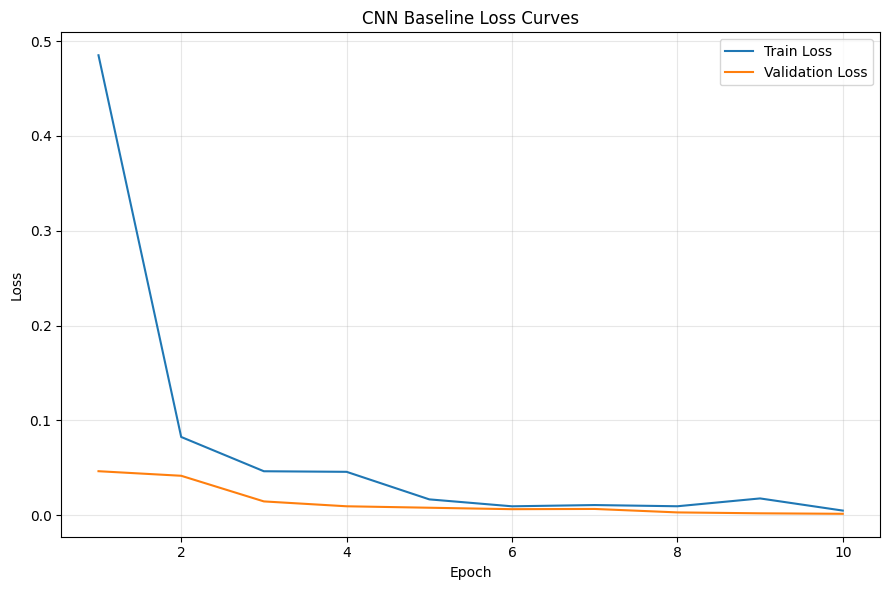

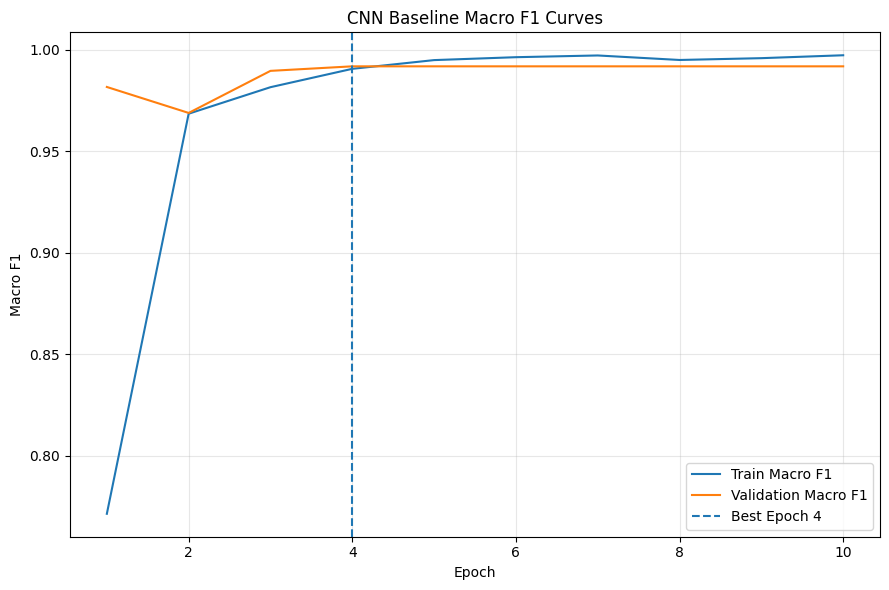

Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/training_curves/cnn_efficientnet_b0_loss_curve_seed42.png
Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/training_curves/cnn_efficientnet_b0_macro_f1_curve_seed42.png


In [12]:
# Cell 12: Plot training curves
fig, axis = plt.subplots(figsize=(9, 6))

axis.plot(
    history_df['epoch'],
    history_df['train_loss'],
    label='Train Loss',
)

axis.plot(
    history_df['epoch'],
    history_df['val_loss'],
    label='Validation Loss',
)

axis.set_xlabel('Epoch')
axis.set_ylabel('Loss')
axis.set_title('CNN Baseline Loss Curves')
axis.legend()
axis.grid(alpha=0.3)

loss_curve_path = (
    FIGURES_DIR
    / 'cnn_efficientnet_b0_loss_curve_seed42.png'
)

plt.tight_layout()
plt.savefig(
    loss_curve_path,
    dpi=200,
    bbox_inches='tight',
)
plt.show()


fig, axis = plt.subplots(figsize=(9, 6))

axis.plot(
    history_df['epoch'],
    history_df['train_macro_f1'],
    label='Train Macro F1',
)

axis.plot(
    history_df['epoch'],
    history_df['val_macro_f1'],
    label='Validation Macro F1',
)

axis.axvline(
    best_epoch,
    linestyle='--',
    label=f'Best Epoch {best_epoch}',
)

axis.set_xlabel('Epoch')
axis.set_ylabel('Macro F1')
axis.set_title('CNN Baseline Macro F1 Curves')
axis.legend()
axis.grid(alpha=0.3)

f1_curve_path = (
    FIGURES_DIR
    / 'cnn_efficientnet_b0_macro_f1_curve_seed42.png'
)

plt.tight_layout()
plt.savefig(
    f1_curve_path,
    dpi=200,
    bbox_inches='tight',
)
plt.show()

print('Saved:', loss_curve_path)
print('Saved:', f1_curve_path)


In [13]:
# Cell 13: Load best checkpoint and evaluate internal test
best_checkpoint = torch.load(
    BEST_CHECKPOINT_PATH,
    map_location=DEVICE,
)

model.load_state_dict(
    best_checkpoint['model_state_dict']
)

internal_metrics, internal_labels, internal_predictions = run_epoch(
    model,
    internal_test_loader,
    criterion,
    optimizer=None,
)

print('Internal-test metrics:')
display(
    pd.DataFrame([internal_metrics])
)

internal_report = classification_report(
    internal_labels,
    internal_predictions,
    labels=[0, 1, 2],
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0,
)

internal_report_df = (
    pd.DataFrame(internal_report)
    .transpose()
    .reset_index()
    .rename(columns={'index': 'class_or_average'})
)

display(internal_report_df)

internal_metrics_path = (
    METRICS_DIR
    / 'cnn_efficientnet_b0_internal_test_metrics_seed42.csv'
)

internal_report_path = (
    METRICS_DIR
    / 'cnn_efficientnet_b0_internal_test_classification_report_seed42.csv'
)

pd.DataFrame([internal_metrics]).to_csv(
    internal_metrics_path,
    index=False,
)

internal_report_df.to_csv(
    internal_report_path,
    index=False,
)

print('Saved:', internal_metrics_path)
print('Saved:', internal_report_path)


Internal-test metrics:


,accuracy,macro_precision,macro_recall,macro_f1,loss
0,1.0,1.0,1.0,1.0,0.002226


,class_or_average,precision,recall,f1-score,support
0,Early_Blight,1.0,1.0,1.0,150.0
1,Late_Blight,1.0,1.0,1.0,150.0
2,Healthy,1.0,1.0,1.0,23.0
3,accuracy,1.0,1.0,1.0,1.0
4,macro avg,1.0,1.0,1.0,323.0
5,weighted avg,1.0,1.0,1.0,323.0


Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/metrics/cnn_efficientnet_b0_internal_test_metrics_seed42.csv
Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/metrics/cnn_efficientnet_b0_internal_test_classification_report_seed42.csv


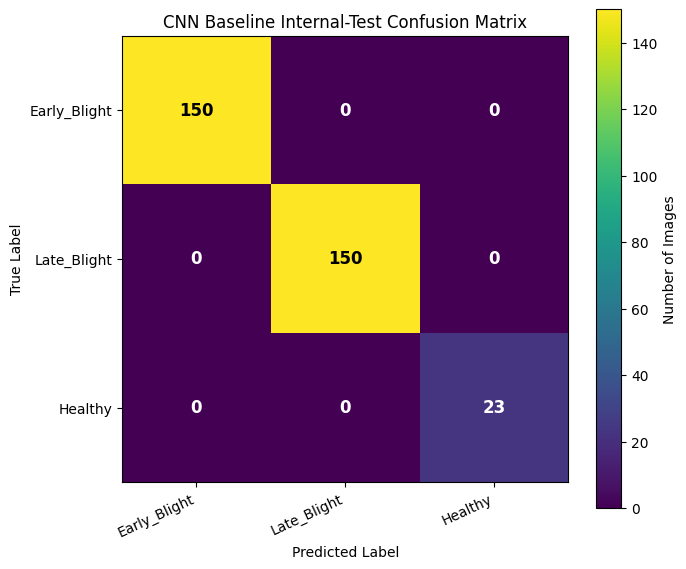

Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/predictions/cnn_efficientnet_b0_internal_test_predictions_seed42.csv
Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/confusion_matrices/cnn_efficientnet_b0_internal_test_confusion_matrix_seed42.png


In [24]:
# Cell 14: Save internal-test predictions and confusion matrix

prediction_df = internal_test_df.copy()

if USE_LOCAL_COPY and "original_drive_path" in prediction_df.columns:
    prediction_df["evaluation_file_path"] = prediction_df[
        "original_drive_path"
    ]
else:
    prediction_df["evaluation_file_path"] = prediction_df["file_path"]

prediction_df["true_class_id"] = internal_labels
prediction_df["predicted_class_id"] = internal_predictions

prediction_df["true_class_name"] = [
    CLASS_NAMES[index]
    for index in internal_labels
]

prediction_df["predicted_class_name"] = [
    CLASS_NAMES[index]
    for index in internal_predictions
]

prediction_df["is_correct"] = (
    prediction_df["true_class_id"]
    == prediction_df["predicted_class_id"]
)

prediction_path = (
    PREDICTIONS_DIR
    / "cnn_efficientnet_b0_internal_test_predictions_seed42.csv"
)

prediction_df.to_csv(
    prediction_path,
    index=False
)

# Confusion matrix
cm = confusion_matrix(
    internal_labels,
    internal_predictions,
    labels=[0, 1, 2]
)

fig, axis = plt.subplots(figsize=(7, 6))

image = axis.imshow(
    cm,
    cmap="viridis"
)

axis.set_xticks(range(len(CLASS_NAMES)))
axis.set_yticks(range(len(CLASS_NAMES)))

axis.set_xticklabels(
    CLASS_NAMES,
    rotation=25,
    ha="right"
)

axis.set_yticklabels(CLASS_NAMES)

axis.set_xlabel("Predicted Label")
axis.set_ylabel("True Label")

axis.set_title(
    "CNN Baseline Internal-Test Confusion Matrix"
)

# Box brightness অনুযায়ী text color
threshold = cm.max() / 2

for row in range(cm.shape[0]):
    for column in range(cm.shape[1]):

        value = cm[row, column]

        text_color = (
            "black"
            if value > threshold
            else "white"
        )

        axis.text(
            column,
            row,
            str(value),
            ha="center",
            va="center",
            color=text_color,
            fontsize=12,
            fontweight="bold"
        )

colorbar = fig.colorbar(
    image,
    ax=axis
)

colorbar.set_label(
    "Number of Images"
)

plt.tight_layout()

confusion_path = (
    CONFUSION_DIR
    / "cnn_efficientnet_b0_internal_test_confusion_matrix_seed42.png"
)

plt.savefig(
    confusion_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Saved:", prediction_path)
print("Saved:", confusion_path)


In [25]:
# Cell 15: Save CNN baseline configuration and summary
config = {
    'created_at': datetime.now().isoformat(),
    'model_name': 'EfficientNet-B0',
    'pretrained_weights': 'EfficientNet_B0_Weights.DEFAULT',
    'seed': RANDOM_SEED,
    'class_names': CLASS_NAMES,
    'image_size': IMAGE_SIZE,
    'resize_size': RESIZE_SIZE,
    'batch_size': BATCH_SIZE,
    'num_workers': NUM_WORKERS,
    'optimizer': 'AdamW',
    'learning_rate': LEARNING_RATE,
    'weight_decay': WEIGHT_DECAY,
    'loss': 'Weighted CrossEntropyLoss',
    'dropout': DROPOUT,
    'max_epochs': MAX_EPOCHS,
    'early_stopping_patience': EARLY_STOPPING_PATIENCE,
    'best_epoch': best_epoch,
    'best_validation_macro_f1': best_val_macro_f1,
    'total_parameters': total_parameters,
    'trainable_parameters': trainable_parameters,
    'internal_test_metrics': internal_metrics,
    'external_test_used': False,
}

config_path = (
    CONFIG_DIR
    / 'cnn_efficientnet_b0_seed42_config.json'
)

with config_path.open(
    'w',
    encoding='utf-8',
) as file_handle:
    json.dump(
        config,
        file_handle,
        ensure_ascii=False,
        indent=2,
    )

summary_df = pd.DataFrame([{
    'model': 'EfficientNet-B0',
    'seed': RANDOM_SEED,
    'best_epoch': best_epoch,
    'best_val_macro_f1': best_val_macro_f1,
    'internal_test_accuracy': internal_metrics['accuracy'],
    'internal_test_macro_precision': internal_metrics['macro_precision'],
    'internal_test_macro_recall': internal_metrics['macro_recall'],
    'internal_test_macro_f1': internal_metrics['macro_f1'],
    'total_parameters': total_parameters,
    'trainable_parameters': trainable_parameters,
    'training_minutes': total_training_seconds / 60,
}])

summary_path = (
    METRICS_DIR
    / 'cnn_efficientnet_b0_summary_seed42.csv'
)

summary_df.to_csv(
    summary_path,
    index=False,
)

display(summary_df)
print('Saved:', config_path)
print('Saved:', summary_path)


,model,seed,best_epoch,best_val_macro_f1,internal_test_accuracy,internal_test_macro_precision,internal_test_macro_recall,internal_test_macro_f1,total_parameters,trainable_parameters,training_minutes
0,EfficientNet-B0,42,4,0.991793,1.0,1.0,1.0,1.0,4011391,4011391,3.645169


Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/03_configs/cnn_efficientnet_b0_seed42_config.json
Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/metrics/cnn_efficientnet_b0_summary_seed42.csv


In [26]:
# Cell 16: Final training report
final_report_df = pd.DataFrame([
    {
        'check': 'CNN model created',
        'passed': model is not None,
    },
    {
        'check': 'Best checkpoint saved',
        'passed': BEST_CHECKPOINT_PATH.exists(),
    },
    {
        'check': 'Training history saved',
        'passed': HISTORY_PATH.exists(),
    },
    {
        'check': 'Loss and F1 curves saved',
        'passed': (
            loss_curve_path.exists()
            and f1_curve_path.exists()
        ),
    },
    {
        'check': 'Internal-test metrics saved',
        'passed': internal_metrics_path.exists(),
    },
    {
        'check': 'Internal-test predictions saved',
        'passed': prediction_path.exists(),
    },
    {
        'check': 'External test not used for tuning',
        'passed': True,
    },
])

display(final_report_df)

if final_report_df['passed'].all():
    print('✅ CNN baseline training completed successfully.')
    print('Next step: 07_ViT_Baseline_Training.ipynb')
else:
    print('⚠️ CNN baseline training completed with warnings.')


,check,passed
0,CNN model created,True
1,Best checkpoint saved,True
2,Training history saved,True
3,Loss and F1 curves saved,True
4,Internal-test metrics saved,True
5,Internal-test predictions saved,True
6,External test not used for tuning,True


✅ CNN baseline training completed successfully.
Next step: 07_ViT_Baseline_Training.ipynb


---

# Part 07 — 07. ViT Baseline Training — DeiT-Tiny

**Purpose:** Train the Vision Transformer baseline with DeiT-Tiny under a fair-comparison protocol matched to the CNN baseline.

**Source notebook:** `07_ViT_Baseline_Training.ipynb`

**Preservation note:** The original code cells and their saved execution outputs are retained below. Textual headings/comments are lightly normalized into English where possible without changing experiment logic.


# 07 — ViT Baseline Training (DeiT-Tiny)

This notebook দ্বিতীয় baseline model train করবে।

## Model
- Pretrained `DeiT-Tiny Patch16 224`
- `timm` library
- Output classes: 3
- `0 = Early_Blight`
- `1 = Late_Blight`
- `2 = Healthy`

## Fair comparison
CNN baseline-এর মতো একই split, preprocessing, weighted loss, optimizer family,
epoch budget, early stopping rule এবং validation Macro F1 checkpoint policy রাখা হয়েছে।
PLDD-UP external dataset will not be used for training or tuning।


In [1]:
# Cell 1: Mount Drive and install timm
from google.colab import drive

drive.mount('/content/drive', force_remount=True)

!pip -q install timm


Mounted at /content/drive


In [2]:
# Cell 2: Imports and reproducibility
from pathlib import Path
from datetime import datetime
import json
import os
import random
import shutil
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

import timm

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
)

RANDOM_SEED = 42
CLASS_NAMES = ['Early_Blight', 'Late_Blight', 'Healthy']
CLASS_ID_MAP = {
    'Early_Blight': 0,
    'Late_Blight': 1,
    'Healthy': 2,
}

IMAGE_SIZE = 224
RESIZE_SIZE = 256
BATCH_SIZE = 16
NUM_WORKERS = 2
MAX_EPOCHS = 25
EARLY_STOPPING_PATIENCE = 6
LEARNING_RATE = 5e-5
WEIGHT_DECAY = 1e-4
DROPOUT = 0.30

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

seed_everything(RANDOM_SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('PyTorch:', torch.__version__)
print('timm:', timm.__version__)
print('Device:', DEVICE)

if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
else:
    print('⚠️ Runtime → Change runtime type → T4 GPU নির্বাচন করো।')


PyTorch: 2.11.0+cu128
timm: 1.0.28
Device: cuda
GPU: Tesla T4


In [3]:
# Cell 3: Locate project folders
MY_DRIVE = Path('/content/drive/MyDrive')

standard_project = MY_DRIVE / 'Potato_CNN_ViT_Research'

if standard_project.is_dir():
    PROJECT_ROOT = standard_project
else:
    matches = [
        path
        for path in MY_DRIVE.rglob('Potato_CNN_ViT_Research')
        if path.is_dir()
    ]

    if not matches:
        raise FileNotFoundError(
            'Potato_CNN_ViT_Research folder My Drive-এ পাওয়া যায়নি।'
        )

    PROJECT_ROOT = matches[0]

DATA_DIR = PROJECT_ROOT / '02_data'
SPLITS_DIR = DATA_DIR / 'splits'
METADATA_DIR = DATA_DIR / 'metadata'
CONFIG_DIR = PROJECT_ROOT / '03_configs'
CHECKPOINT_DIR = PROJECT_ROOT / '04_checkpoints' / 'vit'
METRICS_DIR = PROJECT_ROOT / '05_results' / 'metrics'
FIGURES_DIR = PROJECT_ROOT / '05_results' / 'training_curves'
PREDICTIONS_DIR = PROJECT_ROOT / '05_results' / 'predictions'
CONFUSION_DIR = PROJECT_ROOT / '05_results' / 'confusion_matrices'

for folder in [
    CONFIG_DIR,
    CHECKPOINT_DIR,
    METRICS_DIR,
    FIGURES_DIR,
    PREDICTIONS_DIR,
    CONFUSION_DIR,
]:
    folder.mkdir(parents=True, exist_ok=True)

print('PROJECT_ROOT:', PROJECT_ROOT)
print('CHECKPOINT_DIR:', CHECKPOINT_DIR)


PROJECT_ROOT: /content/drive/MyDrive/Potato_CNN_ViT_Research
CHECKPOINT_DIR: /content/drive/MyDrive/Potato_CNN_ViT_Research/04_checkpoints/vit


In [4]:
# Cell 4: Load split CSVs and class weights
train_path = SPLITS_DIR / 'train.csv'
val_path = SPLITS_DIR / 'val.csv'
internal_test_path = SPLITS_DIR / 'internal_test.csv'
class_weights_path = METADATA_DIR / 'training_class_weights.csv'

for path in [
    train_path,
    val_path,
    internal_test_path,
    class_weights_path,
]:
    if not path.exists():
        raise FileNotFoundError(f'File পাওয়া যায়নি: {path}')

train_df = pd.read_csv(train_path)
val_df = pd.read_csv(val_path)
internal_test_df = pd.read_csv(internal_test_path)
class_weights_df = pd.read_csv(class_weights_path)

for frame_name, frame in [
    ('train', train_df),
    ('val', val_df),
    ('internal_test', internal_test_df),
]:
    frame['file_path'] = frame['file_path'].astype(str)
    frame['class_id'] = frame['class_id'].astype(int)
    frame['unified_class'] = frame['unified_class'].astype(str)

    missing_count = int(
        (~frame['file_path'].map(lambda x: Path(x).exists())).sum()
    )

    if missing_count:
        raise FileNotFoundError(
            f'{frame_name} split-এ {missing_count}টি image path missing।'
        )

class_weights_df = class_weights_df.sort_values('class_id')
class_weights_tensor = torch.tensor(
    class_weights_df['class_weight'].values,
    dtype=torch.float32,
    device=DEVICE,
)

print('Train:', len(train_df))
print('Validation:', len(val_df))
print('Internal test:', len(internal_test_df))
print('Class weights:', class_weights_tensor)


Train: 1506
Validation: 323
Internal test: 323
Class weights: tensor([0.7171, 0.7171, 4.7358], device='cuda:0')


In [5]:
# Cell 5: Optional local copy for faster Colab training
# PlantVillage ছোট হওয়ায় /content-এ copy করলে Drive I/O অনেক কমে।

USE_LOCAL_COPY = True
LOCAL_ROOT = Path('/content/plantvillage_local')

def build_local_path(original_path):
    original_path = Path(original_path)
    class_folder = original_path.parent.name
    return LOCAL_ROOT / class_folder / original_path.name


if USE_LOCAL_COPY:
    source_plant_root = None

    sample_path = Path(train_df.iloc[0]['file_path'])
    source_plant_root = sample_path.parent.parent

    if not LOCAL_ROOT.exists():
        print('PlantVillage dataset /content-এ copy হচ্ছে...')
        shutil.copytree(
            source_plant_root,
            LOCAL_ROOT,
            dirs_exist_ok=True,
        )
        print('Local copy completed.')
    else:
        print('Existing local copy ব্যবহার করা হচ্ছে.')

    for frame in [train_df, val_df, internal_test_df]:
        frame['original_drive_path'] = frame['file_path']
        frame['file_path'] = frame['file_path'].map(
            lambda value: str(build_local_path(value))
        )

        missing_local = int(
            (~frame['file_path'].map(lambda x: Path(x).exists())).sum()
        )

        if missing_local:
            raise FileNotFoundError(
                f'Local copy-তে {missing_local}টি image missing।'
            )

print('Dataset path mode:',
      'Colab local storage' if USE_LOCAL_COPY else 'Google Drive')


PlantVillage dataset /content-এ copy হচ্ছে...
Local copy completed.
Dataset path mode: Colab local storage


In [6]:
# Cell 6: Define preprocessing
train_transform = transforms.Compose([
    transforms.Resize((RESIZE_SIZE, RESIZE_SIZE)),
    transforms.RandomResizedCrop(
        IMAGE_SIZE,
        scale=(0.80, 1.00),
        ratio=(0.90, 1.10),
    ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.10,
        hue=0.02,
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD,
    ),
    transforms.RandomErasing(
        p=0.10,
        scale=(0.02, 0.08),
        ratio=(0.5, 2.0),
        value='random',
    ),
])

eval_transform = transforms.Compose([
    transforms.Resize((RESIZE_SIZE, RESIZE_SIZE)),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD,
    ),
])


In [7]:
# Cell 7: Dataset and DataLoaders
class PotatoLeafDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True).copy()
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]

        with Image.open(row['file_path']) as image:
            image = image.convert('RGB')

        if self.transform is not None:
            image = self.transform(image)

        return {
            'image': image,
            'label': torch.tensor(
                int(row['class_id']),
                dtype=torch.long,
            ),
            'file_path': str(row['file_path']),
            'class_name': str(row['unified_class']),
        }


train_dataset = PotatoLeafDataset(
    train_df,
    transform=train_transform,
)

val_dataset = PotatoLeafDataset(
    val_df,
    transform=eval_transform,
)

internal_test_dataset = PotatoLeafDataset(
    internal_test_df,
    transform=eval_transform,
)

generator = torch.Generator()
generator.manual_seed(RANDOM_SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=(NUM_WORKERS > 0),
    generator=generator,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=(NUM_WORKERS > 0),
)

internal_test_loader = DataLoader(
    internal_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=(NUM_WORKERS > 0),
)

print('Train batches:', len(train_loader))
print('Validation batches:', len(val_loader))
print('Internal-test batches:', len(internal_test_loader))


Train batches: 95
Validation batches: 21
Internal-test batches: 21


In [8]:
# Cell 8: Build DeiT-Tiny baseline
MODEL_CANDIDATES = [
    'deit_tiny_patch16_224.fb_in1k',
    'deit_tiny_patch16_224',
]

model = None
selected_model_name = None
last_error = None

for candidate in MODEL_CANDIDATES:
    try:
        print('Trying:', candidate)
        model = timm.create_model(
            candidate,
            pretrained=True,
            num_classes=len(CLASS_NAMES),
            drop_rate=DROPOUT,
        )
        selected_model_name = candidate
        break
    except Exception as error:
        last_error = error
        print('Could not load:', candidate, error)

if model is None:
    raise RuntimeError(f'DeiT-Tiny load failed: {last_error}')

model = model.to(DEVICE)

total_parameters = sum(p.numel() for p in model.parameters())
trainable_parameters = sum(
    p.numel() for p in model.parameters() if p.requires_grad
)

print('Selected model:', selected_model_name)
print('Total parameters:', f'{total_parameters:,}')
print('Trainable parameters:', f'{trainable_parameters:,}')


Trying: deit_tiny_patch16_224.fb_in1k


model.safetensors: reconstructing file:   0%|          |  0.00B / 22.9MB            

model.safetensors: downloading bytes:           |  0.00B            

Selected model: deit_tiny_patch16_224.fb_in1k
Total parameters: 5,524,995
Trainable parameters: 5,524,995


In [9]:
# Cell 9: Loss, optimizer, scheduler, and AMP
criterion = nn.CrossEntropyLoss(
    weight=class_weights_tensor
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=MAX_EPOCHS,
)

amp_enabled = torch.cuda.is_available()

try:
    scaler = torch.amp.GradScaler(
        'cuda',
        enabled=amp_enabled,
    )
except TypeError:
    scaler = torch.cuda.amp.GradScaler(
        enabled=amp_enabled,
    )

print('AMP enabled:', amp_enabled)


AMP enabled: True


In [10]:
# Cell 10: Metric helpers
def calculate_metrics(y_true, y_pred):
    accuracy = accuracy_score(
        y_true,
        y_pred,
    )

    precision, recall, macro_f1, _ = (
        precision_recall_fscore_support(
            y_true,
            y_pred,
            average='macro',
            zero_division=0,
        )
    )

    return {
        'accuracy': float(accuracy),
        'macro_precision': float(precision),
        'macro_recall': float(recall),
        'macro_f1': float(macro_f1),
    }


def run_epoch(
    model,
    loader,
    criterion,
    optimizer=None,
):
    is_training = optimizer is not None

    if is_training:
        model.train()
    else:
        model.eval()

    running_loss = 0.0
    all_labels = []
    all_predictions = []

    for batch in loader:
        images = batch['image'].to(
            DEVICE,
            non_blocking=True,
        )

        labels = batch['label'].to(
            DEVICE,
            non_blocking=True,
        )

        if is_training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_training):
            try:
                autocast_context = torch.amp.autocast(
                    device_type='cuda',
                    enabled=amp_enabled,
                )
            except TypeError:
                autocast_context = torch.cuda.amp.autocast(
                    enabled=amp_enabled,
                )

            with autocast_context:
                logits = model(images)
                loss = criterion(logits, labels)

            if is_training:
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)

                torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    max_norm=1.0,
                )

                scaler.step(optimizer)
                scaler.update()

        running_loss += (
            loss.item() * images.size(0)
        )

        predictions = logits.argmax(dim=1)

        all_labels.extend(
            labels.detach().cpu().tolist()
        )

        all_predictions.extend(
            predictions.detach().cpu().tolist()
        )

    epoch_loss = running_loss / len(loader.dataset)
    metrics = calculate_metrics(
        all_labels,
        all_predictions,
    )
    metrics['loss'] = float(epoch_loss)

    return metrics, all_labels, all_predictions


In [11]:
# Cell 11: Train with early stopping
BEST_CHECKPOINT_PATH = (
    CHECKPOINT_DIR
    / 'deit_tiny_best_seed42.pth'
)

LAST_CHECKPOINT_PATH = (
    CHECKPOINT_DIR
    / 'deit_tiny_last_seed42.pth'
)

HISTORY_PATH = (
    METRICS_DIR
    / 'cnn_deit_tiny_training_history_seed42.csv'
)

best_val_macro_f1 = -1.0
best_epoch = 0
epochs_without_improvement = 0
history_rows = []

training_start_time = time.time()

for epoch in range(1, MAX_EPOCHS + 1):
    epoch_start_time = time.time()

    train_metrics, _, _ = run_epoch(
        model,
        train_loader,
        criterion,
        optimizer=optimizer,
    )

    val_metrics, _, _ = run_epoch(
        model,
        val_loader,
        criterion,
        optimizer=None,
    )

    scheduler.step()

    current_lr = optimizer.param_groups[0]['lr']
    epoch_seconds = time.time() - epoch_start_time

    history_row = {
        'epoch': epoch,
        'learning_rate': current_lr,
        'train_loss': train_metrics['loss'],
        'train_accuracy': train_metrics['accuracy'],
        'train_macro_precision': train_metrics['macro_precision'],
        'train_macro_recall': train_metrics['macro_recall'],
        'train_macro_f1': train_metrics['macro_f1'],
        'val_loss': val_metrics['loss'],
        'val_accuracy': val_metrics['accuracy'],
        'val_macro_precision': val_metrics['macro_precision'],
        'val_macro_recall': val_metrics['macro_recall'],
        'val_macro_f1': val_metrics['macro_f1'],
        'epoch_seconds': epoch_seconds,
    }

    history_rows.append(history_row)

    pd.DataFrame(history_rows).to_csv(
        HISTORY_PATH,
        index=False,
    )

    print(
        f'Epoch {epoch:02d}/{MAX_EPOCHS} | '
        f'Train Loss {train_metrics["loss"]:.4f} | '
        f'Train F1 {train_metrics["macro_f1"]:.4f} | '
        f'Val Loss {val_metrics["loss"]:.4f} | '
        f'Val F1 {val_metrics["macro_f1"]:.4f} | '
        f'{epoch_seconds:.1f}s'
    )

    checkpoint_payload = {
        'epoch': epoch,
        'model_name': selected_model_name,
        'seed': RANDOM_SEED,
        'class_names': CLASS_NAMES,
        'class_id_map': CLASS_ID_MAP,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'val_metrics': val_metrics,
        'config': {
            'image_size': IMAGE_SIZE,
            'batch_size': BATCH_SIZE,
            'learning_rate': LEARNING_RATE,
            'weight_decay': WEIGHT_DECAY,
            'dropout': DROPOUT,
            'max_epochs': MAX_EPOCHS,
        },
    }

    torch.save(
        checkpoint_payload,
        LAST_CHECKPOINT_PATH,
    )

    if val_metrics['macro_f1'] > best_val_macro_f1:
        best_val_macro_f1 = val_metrics['macro_f1']
        best_epoch = epoch
        epochs_without_improvement = 0

        torch.save(
            checkpoint_payload,
            BEST_CHECKPOINT_PATH,
        )

        print(
            f'✅ Best checkpoint updated '
            f'(Val Macro F1: {best_val_macro_f1:.4f})'
        )
    else:
        epochs_without_improvement += 1

    if (
        epochs_without_improvement
        >= EARLY_STOPPING_PATIENCE
    ):
        print(
            f'Early stopping at epoch {epoch}. '
            f'Best epoch: {best_epoch}'
        )
        break

total_training_seconds = (
    time.time() - training_start_time
)

history_df = pd.DataFrame(history_rows)

print('Training completed.')
print('Best epoch:', best_epoch)
print('Best validation Macro F1:',
      round(best_val_macro_f1, 4))
print('Training minutes:',
      round(total_training_seconds / 60, 2))
print('Best checkpoint:', BEST_CHECKPOINT_PATH)


Epoch 01/25 | Train Loss 0.1851 | Train F1 0.9109 | Val Loss 0.0277 | Val F1 0.9873 | 19.8s
✅ Best checkpoint updated (Val Macro F1: 0.9873)
Epoch 02/25 | Train Loss 0.0419 | Train F1 0.9889 | Val Loss 0.0626 | Val F1 0.9867 | 17.0s
Epoch 03/25 | Train Loss 0.0234 | Train F1 0.9917 | Val Loss 0.0251 | Val F1 0.9896 | 16.7s
✅ Best checkpoint updated (Val Macro F1: 0.9896)
Epoch 04/25 | Train Loss 0.0023 | Train F1 0.9982 | Val Loss 0.0146 | Val F1 0.9978 | 16.6s
✅ Best checkpoint updated (Val Macro F1: 0.9978)
Epoch 05/25 | Train Loss 0.0152 | Train F1 0.9967 | Val Loss 0.0002 | Val F1 1.0000 | 18.0s
✅ Best checkpoint updated (Val Macro F1: 1.0000)
Epoch 06/25 | Train Loss 0.0002 | Train F1 1.0000 | Val Loss 0.0003 | Val F1 1.0000 | 16.4s
Epoch 07/25 | Train Loss 0.0019 | Train F1 1.0000 | Val Loss 0.0002 | Val F1 1.0000 | 17.9s
Epoch 08/25 | Train Loss 0.0062 | Train F1 0.9954 | Val Loss 0.1183 | Val F1 0.9800 | 16.3s
Epoch 09/25 | Train Loss 0.0309 | Train F1 0.9950 | Val Loss 0.1127 

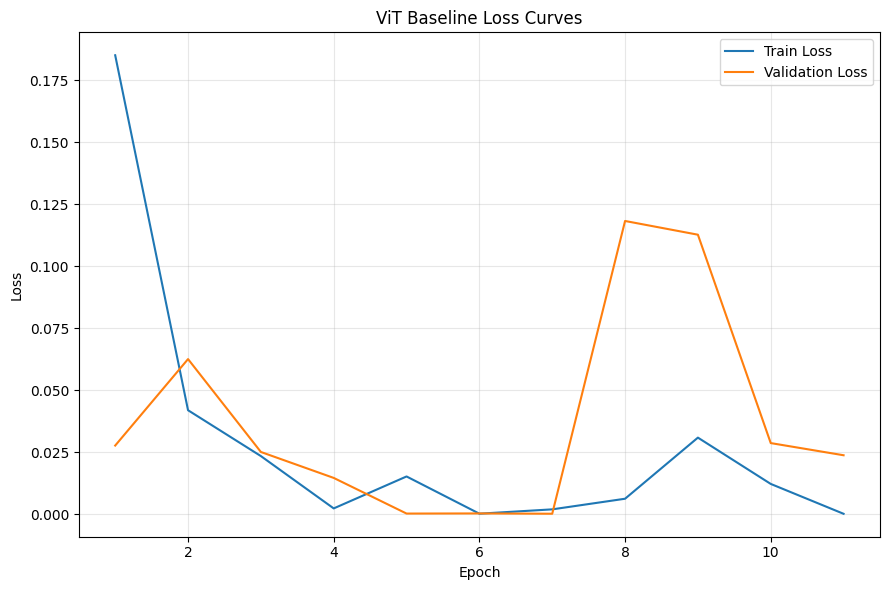

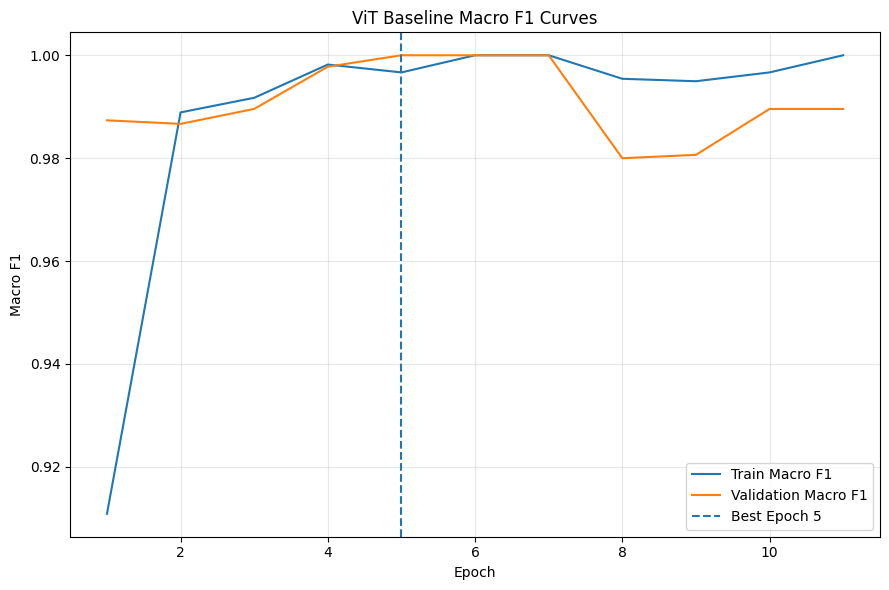

Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/training_curves/cnn_deit_tiny_loss_curve_seed42.png
Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/training_curves/cnn_deit_tiny_macro_f1_curve_seed42.png


In [12]:
# Cell 12: Plot training curves
fig, axis = plt.subplots(figsize=(9, 6))

axis.plot(
    history_df['epoch'],
    history_df['train_loss'],
    label='Train Loss',
)

axis.plot(
    history_df['epoch'],
    history_df['val_loss'],
    label='Validation Loss',
)

axis.set_xlabel('Epoch')
axis.set_ylabel('Loss')
axis.set_title('ViT Baseline Loss Curves')
axis.legend()
axis.grid(alpha=0.3)

loss_curve_path = (
    FIGURES_DIR
    / 'cnn_deit_tiny_loss_curve_seed42.png'
)

plt.tight_layout()
plt.savefig(
    loss_curve_path,
    dpi=200,
    bbox_inches='tight',
)
plt.show()


fig, axis = plt.subplots(figsize=(9, 6))

axis.plot(
    history_df['epoch'],
    history_df['train_macro_f1'],
    label='Train Macro F1',
)

axis.plot(
    history_df['epoch'],
    history_df['val_macro_f1'],
    label='Validation Macro F1',
)

axis.axvline(
    best_epoch,
    linestyle='--',
    label=f'Best Epoch {best_epoch}',
)

axis.set_xlabel('Epoch')
axis.set_ylabel('Macro F1')
axis.set_title('ViT Baseline Macro F1 Curves')
axis.legend()
axis.grid(alpha=0.3)

f1_curve_path = (
    FIGURES_DIR
    / 'cnn_deit_tiny_macro_f1_curve_seed42.png'
)

plt.tight_layout()
plt.savefig(
    f1_curve_path,
    dpi=200,
    bbox_inches='tight',
)
plt.show()

print('Saved:', loss_curve_path)
print('Saved:', f1_curve_path)


In [13]:
# Cell 13: Load best checkpoint and evaluate internal test
best_checkpoint = torch.load(
    BEST_CHECKPOINT_PATH,
    map_location=DEVICE,
)

model.load_state_dict(
    best_checkpoint['model_state_dict']
)

internal_metrics, internal_labels, internal_predictions = run_epoch(
    model,
    internal_test_loader,
    criterion,
    optimizer=None,
)

print('Internal-test metrics:')
display(
    pd.DataFrame([internal_metrics])
)

internal_report = classification_report(
    internal_labels,
    internal_predictions,
    labels=[0, 1, 2],
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0,
)

internal_report_df = (
    pd.DataFrame(internal_report)
    .transpose()
    .reset_index()
    .rename(columns={'index': 'class_or_average'})
)

display(internal_report_df)

internal_metrics_path = (
    METRICS_DIR
    / 'cnn_deit_tiny_internal_test_metrics_seed42.csv'
)

internal_report_path = (
    METRICS_DIR
    / 'cnn_deit_tiny_internal_test_classification_report_seed42.csv'
)

pd.DataFrame([internal_metrics]).to_csv(
    internal_metrics_path,
    index=False,
)

internal_report_df.to_csv(
    internal_report_path,
    index=False,
)

print('Saved:', internal_metrics_path)
print('Saved:', internal_report_path)


Internal-test metrics:


,accuracy,macro_precision,macro_recall,macro_f1,loss
0,1.0,1.0,1.0,1.0,0.000177


,class_or_average,precision,recall,f1-score,support
0,Early_Blight,1.0,1.0,1.0,150.0
1,Late_Blight,1.0,1.0,1.0,150.0
2,Healthy,1.0,1.0,1.0,23.0
3,accuracy,1.0,1.0,1.0,1.0
4,macro avg,1.0,1.0,1.0,323.0
5,weighted avg,1.0,1.0,1.0,323.0


Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/metrics/cnn_deit_tiny_internal_test_metrics_seed42.csv
Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/metrics/cnn_deit_tiny_internal_test_classification_report_seed42.csv


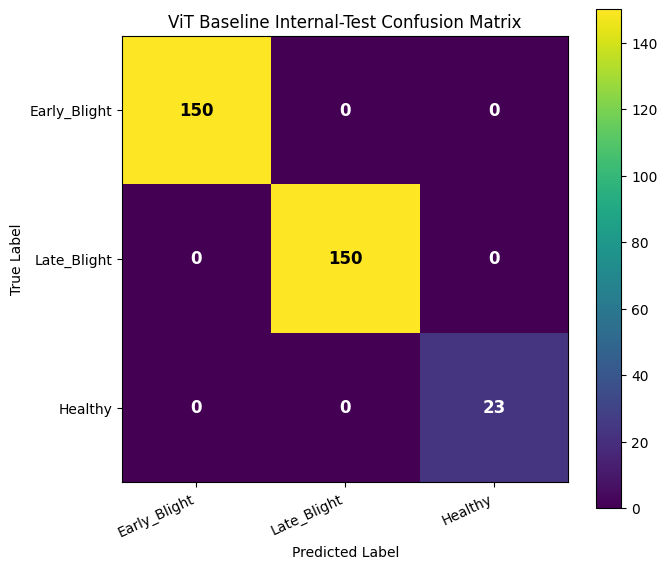

Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/predictions/cnn_deit_tiny_internal_test_predictions_seed42.csv
Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/confusion_matrices/cnn_deit_tiny_internal_test_confusion_matrix_seed42.png


In [17]:
# Cell 14: Save internal-test predictions and confusion matrix
prediction_df = internal_test_df.copy()

if USE_LOCAL_COPY and 'original_drive_path' in prediction_df.columns:
    prediction_df['evaluation_file_path'] = prediction_df['file_path']
else:
    prediction_df['evaluation_file_path'] = prediction_df['file_path']

prediction_df['true_class_id'] = internal_labels
prediction_df['predicted_class_id'] = internal_predictions
prediction_df['true_class_name'] = [
    CLASS_NAMES[index]
    for index in internal_labels
]
prediction_df['predicted_class_name'] = [
    CLASS_NAMES[index]
    for index in internal_predictions
]
prediction_df['is_correct'] = (
    prediction_df['true_class_id']
    == prediction_df['predicted_class_id']
)

prediction_path = (
    PREDICTIONS_DIR
    / 'cnn_deit_tiny_internal_test_predictions_seed42.csv'
)

prediction_df.to_csv(
    prediction_path,
    index=False,
)

cm = confusion_matrix(
    internal_labels,
    internal_predictions,
    labels=[0, 1, 2],
)

fig, axis = plt.subplots(figsize=(7, 6))

image = axis.imshow(cm)

axis.set_xticks(range(3))
axis.set_yticks(range(3))
axis.set_xticklabels(CLASS_NAMES, rotation=25, ha='right')
axis.set_yticklabels(CLASS_NAMES)
axis.set_xlabel('Predicted Label')
axis.set_ylabel('True Label')
axis.set_title('ViT Baseline Internal-Test Confusion Matrix')

# Box brightness অনুযায়ী text color
threshold = cm.max() / 2

for row in range(cm.shape[0]):
    for column in range(cm.shape[1]):

        value = cm[row, column]

        text_color = (
            "black"
            if value > threshold
            else "white"
        )

        axis.text(
            column,
            row,
            str(value),
            ha="center",
            va="center",
            color=text_color,
            fontsize=12,
            fontweight="bold"
        )

colorbar = fig.colorbar(
    image,
    ax=axis
)


plt.tight_layout()

confusion_path = (
    CONFUSION_DIR
    / 'cnn_deit_tiny_internal_test_confusion_matrix_seed42.png'
)

plt.savefig(
    confusion_path,
    dpi=200,
    bbox_inches='tight',
)

plt.show()

print('Saved:', prediction_path)
print('Saved:', confusion_path)


In [15]:
# Cell 15: Save ViT baseline configuration and summary
config = {
    'created_at': datetime.now().isoformat(),
    'model_name': selected_model_name,
    'pretrained_weights': 'timm pretrained ImageNet-1K weights',
    'seed': RANDOM_SEED,
    'class_names': CLASS_NAMES,
    'image_size': IMAGE_SIZE,
    'resize_size': RESIZE_SIZE,
    'batch_size': BATCH_SIZE,
    'num_workers': NUM_WORKERS,
    'optimizer': 'AdamW',
    'learning_rate': LEARNING_RATE,
    'weight_decay': WEIGHT_DECAY,
    'loss': 'Weighted CrossEntropyLoss',
    'dropout': DROPOUT,
    'max_epochs': MAX_EPOCHS,
    'early_stopping_patience': EARLY_STOPPING_PATIENCE,
    'best_epoch': best_epoch,
    'best_validation_macro_f1': best_val_macro_f1,
    'total_parameters': total_parameters,
    'trainable_parameters': trainable_parameters,
    'internal_test_metrics': internal_metrics,
    'external_test_used': False,
}

config_path = (
    CONFIG_DIR
    / 'cnn_deit_tiny_seed42_config.json'
)

with config_path.open(
    'w',
    encoding='utf-8',
) as file_handle:
    json.dump(
        config,
        file_handle,
        ensure_ascii=False,
        indent=2,
    )

summary_df = pd.DataFrame([{
    'model': selected_model_name,
    'seed': RANDOM_SEED,
    'best_epoch': best_epoch,
    'best_val_macro_f1': best_val_macro_f1,
    'internal_test_accuracy': internal_metrics['accuracy'],
    'internal_test_macro_precision': internal_metrics['macro_precision'],
    'internal_test_macro_recall': internal_metrics['macro_recall'],
    'internal_test_macro_f1': internal_metrics['macro_f1'],
    'total_parameters': total_parameters,
    'trainable_parameters': trainable_parameters,
    'training_minutes': total_training_seconds / 60,
}])

summary_path = (
    METRICS_DIR
    / 'cnn_deit_tiny_summary_seed42.csv'
)

summary_df.to_csv(
    summary_path,
    index=False,
)

display(summary_df)
print('Saved:', config_path)
print('Saved:', summary_path)


,model,seed,best_epoch,best_val_macro_f1,internal_test_accuracy,internal_test_macro_precision,internal_test_macro_recall,internal_test_macro_f1,total_parameters,trainable_parameters,training_minutes
0,deit_tiny_patch16_224.fb_in1k,42,5,1.0,1.0,1.0,1.0,1.0,5524995,5524995,3.302396


Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/03_configs/cnn_deit_tiny_seed42_config.json
Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/metrics/cnn_deit_tiny_summary_seed42.csv


In [16]:
# Cell 16: Final training report
final_report_df = pd.DataFrame([
    {
        'check': 'CNN model created',
        'passed': model is not None,
    },
    {
        'check': 'Best checkpoint saved',
        'passed': BEST_CHECKPOINT_PATH.exists(),
    },
    {
        'check': 'Training history saved',
        'passed': HISTORY_PATH.exists(),
    },
    {
        'check': 'Loss and F1 curves saved',
        'passed': (
            loss_curve_path.exists()
            and f1_curve_path.exists()
        ),
    },
    {
        'check': 'Internal-test metrics saved',
        'passed': internal_metrics_path.exists(),
    },
    {
        'check': 'Internal-test predictions saved',
        'passed': prediction_path.exists(),
    },
    {
        'check': 'External test not used for tuning',
        'passed': True,
    },
])

display(final_report_df)

if final_report_df['passed'].all():
    print('✅ ViT baseline training completed successfully.')
    print('Next step: 08_CNN_ViT_Concatenation_Training.ipynb')
else:
    print('⚠️ ViT baseline training completed with warnings.')


,check,passed
0,CNN model created,True
1,Best checkpoint saved,True
2,Training history saved,True
3,Loss and F1 curves saved,True
4,Internal-test metrics saved,True
5,Internal-test predictions saved,True
6,External test not used for tuning,True


✅ ViT baseline training completed successfully.
Next step: 08_CNN_ViT_Concatenation_Training.ipynb


---

# Part 08 — 08. CNN–ViT Concatenation Training

**Purpose:** Train the simple hybrid baseline by concatenating EfficientNet-B0 and DeiT-Tiny features before classification.

**Source notebook:** `08_CNN_ViT_Concatenation_Training.ipynb`

**Preservation note:** The original code cells and their saved execution outputs are retained below. Textual headings/comments are lightly normalized into English where possible without changing experiment logic.


# 08 — CNN–ViT Concatenation Training

This notebook তৃতীয় model train করবে:

## Model
- CNN branch: pretrained `EfficientNet-B0`
- ViT branch: pretrained `DeiT-Tiny Patch16 224`
- Fusion: CNN feature এবং ViT feature সরাসরি concatenate
- Classifier: concatenated feature → normalization → dropout → linear classifier
- Output classes: 3

## Fair-comparison policy
- একই PlantVillage train/validation/internal-test split
- একই input size ও preprocessing
- একই weighted Cross-Entropy loss
- Validation Macro F1 দিয়ে best checkpoint নির্বাচন
- PLDD-UP external dataset will not be used for training or tuning

এটি **simple concatenation baseline**। পরের model-এ attention-guided fusion ব্যবহার করা হবে।


In [1]:
# Cell 1: Mount Google Drive and install timm
from google.colab import drive

drive.mount('/content/drive', force_remount=True)

!pip -q install timm


Mounted at /content/drive


In [2]:
# Cell 2: Imports and reproducibility
from pathlib import Path
from datetime import datetime
import json
import os
import random
import shutil
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import (
    efficientnet_b0,
    EfficientNet_B0_Weights,
)

import timm

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
)

RANDOM_SEED = 42

CLASS_NAMES = [
    'Early_Blight',
    'Late_Blight',
    'Healthy',
]

CLASS_ID_MAP = {
    'Early_Blight': 0,
    'Late_Blight': 1,
    'Healthy': 2,
}

IMAGE_SIZE = 224
RESIZE_SIZE = 256

# Dual backbone হওয়ায় baseline notebooks-এর তুলনায় batch size ছোট রাখা হয়েছে।
BATCH_SIZE = 8
NUM_WORKERS = 2

MAX_EPOCHS = 25
EARLY_STOPPING_PATIENCE = 6

LEARNING_RATE = 3e-5
WEIGHT_DECAY = 1e-4
DROPOUT = 0.35
FUSION_HIDDEN_DIM = 512

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]


def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)


seed_everything(RANDOM_SEED)

DEVICE = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
)

print('PyTorch:', torch.__version__)
print('timm:', timm.__version__)
print('Device:', DEVICE)

if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
else:
    print('⚠️ Runtime → Change runtime type → T4 GPU নির্বাচন করো।')


PyTorch: 2.11.0+cu128
timm: 1.0.28
Device: cuda
GPU: Tesla T4


In [3]:
# Cell 3: Locate project folders
MY_DRIVE = Path('/content/drive/MyDrive')

standard_project = (
    MY_DRIVE / 'Potato_CNN_ViT_Research'
)

if standard_project.is_dir():
    PROJECT_ROOT = standard_project
else:
    matches = [
        path
        for path in MY_DRIVE.rglob(
            'Potato_CNN_ViT_Research'
        )
        if path.is_dir()
    ]

    if not matches:
        raise FileNotFoundError(
            'Potato_CNN_ViT_Research folder My Drive-এ পাওয়া যায়নি।'
        )

    PROJECT_ROOT = matches[0]

DATA_DIR = PROJECT_ROOT / '02_data'
SPLITS_DIR = DATA_DIR / 'splits'
METADATA_DIR = DATA_DIR / 'metadata'

CONFIG_DIR = PROJECT_ROOT / '03_configs'
CHECKPOINT_DIR = (
    PROJECT_ROOT / '04_checkpoints' / 'concat'
)
METRICS_DIR = (
    PROJECT_ROOT / '05_results' / 'metrics'
)
FIGURES_DIR = (
    PROJECT_ROOT
    / '05_results'
    / 'training_curves'
)
PREDICTIONS_DIR = (
    PROJECT_ROOT
    / '05_results'
    / 'predictions'
)
CONFUSION_DIR = (
    PROJECT_ROOT
    / '05_results'
    / 'confusion_matrices'
)

for folder in [
    CONFIG_DIR,
    CHECKPOINT_DIR,
    METRICS_DIR,
    FIGURES_DIR,
    PREDICTIONS_DIR,
    CONFUSION_DIR,
]:
    folder.mkdir(
        parents=True,
        exist_ok=True,
    )

print('PROJECT_ROOT:', PROJECT_ROOT)
print('CHECKPOINT_DIR:', CHECKPOINT_DIR)


PROJECT_ROOT: /content/drive/MyDrive/Potato_CNN_ViT_Research
CHECKPOINT_DIR: /content/drive/MyDrive/Potato_CNN_ViT_Research/04_checkpoints/concat


In [4]:
# Cell 4: Load split CSV files and class weights
train_path = SPLITS_DIR / 'train.csv'
val_path = SPLITS_DIR / 'val.csv'

internal_test_path = (
    SPLITS_DIR / 'internal_test.csv'
)

class_weights_path = (
    METADATA_DIR
    / 'training_class_weights.csv'
)

for path in [
    train_path,
    val_path,
    internal_test_path,
    class_weights_path,
]:
    if not path.exists():
        raise FileNotFoundError(
            f'File পাওয়া যায়নি: {path}'
        )

train_df = pd.read_csv(train_path)
val_df = pd.read_csv(val_path)

internal_test_df = pd.read_csv(
    internal_test_path
)

class_weights_df = pd.read_csv(
    class_weights_path
)

for frame_name, frame in [
    ('train', train_df),
    ('val', val_df),
    ('internal_test', internal_test_df),
]:
    frame['file_path'] = (
        frame['file_path'].astype(str)
    )

    frame['class_id'] = (
        frame['class_id'].astype(int)
    )

    frame['unified_class'] = (
        frame['unified_class'].astype(str)
    )

    missing_count = int(
        (
            ~frame['file_path'].map(
                lambda value: Path(value).exists()
            )
        ).sum()
    )

    if missing_count:
        raise FileNotFoundError(
            f'{frame_name} split-এ '
            f'{missing_count}টি image path missing।'
        )

class_weights_df = (
    class_weights_df.sort_values(
        'class_id'
    )
)

class_weights_tensor = torch.tensor(
    class_weights_df[
        'class_weight'
    ].values,
    dtype=torch.float32,
    device=DEVICE,
)

print('Train:', len(train_df))
print('Validation:', len(val_df))
print('Internal test:', len(internal_test_df))
print('Class weights:', class_weights_tensor)


Train: 1506
Validation: 323
Internal test: 323
Class weights: tensor([0.7171, 0.7171, 4.7358], device='cuda:0')


In [5]:
# Cell 5: Copy PlantVillage to Colab local storage
USE_LOCAL_COPY = True

LOCAL_ROOT = Path(
    '/content/plantvillage_local'
)


def build_local_path(original_path):
    original_path = Path(original_path)

    return (
        LOCAL_ROOT
        / original_path.parent.name
        / original_path.name
    )


if USE_LOCAL_COPY:
    sample_path = Path(
        train_df.iloc[0]['file_path']
    )

    source_plant_root = (
        sample_path.parent.parent
    )

    if not LOCAL_ROOT.exists():
        print(
            'PlantVillage dataset '
            '/content-এ copy হচ্ছে...'
        )

        shutil.copytree(
            source_plant_root,
            LOCAL_ROOT,
            dirs_exist_ok=True,
        )

        print('Local copy completed.')
    else:
        print(
            'Existing local copy ব্যবহার করা হচ্ছে।'
        )

    for frame in [
        train_df,
        val_df,
        internal_test_df,
    ]:
        frame['original_drive_path'] = (
            frame['file_path']
        )

        frame['file_path'] = (
            frame['file_path'].map(
                lambda value: str(
                    build_local_path(value)
                )
            )
        )

        missing_local = int(
            (
                ~frame['file_path'].map(
                    lambda value: Path(value).exists()
                )
            ).sum()
        )

        if missing_local:
            raise FileNotFoundError(
                f'Local copy-তে '
                f'{missing_local}টি image missing।'
            )

print(
    'Dataset path mode:',
    (
        'Colab local storage'
        if USE_LOCAL_COPY
        else 'Google Drive'
    ),
)


PlantVillage dataset /content-এ copy হচ্ছে...
Local copy completed.
Dataset path mode: Colab local storage


In [6]:
# Cell 6: Define preprocessing
train_transform = transforms.Compose([
    transforms.Resize(
        (RESIZE_SIZE, RESIZE_SIZE)
    ),

    transforms.RandomResizedCrop(
        IMAGE_SIZE,
        scale=(0.80, 1.00),
        ratio=(0.90, 1.10),
    ),

    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.RandomRotation(
        degrees=15
    ),

    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.10,
        hue=0.02,
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD,
    ),

    transforms.RandomErasing(
        p=0.10,
        scale=(0.02, 0.08),
        ratio=(0.5, 2.0),
        value='random',
    ),
])

eval_transform = transforms.Compose([
    transforms.Resize(
        (RESIZE_SIZE, RESIZE_SIZE)
    ),

    transforms.CenterCrop(
        IMAGE_SIZE
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD,
    ),
])


In [7]:
# Cell 7: Dataset and DataLoaders
class PotatoLeafDataset(Dataset):
    def __init__(
        self,
        dataframe,
        transform=None,
    ):
        self.dataframe = (
            dataframe.reset_index(
                drop=True
            ).copy()
        )

        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]

        with Image.open(
            row['file_path']
        ) as image:
            image = image.convert('RGB')

        if self.transform is not None:
            image = self.transform(image)

        return {
            'image': image,

            'label': torch.tensor(
                int(row['class_id']),
                dtype=torch.long,
            ),

            'file_path': str(
                row['file_path']
            ),

            'class_name': str(
                row['unified_class']
            ),
        }


train_dataset = PotatoLeafDataset(
    train_df,
    transform=train_transform,
)

val_dataset = PotatoLeafDataset(
    val_df,
    transform=eval_transform,
)

internal_test_dataset = (
    PotatoLeafDataset(
        internal_test_df,
        transform=eval_transform,
    )
)

generator = torch.Generator()
generator.manual_seed(RANDOM_SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=(
        NUM_WORKERS > 0
    ),
    generator=generator,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=(
        NUM_WORKERS > 0
    ),
)

internal_test_loader = DataLoader(
    internal_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=(
        NUM_WORKERS > 0
    ),
)

print('Train batches:', len(train_loader))
print('Validation batches:', len(val_loader))
print(
    'Internal-test batches:',
    len(internal_test_loader),
)


Train batches: 189
Validation batches: 41
Internal-test batches: 41


In [8]:
# Cell 8: Build simple CNN–ViT concatenation model
class CNNViTConcatenationModel(nn.Module):
    def __init__(
        self,
        num_classes,
        hidden_dim,
        dropout,
    ):
        super().__init__()

        # CNN feature extractor
        cnn_model = efficientnet_b0(
            weights=EfficientNet_B0_Weights.DEFAULT
        )

        self.cnn_features = cnn_model.features
        self.cnn_pool = nn.AdaptiveAvgPool2d(1)
        self.cnn_feature_dim = (
            cnn_model.classifier[1].in_features
        )

        # ViT feature extractor
        model_candidates = [
            'deit_tiny_patch16_224.fb_in1k',
            'deit_tiny_patch16_224',
        ]

        self.vit_backbone = None
        self.vit_model_name = None
        last_error = None

        for candidate in model_candidates:
            try:
                print('Trying ViT branch:', candidate)

                self.vit_backbone = timm.create_model(
                    candidate,
                    pretrained=True,
                    num_classes=0,
                    global_pool='avg',
                )

                self.vit_model_name = candidate
                break

            except Exception as error:
                last_error = error
                print(
                    'Could not load:',
                    candidate,
                    error,
                )

        if self.vit_backbone is None:
            raise RuntimeError(
                f'ViT branch load failed: {last_error}'
            )

        self.vit_feature_dim = (
            self.vit_backbone.num_features
        )

        self.concatenated_dim = (
            self.cnn_feature_dim
            + self.vit_feature_dim
        )

        self.classifier = nn.Sequential(
            nn.LayerNorm(
                self.concatenated_dim
            ),

            nn.Dropout(
                p=dropout
            ),

            nn.Linear(
                self.concatenated_dim,
                hidden_dim,
            ),

            nn.GELU(),

            nn.Dropout(
                p=dropout
            ),

            nn.Linear(
                hidden_dim,
                num_classes,
            ),
        )

    def forward(self, images):
        cnn_map = self.cnn_features(images)

        cnn_features = (
            self.cnn_pool(cnn_map)
            .flatten(1)
        )

        vit_features = (
            self.vit_backbone(images)
        )

        fused_features = torch.cat(
            [cnn_features, vit_features],
            dim=1,
        )

        logits = self.classifier(
            fused_features
        )

        return logits


model = CNNViTConcatenationModel(
    num_classes=len(CLASS_NAMES),
    hidden_dim=FUSION_HIDDEN_DIM,
    dropout=DROPOUT,
).to(DEVICE)

total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print('CNN feature dim:', model.cnn_feature_dim)
print('ViT feature dim:', model.vit_feature_dim)
print('Concatenated dim:', model.concatenated_dim)
print('ViT branch:', model.vit_model_name)
print('Total parameters:', f'{total_parameters:,}')
print('Trainable parameters:', f'{trainable_parameters:,}')


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 114MB/s] 


Trying ViT branch: deit_tiny_patch16_224.fb_in1k


model.safetensors: reconstructing file:   0%|          |  0.00B / 22.9MB            

model.safetensors: downloading bytes:           |  0.00B            

CNN feature dim: 1280
ViT feature dim: 192
Concatenated dim: 1472
ViT branch: deit_tiny_patch16_224.fb_in1k
Total parameters: 10,290,623
Trainable parameters: 10,290,623


In [9]:
# Cell 9: Forward-pass verification
test_batch = next(iter(train_loader))

test_images = test_batch['image'].to(DEVICE)

with torch.no_grad():
    test_logits = model(test_images)

print('Input batch shape:', tuple(test_images.shape))
print('Output logits shape:', tuple(test_logits.shape))

expected_shape = (
    test_images.shape[0],
    len(CLASS_NAMES),
)

if tuple(test_logits.shape) != expected_shape:
    raise RuntimeError(
        f'Wrong output shape: {tuple(test_logits.shape)}'
    )

print('✅ Forward pass successful.')


Input batch shape: (8, 3, 224, 224)
Output logits shape: (8, 3)
✅ Forward pass successful.


In [10]:
# Cell 10: Loss, optimizer, scheduler, and AMP
criterion = nn.CrossEntropyLoss(
    weight=class_weights_tensor
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

scheduler = (
    torch.optim.lr_scheduler
    .CosineAnnealingLR(
        optimizer,
        T_max=MAX_EPOCHS,
    )
)

amp_enabled = torch.cuda.is_available()

try:
    scaler = torch.amp.GradScaler(
        'cuda',
        enabled=amp_enabled,
    )
except TypeError:
    scaler = torch.cuda.amp.GradScaler(
        enabled=amp_enabled,
    )

print('AMP enabled:', amp_enabled)


AMP enabled: True


In [11]:
# Cell 11: Metric and epoch helpers
def calculate_metrics(
    y_true,
    y_pred,
):
    accuracy = accuracy_score(
        y_true,
        y_pred,
    )

    precision, recall, macro_f1, _ = (
        precision_recall_fscore_support(
            y_true,
            y_pred,
            average='macro',
            zero_division=0,
        )
    )

    return {
        'accuracy': float(accuracy),
        'macro_precision': float(
            precision
        ),
        'macro_recall': float(recall),
        'macro_f1': float(macro_f1),
    }


def run_epoch(
    model,
    loader,
    criterion,
    optimizer=None,
):
    is_training = optimizer is not None

    if is_training:
        model.train()
    else:
        model.eval()

    running_loss = 0.0
    all_labels = []
    all_predictions = []

    for batch in loader:
        images = batch['image'].to(
            DEVICE,
            non_blocking=True,
        )

        labels = batch['label'].to(
            DEVICE,
            non_blocking=True,
        )

        if is_training:
            optimizer.zero_grad(
                set_to_none=True
            )

        with torch.set_grad_enabled(
            is_training
        ):
            try:
                autocast_context = (
                    torch.amp.autocast(
                        device_type='cuda',
                        enabled=amp_enabled,
                    )
                )
            except TypeError:
                autocast_context = (
                    torch.cuda.amp.autocast(
                        enabled=amp_enabled,
                    )
                )

            with autocast_context:
                logits = model(images)

                loss = criterion(
                    logits,
                    labels,
                )

            if is_training:
                scaler.scale(
                    loss
                ).backward()

                scaler.unscale_(
                    optimizer
                )

                torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    max_norm=1.0,
                )

                scaler.step(
                    optimizer
                )

                scaler.update()

        running_loss += (
            loss.item()
            * images.size(0)
        )

        predictions = logits.argmax(
            dim=1
        )

        all_labels.extend(
            labels.detach().cpu().tolist()
        )

        all_predictions.extend(
            predictions.detach().cpu().tolist()
        )

    epoch_loss = (
        running_loss
        / len(loader.dataset)
    )

    metrics = calculate_metrics(
        all_labels,
        all_predictions,
    )

    metrics['loss'] = float(
        epoch_loss
    )

    return (
        metrics,
        all_labels,
        all_predictions,
    )


In [12]:
# Cell 12: Train concatenation model with early stopping
BEST_CHECKPOINT_PATH = (
    CHECKPOINT_DIR
    / 'cnn_vit_concat_best_seed42.pth'
)

LAST_CHECKPOINT_PATH = (
    CHECKPOINT_DIR
    / 'cnn_vit_concat_last_seed42.pth'
)

HISTORY_PATH = (
    METRICS_DIR
    / 'cnn_vit_concat_training_history_seed42.csv'
)

best_val_macro_f1 = -1.0
best_epoch = 0
epochs_without_improvement = 0
history_rows = []

training_start_time = time.time()

for epoch in range(
    1,
    MAX_EPOCHS + 1,
):
    epoch_start_time = time.time()

    train_metrics, _, _ = run_epoch(
        model,
        train_loader,
        criterion,
        optimizer=optimizer,
    )

    val_metrics, _, _ = run_epoch(
        model,
        val_loader,
        criterion,
        optimizer=None,
    )

    scheduler.step()

    current_lr = (
        optimizer.param_groups[0]['lr']
    )

    epoch_seconds = (
        time.time() - epoch_start_time
    )

    history_row = {
        'epoch': epoch,
        'learning_rate': current_lr,
        'train_loss': train_metrics['loss'],
        'train_accuracy': train_metrics['accuracy'],
        'train_macro_precision': train_metrics['macro_precision'],
        'train_macro_recall': train_metrics['macro_recall'],
        'train_macro_f1': train_metrics['macro_f1'],
        'val_loss': val_metrics['loss'],
        'val_accuracy': val_metrics['accuracy'],
        'val_macro_precision': val_metrics['macro_precision'],
        'val_macro_recall': val_metrics['macro_recall'],
        'val_macro_f1': val_metrics['macro_f1'],
        'epoch_seconds': epoch_seconds,
    }

    history_rows.append(
        history_row
    )

    pd.DataFrame(
        history_rows
    ).to_csv(
        HISTORY_PATH,
        index=False,
    )

    print(
        f'Epoch {epoch:02d}/{MAX_EPOCHS} | '
        f'Train Loss {train_metrics["loss"]:.4f} | '
        f'Train F1 {train_metrics["macro_f1"]:.4f} | '
        f'Val Loss {val_metrics["loss"]:.4f} | '
        f'Val F1 {val_metrics["macro_f1"]:.4f} | '
        f'{epoch_seconds:.1f}s'
    )

    checkpoint_payload = {
        'epoch': epoch,
        'model_name':
            'CNN_ViT_Simple_Concatenation',
        'cnn_branch':
            'EfficientNet-B0',
        'vit_branch':
            model.vit_model_name,
        'fusion':
            'Direct feature concatenation',
        'seed': RANDOM_SEED,
        'class_names': CLASS_NAMES,
        'class_id_map': CLASS_ID_MAP,

        'model_state_dict':
            model.state_dict(),

        'optimizer_state_dict':
            optimizer.state_dict(),

        'scheduler_state_dict':
            scheduler.state_dict(),

        'val_metrics':
            val_metrics,

        'config': {
            'image_size': IMAGE_SIZE,
            'batch_size': BATCH_SIZE,
            'learning_rate':
                LEARNING_RATE,
            'weight_decay':
                WEIGHT_DECAY,
            'dropout': DROPOUT,
            'fusion_hidden_dim':
                FUSION_HIDDEN_DIM,
            'max_epochs': MAX_EPOCHS,
        },
    }

    torch.save(
        checkpoint_payload,
        LAST_CHECKPOINT_PATH,
    )

    if (
        val_metrics['macro_f1']
        > best_val_macro_f1
    ):
        best_val_macro_f1 = (
            val_metrics['macro_f1']
        )

        best_epoch = epoch
        epochs_without_improvement = 0

        torch.save(
            checkpoint_payload,
            BEST_CHECKPOINT_PATH,
        )

        print(
            '✅ Best checkpoint updated '
            f'(Val Macro F1: '
            f'{best_val_macro_f1:.4f})'
        )

    else:
        epochs_without_improvement += 1

    if (
        epochs_without_improvement
        >= EARLY_STOPPING_PATIENCE
    ):
        print(
            f'Early stopping at epoch '
            f'{epoch}. '
            f'Best epoch: {best_epoch}'
        )

        break

total_training_seconds = (
    time.time()
    - training_start_time
)

history_df = pd.DataFrame(
    history_rows
)

print('Training completed.')
print('Best epoch:', best_epoch)
print(
    'Best validation Macro F1:',
    round(best_val_macro_f1, 4),
)
print(
    'Training minutes:',
    round(
        total_training_seconds / 60,
        2,
    ),
)
print(
    'Best checkpoint:',
    BEST_CHECKPOINT_PATH,
)


Epoch 01/25 | Train Loss 0.3180 | Train F1 0.8708 | Val Loss 0.0997 | Val F1 0.9482 | 61.1s
✅ Best checkpoint updated (Val Macro F1: 0.9482)
Epoch 02/25 | Train Loss 0.0155 | Train F1 0.9945 | Val Loss 0.0547 | Val F1 0.9851 | 29.5s
✅ Best checkpoint updated (Val Macro F1: 0.9851)
Epoch 03/25 | Train Loss 0.0062 | Train F1 0.9968 | Val Loss 0.0460 | Val F1 0.9873 | 34.4s
✅ Best checkpoint updated (Val Macro F1: 0.9873)
Epoch 04/25 | Train Loss 0.0178 | Train F1 0.9926 | Val Loss 0.0429 | Val F1 0.9933 | 32.8s
✅ Best checkpoint updated (Val Macro F1: 0.9933)
Epoch 05/25 | Train Loss 0.0003 | Train F1 1.0000 | Val Loss 0.0207 | Val F1 0.9978 | 33.1s
✅ Best checkpoint updated (Val Macro F1: 0.9978)
Epoch 06/25 | Train Loss 0.0031 | Train F1 0.9995 | Val Loss 0.0492 | Val F1 0.9933 | 33.6s
Epoch 07/25 | Train Loss 0.0204 | Train F1 0.9967 | Val Loss 0.0315 | Val F1 0.9933 | 30.6s
Epoch 08/25 | Train Loss 0.0041 | Train F1 0.9972 | Val Loss 0.0002 | Val F1 1.0000 | 29.4s
✅ Best checkpoint u

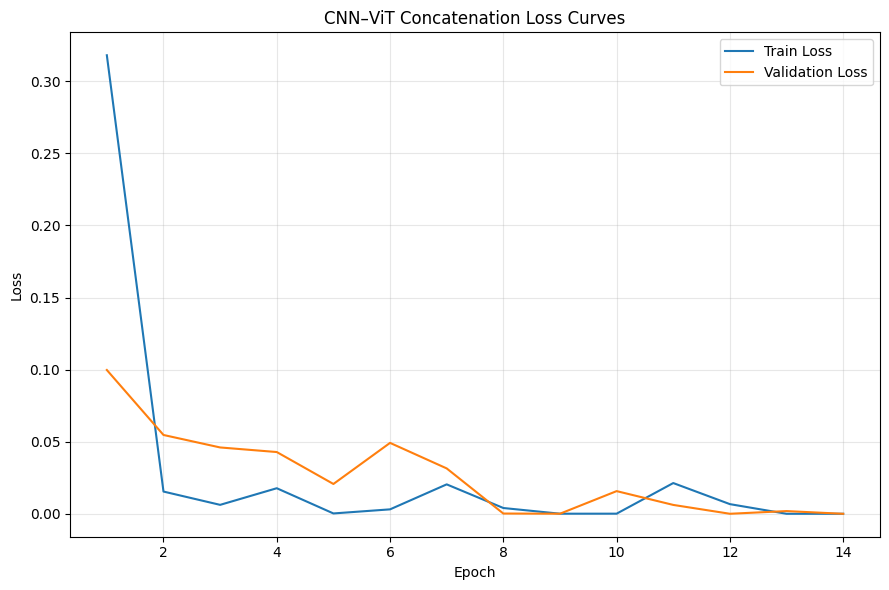

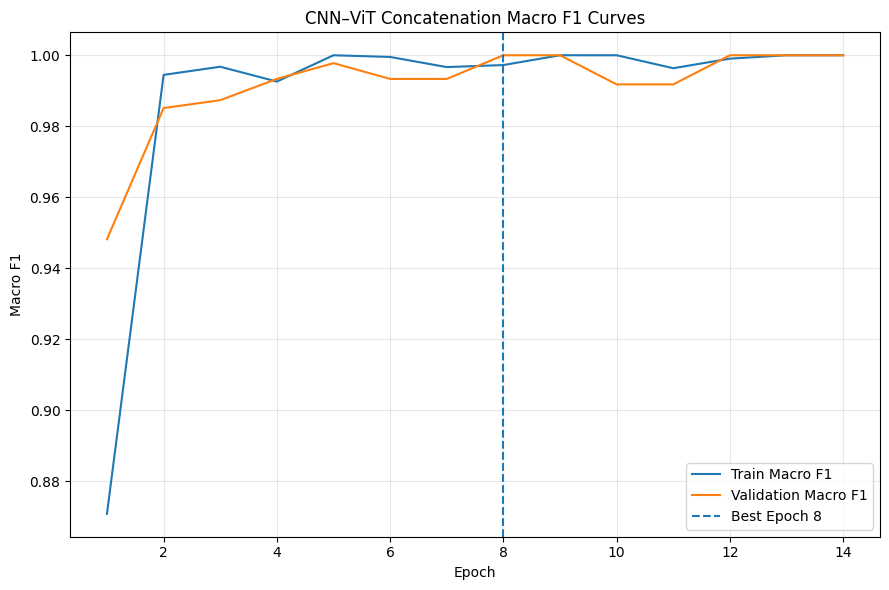

Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/training_curves/cnn_vit_concat_loss_curve_seed42.png
Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/training_curves/cnn_vit_concat_macro_f1_curve_seed42.png


In [13]:
# Cell 13: Plot training curves
fig, axis = plt.subplots(
    figsize=(9, 6)
)

axis.plot(
    history_df['epoch'],
    history_df['train_loss'],
    label='Train Loss',
)

axis.plot(
    history_df['epoch'],
    history_df['val_loss'],
    label='Validation Loss',
)

axis.set_xlabel('Epoch')
axis.set_ylabel('Loss')
axis.set_title(
    'CNN–ViT Concatenation Loss Curves'
)
axis.legend()
axis.grid(alpha=0.3)

loss_curve_path = (
    FIGURES_DIR
    / 'cnn_vit_concat_loss_curve_seed42.png'
)

plt.tight_layout()

plt.savefig(
    loss_curve_path,
    dpi=200,
    bbox_inches='tight',
)

plt.show()


fig, axis = plt.subplots(
    figsize=(9, 6)
)

axis.plot(
    history_df['epoch'],
    history_df['train_macro_f1'],
    label='Train Macro F1',
)

axis.plot(
    history_df['epoch'],
    history_df['val_macro_f1'],
    label='Validation Macro F1',
)

axis.axvline(
    best_epoch,
    linestyle='--',
    label=f'Best Epoch {best_epoch}',
)

axis.set_xlabel('Epoch')
axis.set_ylabel('Macro F1')
axis.set_title(
    'CNN–ViT Concatenation Macro F1 Curves'
)
axis.legend()
axis.grid(alpha=0.3)

f1_curve_path = (
    FIGURES_DIR
    / 'cnn_vit_concat_macro_f1_curve_seed42.png'
)

plt.tight_layout()

plt.savefig(
    f1_curve_path,
    dpi=200,
    bbox_inches='tight',
)

plt.show()

print('Saved:', loss_curve_path)
print('Saved:', f1_curve_path)


In [14]:
# Cell 14: Load best checkpoint and evaluate internal test
best_checkpoint = torch.load(
    BEST_CHECKPOINT_PATH,
    map_location=DEVICE,
)

model.load_state_dict(
    best_checkpoint[
        'model_state_dict'
    ]
)

(
    internal_metrics,
    internal_labels,
    internal_predictions,
) = run_epoch(
    model,
    internal_test_loader,
    criterion,
    optimizer=None,
)

print('Internal-test metrics:')

display(
    pd.DataFrame([
        internal_metrics
    ])
)

internal_report = (
    classification_report(
        internal_labels,
        internal_predictions,
        labels=[0, 1, 2],
        target_names=CLASS_NAMES,
        output_dict=True,
        zero_division=0,
    )
)

internal_report_df = (
    pd.DataFrame(
        internal_report
    )
    .transpose()
    .reset_index()
    .rename(
        columns={
            'index':
                'class_or_average'
        }
    )
)

display(internal_report_df)

internal_metrics_path = (
    METRICS_DIR
    / 'cnn_vit_concat_internal_test_metrics_seed42.csv'
)

internal_report_path = (
    METRICS_DIR
    / 'cnn_vit_concat_internal_test_classification_report_seed42.csv'
)

pd.DataFrame([
    internal_metrics
]).to_csv(
    internal_metrics_path,
    index=False,
)

internal_report_df.to_csv(
    internal_report_path,
    index=False,
)

print('Saved:', internal_metrics_path)
print('Saved:', internal_report_path)


Internal-test metrics:


,accuracy,macro_precision,macro_recall,macro_f1,loss
0,1.0,1.0,1.0,1.0,0.000303


,class_or_average,precision,recall,f1-score,support
0,Early_Blight,1.0,1.0,1.0,150.0
1,Late_Blight,1.0,1.0,1.0,150.0
2,Healthy,1.0,1.0,1.0,23.0
3,accuracy,1.0,1.0,1.0,1.0
4,macro avg,1.0,1.0,1.0,323.0
5,weighted avg,1.0,1.0,1.0,323.0


Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/metrics/cnn_vit_concat_internal_test_metrics_seed42.csv
Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/metrics/cnn_vit_concat_internal_test_classification_report_seed42.csv


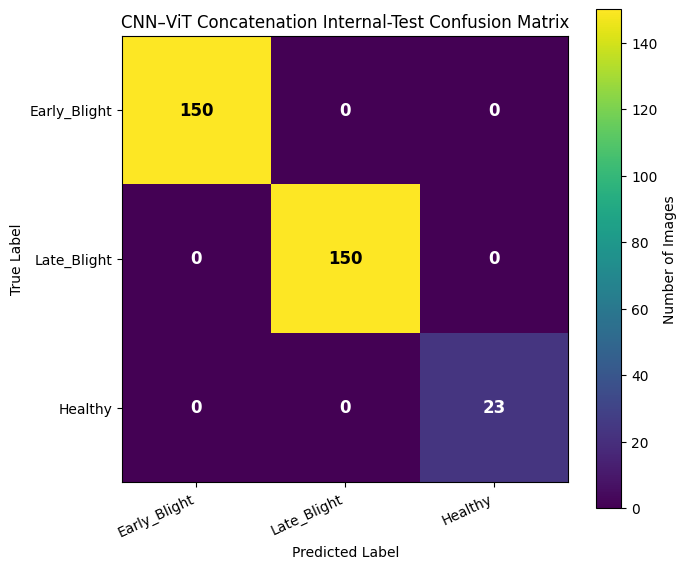

Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/predictions/cnn_vit_concat_internal_test_predictions_seed42.csv
Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/confusion_matrices/cnn_vit_concat_internal_test_confusion_matrix_seed42.png


In [15]:
# Cell 15: Save predictions and confusion matrix
prediction_df = (
    internal_test_df.copy()
)

if (
    USE_LOCAL_COPY
    and 'original_drive_path'
    in prediction_df.columns
):
    prediction_df[
        'evaluation_file_path'
    ] = prediction_df[
        'original_drive_path'
    ]
else:
    prediction_df[
        'evaluation_file_path'
    ] = prediction_df[
        'file_path'
    ]

prediction_df[
    'true_class_id'
] = internal_labels

prediction_df[
    'predicted_class_id'
] = internal_predictions

prediction_df[
    'true_class_name'
] = [
    CLASS_NAMES[index]
    for index in internal_labels
]

prediction_df[
    'predicted_class_name'
] = [
    CLASS_NAMES[index]
    for index in internal_predictions
]

prediction_df[
    'is_correct'
] = (
    prediction_df['true_class_id']
    == prediction_df[
        'predicted_class_id'
    ]
)

prediction_path = (
    PREDICTIONS_DIR
    / 'cnn_vit_concat_internal_test_predictions_seed42.csv'
)

prediction_df.to_csv(
    prediction_path,
    index=False,
)

cm = confusion_matrix(
    internal_labels,
    internal_predictions,
    labels=[0, 1, 2],
)

fig, axis = plt.subplots(
    figsize=(7, 6)
)

image = axis.imshow(
    cm,
    cmap='viridis',
)

axis.set_xticks(
    range(len(CLASS_NAMES))
)
axis.set_yticks(
    range(len(CLASS_NAMES))
)

axis.set_xticklabels(
    CLASS_NAMES,
    rotation=25,
    ha='right',
)

axis.set_yticklabels(
    CLASS_NAMES
)

axis.set_xlabel(
    'Predicted Label'
)
axis.set_ylabel(
    'True Label'
)

axis.set_title(
    'CNN–ViT Concatenation Internal-Test Confusion Matrix'
)

threshold = cm.max() / 2

for row in range(
    cm.shape[0]
):
    for column in range(
        cm.shape[1]
    ):
        value = cm[
            row,
            column,
        ]

        text_color = (
            'black'
            if value > threshold
            else 'white'
        )

        axis.text(
            column,
            row,
            str(value),
            ha='center',
            va='center',
            color=text_color,
            fontsize=12,
            fontweight='bold',
        )

colorbar = fig.colorbar(
    image,
    ax=axis,
)

colorbar.set_label(
    'Number of Images'
)

plt.tight_layout()

confusion_path = (
    CONFUSION_DIR
    / 'cnn_vit_concat_internal_test_confusion_matrix_seed42.png'
)

plt.savefig(
    confusion_path,
    dpi=200,
    bbox_inches='tight',
)

plt.show()

print('Saved:', prediction_path)
print('Saved:', confusion_path)


In [16]:
# Cell 16: Save model config and summary
config = {
    'created_at':
        datetime.now().isoformat(),

    'model_name':
        'CNN_ViT_Simple_Concatenation',

    'cnn_branch':
        'EfficientNet-B0',

    'vit_branch':
        model.vit_model_name,

    'fusion_method':
        'Direct feature concatenation',

    'seed':
        RANDOM_SEED,

    'class_names':
        CLASS_NAMES,

    'image_size':
        IMAGE_SIZE,

    'resize_size':
        RESIZE_SIZE,

    'batch_size':
        BATCH_SIZE,

    'num_workers':
        NUM_WORKERS,

    'optimizer':
        'AdamW',

    'learning_rate':
        LEARNING_RATE,

    'weight_decay':
        WEIGHT_DECAY,

    'loss':
        'Weighted CrossEntropyLoss',

    'dropout':
        DROPOUT,

    'fusion_hidden_dim':
        FUSION_HIDDEN_DIM,

    'cnn_feature_dim':
        model.cnn_feature_dim,

    'vit_feature_dim':
        model.vit_feature_dim,

    'concatenated_dim':
        model.concatenated_dim,

    'max_epochs':
        MAX_EPOCHS,

    'early_stopping_patience':
        EARLY_STOPPING_PATIENCE,

    'best_epoch':
        best_epoch,

    'best_validation_macro_f1':
        best_val_macro_f1,

    'total_parameters':
        total_parameters,

    'trainable_parameters':
        trainable_parameters,

    'internal_test_metrics':
        internal_metrics,

    'external_test_used':
        False,
}

config_path = (
    CONFIG_DIR
    / 'cnn_vit_concat_seed42_config.json'
)

with config_path.open(
    'w',
    encoding='utf-8',
) as file_handle:
    json.dump(
        config,
        file_handle,
        ensure_ascii=False,
        indent=2,
    )

summary_df = pd.DataFrame([
    {
        'model':
            'CNN_ViT_Simple_Concatenation',

        'seed':
            RANDOM_SEED,

        'best_epoch':
            best_epoch,

        'best_val_macro_f1':
            best_val_macro_f1,

        'internal_test_accuracy':
            internal_metrics[
                'accuracy'
            ],

        'internal_test_macro_precision':
            internal_metrics[
                'macro_precision'
            ],

        'internal_test_macro_recall':
            internal_metrics[
                'macro_recall'
            ],

        'internal_test_macro_f1':
            internal_metrics[
                'macro_f1'
            ],

        'total_parameters':
            total_parameters,

        'trainable_parameters':
            trainable_parameters,

        'training_minutes':
            total_training_seconds
            / 60,
    }
])

summary_path = (
    METRICS_DIR
    / 'cnn_vit_concat_summary_seed42.csv'
)

summary_df.to_csv(
    summary_path,
    index=False,
)

display(summary_df)

print('Saved:', config_path)
print('Saved:', summary_path)


,model,seed,best_epoch,best_val_macro_f1,internal_test_accuracy,internal_test_macro_precision,internal_test_macro_recall,internal_test_macro_f1,total_parameters,trainable_parameters,training_minutes
0,CNN_ViT_Simple_Concatenation,42,8,1.0,1.0,1.0,1.0,1.0,10290623,10290623,8.062711


Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/03_configs/cnn_vit_concat_seed42_config.json
Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/metrics/cnn_vit_concat_summary_seed42.csv


In [17]:
# Cell 17: Compare all completed models
summary_paths = [
    (
        METRICS_DIR
        / 'cnn_efficientnet_b0_summary_seed42.csv'
    ),

    (
        METRICS_DIR
        / 'vit_deit_tiny_summary_seed42.csv'
    ),

    (
        METRICS_DIR
        / 'cnn_vit_concat_summary_seed42.csv'
    ),
]

comparison_frames = []

for path in summary_paths:
    if path.exists():
        comparison_frames.append(
            pd.read_csv(path)
        )

if comparison_frames:
    model_comparison_df = pd.concat(
        comparison_frames,
        ignore_index=True,
        sort=False,
    )

    model_comparison_path = (
        METRICS_DIR
        / 'cnn_vit_concat_baseline_comparison_seed42.csv'
    )

    model_comparison_df.to_csv(
        model_comparison_path,
        index=False,
    )

    display(
        model_comparison_df
    )

    print(
        'Saved:',
        model_comparison_path,
    )
else:
    print(
        'No model summary files found.'
    )


,model,seed,best_epoch,best_val_macro_f1,internal_test_accuracy,internal_test_macro_precision,internal_test_macro_recall,internal_test_macro_f1,total_parameters,trainable_parameters,training_minutes
0,EfficientNet-B0,42,4,0.991793,1.0,1.0,1.0,1.0,4011391,4011391,3.645169
1,CNN_ViT_Simple_Concatenation,42,8,1.000000,1.0,1.0,1.0,1.0,10290623,10290623,8.062711


Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/metrics/cnn_vit_concat_baseline_comparison_seed42.csv


In [18]:
# Cell 18: Final report
final_report_df = pd.DataFrame([
    {
        'check':
            'Concatenation model created',

        'passed':
            model is not None,
    },

    {
        'check':
            'Forward pass verified',

        'passed':
            tuple(test_logits.shape)
            == expected_shape,
    },

    {
        'check':
            'Best checkpoint saved',

        'passed':
            BEST_CHECKPOINT_PATH.exists(),
    },

    {
        'check':
            'Training history saved',

        'passed':
            HISTORY_PATH.exists(),
    },

    {
        'check':
            'Loss and F1 curves saved',

        'passed': (
            loss_curve_path.exists()
            and f1_curve_path.exists()
        ),
    },

    {
        'check':
            'Internal-test metrics saved',

        'passed':
            internal_metrics_path.exists(),
    },

    {
        'check':
            'Internal-test predictions saved',

        'passed':
            prediction_path.exists(),
    },

    {
        'check':
            'External test not used for tuning',

        'passed':
            True,
    },
])

display(final_report_df)

if final_report_df[
    'passed'
].all():
    print(
        '✅ CNN–ViT concatenation training '
        'completed successfully.'
    )

    print(
        'Next step: '
        '09_Attention_Guided_CNN_ViT_Training.ipynb'
    )

else:
    print(
        '⚠️ CNN–ViT concatenation training '
        'completed with warnings.'
    )


,check,passed
0,Concatenation model created,True
1,Forward pass verified,True
2,Best checkpoint saved,True
3,Training history saved,True
4,Loss and F1 curves saved,True
5,Internal-test metrics saved,True
6,Internal-test predictions saved,True
7,External test not used for tuning,True


✅ CNN–ViT concatenation training completed successfully.
Next step: 09_Attention_Guided_CNN_ViT_Training.ipynb


---

# Part 09 — 09. Attention-Guided CNN–ViT Training

**Purpose:** Train the proposed attention-guided hybrid model with learnable sample-wise branch attention between CNN and ViT features.

**Source notebook:** `09_Attention_Guided_CNN_ViT_Training.ipynb`

**Preservation note:** The original code cells and their saved execution outputs are retained below. Textual headings/comments are lightly normalized into English where possible without changing experiment logic.


# 09 — Attention-Guided CNN–ViT Training

This notebook তোমাদের **proposed model** train করবে।

## Architecture

```text
Input image
   ├── EfficientNet-B0 → CNN feature → Projection
   └── DeiT-Tiny      → ViT feature → Projection
                                  ↓
                    Learnable Branch-Attention Gate
                                  ↓
                         Weighted Feature Fusion
                                  ↓
                              Classifier
```

## Attention mechanism

এখানে attention হলো **sample-wise branch attention**:

- প্রতিটি image-এর জন্য CNN branch কতটা Important
- ViT branch কতটা Important

model নিজে দুটি weight শিখবে। দুটি weight-এর যোগফল সবসময় `1` হবে।

এটি spatial Grad-CAM নয়। Grad-CAM will be handled in a separate evaluation notebook।

## Fair-comparison policy

- একই PlantVillage train/validation/internal-test split
- একই input size এবং preprocessing
- একই weighted Cross-Entropy loss
- একই validation Macro F1 checkpoint rule
- PLDD-UP external dataset will not be used for training or tuning


In [1]:
# Cell 1: Mount Google Drive and install timm
from google.colab import drive

drive.mount('/content/drive', force_remount=True)

!pip -q install timm


Mounted at /content/drive


In [2]:
# Cell 2: Imports and reproducibility
from pathlib import Path
from datetime import datetime
import json
import os
import random
import shutil
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import (
    efficientnet_b0,
    EfficientNet_B0_Weights,
)

import timm

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
)

RANDOM_SEED = 42

CLASS_NAMES = [
    'Early_Blight',
    'Late_Blight',
    'Healthy',
]

CLASS_ID_MAP = {
    'Early_Blight': 0,
    'Late_Blight': 1,
    'Healthy': 2,
}

IMAGE_SIZE = 224
RESIZE_SIZE = 256

BATCH_SIZE = 8
NUM_WORKERS = 2

MAX_EPOCHS = 25
EARLY_STOPPING_PATIENCE = 6

LEARNING_RATE = 3e-5
WEIGHT_DECAY = 1e-4

PROJECTION_DIM = 256
CLASSIFIER_HIDDEN_DIM = 256
DROPOUT = 0.35

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]


def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)


seed_everything(RANDOM_SEED)

DEVICE = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
)

print('PyTorch:', torch.__version__)
print('timm:', timm.__version__)
print('Device:', DEVICE)

if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
else:
    print(
        '⚠️ Runtime → Change runtime type → T4 GPU নির্বাচন করো।'
    )


PyTorch: 2.11.0+cu128
timm: 1.0.28
Device: cuda
GPU: Tesla T4


In [3]:
# Cell 3: Locate project folders
MY_DRIVE = Path('/content/drive/MyDrive')

standard_project = (
    MY_DRIVE / 'Potato_CNN_ViT_Research'
)

if standard_project.is_dir():
    PROJECT_ROOT = standard_project
else:
    matches = [
        path
        for path in MY_DRIVE.rglob(
            'Potato_CNN_ViT_Research'
        )
        if path.is_dir()
    ]

    if not matches:
        raise FileNotFoundError(
            'Potato_CNN_ViT_Research folder My Drive-এ পাওয়া যায়নি।'
        )

    PROJECT_ROOT = matches[0]

DATA_DIR = PROJECT_ROOT / '02_data'
SPLITS_DIR = DATA_DIR / 'splits'
METADATA_DIR = DATA_DIR / 'metadata'

CONFIG_DIR = PROJECT_ROOT / '03_configs'
CHECKPOINT_DIR = (
    PROJECT_ROOT
    / '04_checkpoints'
    / 'attention'
)
METRICS_DIR = (
    PROJECT_ROOT
    / '05_results'
    / 'metrics'
)
FIGURES_DIR = (
    PROJECT_ROOT
    / '05_results'
    / 'training_curves'
)
PREDICTIONS_DIR = (
    PROJECT_ROOT
    / '05_results'
    / 'predictions'
)
CONFUSION_DIR = (
    PROJECT_ROOT
    / '05_results'
    / 'confusion_matrices'
)
ATTENTION_DIR = (
    PROJECT_ROOT
    / '05_results'
    / 'attention_weights'
)

for folder in [
    CONFIG_DIR,
    CHECKPOINT_DIR,
    METRICS_DIR,
    FIGURES_DIR,
    PREDICTIONS_DIR,
    CONFUSION_DIR,
    ATTENTION_DIR,
]:
    folder.mkdir(
        parents=True,
        exist_ok=True,
    )

print('PROJECT_ROOT:', PROJECT_ROOT)
print('CHECKPOINT_DIR:', CHECKPOINT_DIR)
print('ATTENTION_DIR:', ATTENTION_DIR)


PROJECT_ROOT: /content/drive/MyDrive/Potato_CNN_ViT_Research
CHECKPOINT_DIR: /content/drive/MyDrive/Potato_CNN_ViT_Research/04_checkpoints/attention
ATTENTION_DIR: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/attention_weights


In [4]:
# Cell 4: Load split CSV files and class weights
train_path = SPLITS_DIR / 'train.csv'
val_path = SPLITS_DIR / 'val.csv'

internal_test_path = (
    SPLITS_DIR / 'internal_test.csv'
)

class_weights_path = (
    METADATA_DIR
    / 'training_class_weights.csv'
)

for path in [
    train_path,
    val_path,
    internal_test_path,
    class_weights_path,
]:
    if not path.exists():
        raise FileNotFoundError(
            f'File পাওয়া যায়নি: {path}'
        )

train_df = pd.read_csv(train_path)
val_df = pd.read_csv(val_path)

internal_test_df = pd.read_csv(
    internal_test_path
)

class_weights_df = pd.read_csv(
    class_weights_path
)

for frame_name, frame in [
    ('train', train_df),
    ('val', val_df),
    ('internal_test', internal_test_df),
]:
    frame['file_path'] = (
        frame['file_path'].astype(str)
    )

    frame['class_id'] = (
        frame['class_id'].astype(int)
    )

    frame['unified_class'] = (
        frame['unified_class'].astype(str)
    )

    missing_count = int(
        (
            ~frame['file_path'].map(
                lambda value: Path(value).exists()
            )
        ).sum()
    )

    if missing_count:
        raise FileNotFoundError(
            f'{frame_name} split-এ '
            f'{missing_count}টি image path missing।'
        )

class_weights_df = (
    class_weights_df.sort_values(
        'class_id'
    )
)

class_weights_tensor = torch.tensor(
    class_weights_df[
        'class_weight'
    ].values,
    dtype=torch.float32,
    device=DEVICE,
)

print('Train:', len(train_df))
print('Validation:', len(val_df))
print('Internal test:', len(internal_test_df))
print('Class weights:', class_weights_tensor)


Train: 1506
Validation: 323
Internal test: 323
Class weights: tensor([0.7171, 0.7171, 4.7358], device='cuda:0')


In [5]:
# Cell 5: Copy PlantVillage to Colab local storage
USE_LOCAL_COPY = True

LOCAL_ROOT = Path(
    '/content/plantvillage_local'
)


def build_local_path(original_path):
    original_path = Path(original_path)

    return (
        LOCAL_ROOT
        / original_path.parent.name
        / original_path.name
    )


if USE_LOCAL_COPY:
    sample_path = Path(
        train_df.iloc[0]['file_path']
    )

    source_plant_root = (
        sample_path.parent.parent
    )

    if not LOCAL_ROOT.exists():
        print(
            'PlantVillage dataset '
            '/content-এ copy হচ্ছে...'
        )

        shutil.copytree(
            source_plant_root,
            LOCAL_ROOT,
            dirs_exist_ok=True,
        )

        print('Local copy completed.')
    else:
        print(
            'Existing local copy ব্যবহার করা হচ্ছে।'
        )

    for frame in [
        train_df,
        val_df,
        internal_test_df,
    ]:
        frame['original_drive_path'] = (
            frame['file_path']
        )

        frame['file_path'] = (
            frame['file_path'].map(
                lambda value: str(
                    build_local_path(value)
                )
            )
        )

        missing_local = int(
            (
                ~frame['file_path'].map(
                    lambda value: Path(value).exists()
                )
            ).sum()
        )

        if missing_local:
            raise FileNotFoundError(
                f'Local copy-তে '
                f'{missing_local}টি image missing।'
            )

print(
    'Dataset path mode:',
    (
        'Colab local storage'
        if USE_LOCAL_COPY
        else 'Google Drive'
    ),
)


PlantVillage dataset /content-এ copy হচ্ছে...
Local copy completed.
Dataset path mode: Colab local storage


In [6]:
# Cell 6: Define preprocessing
train_transform = transforms.Compose([
    transforms.Resize(
        (RESIZE_SIZE, RESIZE_SIZE)
    ),

    transforms.RandomResizedCrop(
        IMAGE_SIZE,
        scale=(0.80, 1.00),
        ratio=(0.90, 1.10),
    ),

    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.RandomRotation(
        degrees=15
    ),

    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.10,
        hue=0.02,
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD,
    ),

    transforms.RandomErasing(
        p=0.10,
        scale=(0.02, 0.08),
        ratio=(0.5, 2.0),
        value='random',
    ),
])

eval_transform = transforms.Compose([
    transforms.Resize(
        (RESIZE_SIZE, RESIZE_SIZE)
    ),

    transforms.CenterCrop(
        IMAGE_SIZE
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD,
    ),
])


In [7]:
# Cell 7: Dataset and DataLoaders
class PotatoLeafDataset(Dataset):
    def __init__(
        self,
        dataframe,
        transform=None,
    ):
        self.dataframe = (
            dataframe.reset_index(
                drop=True
            ).copy()
        )

        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]

        with Image.open(
            row['file_path']
        ) as image:
            image = image.convert('RGB')

        if self.transform is not None:
            image = self.transform(image)

        return {
            'image': image,

            'label': torch.tensor(
                int(row['class_id']),
                dtype=torch.long,
            ),

            'file_path': str(
                row['file_path']
            ),

            'class_name': str(
                row['unified_class']
            ),
        }


train_dataset = PotatoLeafDataset(
    train_df,
    transform=train_transform,
)

val_dataset = PotatoLeafDataset(
    val_df,
    transform=eval_transform,
)

internal_test_dataset = (
    PotatoLeafDataset(
        internal_test_df,
        transform=eval_transform,
    )
)

generator = torch.Generator()
generator.manual_seed(RANDOM_SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=(
        NUM_WORKERS > 0
    ),
    generator=generator,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=(
        NUM_WORKERS > 0
    ),
)

internal_test_loader = DataLoader(
    internal_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=(
        NUM_WORKERS > 0
    ),
)

print('Train batches:', len(train_loader))
print('Validation batches:', len(val_loader))
print(
    'Internal-test batches:',
    len(internal_test_loader),
)


Train batches: 189
Validation batches: 41
Internal-test batches: 41


In [8]:
# Cell 8: Build attention-guided CNN–ViT model
class AttentionGuidedCNNViT(nn.Module):
    def __init__(
        self,
        num_classes,
        projection_dim,
        classifier_hidden_dim,
        dropout,
    ):
        super().__init__()

        # CNN feature extractor
        cnn_model = efficientnet_b0(
            weights=EfficientNet_B0_Weights.DEFAULT
        )

        self.cnn_features = cnn_model.features
        self.cnn_pool = nn.AdaptiveAvgPool2d(1)

        self.cnn_feature_dim = (
            cnn_model.classifier[1].in_features
        )

        # ViT feature extractor
        model_candidates = [
            'deit_tiny_patch16_224.fb_in1k',
            'deit_tiny_patch16_224',
        ]

        self.vit_backbone = None
        self.vit_model_name = None
        last_error = None

        for candidate in model_candidates:
            try:
                print(
                    'Trying ViT branch:',
                    candidate,
                )

                self.vit_backbone = (
                    timm.create_model(
                        candidate,
                        pretrained=True,
                        num_classes=0,
                        global_pool='avg',
                    )
                )

                self.vit_model_name = candidate
                break

            except Exception as error:
                last_error = error

                print(
                    'Could not load:',
                    candidate,
                    error,
                )

        if self.vit_backbone is None:
            raise RuntimeError(
                f'ViT branch load failed: {last_error}'
            )

        self.vit_feature_dim = (
            self.vit_backbone.num_features
        )

        # Project both branches to the same feature dimension.
        self.cnn_projection = nn.Sequential(
            nn.Linear(
                self.cnn_feature_dim,
                projection_dim,
            ),
            nn.LayerNorm(
                projection_dim
            ),
            nn.GELU(),
            nn.Dropout(
                p=dropout
            ),
        )

        self.vit_projection = nn.Sequential(
            nn.Linear(
                self.vit_feature_dim,
                projection_dim,
            ),
            nn.LayerNorm(
                projection_dim
            ),
            nn.GELU(),
            nn.Dropout(
                p=dropout
            ),
        )

        # Sample-wise branch attention.
        # Input: [projected CNN, projected ViT]
        # Output: two normalized branch weights.
        self.attention_gate = nn.Sequential(
            nn.Linear(
                projection_dim * 2,
                projection_dim,
            ),
            nn.GELU(),
            nn.Dropout(
                p=dropout
            ),
            nn.Linear(
                projection_dim,
                2,
            ),
        )

        self.classifier = nn.Sequential(
            nn.LayerNorm(
                projection_dim
            ),
            nn.Dropout(
                p=dropout
            ),
            nn.Linear(
                projection_dim,
                classifier_hidden_dim,
            ),
            nn.GELU(),
            nn.Dropout(
                p=dropout
            ),
            nn.Linear(
                classifier_hidden_dim,
                num_classes,
            ),
        )

        self.projection_dim = projection_dim

    def extract_features(self, images):
        cnn_map = self.cnn_features(
            images
        )

        cnn_raw = (
            self.cnn_pool(cnn_map)
            .flatten(1)
        )

        vit_raw = self.vit_backbone(
            images
        )

        cnn_projected = (
            self.cnn_projection(cnn_raw)
        )

        vit_projected = (
            self.vit_projection(vit_raw)
        )

        return (
            cnn_projected,
            vit_projected,
        )

    def forward(
        self,
        images,
        return_attention=False,
    ):
        (
            cnn_projected,
            vit_projected,
        ) = self.extract_features(images)

        joint_features = torch.cat(
            [
                cnn_projected,
                vit_projected,
            ],
            dim=1,
        )

        attention_logits = (
            self.attention_gate(
                joint_features
            )
        )

        attention_weights = torch.softmax(
            attention_logits,
            dim=1,
        )

        cnn_weight = (
            attention_weights[:, 0:1]
        )

        vit_weight = (
            attention_weights[:, 1:2]
        )

        fused_features = (
            cnn_weight * cnn_projected
            + vit_weight * vit_projected
        )

        logits = self.classifier(
            fused_features
        )

        if return_attention:
            return (
                logits,
                attention_weights,
            )

        return logits


model = AttentionGuidedCNNViT(
    num_classes=len(CLASS_NAMES),
    projection_dim=PROJECTION_DIM,
    classifier_hidden_dim=(
        CLASSIFIER_HIDDEN_DIM
    ),
    dropout=DROPOUT,
).to(DEVICE)

total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print('CNN feature dim:', model.cnn_feature_dim)
print('ViT feature dim:', model.vit_feature_dim)
print('Projection dim:', model.projection_dim)
print('ViT branch:', model.vit_model_name)
print('Total parameters:', f'{total_parameters:,}')
print('Trainable parameters:', f'{trainable_parameters:,}')


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 208MB/s]


Trying ViT branch: deit_tiny_patch16_224.fb_in1k


model.safetensors: reconstructing file:   0%|          |  0.00B / 22.9MB            

model.safetensors: downloading bytes:           |  0.00B            

CNN feature dim: 1280
ViT feature dim: 192
Projection dim: 256
ViT branch: deit_tiny_patch16_224.fb_in1k
Total parameters: 10,109,249
Trainable parameters: 10,109,249


In [9]:
# Cell 9: Forward-pass and attention verification
test_batch = next(iter(train_loader))

test_images = (
    test_batch['image'].to(DEVICE)
)

with torch.no_grad():
    (
        test_logits,
        test_attention,
    ) = model(
        test_images,
        return_attention=True,
    )

print(
    'Input batch shape:',
    tuple(test_images.shape),
)

print(
    'Output logits shape:',
    tuple(test_logits.shape),
)

print(
    'Attention shape:',
    tuple(test_attention.shape),
)

print(
    'First five attention weights:'
)

display(
    pd.DataFrame(
        test_attention[:5]
        .detach()
        .cpu()
        .numpy(),
        columns=[
            'cnn_weight',
            'vit_weight',
        ],
    )
)

expected_logits_shape = (
    test_images.shape[0],
    len(CLASS_NAMES),
)

expected_attention_shape = (
    test_images.shape[0],
    2,
)

if (
    tuple(test_logits.shape)
    != expected_logits_shape
):
    raise RuntimeError(
        'Wrong output-logit shape.'
    )

if (
    tuple(test_attention.shape)
    != expected_attention_shape
):
    raise RuntimeError(
        'Wrong attention shape.'
    )

weight_sums = (
    test_attention.sum(dim=1)
)

if not torch.allclose(
    weight_sums,
    torch.ones_like(weight_sums),
    atol=1e-5,
):
    raise RuntimeError(
        'Attention weights do not sum to 1.'
    )

print(
    '✅ Forward pass and attention '
    'normalization verified.'
)


Input batch shape: (8, 3, 224, 224)
Output logits shape: (8, 3)
Attention shape: (8, 2)
First five attention weights:


,cnn_weight,vit_weight
0,0.471101,0.528899
1,0.470137,0.529863
2,0.534950,0.465050
3,0.406179,0.593821
4,0.463834,0.536166


✅ Forward pass and attention normalization verified.


In [10]:
# Cell 10: Loss, optimizer, scheduler, and AMP
criterion = nn.CrossEntropyLoss(
    weight=class_weights_tensor
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

scheduler = (
    torch.optim.lr_scheduler
    .CosineAnnealingLR(
        optimizer,
        T_max=MAX_EPOCHS,
    )
)

amp_enabled = torch.cuda.is_available()

try:
    scaler = torch.amp.GradScaler(
        'cuda',
        enabled=amp_enabled,
    )
except TypeError:
    scaler = torch.cuda.amp.GradScaler(
        enabled=amp_enabled,
    )

print('AMP enabled:', amp_enabled)


AMP enabled: True


In [11]:
# Cell 11: Metric and epoch helpers
def calculate_metrics(
    y_true,
    y_pred,
):
    accuracy = accuracy_score(
        y_true,
        y_pred,
    )

    precision, recall, macro_f1, _ = (
        precision_recall_fscore_support(
            y_true,
            y_pred,
            average='macro',
            zero_division=0,
        )
    )

    return {
        'accuracy': float(accuracy),
        'macro_precision': float(
            precision
        ),
        'macro_recall': float(recall),
        'macro_f1': float(macro_f1),
    }


def run_epoch(
    model,
    loader,
    criterion,
    optimizer=None,
    collect_attention=False,
):
    is_training = optimizer is not None

    if is_training:
        model.train()
    else:
        model.eval()

    running_loss = 0.0
    all_labels = []
    all_predictions = []
    all_attention = []

    for batch in loader:
        images = batch['image'].to(
            DEVICE,
            non_blocking=True,
        )

        labels = batch['label'].to(
            DEVICE,
            non_blocking=True,
        )

        if is_training:
            optimizer.zero_grad(
                set_to_none=True
            )

        with torch.set_grad_enabled(
            is_training
        ):
            try:
                autocast_context = (
                    torch.amp.autocast(
                        device_type='cuda',
                        enabled=amp_enabled,
                    )
                )
            except TypeError:
                autocast_context = (
                    torch.cuda.amp.autocast(
                        enabled=amp_enabled,
                    )
                )

            with autocast_context:
                if collect_attention:
                    (
                        logits,
                        attention_weights,
                    ) = model(
                        images,
                        return_attention=True,
                    )
                else:
                    logits = model(images)
                    attention_weights = None

                loss = criterion(
                    logits,
                    labels,
                )

            if is_training:
                scaler.scale(
                    loss
                ).backward()

                scaler.unscale_(
                    optimizer
                )

                torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    max_norm=1.0,
                )

                scaler.step(
                    optimizer
                )

                scaler.update()

        running_loss += (
            loss.item()
            * images.size(0)
        )

        predictions = logits.argmax(
            dim=1
        )

        all_labels.extend(
            labels.detach().cpu().tolist()
        )

        all_predictions.extend(
            predictions.detach().cpu().tolist()
        )

        if (
            collect_attention
            and attention_weights is not None
        ):
            all_attention.extend(
                attention_weights
                .detach()
                .cpu()
                .tolist()
            )

    epoch_loss = (
        running_loss
        / len(loader.dataset)
    )

    metrics = calculate_metrics(
        all_labels,
        all_predictions,
    )

    metrics['loss'] = float(
        epoch_loss
    )

    return (
        metrics,
        all_labels,
        all_predictions,
        all_attention,
    )


In [12]:
# Cell 12: Train attention-guided model
BEST_CHECKPOINT_PATH = (
    CHECKPOINT_DIR
    / 'attention_cnn_vit_best_seed42.pth'
)

LAST_CHECKPOINT_PATH = (
    CHECKPOINT_DIR
    / 'attention_cnn_vit_last_seed42.pth'
)

HISTORY_PATH = (
    METRICS_DIR
    / 'attention_cnn_vit_training_history_seed42.csv'
)

best_val_macro_f1 = -1.0
best_epoch = 0
epochs_without_improvement = 0
history_rows = []

training_start_time = time.time()

for epoch in range(
    1,
    MAX_EPOCHS + 1,
):
    epoch_start_time = time.time()

    (
        train_metrics,
        _,
        _,
        _,
    ) = run_epoch(
        model,
        train_loader,
        criterion,
        optimizer=optimizer,
        collect_attention=False,
    )

    (
        val_metrics,
        _,
        _,
        _,
    ) = run_epoch(
        model,
        val_loader,
        criterion,
        optimizer=None,
        collect_attention=False,
    )

    scheduler.step()

    current_lr = (
        optimizer.param_groups[0]['lr']
    )

    epoch_seconds = (
        time.time() - epoch_start_time
    )

    history_row = {
        'epoch': epoch,
        'learning_rate': current_lr,

        'train_loss':
            train_metrics['loss'],

        'train_accuracy':
            train_metrics['accuracy'],

        'train_macro_precision':
            train_metrics[
                'macro_precision'
            ],

        'train_macro_recall':
            train_metrics[
                'macro_recall'
            ],

        'train_macro_f1':
            train_metrics['macro_f1'],

        'val_loss':
            val_metrics['loss'],

        'val_accuracy':
            val_metrics['accuracy'],

        'val_macro_precision':
            val_metrics[
                'macro_precision'
            ],

        'val_macro_recall':
            val_metrics[
                'macro_recall'
            ],

        'val_macro_f1':
            val_metrics['macro_f1'],

        'epoch_seconds':
            epoch_seconds,
    }

    history_rows.append(
        history_row
    )

    pd.DataFrame(
        history_rows
    ).to_csv(
        HISTORY_PATH,
        index=False,
    )

    print(
        f'Epoch {epoch:02d}/{MAX_EPOCHS} | '
        f'Train Loss '
        f'{train_metrics["loss"]:.4f} | '
        f'Train F1 '
        f'{train_metrics["macro_f1"]:.4f} | '
        f'Val Loss '
        f'{val_metrics["loss"]:.4f} | '
        f'Val F1 '
        f'{val_metrics["macro_f1"]:.4f} | '
        f'{epoch_seconds:.1f}s'
    )

    checkpoint_payload = {
        'epoch': epoch,

        'model_name':
            'Attention_Guided_CNN_ViT',

        'cnn_branch':
            'EfficientNet-B0',

        'vit_branch':
            model.vit_model_name,

        'fusion':
            'Learnable sample-wise branch attention',

        'seed':
            RANDOM_SEED,

        'class_names':
            CLASS_NAMES,

        'class_id_map':
            CLASS_ID_MAP,

        'model_state_dict':
            model.state_dict(),

        'optimizer_state_dict':
            optimizer.state_dict(),

        'scheduler_state_dict':
            scheduler.state_dict(),

        'val_metrics':
            val_metrics,

        'config': {
            'image_size':
                IMAGE_SIZE,

            'batch_size':
                BATCH_SIZE,

            'learning_rate':
                LEARNING_RATE,

            'weight_decay':
                WEIGHT_DECAY,

            'projection_dim':
                PROJECTION_DIM,

            'classifier_hidden_dim':
                CLASSIFIER_HIDDEN_DIM,

            'dropout':
                DROPOUT,

            'max_epochs':
                MAX_EPOCHS,
        },
    }

    torch.save(
        checkpoint_payload,
        LAST_CHECKPOINT_PATH,
    )

    if (
        val_metrics['macro_f1']
        > best_val_macro_f1
    ):
        best_val_macro_f1 = (
            val_metrics['macro_f1']
        )

        best_epoch = epoch
        epochs_without_improvement = 0

        torch.save(
            checkpoint_payload,
            BEST_CHECKPOINT_PATH,
        )

        print(
            '✅ Best checkpoint updated '
            f'(Val Macro F1: '
            f'{best_val_macro_f1:.4f})'
        )

    else:
        epochs_without_improvement += 1

    if (
        epochs_without_improvement
        >= EARLY_STOPPING_PATIENCE
    ):
        print(
            f'Early stopping at epoch '
            f'{epoch}. '
            f'Best epoch: {best_epoch}'
        )

        break

total_training_seconds = (
    time.time()
    - training_start_time
)

history_df = pd.DataFrame(
    history_rows
)

print('Training completed.')
print('Best epoch:', best_epoch)
print(
    'Best validation Macro F1:',
    round(best_val_macro_f1, 4),
)
print(
    'Training minutes:',
    round(
        total_training_seconds / 60,
        2,
    ),
)
print(
    'Best checkpoint:',
    BEST_CHECKPOINT_PATH,
)


Epoch 01/25 | Train Loss 0.5985 | Train F1 0.7579 | Val Loss 0.0799 | Val F1 0.9851 | 63.7s
✅ Best checkpoint updated (Val Macro F1: 0.9851)
Epoch 02/25 | Train Loss 0.0813 | Train F1 0.9868 | Val Loss 0.1487 | Val F1 0.9822 | 29.6s
Epoch 03/25 | Train Loss 0.0182 | Train F1 0.9968 | Val Loss 0.0183 | Val F1 0.9918 | 31.5s
✅ Best checkpoint updated (Val Macro F1: 0.9918)
Epoch 04/25 | Train Loss 0.0127 | Train F1 0.9977 | Val Loss 0.0428 | Val F1 0.9933 | 34.4s
✅ Best checkpoint updated (Val Macro F1: 0.9933)
Epoch 05/25 | Train Loss 0.0032 | Train F1 1.0000 | Val Loss 0.0207 | Val F1 0.9918 | 35.8s
Epoch 06/25 | Train Loss 0.0136 | Train F1 0.9982 | Val Loss 0.0211 | Val F1 0.9918 | 31.5s
Epoch 07/25 | Train Loss 0.0094 | Train F1 0.9986 | Val Loss 0.0102 | Val F1 0.9978 | 31.3s
✅ Best checkpoint updated (Val Macro F1: 0.9978)
Epoch 08/25 | Train Loss 0.0036 | Train F1 0.9995 | Val Loss 0.0001 | Val F1 1.0000 | 35.0s
✅ Best checkpoint updated (Val Macro F1: 1.0000)
Epoch 09/25 | Train

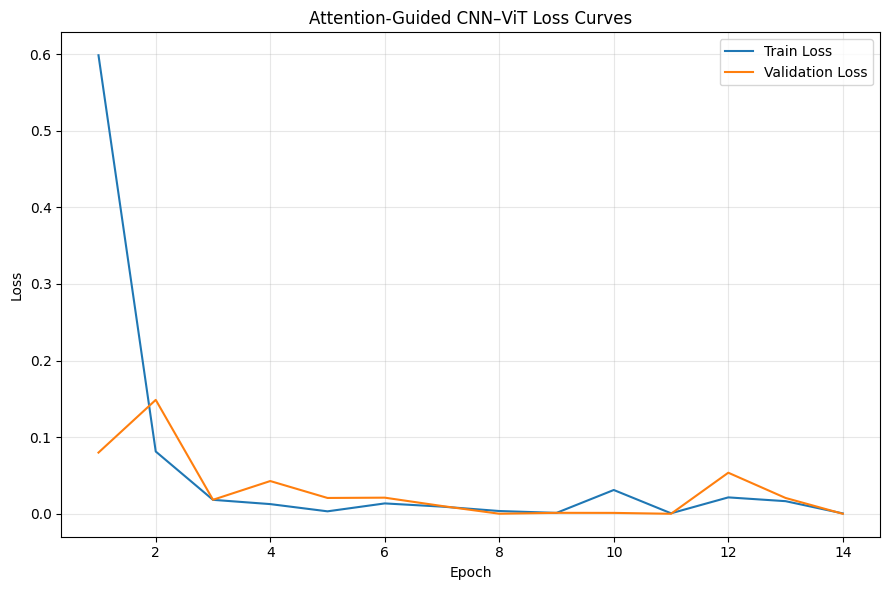

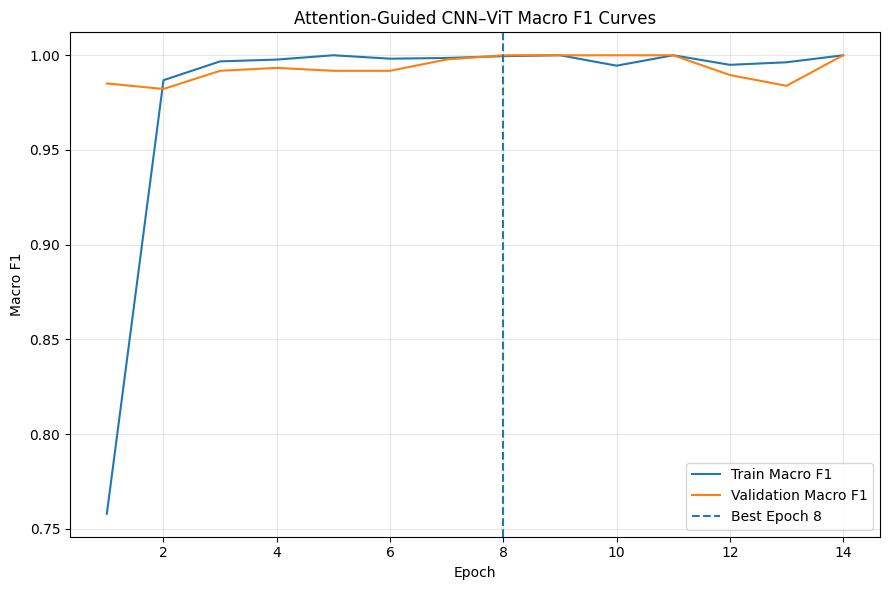

Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/training_curves/attention_cnn_vit_loss_curve_seed42.png
Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/training_curves/attention_cnn_vit_macro_f1_curve_seed42.png


In [13]:
# Cell 13: Plot training curves
fig, axis = plt.subplots(
    figsize=(9, 6)
)

axis.plot(
    history_df['epoch'],
    history_df['train_loss'],
    label='Train Loss',
)

axis.plot(
    history_df['epoch'],
    history_df['val_loss'],
    label='Validation Loss',
)

axis.set_xlabel('Epoch')
axis.set_ylabel('Loss')
axis.set_title(
    'Attention-Guided CNN–ViT Loss Curves'
)
axis.legend()
axis.grid(alpha=0.3)

loss_curve_path = (
    FIGURES_DIR
    / 'attention_cnn_vit_loss_curve_seed42.png'
)

plt.tight_layout()

plt.savefig(
    loss_curve_path,
    dpi=200,
    bbox_inches='tight',
)

plt.show()


fig, axis = plt.subplots(
    figsize=(9, 6)
)

axis.plot(
    history_df['epoch'],
    history_df['train_macro_f1'],
    label='Train Macro F1',
)

axis.plot(
    history_df['epoch'],
    history_df['val_macro_f1'],
    label='Validation Macro F1',
)

axis.axvline(
    best_epoch,
    linestyle='--',
    label=f'Best Epoch {best_epoch}',
)

axis.set_xlabel('Epoch')
axis.set_ylabel('Macro F1')
axis.set_title(
    'Attention-Guided CNN–ViT Macro F1 Curves'
)
axis.legend()
axis.grid(alpha=0.3)

f1_curve_path = (
    FIGURES_DIR
    / 'attention_cnn_vit_macro_f1_curve_seed42.png'
)

plt.tight_layout()

plt.savefig(
    f1_curve_path,
    dpi=200,
    bbox_inches='tight',
)

plt.show()

print('Saved:', loss_curve_path)
print('Saved:', f1_curve_path)


In [14]:
# Cell 14: Load best checkpoint and evaluate internal test
def safe_torch_load(path):
    try:
        return torch.load(
            path,
            map_location=DEVICE,
            weights_only=False,
        )
    except TypeError:
        return torch.load(
            path,
            map_location=DEVICE,
        )


best_checkpoint = safe_torch_load(
    BEST_CHECKPOINT_PATH
)

model.load_state_dict(
    best_checkpoint[
        'model_state_dict'
    ]
)

(
    internal_metrics,
    internal_labels,
    internal_predictions,
    internal_attention,
) = run_epoch(
    model,
    internal_test_loader,
    criterion,
    optimizer=None,
    collect_attention=True,
)

print('Internal-test metrics:')

display(
    pd.DataFrame([
        internal_metrics
    ])
)

internal_report = (
    classification_report(
        internal_labels,
        internal_predictions,
        labels=[0, 1, 2],
        target_names=CLASS_NAMES,
        output_dict=True,
        zero_division=0,
    )
)

internal_report_df = (
    pd.DataFrame(
        internal_report
    )
    .transpose()
    .reset_index()
    .rename(
        columns={
            'index':
                'class_or_average'
        }
    )
)

display(internal_report_df)

internal_metrics_path = (
    METRICS_DIR
    / 'attention_cnn_vit_internal_test_metrics_seed42.csv'
)

internal_report_path = (
    METRICS_DIR
    / 'attention_cnn_vit_internal_test_classification_report_seed42.csv'
)

pd.DataFrame([
    internal_metrics
]).to_csv(
    internal_metrics_path,
    index=False,
)

internal_report_df.to_csv(
    internal_report_path,
    index=False,
)

print('Saved:', internal_metrics_path)
print('Saved:', internal_report_path)


Internal-test metrics:


,accuracy,macro_precision,macro_recall,macro_f1,loss
0,1.0,1.0,1.0,1.0,0.000046


,class_or_average,precision,recall,f1-score,support
0,Early_Blight,1.0,1.0,1.0,150.0
1,Late_Blight,1.0,1.0,1.0,150.0
2,Healthy,1.0,1.0,1.0,23.0
3,accuracy,1.0,1.0,1.0,1.0
4,macro avg,1.0,1.0,1.0,323.0
5,weighted avg,1.0,1.0,1.0,323.0


Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/metrics/attention_cnn_vit_internal_test_metrics_seed42.csv
Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/metrics/attention_cnn_vit_internal_test_classification_report_seed42.csv


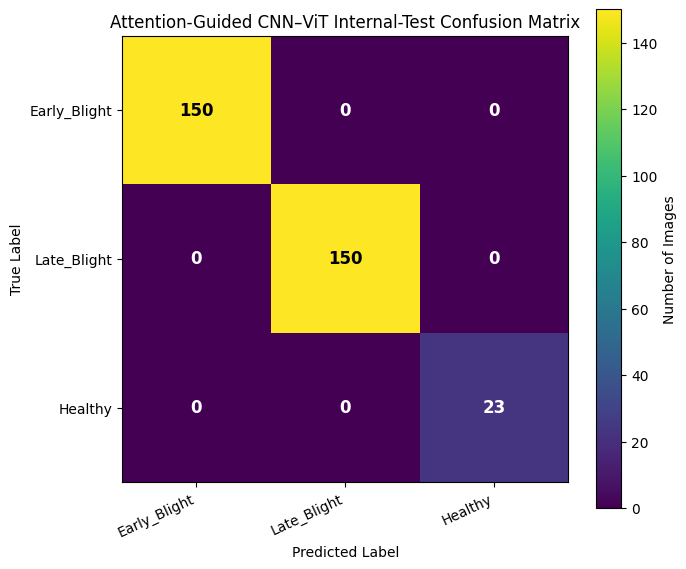

Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/predictions/attention_cnn_vit_internal_test_predictions_seed42.csv
Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/attention_weights/attention_cnn_vit_internal_test_weights_seed42.csv
Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/confusion_matrices/attention_cnn_vit_internal_test_confusion_matrix_seed42.png


In [15]:
# Cell 15: Save predictions, attention weights, and confusion matrix
prediction_df = (
    internal_test_df.copy()
)

if (
    USE_LOCAL_COPY
    and 'original_drive_path'
    in prediction_df.columns
):
    prediction_df[
        'evaluation_file_path'
    ] = prediction_df[
        'original_drive_path'
    ]
else:
    prediction_df[
        'evaluation_file_path'
    ] = prediction_df[
        'file_path'
    ]

prediction_df[
    'true_class_id'
] = internal_labels

prediction_df[
    'predicted_class_id'
] = internal_predictions

prediction_df[
    'true_class_name'
] = [
    CLASS_NAMES[index]
    for index in internal_labels
]

prediction_df[
    'predicted_class_name'
] = [
    CLASS_NAMES[index]
    for index in internal_predictions
]

prediction_df[
    'is_correct'
] = (
    prediction_df['true_class_id']
    == prediction_df[
        'predicted_class_id'
    ]
)

attention_array = np.asarray(
    internal_attention,
    dtype=np.float32,
)

prediction_df[
    'cnn_attention_weight'
] = attention_array[:, 0]

prediction_df[
    'vit_attention_weight'
] = attention_array[:, 1]

prediction_df[
    'attention_weight_sum'
] = attention_array.sum(axis=1)

prediction_path = (
    PREDICTIONS_DIR
    / 'attention_cnn_vit_internal_test_predictions_seed42.csv'
)

attention_path = (
    ATTENTION_DIR
    / 'attention_cnn_vit_internal_test_weights_seed42.csv'
)

prediction_df.to_csv(
    prediction_path,
    index=False,
)

prediction_df[
    [
        'evaluation_file_path',
        'true_class_id',
        'true_class_name',
        'predicted_class_id',
        'predicted_class_name',
        'is_correct',
        'cnn_attention_weight',
        'vit_attention_weight',
        'attention_weight_sum',
    ]
].to_csv(
    attention_path,
    index=False,
)

cm = confusion_matrix(
    internal_labels,
    internal_predictions,
    labels=[0, 1, 2],
)

fig, axis = plt.subplots(
    figsize=(7, 6)
)

image = axis.imshow(
    cm,
    cmap='viridis',
)

axis.set_xticks(
    range(len(CLASS_NAMES))
)
axis.set_yticks(
    range(len(CLASS_NAMES))
)

axis.set_xticklabels(
    CLASS_NAMES,
    rotation=25,
    ha='right',
)

axis.set_yticklabels(
    CLASS_NAMES
)

axis.set_xlabel(
    'Predicted Label'
)
axis.set_ylabel(
    'True Label'
)

axis.set_title(
    'Attention-Guided CNN–ViT Internal-Test Confusion Matrix'
)

threshold = cm.max() / 2

for row in range(
    cm.shape[0]
):
    for column in range(
        cm.shape[1]
    ):
        value = cm[
            row,
            column,
        ]

        text_color = (
            'black'
            if value > threshold
            else 'white'
        )

        axis.text(
            column,
            row,
            str(value),
            ha='center',
            va='center',
            color=text_color,
            fontsize=12,
            fontweight='bold',
        )

colorbar = fig.colorbar(
    image,
    ax=axis,
)

colorbar.set_label(
    'Number of Images'
)

plt.tight_layout()

confusion_path = (
    CONFUSION_DIR
    / 'attention_cnn_vit_internal_test_confusion_matrix_seed42.png'
)

plt.savefig(
    confusion_path,
    dpi=200,
    bbox_inches='tight',
)

plt.show()

print('Saved:', prediction_path)
print('Saved:', attention_path)
print('Saved:', confusion_path)


,true_class_name,image_count,mean_cnn_weight,std_cnn_weight,mean_vit_weight,std_vit_weight
0,Early_Blight,150,0.1509,0.0133,0.8491,0.0133
1,Late_Blight,150,0.2520,0.0307,0.7480,0.0307
2,Healthy,23,0.4049,0.0234,0.5951,0.0234


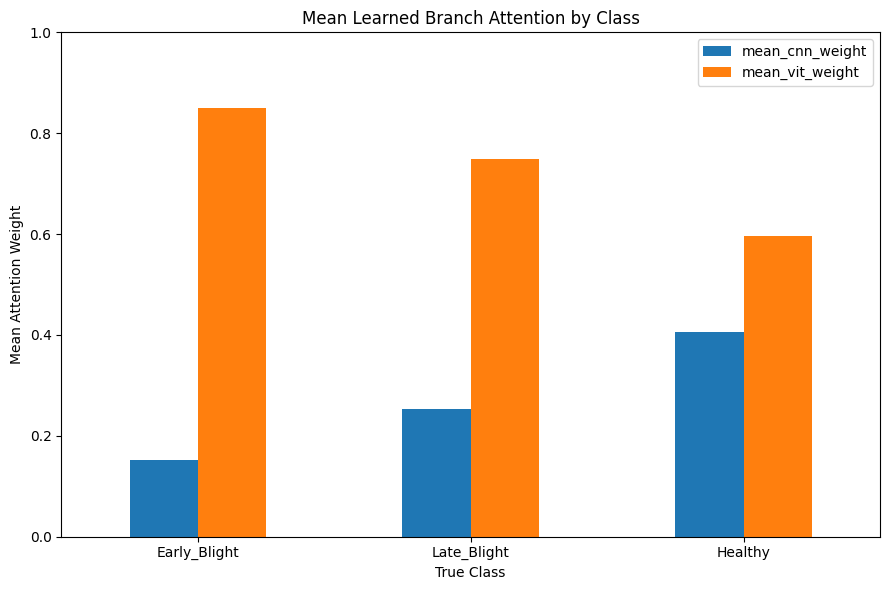

Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/attention_weights/attention_cnn_vit_internal_test_summary_seed42.csv
Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/attention_weights/attention_cnn_vit_mean_branch_weights_seed42.png


In [16]:
# Cell 16: Analyze learned branch-attention weights
attention_summary_df = (
    prediction_df.groupby(
        'true_class_name'
    )
    .agg(
        image_count=(
            'true_class_name',
            'size',
        ),

        mean_cnn_weight=(
            'cnn_attention_weight',
            'mean',
        ),

        std_cnn_weight=(
            'cnn_attention_weight',
            'std',
        ),

        mean_vit_weight=(
            'vit_attention_weight',
            'mean',
        ),

        std_vit_weight=(
            'vit_attention_weight',
            'std',
        ),
    )
    .reindex(CLASS_NAMES)
    .reset_index()
)

display(
    attention_summary_df.round(4)
)

attention_summary_path = (
    ATTENTION_DIR
    / 'attention_cnn_vit_internal_test_summary_seed42.csv'
)

attention_summary_df.to_csv(
    attention_summary_path,
    index=False,
)

plot_df = (
    attention_summary_df.set_index(
        'true_class_name'
    )[
        [
            'mean_cnn_weight',
            'mean_vit_weight',
        ]
    ]
)

axis = plot_df.plot(
    kind='bar',
    figsize=(9, 6),
)

axis.set_title(
    'Mean Learned Branch Attention by Class'
)
axis.set_xlabel(
    'True Class'
)
axis.set_ylabel(
    'Mean Attention Weight'
)
axis.set_ylim(
    0,
    1,
)
axis.tick_params(
    axis='x',
    rotation=0,
)

plt.tight_layout()

attention_figure_path = (
    ATTENTION_DIR
    / 'attention_cnn_vit_mean_branch_weights_seed42.png'
)

plt.savefig(
    attention_figure_path,
    dpi=200,
    bbox_inches='tight',
)

plt.show()

print('Saved:', attention_summary_path)
print('Saved:', attention_figure_path)


In [17]:
# Cell 17: Save model config and summary
config = {
    'created_at':
        datetime.now().isoformat(),

    'model_name':
        'Attention_Guided_CNN_ViT',

    'cnn_branch':
        'EfficientNet-B0',

    'vit_branch':
        model.vit_model_name,

    'fusion_method':
        'Learnable sample-wise branch attention',

    'attention_description':
        (
            'Softmax-normalized CNN and ViT '
            'branch weights computed separately '
            'for every input image'
        ),

    'seed':
        RANDOM_SEED,

    'class_names':
        CLASS_NAMES,

    'image_size':
        IMAGE_SIZE,

    'resize_size':
        RESIZE_SIZE,

    'batch_size':
        BATCH_SIZE,

    'num_workers':
        NUM_WORKERS,

    'optimizer':
        'AdamW',

    'learning_rate':
        LEARNING_RATE,

    'weight_decay':
        WEIGHT_DECAY,

    'loss':
        'Weighted CrossEntropyLoss',

    'projection_dim':
        PROJECTION_DIM,

    'classifier_hidden_dim':
        CLASSIFIER_HIDDEN_DIM,

    'dropout':
        DROPOUT,

    'cnn_feature_dim':
        model.cnn_feature_dim,

    'vit_feature_dim':
        model.vit_feature_dim,

    'max_epochs':
        MAX_EPOCHS,

    'early_stopping_patience':
        EARLY_STOPPING_PATIENCE,

    'best_epoch':
        best_epoch,

    'best_validation_macro_f1':
        best_val_macro_f1,

    'total_parameters':
        total_parameters,

    'trainable_parameters':
        trainable_parameters,

    'internal_test_metrics':
        internal_metrics,

    'mean_internal_cnn_attention':
        float(
            attention_array[:, 0].mean()
        ),

    'mean_internal_vit_attention':
        float(
            attention_array[:, 1].mean()
        ),

    'external_test_used':
        False,
}

config_path = (
    CONFIG_DIR
    / 'attention_cnn_vit_seed42_config.json'
)

with config_path.open(
    'w',
    encoding='utf-8',
) as file_handle:
    json.dump(
        config,
        file_handle,
        ensure_ascii=False,
        indent=2,
    )

summary_df = pd.DataFrame([
    {
        'model':
            'Attention_Guided_CNN_ViT',

        'seed':
            RANDOM_SEED,

        'best_epoch':
            best_epoch,

        'best_val_macro_f1':
            best_val_macro_f1,

        'internal_test_accuracy':
            internal_metrics[
                'accuracy'
            ],

        'internal_test_macro_precision':
            internal_metrics[
                'macro_precision'
            ],

        'internal_test_macro_recall':
            internal_metrics[
                'macro_recall'
            ],

        'internal_test_macro_f1':
            internal_metrics[
                'macro_f1'
            ],

        'total_parameters':
            total_parameters,

        'trainable_parameters':
            trainable_parameters,

        'training_minutes':
            total_training_seconds
            / 60,

        'mean_cnn_attention':
            attention_array[:, 0].mean(),

        'mean_vit_attention':
            attention_array[:, 1].mean(),
    }
])

summary_path = (
    METRICS_DIR
    / 'attention_cnn_vit_summary_seed42.csv'
)

summary_df.to_csv(
    summary_path,
    index=False,
)

display(summary_df)

print('Saved:', config_path)
print('Saved:', summary_path)


,model,seed,best_epoch,best_val_macro_f1,internal_test_accuracy,internal_test_macro_precision,internal_test_macro_recall,internal_test_macro_f1,total_parameters,trainable_parameters,training_minutes,mean_cnn_attention,mean_vit_attention
0,Attention_Guided_CNN_ViT,42,8,1.0,1.0,1.0,1.0,1.0,10109249,10109249,8.30769,0.215945,0.784055


Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/03_configs/attention_cnn_vit_seed42_config.json
Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/metrics/attention_cnn_vit_summary_seed42.csv


In [18]:
# Cell 18: Compare all four models
summary_paths = [
    (
        METRICS_DIR
        / 'cnn_efficientnet_b0_summary_seed42.csv'
    ),

    (
        METRICS_DIR
        / 'vit_deit_tiny_summary_seed42.csv'
    ),

    (
        METRICS_DIR
        / 'cnn_vit_concat_summary_seed42.csv'
    ),

    (
        METRICS_DIR
        / 'attention_cnn_vit_summary_seed42.csv'
    ),
]

comparison_frames = []

for path in summary_paths:
    if path.exists():
        comparison_frames.append(
            pd.read_csv(path)
        )
    else:
        print(
            'Warning: summary not found:',
            path.name,
        )

if comparison_frames:
    four_model_comparison_df = pd.concat(
        comparison_frames,
        ignore_index=True,
        sort=False,
    )

    four_model_comparison_path = (
        METRICS_DIR
        / 'four_model_internal_comparison_seed42.csv'
    )

    four_model_comparison_df.to_csv(
        four_model_comparison_path,
        index=False,
    )

    display(
        four_model_comparison_df
    )

    print(
        'Saved:',
        four_model_comparison_path,
    )
else:
    raise FileNotFoundError(
        'No model summary files found.'
    )


,model,seed,best_epoch,best_val_macro_f1,internal_test_accuracy,internal_test_macro_precision,internal_test_macro_recall,internal_test_macro_f1,total_parameters,trainable_parameters,training_minutes,mean_cnn_attention,mean_vit_attention
0,EfficientNet-B0,42,4,0.991793,1.0,1.0,1.0,1.0,4011391,4011391,3.645169,NaN,NaN
1,CNN_ViT_Simple_Concatenation,42,8,1.000000,1.0,1.0,1.0,1.0,10290623,10290623,8.062711,NaN,NaN
2,Attention_Guided_CNN_ViT,42,8,1.000000,1.0,1.0,1.0,1.0,10109249,10109249,8.307690,0.215945,0.784055


Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/metrics/four_model_internal_comparison_seed42.csv


In [19]:
# Cell 19: Final report
final_report_df = pd.DataFrame([
    {
        'check':
            'Attention model created',

        'passed':
            model is not None,
    },

    {
        'check':
            'Forward pass verified',

        'passed': (
            tuple(test_logits.shape)
            == expected_logits_shape
        ),
    },

    {
        'check':
            'Attention weights sum to one',

        'passed':
            bool(
                torch.allclose(
                    weight_sums,
                    torch.ones_like(
                        weight_sums
                    ),
                    atol=1e-5,
                )
            ),
    },

    {
        'check':
            'Best checkpoint saved',

        'passed':
            BEST_CHECKPOINT_PATH.exists(),
    },

    {
        'check':
            'Training history saved',

        'passed':
            HISTORY_PATH.exists(),
    },

    {
        'check':
            'Internal-test metrics saved',

        'passed':
            internal_metrics_path.exists(),
    },

    {
        'check':
            'Attention weights saved',

        'passed':
            attention_path.exists(),
    },

    {
        'check':
            'Four-model comparison saved',

        'passed':
            four_model_comparison_path.exists(),
    },

    {
        'check':
            'External test not used for tuning',

        'passed':
            True,
    },
])

display(final_report_df)

if final_report_df[
    'passed'
].all():
    print(
        '✅ Attention-guided CNN–ViT training '
        'completed successfully.'
    )

    print(
        'Next step: '
        '10_MultiSeed_and_External_Evaluation.ipynb'
    )

else:
    print(
        '⚠️ Attention-guided CNN–ViT training '
        'completed with warnings.'
    )


,check,passed
0,Attention model created,True
1,Forward pass verified,True
2,Attention weights sum to one,True
3,Best checkpoint saved,True
4,Training history saved,True
5,Internal-test metrics saved,True
6,Attention weights saved,True
7,Four-model comparison saved,True
8,External test not used for tuning,True


✅ Attention-guided CNN–ViT training completed successfully.
Next step: 10_MultiSeed_and_External_Evaluation.ipynb


---

# Part 10 — 10. Multi-Seed and External Evaluation

**Purpose:** Evaluate available checkpoints across seeds on PlantVillage internal test data and PLDD-UP external field data, including aggregate metrics and uncertainty estimates.

**Source notebook:** `10_MultiSeed_and_External_Evaluation.ipynb`

**Preservation note:** The original code cells and their saved execution outputs are retained below. Textual headings/comments are lightly normalized into English where possible without changing experiment logic.


# 10 — Multi-Seed and External Evaluation

This notebook চারটি trained model-এর **internal বনাম natural-field external evaluation** করবে।

## Models

1. CNN — EfficientNet-B0  
2. ViT — DeiT-Tiny  
3. CNN–ViT Simple Concatenation  
4. Proposed Attention-Guided CNN–ViT  

## Evaluation datasets

- `internal_test.csv` → PlantVillage controlled environment
- `external_test.csv` → PLDD-UP natural-field environment

## Important rules

- External dataset দিয়ে model train, tune বা checkpoint select করা হবে না।
- Validation set দিয়ে আগে নির্বাচিত best checkpoint-ই external dataset-এ test হবে।
- Notebook বর্তমানে পাওয়া সব seed checkpoint evaluate করবে।
- Target seeds: `42, 123, 2026`
- শুধু seed `42` পাওয়া গেলে external evaluation সম্পন্ন হবে, কিন্তু multi-seed experiment incomplete হিসেবে report হবে।
- পরে অতিরিক্ত seed checkpoint যোগ করলে একই notebook আবার চালালেই multi-seed mean ± standard deviation তৈরি হবে।


In [1]:
# Cell 1: Mount Google Drive and install timm
from google.colab import drive

drive.mount('/content/drive', force_remount=True)

!pip -q install timm


Mounted at /content/drive


In [2]:
# Cell 2: Imports and evaluation settings
from pathlib import Path
from datetime import datetime
import gc
import json
import os
import random
import shutil
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import efficientnet_b0

import timm

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
)

RANDOM_SEED = 42
TARGET_SEEDS = [42, 123, 2026]

CLASS_NAMES = [
    'Early_Blight',
    'Late_Blight',
    'Healthy',
]

CLASS_ID_MAP = {
    'Early_Blight': 0,
    'Late_Blight': 1,
    'Healthy': 2,
}

IMAGE_SIZE = 224
RESIZE_SIZE = 256
NUM_WORKERS = 2

MODEL_BATCH_SIZES = {
    'CNN_EfficientNet_B0': 32,
    'ViT_DeiT_Tiny': 32,
    'CNN_ViT_Concatenation': 16,
    'Attention_Guided_CNN_ViT': 16,
}

BOOTSTRAP_ITERATIONS = 500
BOOTSTRAP_CONFIDENCE = 0.95

USE_LOCAL_COPY_INTERNAL = True
USE_LOCAL_COPY_EXTERNAL = True

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

DEVICE = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
)

AMP_ENABLED = torch.cuda.is_available()

print('PyTorch:', torch.__version__)
print('timm:', timm.__version__)
print('Device:', DEVICE)

if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
else:
    print('⚠️ Runtime → Change runtime type → T4 GPU নির্বাচন করো।')


PyTorch: 2.11.0+cu128
timm: 1.0.28
Device: cuda
GPU: Tesla T4


In [3]:
# Cell 3: Locate project folders
MY_DRIVE = Path('/content/drive/MyDrive')

standard_project = (
    MY_DRIVE / 'Potato_CNN_ViT_Research'
)

if standard_project.is_dir():
    PROJECT_ROOT = standard_project
else:
    matches = [
        path
        for path in MY_DRIVE.rglob(
            'Potato_CNN_ViT_Research'
        )
        if path.is_dir()
    ]

    if not matches:
        raise FileNotFoundError(
            'Potato_CNN_ViT_Research folder My Drive-এ পাওয়া যায়নি।'
        )

    PROJECT_ROOT = matches[0]

DATA_DIR = PROJECT_ROOT / '02_data'
SPLITS_DIR = DATA_DIR / 'splits'
METADATA_DIR = DATA_DIR / 'metadata'

CHECKPOINT_ROOT = PROJECT_ROOT / '04_checkpoints'

METRICS_DIR = (
    PROJECT_ROOT / '05_results' / 'metrics'
)
PREDICTIONS_DIR = (
    PROJECT_ROOT / '05_results' / 'predictions'
)
CONFUSION_DIR = (
    PROJECT_ROOT / '05_results' / 'confusion_matrices'
)
FIGURES_DIR = (
    PROJECT_ROOT / '05_results' / 'figures'
)
ATTENTION_DIR = (
    PROJECT_ROOT / '05_results' / 'attention_weights'
)
STATISTICS_DIR = (
    PROJECT_ROOT / '05_results' / 'statistical_analysis'
)

for folder in [
    METRICS_DIR,
    PREDICTIONS_DIR,
    CONFUSION_DIR,
    FIGURES_DIR,
    ATTENTION_DIR,
    STATISTICS_DIR,
]:
    folder.mkdir(
        parents=True,
        exist_ok=True,
    )

print('PROJECT_ROOT:', PROJECT_ROOT)
print('CHECKPOINT_ROOT:', CHECKPOINT_ROOT)
print('STATISTICS_DIR:', STATISTICS_DIR)


PROJECT_ROOT: /content/drive/MyDrive/Potato_CNN_ViT_Research
CHECKPOINT_ROOT: /content/drive/MyDrive/Potato_CNN_ViT_Research/04_checkpoints
STATISTICS_DIR: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/statistical_analysis


In [4]:
# Cell 4: Load internal and external test CSV files
internal_test_path = (
    SPLITS_DIR / 'internal_test.csv'
)

external_test_path = (
    SPLITS_DIR / 'external_test.csv'
)

for path in [
    internal_test_path,
    external_test_path,
]:
    if not path.exists():
        raise FileNotFoundError(
            f'Test CSV পাওয়া যায়নি: {path}'
        )

internal_df = pd.read_csv(
    internal_test_path
)

external_df = pd.read_csv(
    external_test_path
)

for dataset_name, frame in [
    ('internal_test', internal_df),
    ('external_test', external_df),
]:
    required_columns = {
        'file_path',
        'unified_class',
        'class_id',
    }

    missing = (
        required_columns
        - set(frame.columns)
    )

    if missing:
        raise KeyError(
            f'{dataset_name} CSV-তে column missing: '
            f'{sorted(missing)}'
        )

    frame['file_path'] = (
        frame['file_path'].astype(str)
    )

    frame['unified_class'] = (
        frame['unified_class'].astype(str)
    )

    frame['class_id'] = (
        frame['class_id'].astype(int)
    )

    missing_files = int(
        (
            ~frame['file_path'].map(
                lambda value: Path(value).exists()
            )
        ).sum()
    )

    if missing_files:
        raise FileNotFoundError(
            f'{dataset_name}-এ '
            f'{missing_files}টি image path missing।'
        )

print('Internal-test images:', len(internal_df))
print('External-test images:', len(external_df))

display(
    internal_df.groupby(
        ['unified_class', 'class_id']
    ).size().reset_index(
        name='image_count'
    )
)

display(
    external_df.groupby(
        ['unified_class', 'class_id']
    ).size().reset_index(
        name='image_count'
    )
)


Internal-test images: 323
External-test images: 15260


,unified_class,class_id,image_count
0,Early_Blight,0,150
1,Healthy,2,23
2,Late_Blight,1,150


,unified_class,class_id,image_count
0,Early_Blight,0,4743
1,Healthy,2,4448
2,Late_Blight,1,6069


In [5]:
# Cell 5: Optional local copies for faster evaluation
INTERNAL_LOCAL_ROOT = Path(
    '/content/plantvillage_internal_local'
)

EXTERNAL_LOCAL_ROOT = Path(
    '/content/pldd_up_external_local'
)


def copy_dataset_root(
    dataframe,
    local_root,
    dataset_name,
):
    sample_path = Path(
        dataframe.iloc[0]['file_path']
    )

    source_root = (
        sample_path.parent.parent
    )

    if not local_root.exists():
        print(
            f'{dataset_name} /content-এ copy হচ্ছে...'
        )

        shutil.copytree(
            source_root,
            local_root,
            dirs_exist_ok=True,
        )

        print(
            f'{dataset_name} local copy completed.'
        )
    else:
        print(
            f'Existing {dataset_name} local copy ব্যবহার করা হচ্ছে।'
        )

    updated = dataframe.copy()

    updated['original_drive_path'] = (
        updated['file_path']
    )

    updated['file_path'] = (
        updated['file_path'].map(
            lambda value: str(
                local_root
                / Path(value).parent.name
                / Path(value).name
            )
        )
    )

    missing_local = int(
        (
            ~updated['file_path'].map(
                lambda value: Path(value).exists()
            )
        ).sum()
    )

    if missing_local:
        raise FileNotFoundError(
            f'{dataset_name} local copy-তে '
            f'{missing_local}টি image missing।'
        )

    return updated


if USE_LOCAL_COPY_INTERNAL:
    internal_eval_df = copy_dataset_root(
        internal_df,
        INTERNAL_LOCAL_ROOT,
        'PlantVillage internal test',
    )
else:
    internal_eval_df = internal_df.copy()


if USE_LOCAL_COPY_EXTERNAL:
    external_eval_df = copy_dataset_root(
        external_df,
        EXTERNAL_LOCAL_ROOT,
        'PLDD-UP external test',
    )
else:
    external_eval_df = external_df.copy()


print(
    'Internal path mode:',
    (
        'Local'
        if USE_LOCAL_COPY_INTERNAL
        else 'Drive'
    ),
)

print(
    'External path mode:',
    (
        'Local'
        if USE_LOCAL_COPY_EXTERNAL
        else 'Drive'
    ),
)


PlantVillage internal test /content-এ copy হচ্ছে...
PlantVillage internal test local copy completed.
PLDD-UP external test /content-এ copy হচ্ছে...
PLDD-UP external test local copy completed.
Internal path mode: Local
External path mode: Local


In [6]:
# Cell 6: Evaluation transform and Dataset
eval_transform = transforms.Compose([
    transforms.Resize(
        (RESIZE_SIZE, RESIZE_SIZE)
    ),

    transforms.CenterCrop(
        IMAGE_SIZE
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD,
    ),
])


class PotatoLeafDataset(Dataset):
    def __init__(
        self,
        dataframe,
        transform=None,
    ):
        self.dataframe = (
            dataframe.reset_index(
                drop=True
            ).copy()
        )

        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]

        with Image.open(
            row['file_path']
        ) as image:
            image = image.convert('RGB')

        if self.transform is not None:
            image = self.transform(image)

        return {
            'image': image,

            'label': torch.tensor(
                int(row['class_id']),
                dtype=torch.long,
            ),

            'file_path': str(
                row['file_path']
            ),

            'class_name': str(
                row['unified_class']
            ),
        }


internal_dataset = PotatoLeafDataset(
    internal_eval_df,
    transform=eval_transform,
)

external_dataset = PotatoLeafDataset(
    external_eval_df,
    transform=eval_transform,
)

print('Internal dataset:', len(internal_dataset))
print('External dataset:', len(external_dataset))


Internal dataset: 323
External dataset: 15260


In [7]:
# Cell 7: Define all four model architectures
class CNNViTConcatenationModel(nn.Module):
    def __init__(
        self,
        num_classes,
        vit_model_name,
        hidden_dim=512,
        dropout=0.35,
    ):
        super().__init__()

        cnn_model = efficientnet_b0(
            weights=None
        )

        self.cnn_features = (
            cnn_model.features
        )

        self.cnn_pool = (
            nn.AdaptiveAvgPool2d(1)
        )

        self.cnn_feature_dim = (
            cnn_model.classifier[1]
            .in_features
        )

        self.vit_backbone = (
            timm.create_model(
                vit_model_name,
                pretrained=False,
                num_classes=0,
                global_pool='avg',
            )
        )

        self.vit_model_name = (
            vit_model_name
        )

        self.vit_feature_dim = (
            self.vit_backbone.num_features
        )

        self.concatenated_dim = (
            self.cnn_feature_dim
            + self.vit_feature_dim
        )

        self.classifier = nn.Sequential(
            nn.LayerNorm(
                self.concatenated_dim
            ),

            nn.Dropout(
                p=dropout
            ),

            nn.Linear(
                self.concatenated_dim,
                hidden_dim,
            ),

            nn.GELU(),

            nn.Dropout(
                p=dropout
            ),

            nn.Linear(
                hidden_dim,
                num_classes,
            ),
        )

    def forward(self, images):
        cnn_map = self.cnn_features(
            images
        )

        cnn_features = (
            self.cnn_pool(cnn_map)
            .flatten(1)
        )

        vit_features = (
            self.vit_backbone(images)
        )

        fused_features = torch.cat(
            [
                cnn_features,
                vit_features,
            ],
            dim=1,
        )

        return self.classifier(
            fused_features
        )


class AttentionGuidedCNNViT(nn.Module):
    def __init__(
        self,
        num_classes,
        vit_model_name,
        projection_dim=256,
        classifier_hidden_dim=256,
        dropout=0.35,
    ):
        super().__init__()

        cnn_model = efficientnet_b0(
            weights=None
        )

        self.cnn_features = (
            cnn_model.features
        )

        self.cnn_pool = (
            nn.AdaptiveAvgPool2d(1)
        )

        self.cnn_feature_dim = (
            cnn_model.classifier[1]
            .in_features
        )

        self.vit_backbone = (
            timm.create_model(
                vit_model_name,
                pretrained=False,
                num_classes=0,
                global_pool='avg',
            )
        )

        self.vit_model_name = (
            vit_model_name
        )

        self.vit_feature_dim = (
            self.vit_backbone.num_features
        )

        self.cnn_projection = nn.Sequential(
            nn.Linear(
                self.cnn_feature_dim,
                projection_dim,
            ),

            nn.LayerNorm(
                projection_dim
            ),

            nn.GELU(),

            nn.Dropout(
                p=dropout
            ),
        )

        self.vit_projection = nn.Sequential(
            nn.Linear(
                self.vit_feature_dim,
                projection_dim,
            ),

            nn.LayerNorm(
                projection_dim
            ),

            nn.GELU(),

            nn.Dropout(
                p=dropout
            ),
        )

        self.attention_gate = nn.Sequential(
            nn.Linear(
                projection_dim * 2,
                projection_dim,
            ),

            nn.GELU(),

            nn.Dropout(
                p=dropout
            ),

            nn.Linear(
                projection_dim,
                2,
            ),
        )

        self.classifier = nn.Sequential(
            nn.LayerNorm(
                projection_dim
            ),

            nn.Dropout(
                p=dropout
            ),

            nn.Linear(
                projection_dim,
                classifier_hidden_dim,
            ),

            nn.GELU(),

            nn.Dropout(
                p=dropout
            ),

            nn.Linear(
                classifier_hidden_dim,
                num_classes,
            ),
        )

    def forward(
        self,
        images,
        return_attention=False,
    ):
        cnn_map = self.cnn_features(
            images
        )

        cnn_raw = (
            self.cnn_pool(cnn_map)
            .flatten(1)
        )

        vit_raw = (
            self.vit_backbone(images)
        )

        cnn_projected = (
            self.cnn_projection(cnn_raw)
        )

        vit_projected = (
            self.vit_projection(vit_raw)
        )

        joint = torch.cat(
            [
                cnn_projected,
                vit_projected,
            ],
            dim=1,
        )

        attention_weights = torch.softmax(
            self.attention_gate(joint),
            dim=1,
        )

        fused = (
            attention_weights[:, 0:1]
            * cnn_projected
            +
            attention_weights[:, 1:2]
            * vit_projected
        )

        logits = self.classifier(
            fused
        )

        if return_attention:
            return logits, attention_weights

        return logits


def safe_torch_load(path):
    try:
        return torch.load(
            path,
            map_location='cpu',
            weights_only=False,
        )
    except TypeError:
        return torch.load(
            path,
            map_location='cpu',
        )


def build_model_from_checkpoint(
    model_key,
    checkpoint,
):
    config = checkpoint.get(
        'config',
        {},
    )

    if model_key == 'CNN_EfficientNet_B0':
        model = efficientnet_b0(
            weights=None
        )

        dropout = float(
            config.get(
                'dropout',
                0.30,
            )
        )

        in_features = (
            model.classifier[1]
            .in_features
        )

        model.classifier = nn.Sequential(
            nn.Dropout(
                p=dropout
            ),

            nn.Linear(
                in_features,
                len(CLASS_NAMES),
            ),
        )

        return model


    if model_key == 'ViT_DeiT_Tiny':
        model_name = checkpoint.get(
            'model_name',
            'deit_tiny_patch16_224.fb_in1k',
        )

        dropout = float(
            config.get(
                'dropout',
                0.30,
            )
        )

        return timm.create_model(
            model_name,
            pretrained=False,
            num_classes=len(CLASS_NAMES),
            drop_rate=dropout,
        )


    if model_key == 'CNN_ViT_Concatenation':
        vit_model_name = checkpoint.get(
            'vit_branch',
            'deit_tiny_patch16_224.fb_in1k',
        )

        return CNNViTConcatenationModel(
            num_classes=len(CLASS_NAMES),
            vit_model_name=vit_model_name,
            hidden_dim=int(
                config.get(
                    'fusion_hidden_dim',
                    512,
                )
            ),
            dropout=float(
                config.get(
                    'dropout',
                    0.35,
                )
            ),
        )


    if model_key == 'Attention_Guided_CNN_ViT':
        vit_model_name = checkpoint.get(
            'vit_branch',
            'deit_tiny_patch16_224.fb_in1k',
        )

        return AttentionGuidedCNNViT(
            num_classes=len(CLASS_NAMES),
            vit_model_name=vit_model_name,
            projection_dim=int(
                config.get(
                    'projection_dim',
                    256,
                )
            ),
            classifier_hidden_dim=int(
                config.get(
                    'classifier_hidden_dim',
                    256,
                )
            ),
            dropout=float(
                config.get(
                    'dropout',
                    0.35,
                )
            ),
        )


    raise ValueError(
        f'Unknown model key: {model_key}'
    )


In [8]:
# Cell 8: Discover all target-seed checkpoints
MODEL_CHECKPOINT_PATTERNS = {
    'CNN_EfficientNet_B0': (
        CHECKPOINT_ROOT
        / 'cnn'
        / 'efficientnet_b0_best_seed{seed}.pth'
    ),

    'ViT_DeiT_Tiny': (
        CHECKPOINT_ROOT
        / 'vit'
        / 'deit_tiny_best_seed{seed}.pth'
    ),

    'CNN_ViT_Concatenation': (
        CHECKPOINT_ROOT
        / 'concat'
        / 'cnn_vit_concat_best_seed{seed}.pth'
    ),

    'Attention_Guided_CNN_ViT': (
        CHECKPOINT_ROOT
        / 'attention'
        / 'attention_cnn_vit_best_seed{seed}.pth'
    ),
}

checkpoint_rows = []

for model_name, pattern in (
    MODEL_CHECKPOINT_PATTERNS.items()
):
    for seed in TARGET_SEEDS:
        path = Path(
            str(pattern).format(
                seed=seed
            )
        )

        checkpoint_rows.append({
            'model': model_name,
            'seed': seed,
            'checkpoint_path': str(path),
            'checkpoint_exists': path.exists(),
        })

checkpoint_inventory_df = pd.DataFrame(
    checkpoint_rows
)

display(
    checkpoint_inventory_df
)

checkpoint_inventory_path = (
    METADATA_DIR
    / 'multiseed_checkpoint_inventory.csv'
)

checkpoint_inventory_df.to_csv(
    checkpoint_inventory_path,
    index=False,
)

available_checkpoint_df = (
    checkpoint_inventory_df[
        checkpoint_inventory_df[
            'checkpoint_exists'
        ]
    ].copy()
)

missing_checkpoint_df = (
    checkpoint_inventory_df[
        ~checkpoint_inventory_df[
            'checkpoint_exists'
        ]
    ].copy()
)

print(
    'Available checkpoints:',
    len(available_checkpoint_df),
)

print(
    'Missing target checkpoints:',
    len(missing_checkpoint_df),
)

print('Saved:', checkpoint_inventory_path)


,model,seed,checkpoint_path,checkpoint_exists
0,CNN_EfficientNet_B0,42,/content/drive/MyDrive/Potato_CNN_ViT_Research...,True
1,CNN_EfficientNet_B0,123,/content/drive/MyDrive/Potato_CNN_ViT_Research...,True
2,CNN_EfficientNet_B0,2026,/content/drive/MyDrive/Potato_CNN_ViT_Research...,True
3,ViT_DeiT_Tiny,42,/content/drive/MyDrive/Potato_CNN_ViT_Research...,True
4,ViT_DeiT_Tiny,123,/content/drive/MyDrive/Potato_CNN_ViT_Research...,True
5,ViT_DeiT_Tiny,2026,/content/drive/MyDrive/Potato_CNN_ViT_Research...,True
6,CNN_ViT_Concatenation,42,/content/drive/MyDrive/Potato_CNN_ViT_Research...,True
7,CNN_ViT_Concatenation,123,/content/drive/MyDrive/Potato_CNN_ViT_Research...,True
8,CNN_ViT_Concatenation,2026,/content/drive/MyDrive/Potato_CNN_ViT_Research...,True
9,Attention_Guided_CNN_ViT,42,/content/drive/MyDrive/Potato_CNN_ViT_Research...,True


Available checkpoints: 12
Missing target checkpoints: 0
Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/02_data/metadata/multiseed_checkpoint_inventory.csv


In [9]:
# Cell 9: Evaluation helpers
def calculate_metrics(
    y_true,
    y_pred,
):
    accuracy = accuracy_score(
        y_true,
        y_pred,
    )

    precision, recall, macro_f1, _ = (
        precision_recall_fscore_support(
            y_true,
            y_pred,
            average='macro',
            zero_division=0,
        )
    )

    return {
        'accuracy': float(accuracy),
        'macro_precision': float(precision),
        'macro_recall': float(recall),
        'macro_f1': float(macro_f1),
    }


def evaluate_model(
    model,
    dataset,
    batch_size,
    collect_attention=False,
):
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
        persistent_workers=(
            NUM_WORKERS > 0
        ),
    )

    model.eval()

    all_labels = []
    all_predictions = []
    all_probabilities = []
    all_attention = []

    start_time = time.time()

    with torch.no_grad():
        for batch_index, batch in enumerate(
            loader,
            start=1,
        ):
            images = batch['image'].to(
                DEVICE,
                non_blocking=True,
            )

            labels = batch['label'].to(
                DEVICE,
                non_blocking=True,
            )

            try:
                autocast_context = (
                    torch.amp.autocast(
                        device_type='cuda',
                        enabled=AMP_ENABLED,
                    )
                )
            except TypeError:
                autocast_context = (
                    torch.cuda.amp.autocast(
                        enabled=AMP_ENABLED,
                    )
                )

            with autocast_context:
                if collect_attention:
                    (
                        logits,
                        attention_weights,
                    ) = model(
                        images,
                        return_attention=True,
                    )
                else:
                    logits = model(images)
                    attention_weights = None

            probabilities = torch.softmax(
                logits,
                dim=1,
            )

            predictions = logits.argmax(
                dim=1
            )

            all_labels.extend(
                labels.cpu().tolist()
            )

            all_predictions.extend(
                predictions.cpu().tolist()
            )

            all_probabilities.extend(
                probabilities.cpu().tolist()
            )

            if (
                collect_attention
                and attention_weights is not None
            ):
                all_attention.extend(
                    attention_weights
                    .cpu()
                    .tolist()
                )

            if batch_index % 200 == 0:
                print(
                    f'  Evaluated '
                    f'{batch_index}/{len(loader)} batches'
                )

    elapsed_seconds = (
        time.time() - start_time
    )

    metrics = calculate_metrics(
        all_labels,
        all_predictions,
    )

    metrics['evaluation_seconds'] = float(
        elapsed_seconds
    )

    metrics['images_per_second'] = float(
        len(dataset)
        / max(elapsed_seconds, 1e-9)
    )

    return {
        'metrics': metrics,
        'labels': all_labels,
        'predictions': all_predictions,
        'probabilities': all_probabilities,
        'attention': all_attention,
    }


In [10]:
# Cell 10: Evaluate every available checkpoint
all_metric_rows = []
all_prediction_frames = []
attention_prediction_frames = []

for checkpoint_row in (
    available_checkpoint_df
    .sort_values(
        ['seed', 'model']
    )
    .itertuples(index=False)
):
    model_name = checkpoint_row.model
    seed = int(checkpoint_row.seed)

    checkpoint_path = Path(
        checkpoint_row.checkpoint_path
    )

    print('\n' + '=' * 80)
    print('Model:', model_name)
    print('Seed:', seed)
    print('Checkpoint:', checkpoint_path)

    checkpoint = safe_torch_load(
        checkpoint_path
    )

    model = build_model_from_checkpoint(
        model_name,
        checkpoint,
    )

    model.load_state_dict(
        checkpoint[
            'model_state_dict'
        ]
    )

    model = model.to(DEVICE)

    total_parameters = sum(
        parameter.numel()
        for parameter in model.parameters()
    )

    batch_size = MODEL_BATCH_SIZES[
        model_name
    ]

    collect_attention = (
        model_name
        == 'Attention_Guided_CNN_ViT'
    )

    for dataset_name, dataset, original_frame in [
        (
            'internal_test',
            internal_dataset,
            internal_df,
        ),
        (
            'external_test',
            external_dataset,
            external_df,
        ),
    ]:
        print(
            f'\nEvaluating {dataset_name} '
            f'with batch size {batch_size}...'
        )

        result = evaluate_model(
            model=model,
            dataset=dataset,
            batch_size=batch_size,
            collect_attention=collect_attention,
        )

        metrics = result['metrics']

        metric_row = {
            'model': model_name,
            'seed': seed,
            'dataset': dataset_name,
            'image_count': len(dataset),
            'total_parameters': total_parameters,
            **metrics,
        }

        all_metric_rows.append(
            metric_row
        )

        prediction_frame = (
            original_frame.copy()
            .reset_index(drop=True)
        )

        prediction_frame[
            'model'
        ] = model_name

        prediction_frame[
            'seed'
        ] = seed

        prediction_frame[
            'evaluation_dataset'
        ] = dataset_name

        prediction_frame[
            'true_class_id'
        ] = result['labels']

        prediction_frame[
            'predicted_class_id'
        ] = result['predictions']

        prediction_frame[
            'true_class_name'
        ] = [
            CLASS_NAMES[index]
            for index in result['labels']
        ]

        prediction_frame[
            'predicted_class_name'
        ] = [
            CLASS_NAMES[index]
            for index in result['predictions']
        ]

        prediction_frame[
            'is_correct'
        ] = (
            prediction_frame[
                'true_class_id'
            ]
            ==
            prediction_frame[
                'predicted_class_id'
            ]
        )

        probability_array = np.asarray(
            result['probabilities'],
            dtype=np.float32,
        )

        for class_index, class_name in enumerate(
            CLASS_NAMES
        ):
            prediction_frame[
                f'probability_{class_name}'
            ] = probability_array[
                :,
                class_index,
            ]

        if collect_attention:
            attention_array = np.asarray(
                result['attention'],
                dtype=np.float32,
            )

            prediction_frame[
                'cnn_attention_weight'
            ] = attention_array[:, 0]

            prediction_frame[
                'vit_attention_weight'
            ] = attention_array[:, 1]

            attention_prediction_frames.append(
                prediction_frame.copy()
            )

        prediction_path = (
            PREDICTIONS_DIR
            / (
                f'{model_name}_seed{seed}_'
                f'{dataset_name}_predictions.csv'
            )
        )

        prediction_frame.to_csv(
            prediction_path,
            index=False,
        )

        all_prediction_frames.append(
            prediction_frame
        )

        print(
            'Metrics:',
            {
                key: round(value, 4)
                for key, value in metrics.items()
                if isinstance(
                    value,
                    (int, float),
                )
            },
        )

        print(
            'Saved:',
            prediction_path,
        )

    del model
    del checkpoint

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


all_metrics_df = pd.DataFrame(
    all_metric_rows
)

all_metrics_path = (
    METRICS_DIR
    / 'all_available_seed_internal_external_metrics.csv'
)

all_metrics_df.to_csv(
    all_metrics_path,
    index=False,
)

display(
    all_metrics_df.sort_values(
        ['dataset', 'macro_f1'],
        ascending=[True, False],
    )
)

print('Saved:', all_metrics_path)



Model: Attention_Guided_CNN_ViT
Seed: 42
Checkpoint: /content/drive/MyDrive/Potato_CNN_ViT_Research/04_checkpoints/attention/attention_cnn_vit_best_seed42.pth

Evaluating internal_test with batch size 16...
Metrics: {'accuracy': 1.0, 'macro_precision': 1.0, 'macro_recall': 1.0, 'macro_f1': 1.0, 'evaluation_seconds': 11.6692, 'images_per_second': 27.6796}
Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/predictions/Attention_Guided_CNN_ViT_seed42_internal_test_predictions.csv

Evaluating external_test with batch size 16...
  Evaluated 200/954 batches
  Evaluated 400/954 batches
  Evaluated 600/954 batches
  Evaluated 800/954 batches
Metrics: {'accuracy': 0.5044, 'macro_precision': 0.6339, 'macro_recall': 0.4743, 'macro_f1': 0.4438, 'evaluation_seconds': 1282.0894, 'images_per_second': 11.9024}
Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/predictions/Attention_Guided_CNN_ViT_seed42_external_test_predictions.csv

Model: CNN_EfficientNet_B0
Seed: 42
Che

,model,seed,dataset,image_count,total_parameters,accuracy,macro_precision,macro_recall,macro_f1,evaluation_seconds,images_per_second
13,CNN_ViT_Concatenation,123,external_test,15260,10290623,0.662058,0.718204,0.667478,0.673263,1283.093184,11.893135
15,ViT_DeiT_Tiny,123,external_test,15260,5524995,0.659436,0.703072,0.648458,0.659583,1271.010538,12.006195
5,CNN_ViT_Concatenation,42,external_test,15260,10290623,0.661730,0.700940,0.643258,0.652865,1288.961437,11.838989
7,ViT_DeiT_Tiny,42,external_test,15260,5524995,0.627588,0.696994,0.601806,0.608529,1255.045191,12.158925
17,Attention_Guided_CNN_ViT,2026,external_test,15260,10109249,0.616776,0.686766,0.599203,0.605494,1278.056360,11.940006
23,ViT_DeiT_Tiny,2026,external_test,15260,5524995,0.618611,0.701622,0.596172,0.603142,1251.266521,12.195643
9,Attention_Guided_CNN_ViT,123,external_test,15260,10109249,0.584338,0.682270,0.555409,0.562921,1269.841158,12.017251
19,CNN_EfficientNet_B0,2026,external_test,15260,4011391,0.515203,0.578050,0.537067,0.517469,1273.079870,11.986679
11,CNN_EfficientNet_B0,123,external_test,15260,4011391,0.527588,0.570890,0.552446,0.514052,1244.654434,12.260431
21,CNN_ViT_Concatenation,2026,external_test,15260,10290623,0.523460,0.645911,0.488151,0.444787,1283.900580,11.885656


Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/metrics/all_available_seed_internal_external_metrics.csv


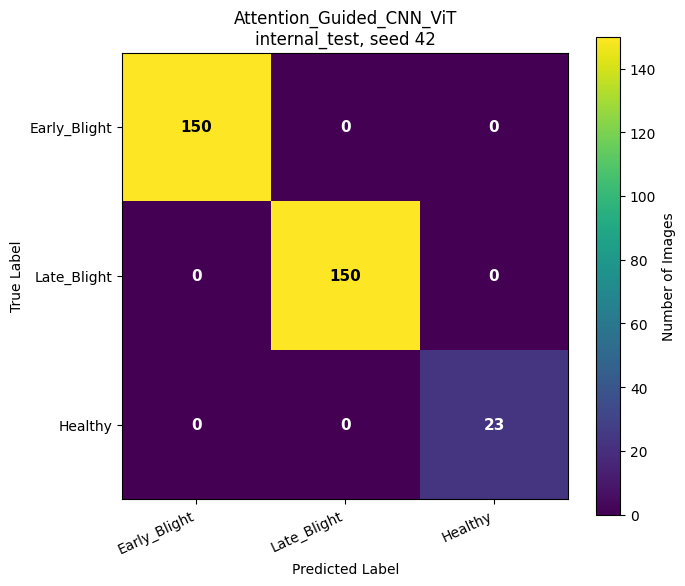

Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/confusion_matrices/Attention_Guided_CNN_ViT_seed42_internal_test_confusion_matrix.png


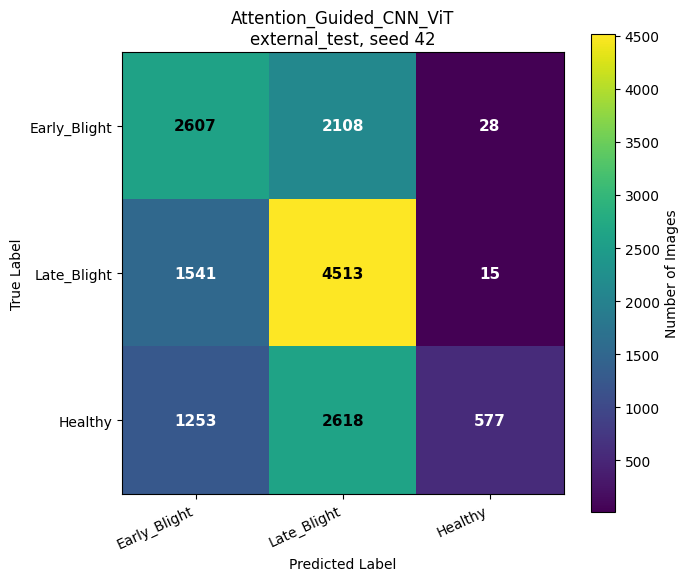

Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/confusion_matrices/Attention_Guided_CNN_ViT_seed42_external_test_confusion_matrix.png


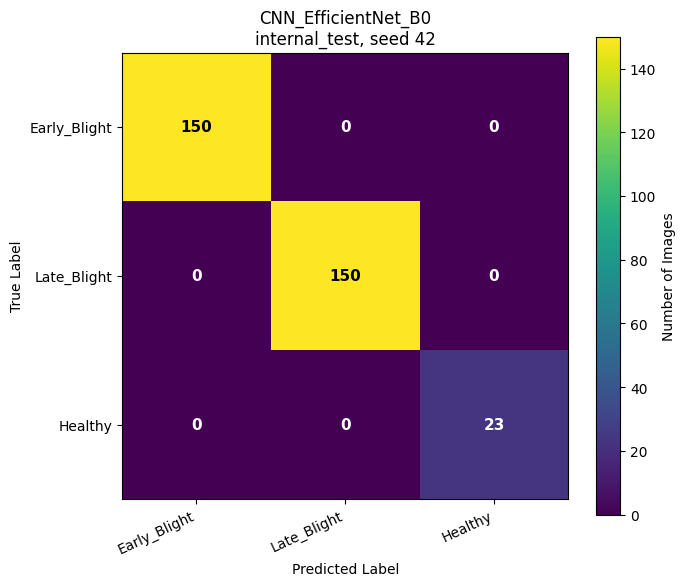

Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/confusion_matrices/CNN_EfficientNet_B0_seed42_internal_test_confusion_matrix.png


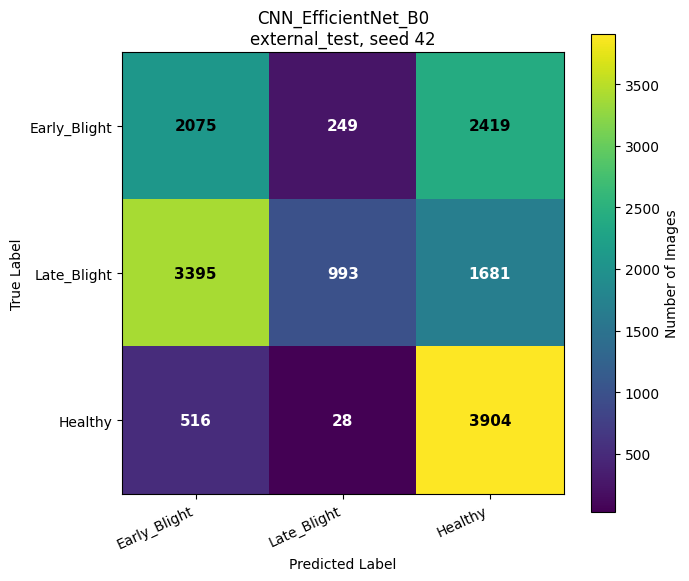

Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/confusion_matrices/CNN_EfficientNet_B0_seed42_external_test_confusion_matrix.png


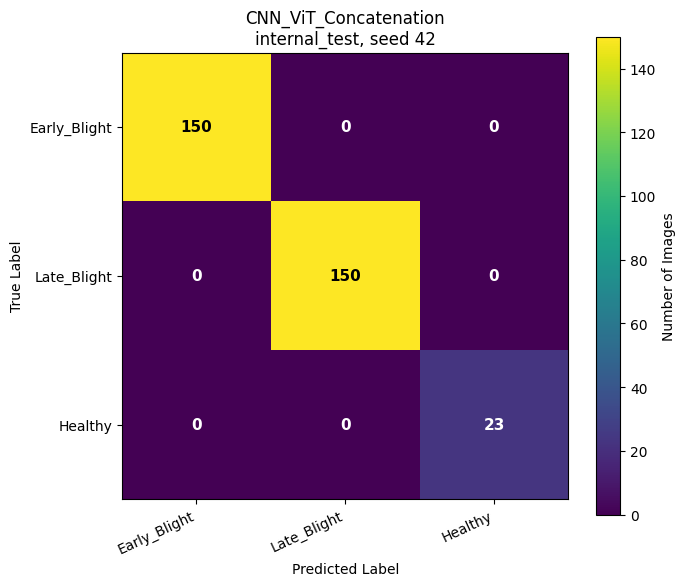

Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/confusion_matrices/CNN_ViT_Concatenation_seed42_internal_test_confusion_matrix.png


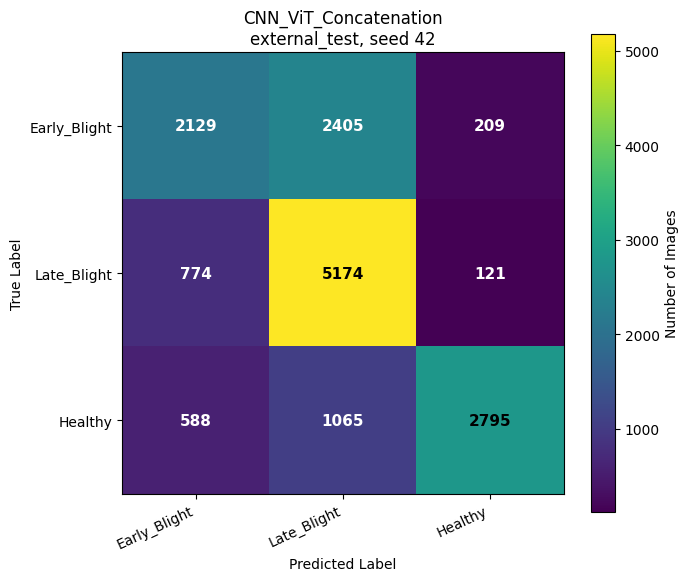

Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/confusion_matrices/CNN_ViT_Concatenation_seed42_external_test_confusion_matrix.png


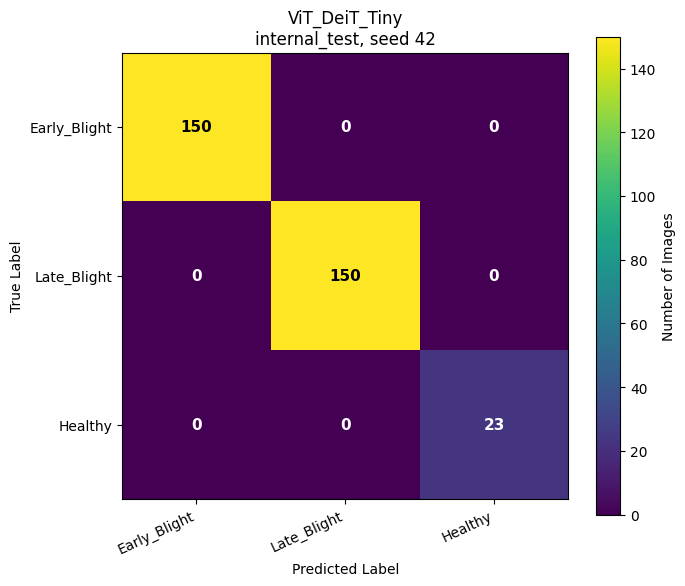

Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/confusion_matrices/ViT_DeiT_Tiny_seed42_internal_test_confusion_matrix.png


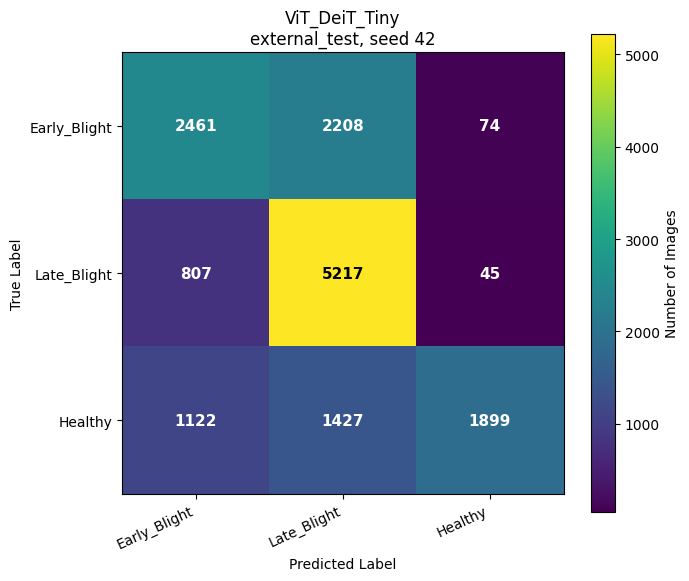

Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/confusion_matrices/ViT_DeiT_Tiny_seed42_external_test_confusion_matrix.png


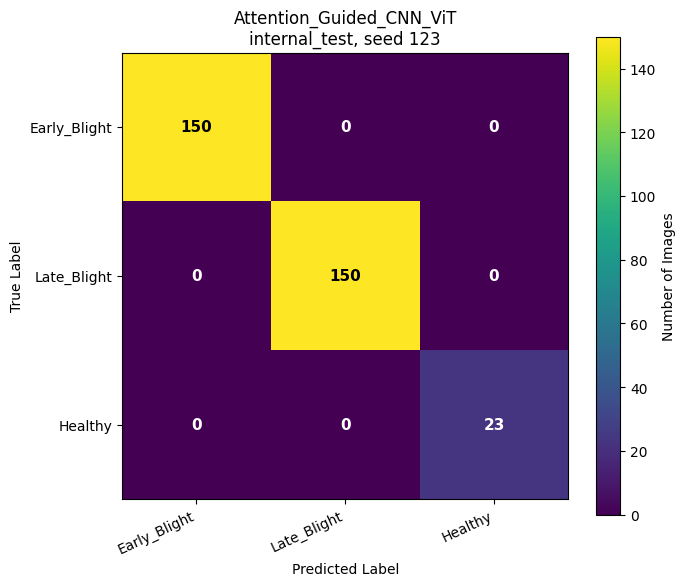

Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/confusion_matrices/Attention_Guided_CNN_ViT_seed123_internal_test_confusion_matrix.png


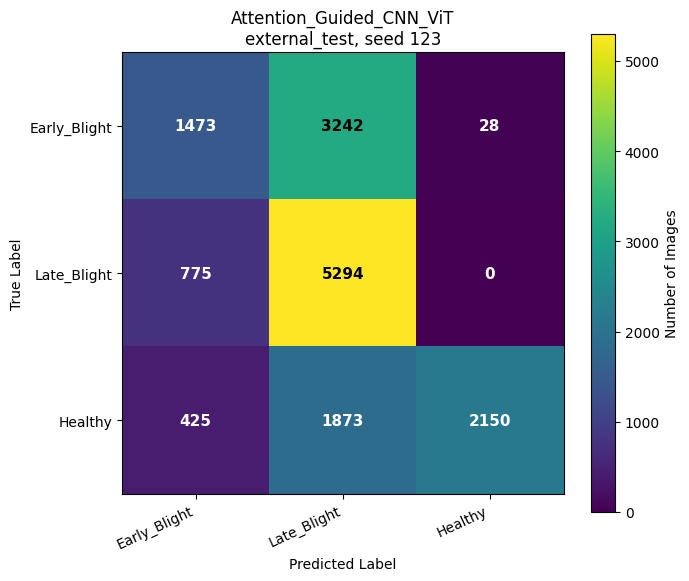

Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/confusion_matrices/Attention_Guided_CNN_ViT_seed123_external_test_confusion_matrix.png


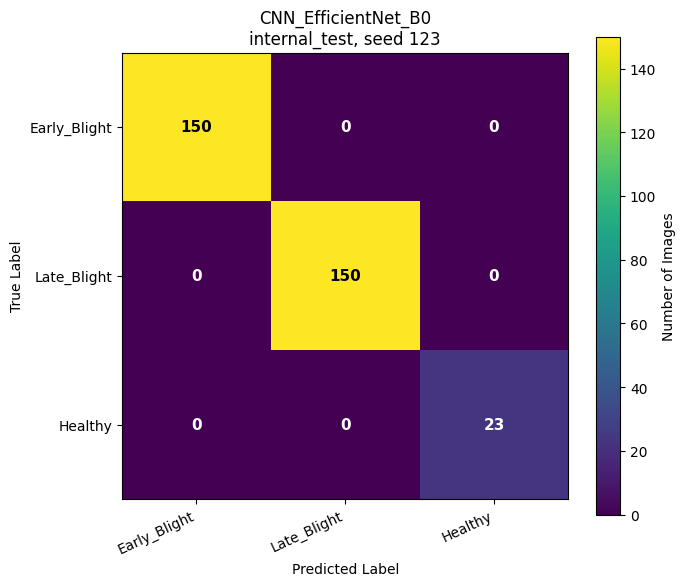

Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/confusion_matrices/CNN_EfficientNet_B0_seed123_internal_test_confusion_matrix.png


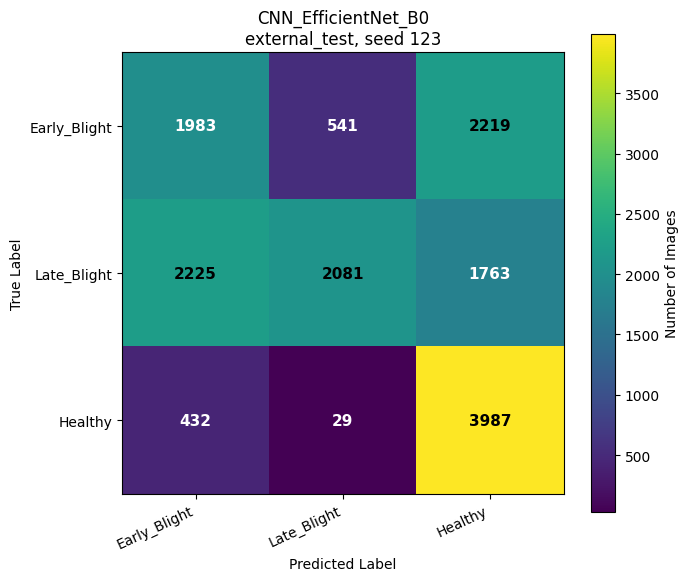

Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/confusion_matrices/CNN_EfficientNet_B0_seed123_external_test_confusion_matrix.png


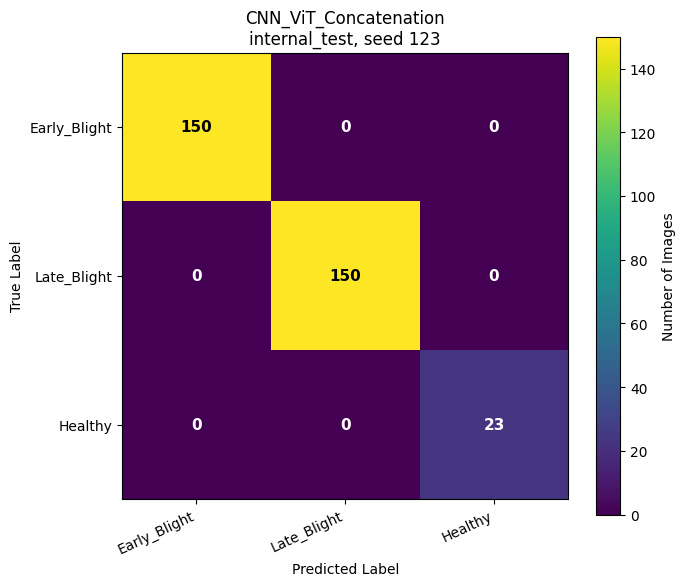

Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/confusion_matrices/CNN_ViT_Concatenation_seed123_internal_test_confusion_matrix.png


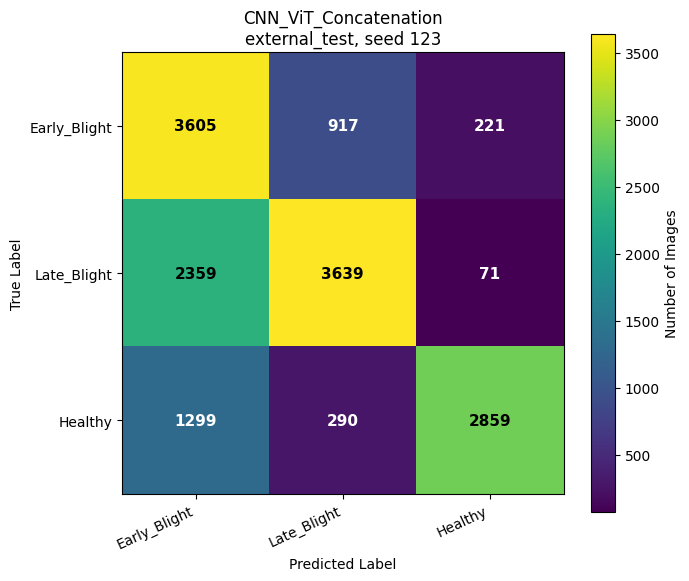

Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/confusion_matrices/CNN_ViT_Concatenation_seed123_external_test_confusion_matrix.png


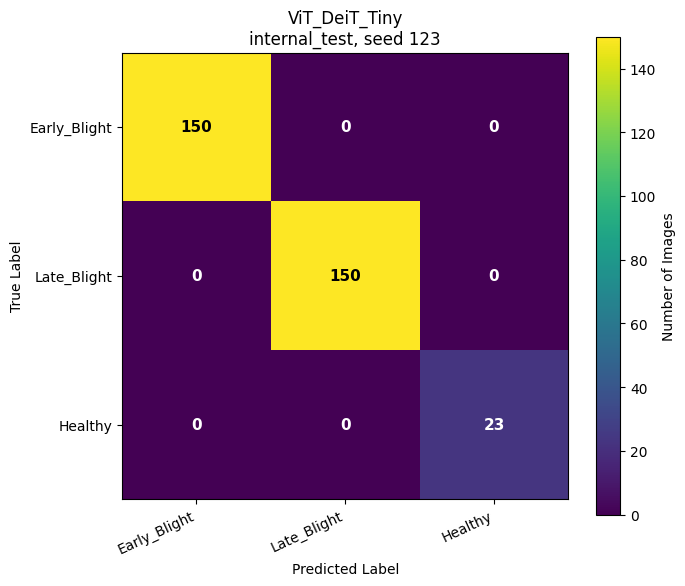

Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/confusion_matrices/ViT_DeiT_Tiny_seed123_internal_test_confusion_matrix.png


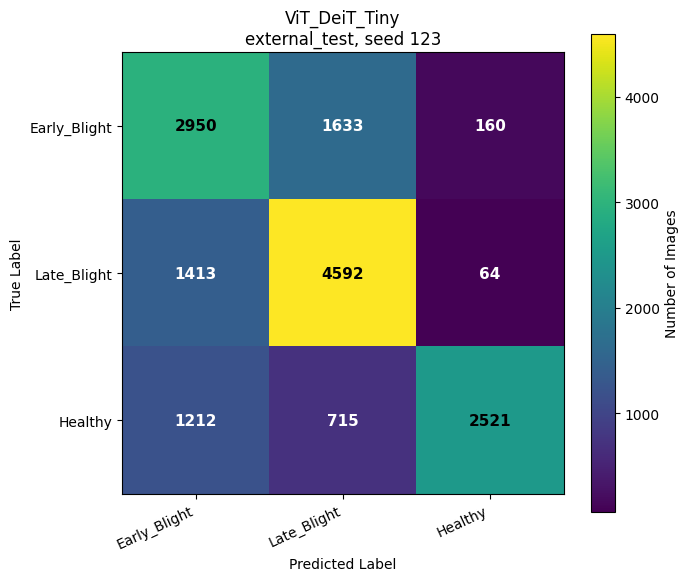

Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/confusion_matrices/ViT_DeiT_Tiny_seed123_external_test_confusion_matrix.png


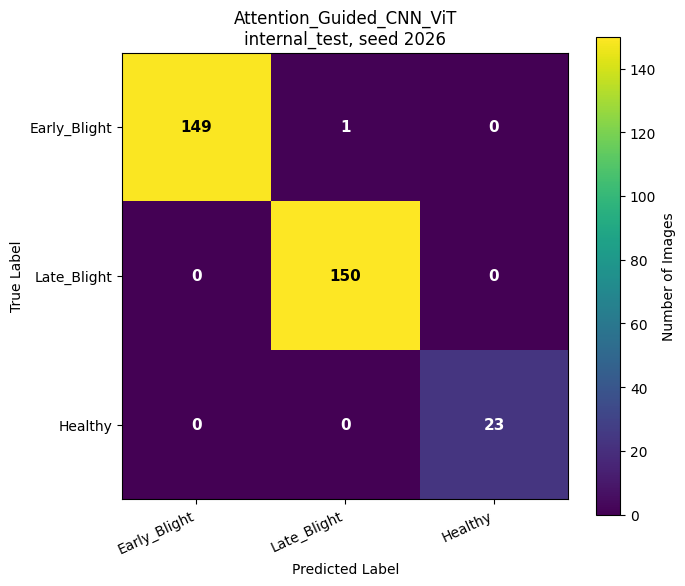

Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/confusion_matrices/Attention_Guided_CNN_ViT_seed2026_internal_test_confusion_matrix.png


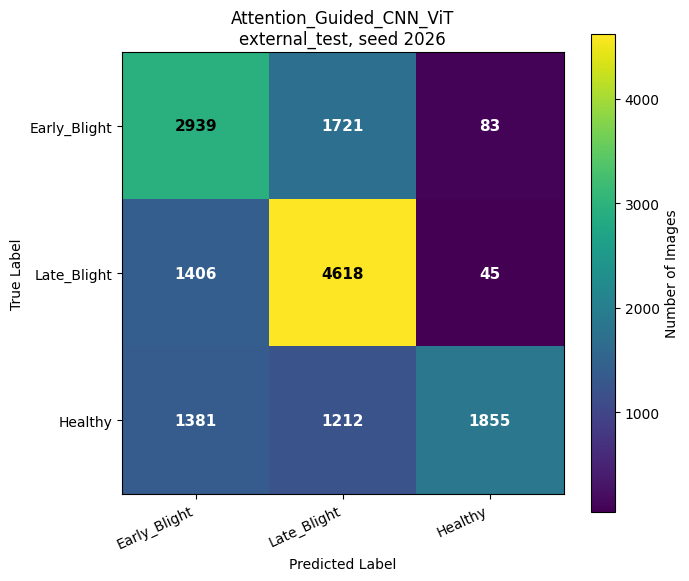

Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/confusion_matrices/Attention_Guided_CNN_ViT_seed2026_external_test_confusion_matrix.png


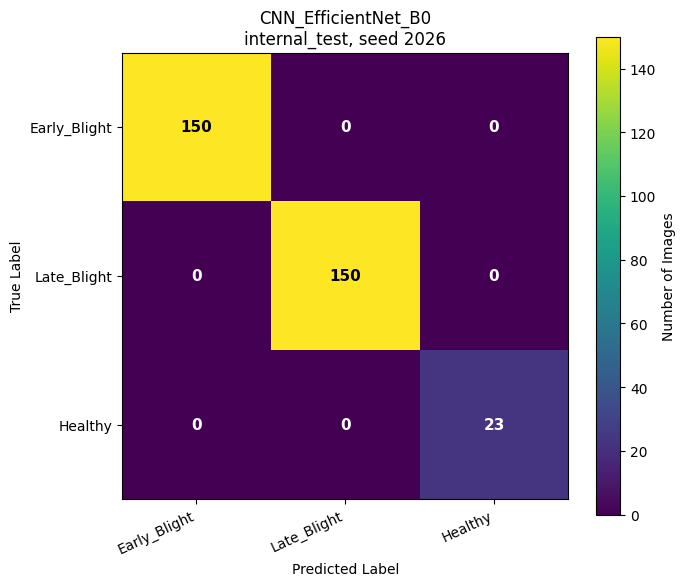

Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/confusion_matrices/CNN_EfficientNet_B0_seed2026_internal_test_confusion_matrix.png


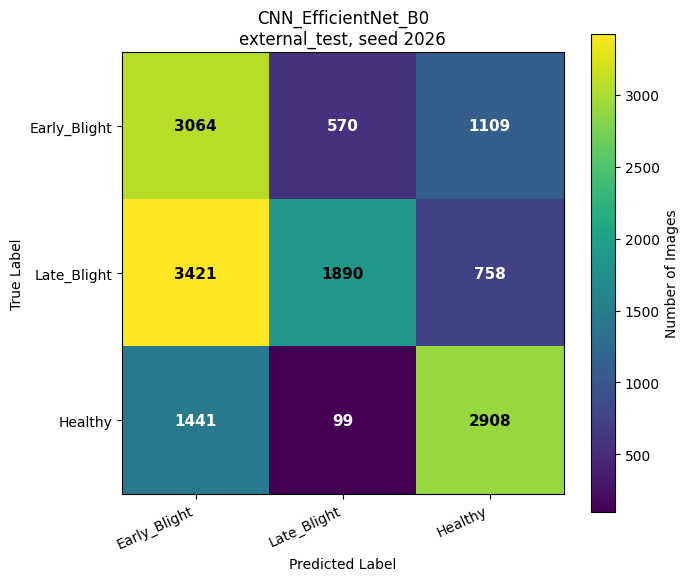

Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/confusion_matrices/CNN_EfficientNet_B0_seed2026_external_test_confusion_matrix.png


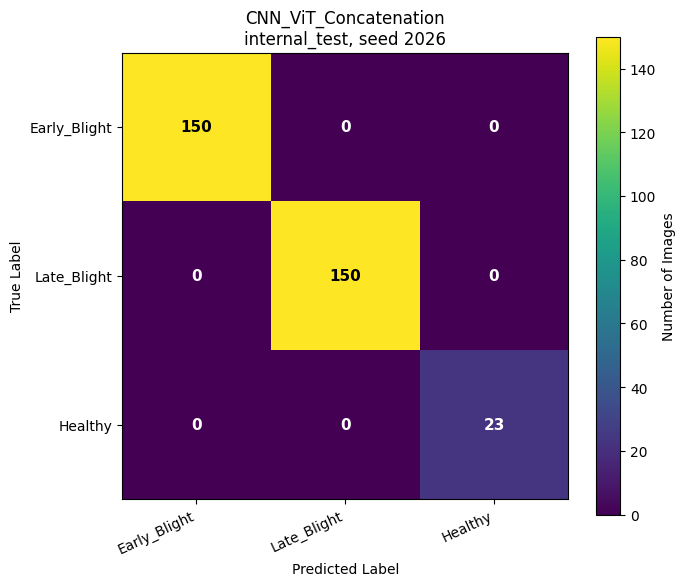

Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/confusion_matrices/CNN_ViT_Concatenation_seed2026_internal_test_confusion_matrix.png


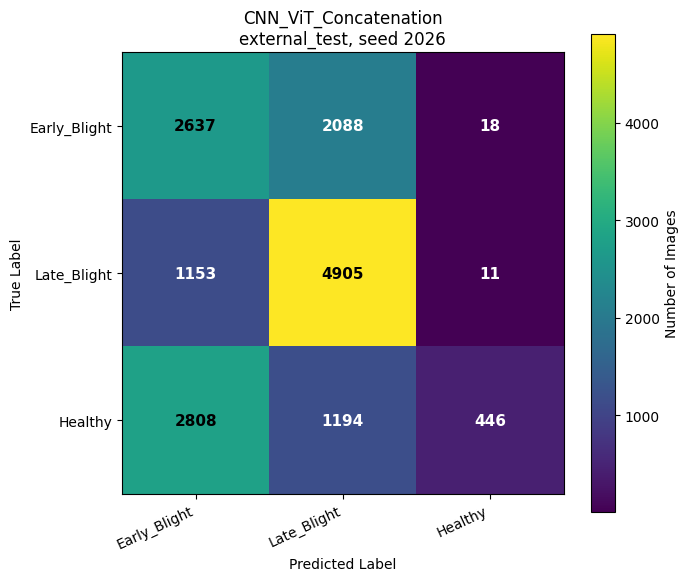

Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/confusion_matrices/CNN_ViT_Concatenation_seed2026_external_test_confusion_matrix.png


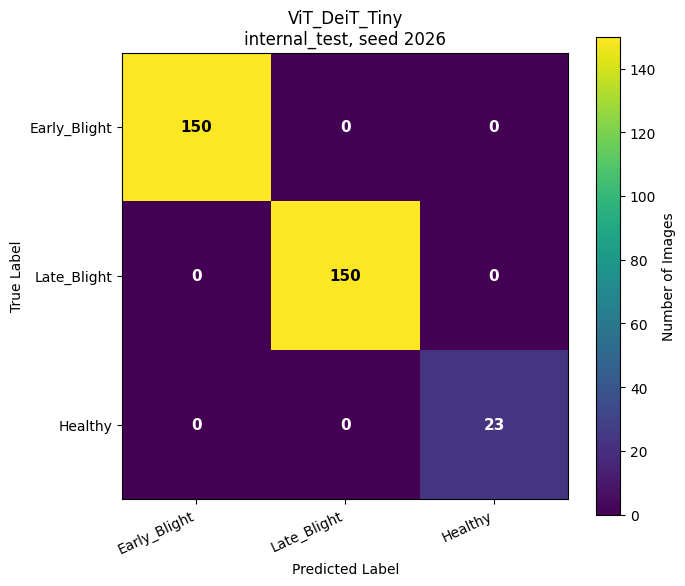

Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/confusion_matrices/ViT_DeiT_Tiny_seed2026_internal_test_confusion_matrix.png


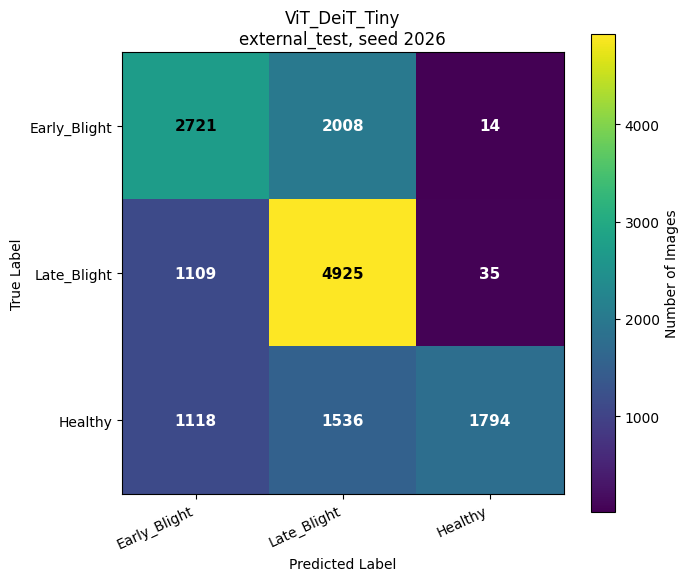

Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/confusion_matrices/ViT_DeiT_Tiny_seed2026_external_test_confusion_matrix.png
Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/metrics/all_available_seed_classification_reports.csv


In [11]:
# Cell 11: Save classification reports and confusion matrices
classification_report_rows = []

for prediction_frame in all_prediction_frames:
    model_name = prediction_frame[
        'model'
    ].iloc[0]

    seed = int(
        prediction_frame[
            'seed'
        ].iloc[0]
    )

    dataset_name = prediction_frame[
        'evaluation_dataset'
    ].iloc[0]

    y_true = (
        prediction_frame[
            'true_class_id'
        ].astype(int).tolist()
    )

    y_pred = (
        prediction_frame[
            'predicted_class_id'
        ].astype(int).tolist()
    )

    report = classification_report(
        y_true,
        y_pred,
        labels=[0, 1, 2],
        target_names=CLASS_NAMES,
        output_dict=True,
        zero_division=0,
    )

    report_df = (
        pd.DataFrame(report)
        .transpose()
        .reset_index()
        .rename(
            columns={
                'index':
                    'class_or_average'
            }
        )
    )

    report_df.insert(
        0,
        'model',
        model_name,
    )

    report_df.insert(
        1,
        'seed',
        seed,
    )

    report_df.insert(
        2,
        'dataset',
        dataset_name,
    )

    classification_report_rows.append(
        report_df
    )

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1, 2],
    )

    fig, axis = plt.subplots(
        figsize=(7, 6)
    )

    image = axis.imshow(
        cm,
        cmap='viridis',
    )

    axis.set_xticks(
        range(len(CLASS_NAMES))
    )

    axis.set_yticks(
        range(len(CLASS_NAMES))
    )

    axis.set_xticklabels(
        CLASS_NAMES,
        rotation=25,
        ha='right',
    )

    axis.set_yticklabels(
        CLASS_NAMES
    )

    axis.set_xlabel(
        'Predicted Label'
    )

    axis.set_ylabel(
        'True Label'
    )

    axis.set_title(
        f'{model_name}\n'
        f'{dataset_name}, seed {seed}'
    )

    threshold = (
        cm.max() / 2
        if cm.size
        else 0
    )

    for row in range(
        cm.shape[0]
    ):
        for column in range(
            cm.shape[1]
        ):
            value = cm[
                row,
                column,
            ]

            text_color = (
                'black'
                if value > threshold
                else 'white'
            )

            axis.text(
                column,
                row,
                str(value),
                ha='center',
                va='center',
                color=text_color,
                fontsize=11,
                fontweight='bold',
            )

    colorbar = fig.colorbar(
        image,
        ax=axis,
    )

    colorbar.set_label(
        'Number of Images'
    )

    plt.tight_layout()

    confusion_path = (
        CONFUSION_DIR
        / (
            f'{model_name}_seed{seed}_'
            f'{dataset_name}_confusion_matrix.png'
        )
    )

    plt.savefig(
        confusion_path,
        dpi=200,
        bbox_inches='tight',
    )

    plt.show()

    print('Saved:', confusion_path)


classification_reports_df = pd.concat(
    classification_report_rows,
    ignore_index=True,
)

classification_reports_path = (
    METRICS_DIR
    / 'all_available_seed_classification_reports.csv'
)

classification_reports_df.to_csv(
    classification_reports_path,
    index=False,
)

print('Saved:', classification_reports_path)


In [12]:
# Cell 12: Bootstrap confidence intervals
def bootstrap_metric_intervals(
    y_true,
    y_pred,
    iterations,
    confidence,
    seed,
):
    rng = np.random.default_rng(
        seed
    )

    y_true = np.asarray(
        y_true,
        dtype=np.int64,
    )

    y_pred = np.asarray(
        y_pred,
        dtype=np.int64,
    )

    sample_count = len(y_true)

    accuracy_values = []
    macro_f1_values = []

    for _ in range(iterations):
        indices = rng.integers(
            0,
            sample_count,
            size=sample_count,
        )

        sampled_true = (
            y_true[indices]
        )

        sampled_pred = (
            y_pred[indices]
        )

        accuracy_values.append(
            accuracy_score(
                sampled_true,
                sampled_pred,
            )
        )

        _, _, macro_f1, _ = (
            precision_recall_fscore_support(
                sampled_true,
                sampled_pred,
                average='macro',
                zero_division=0,
            )
        )

        macro_f1_values.append(
            macro_f1
        )

    alpha = (
        1.0 - confidence
    )

    lower_percentile = (
        100 * alpha / 2
    )

    upper_percentile = (
        100 * (1 - alpha / 2)
    )

    return {
        'accuracy_ci_lower':
            float(
                np.percentile(
                    accuracy_values,
                    lower_percentile,
                )
            ),

        'accuracy_ci_upper':
            float(
                np.percentile(
                    accuracy_values,
                    upper_percentile,
                )
            ),

        'macro_f1_ci_lower':
            float(
                np.percentile(
                    macro_f1_values,
                    lower_percentile,
                )
            ),

        'macro_f1_ci_upper':
            float(
                np.percentile(
                    macro_f1_values,
                    upper_percentile,
                )
            ),
    }


bootstrap_rows = []

for prediction_frame in all_prediction_frames:
    model_name = (
        prediction_frame[
            'model'
        ].iloc[0]
    )

    seed = int(
        prediction_frame[
            'seed'
        ].iloc[0]
    )

    dataset_name = (
        prediction_frame[
            'evaluation_dataset'
        ].iloc[0]
    )

    print(
        'Bootstrapping:',
        model_name,
        seed,
        dataset_name,
    )

    intervals = (
        bootstrap_metric_intervals(
            y_true=prediction_frame[
                'true_class_id'
            ].values,

            y_pred=prediction_frame[
                'predicted_class_id'
            ].values,

            iterations=(
                BOOTSTRAP_ITERATIONS
            ),

            confidence=(
                BOOTSTRAP_CONFIDENCE
            ),

            seed=(
                RANDOM_SEED
                + seed
            ),
        )
    )

    metric_row = (
        all_metrics_df[
            (
                all_metrics_df[
                    'model'
                ] == model_name
            )
            &
            (
                all_metrics_df[
                    'seed'
                ] == seed
            )
            &
            (
                all_metrics_df[
                    'dataset'
                ] == dataset_name
            )
        ]
        .iloc[0]
        .to_dict()
    )

    bootstrap_rows.append({
        **metric_row,
        **intervals,
        'bootstrap_iterations':
            BOOTSTRAP_ITERATIONS,
        'confidence_level':
            BOOTSTRAP_CONFIDENCE,
    })


bootstrap_ci_df = pd.DataFrame(
    bootstrap_rows
)

bootstrap_ci_path = (
    STATISTICS_DIR
    / 'bootstrap_confidence_intervals.csv'
)

bootstrap_ci_df.to_csv(
    bootstrap_ci_path,
    index=False,
)

display(
    bootstrap_ci_df[
        [
            'model',
            'seed',
            'dataset',
            'accuracy',
            'accuracy_ci_lower',
            'accuracy_ci_upper',
            'macro_f1',
            'macro_f1_ci_lower',
            'macro_f1_ci_upper',
        ]
    ]
)

print('Saved:', bootstrap_ci_path)


Bootstrapping: Attention_Guided_CNN_ViT 42 internal_test
Bootstrapping: Attention_Guided_CNN_ViT 42 external_test
Bootstrapping: CNN_EfficientNet_B0 42 internal_test
Bootstrapping: CNN_EfficientNet_B0 42 external_test
Bootstrapping: CNN_ViT_Concatenation 42 internal_test
Bootstrapping: CNN_ViT_Concatenation 42 external_test
Bootstrapping: ViT_DeiT_Tiny 42 internal_test
Bootstrapping: ViT_DeiT_Tiny 42 external_test
Bootstrapping: Attention_Guided_CNN_ViT 123 internal_test
Bootstrapping: Attention_Guided_CNN_ViT 123 external_test
Bootstrapping: CNN_EfficientNet_B0 123 internal_test
Bootstrapping: CNN_EfficientNet_B0 123 external_test
Bootstrapping: CNN_ViT_Concatenation 123 internal_test
Bootstrapping: CNN_ViT_Concatenation 123 external_test
Bootstrapping: ViT_DeiT_Tiny 123 internal_test
Bootstrapping: ViT_DeiT_Tiny 123 external_test
Bootstrapping: Attention_Guided_CNN_ViT 2026 internal_test
Bootstrapping: Attention_Guided_CNN_ViT 2026 external_test
Bootstrapping: CNN_EfficientNet_B0 202

,model,seed,dataset,accuracy,accuracy_ci_lower,accuracy_ci_upper,macro_f1,macro_f1_ci_lower,macro_f1_ci_upper
0,Attention_Guided_CNN_ViT,42,internal_test,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
1,Attention_Guided_CNN_ViT,42,external_test,0.504391,0.496427,0.512430,0.443776,0.436027,0.451958
2,CNN_EfficientNet_B0,42,internal_test,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
3,CNN_EfficientNet_B0,42,external_test,0.456881,0.448321,0.465075,0.428153,0.419891,0.435903
4,CNN_ViT_Concatenation,42,internal_test,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
5,CNN_ViT_Concatenation,42,external_test,0.661730,0.654256,0.669366,0.652865,0.645157,0.660343
6,ViT_DeiT_Tiny,42,internal_test,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
7,ViT_DeiT_Tiny,42,external_test,0.627588,0.619787,0.635424,0.608529,0.600246,0.616946
8,Attention_Guided_CNN_ViT,123,internal_test,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
9,Attention_Guided_CNN_ViT,123,external_test,0.584338,0.576671,0.592926,0.562921,0.554963,0.572156


Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/statistical_analysis/bootstrap_confidence_intervals.csv


In [13]:
# Cell 13: Internal-to-external generalization gap
gap_rows = []

for (
    model_name,
    seed,
), group in all_metrics_df.groupby(
    ['model', 'seed']
):
    dataset_map = (
        group.set_index(
            'dataset'
        )
        .to_dict(
            orient='index'
        )
    )

    if (
        'internal_test'
        not in dataset_map
        or
        'external_test'
        not in dataset_map
    ):
        continue

    internal_metrics = (
        dataset_map[
            'internal_test'
        ]
    )

    external_metrics = (
        dataset_map[
            'external_test'
        ]
    )

    gap_rows.append({
        'model': model_name,
        'seed': seed,

        'internal_accuracy':
            internal_metrics[
                'accuracy'
            ],

        'external_accuracy':
            external_metrics[
                'accuracy'
            ],

        'accuracy_drop':
            internal_metrics[
                'accuracy'
            ]
            -
            external_metrics[
                'accuracy'
            ],

        'internal_macro_f1':
            internal_metrics[
                'macro_f1'
            ],

        'external_macro_f1':
            external_metrics[
                'macro_f1'
            ],

        'macro_f1_drop':
            internal_metrics[
                'macro_f1'
            ]
            -
            external_metrics[
                'macro_f1'
            ],
    })


generalization_gap_df = pd.DataFrame(
    gap_rows
)

generalization_gap_path = (
    METRICS_DIR
    / 'internal_external_generalization_gap.csv'
)

generalization_gap_df.to_csv(
    generalization_gap_path,
    index=False,
)

display(
    generalization_gap_df.sort_values(
        'external_macro_f1',
        ascending=False,
    )
)

print('Saved:', generalization_gap_path)


,model,seed,internal_accuracy,external_accuracy,accuracy_drop,internal_macro_f1,external_macro_f1,macro_f1_drop
7,CNN_ViT_Concatenation,123,1.000000,0.662058,0.337942,1.000000,0.673263,0.326737
10,ViT_DeiT_Tiny,123,1.000000,0.659436,0.340564,1.000000,0.659583,0.340417
6,CNN_ViT_Concatenation,42,1.000000,0.661730,0.338270,1.000000,0.652865,0.347135
9,ViT_DeiT_Tiny,42,1.000000,0.627588,0.372412,1.000000,0.608529,0.391471
2,Attention_Guided_CNN_ViT,2026,0.996904,0.616776,0.380128,0.997778,0.605494,0.392284
11,ViT_DeiT_Tiny,2026,1.000000,0.618611,0.381389,1.000000,0.603142,0.396858
1,Attention_Guided_CNN_ViT,123,1.000000,0.584338,0.415662,1.000000,0.562921,0.437079
5,CNN_EfficientNet_B0,2026,1.000000,0.515203,0.484797,1.000000,0.517469,0.482531
4,CNN_EfficientNet_B0,123,1.000000,0.527588,0.472412,1.000000,0.514052,0.485948
8,CNN_ViT_Concatenation,2026,1.000000,0.523460,0.476540,1.000000,0.444787,0.555213


Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/metrics/internal_external_generalization_gap.csv


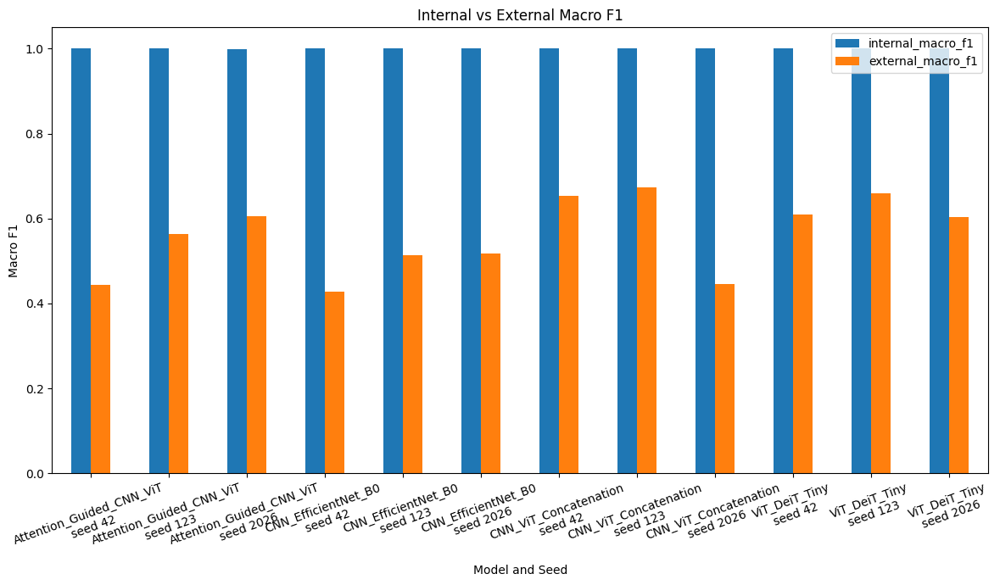

Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/figures/internal_vs_external_macro_f1.png


In [14]:
# Cell 14: Plot internal versus external Macro F1
if not generalization_gap_df.empty:
    plot_df = (
        generalization_gap_df[
            [
                'model',
                'seed',
                'internal_macro_f1',
                'external_macro_f1',
            ]
        ]
        .copy()
    )

    plot_df[
        'model_seed'
    ] = (
        plot_df['model']
        + '\nseed '
        + plot_df['seed'].astype(str)
    )

    plot_df = (
        plot_df.set_index(
            'model_seed'
        )[
            [
                'internal_macro_f1',
                'external_macro_f1',
            ]
        ]
    )

    axis = plot_df.plot(
        kind='bar',
        figsize=(12, 7),
    )

    axis.set_title(
        'Internal vs External Macro F1'
    )

    axis.set_xlabel(
        'Model and Seed'
    )

    axis.set_ylabel(
        'Macro F1'
    )

    axis.set_ylim(
        0,
        1.05,
    )

    axis.tick_params(
        axis='x',
        rotation=20,
    )

    plt.tight_layout()

    comparison_figure_path = (
        FIGURES_DIR
        / 'internal_vs_external_macro_f1.png'
    )

    plt.savefig(
        comparison_figure_path,
        dpi=200,
        bbox_inches='tight',
    )

    plt.show()

    print(
        'Saved:',
        comparison_figure_path,
    )


In [15]:
# Cell 15: Proposed model external attention analysis
if attention_prediction_frames:
    attention_all_df = pd.concat(
        attention_prediction_frames,
        ignore_index=True,
    )

    external_attention_df = (
        attention_all_df[
            attention_all_df[
                'evaluation_dataset'
            ] == 'external_test'
        ].copy()
    )

    attention_summary_df = (
        external_attention_df.groupby(
            [
                'seed',
                'true_class_name',
            ]
        )
        .agg(
            image_count=(
                'true_class_name',
                'size',
            ),

            mean_cnn_attention=(
                'cnn_attention_weight',
                'mean',
            ),

            std_cnn_attention=(
                'cnn_attention_weight',
                'std',
            ),

            mean_vit_attention=(
                'vit_attention_weight',
                'mean',
            ),

            std_vit_attention=(
                'vit_attention_weight',
                'std',
            ),
        )
        .reset_index()
    )

    attention_summary_path = (
        ATTENTION_DIR
        / 'external_attention_summary_all_available_seeds.csv'
    )

    attention_summary_df.to_csv(
        attention_summary_path,
        index=False,
    )

    display(
        attention_summary_df.round(4)
    )

    print(
        'Saved:',
        attention_summary_path,
    )
else:
    print(
        'No attention-model predictions found.'
    )


,seed,true_class_name,image_count,mean_cnn_attention,std_cnn_attention,mean_vit_attention,std_vit_attention
0,42,Early_Blight,4743,0.1889,0.0353,0.8111,0.0353
1,42,Healthy,4448,0.2177,0.0476,0.7823,0.0476
2,42,Late_Blight,6069,0.2064,0.0315,0.7936,0.0315
3,123,Early_Blight,4743,0.2448,0.0305,0.7552,0.0305
4,123,Healthy,4448,0.2870,0.0522,0.7130,0.0522
5,123,Late_Blight,6069,0.2260,0.0245,0.7740,0.0245
6,2026,Early_Blight,4743,0.2667,0.0387,0.7333,0.0387
7,2026,Healthy,4448,0.2691,0.0388,0.7309,0.0388
8,2026,Late_Blight,6069,0.2347,0.0329,0.7653,0.0329


Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/attention_weights/external_attention_summary_all_available_seeds.csv


In [16]:
# Cell 16: Multi-seed aggregation
seed_count_by_model = (
    all_metrics_df.groupby(
        'model'
    )['seed']
    .nunique()
    .reset_index(
        name='available_seed_count'
    )
)

display(
    seed_count_by_model
)

multi_seed_complete = bool(
    (
        seed_count_by_model[
            'available_seed_count'
        ]
        >= len(TARGET_SEEDS)
    ).all()
)

if multi_seed_complete:
    multiseed_summary_df = (
        all_metrics_df.groupby(
            [
                'model',
                'dataset',
            ]
        )
        .agg(
            seed_count=(
                'seed',
                'nunique',
            ),

            accuracy_mean=(
                'accuracy',
                'mean',
            ),

            accuracy_std=(
                'accuracy',
                'std',
            ),

            macro_precision_mean=(
                'macro_precision',
                'mean',
            ),

            macro_precision_std=(
                'macro_precision',
                'std',
            ),

            macro_recall_mean=(
                'macro_recall',
                'mean',
            ),

            macro_recall_std=(
                'macro_recall',
                'std',
            ),

            macro_f1_mean=(
                'macro_f1',
                'mean',
            ),

            macro_f1_std=(
                'macro_f1',
                'std',
            ),
        )
        .reset_index()
    )

    multiseed_summary_path = (
        METRICS_DIR
        / 'multiseed_mean_std_summary.csv'
    )

    multiseed_summary_df.to_csv(
        multiseed_summary_path,
        index=False,
    )

    display(
        multiseed_summary_df.round(4)
    )

    print(
        '✅ Multi-seed summary complete.'
    )

    print(
        'Saved:',
        multiseed_summary_path,
    )

else:
    multiseed_summary_df = pd.DataFrame()

    missing_checkpoint_path = (
        METADATA_DIR
        / 'missing_multiseed_checkpoints.csv'
    )

    missing_checkpoint_df.to_csv(
        missing_checkpoint_path,
        index=False,
    )

    print(
        '⚠️ External evaluation complete, '
        'but multi-seed experiment is incomplete.'
    )

    print(
        'Missing checkpoints:',
        len(missing_checkpoint_df),
    )

    display(
        missing_checkpoint_df
    )

    print(
        'Saved:',
        missing_checkpoint_path,
    )


,model,available_seed_count
0,Attention_Guided_CNN_ViT,3
1,CNN_EfficientNet_B0,3
2,CNN_ViT_Concatenation,3
3,ViT_DeiT_Tiny,3


,model,dataset,seed_count,accuracy_mean,accuracy_std,macro_precision_mean,macro_precision_std,macro_recall_mean,macro_recall_std,macro_f1_mean,macro_f1_std
0,Attention_Guided_CNN_ViT,external_test,3,0.5685,0.0578,0.6677,0.0293,0.5430,0.0634,0.5374,0.0838
1,Attention_Guided_CNN_ViT,internal_test,3,0.9990,0.0018,0.9993,0.0013,0.9993,0.0013,0.9993,0.0013
2,CNN_EfficientNet_B0,external_test,3,0.4999,0.0378,0.5626,0.0209,0.5275,0.0309,0.4866,0.0506
3,CNN_EfficientNet_B0,internal_test,3,1.0000,0.0000,1.0000,0.0000,1.0000,0.0000,1.0000,0.0000
4,CNN_ViT_Concatenation,external_test,3,0.6157,0.0799,0.6884,0.0378,0.5996,0.0973,0.5903,0.1264
5,CNN_ViT_Concatenation,internal_test,3,1.0000,0.0000,1.0000,0.0000,1.0000,0.0000,1.0000,0.0000
6,ViT_DeiT_Tiny,external_test,3,0.6352,0.0215,0.7006,0.0032,0.6155,0.0287,0.6238,0.0311
7,ViT_DeiT_Tiny,internal_test,3,1.0000,0.0000,1.0000,0.0000,1.0000,0.0000,1.0000,0.0000


✅ Multi-seed summary complete.
Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/metrics/multiseed_mean_std_summary.csv


In [17]:
# Cell 17: Final evaluation report
expected_seed42_models = set(
    MODEL_CHECKPOINT_PATTERNS.keys()
)

seed42_available_models = set(
    available_checkpoint_df.loc[
        available_checkpoint_df[
            'seed'
        ] == 42,
        'model',
    ]
)

external_evaluated_models = set(
    all_metrics_df.loc[
        all_metrics_df[
            'dataset'
        ] == 'external_test',
        'model',
    ]
)

final_report_df = pd.DataFrame([
    {
        'check':
            'All four seed-42 checkpoints found',

        'passed': (
            seed42_available_models
            == expected_seed42_models
        ),
    },

    {
        'check':
            'All four models evaluated internally',

        'passed': (
            set(
                all_metrics_df.loc[
                    all_metrics_df[
                        'dataset'
                    ] == 'internal_test',
                    'model',
                ]
            )
            == expected_seed42_models
        ),
    },

    {
        'check':
            'All four models evaluated externally',

        'passed': (
            external_evaluated_models
            == expected_seed42_models
        ),
    },

    {
        'check':
            'Bootstrap confidence intervals saved',

        'passed':
            bootstrap_ci_path.exists(),
    },

    {
        'check':
            'Generalization-gap table saved',

        'passed':
            generalization_gap_path.exists(),
    },

    {
        'check':
            'External data not used for tuning',

        'passed':
            True,
    },

    {
        'check':
            'Three-seed experiment complete',

        'passed':
            multi_seed_complete,
    },
])

display(
    final_report_df
)

core_external_complete = bool(
    final_report_df.iloc[
        0:6
    ]['passed'].all()
)

if (
    core_external_complete
    and multi_seed_complete
):
    print(
        '✅ Multi-seed and external evaluation '
        'completed successfully.'
    )

    print(
        'Next step: '
        '11_Statistical_Comparison_and_GradCAM.ipynb'
    )

elif core_external_complete:
    print(
        '✅ Four-model external evaluation completed.'
    )

    print(
        '⚠️ Multi-seed experiment is not complete '
        'because seed 123 and 2026 checkpoints are missing.'
    )

    print(
        'Next step: '
        '11_Additional_Seed_Training.ipynb'
    )

else:
    print(
        '⚠️ External evaluation completed with warnings.'
    )


,check,passed
0,All four seed-42 checkpoints found,True
1,All four models evaluated internally,True
2,All four models evaluated externally,True
3,Bootstrap confidence intervals saved,True
4,Generalization-gap table saved,True
5,External data not used for tuning,True
6,Three-seed experiment complete,True


✅ Multi-seed and external evaluation completed successfully.
Next step: 11_Statistical_Comparison_and_GradCAM.ipynb


---

# Part 11 — 11. Additional Seed Training

**Purpose:** Train missing model runs for seeds 123 and 2026 so that the study includes three-seed experiments for all four architectures.

**Source notebook:** `11_Additional_Seed_Training.ipynb`

**Preservation note:** The original code cells and their saved execution outputs are retained below. Textual headings/comments are lightly normalized into English where possible without changing experiment logic.



# 11 — Additional Seed Training

This notebook চারটি model-এর বাকি seed train করবে।

- Target seeds: `123`, `2026`
- Seed `42` আগেই train করা হয়েছে
- মোট নতুন run: `4 models × 2 seeds = 8`

Defaultভাবে প্রতি `Run all`-এ একটি missing model/seed train হবে। একটি run শেষ হলে notebook আবার `Runtime → Run all` দিলে পরের missing run automaticভাবে শুরু হবে।

```python
MAX_NEW_RUNS_PER_SESSION = 1
```

Colab runtime ভালো থাকলে এটিকে `2` করা যাবে।

External PLDD-UP dataset এখানে will not be used। একই train/validation/internal-test split থাকবে; শুধু seed অনুযায়ী initialization, augmentation randomness ও shuffle order বদলাবে।


In [55]:

# Cell 1: Mount Drive and install timm
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

!pip -q install timm


Mounted at /content/drive


In [56]:

# Cell 2: Imports and settings
from pathlib import Path
from datetime import datetime
import gc, json, os, random, shutil, time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
import timm

from sklearn.metrics import accuracy_score, precision_recall_fscore_support

TARGET_SEEDS = [123, 2026]
MODEL_ORDER = [
    'CNN_EfficientNet_B0',
    'ViT_DeiT_Tiny',
    'CNN_ViT_Concatenation',
    'Attention_Guided_CNN_ViT',
]
MAX_NEW_RUNS_PER_SESSION = 1

CLASS_NAMES = ['Early_Blight', 'Late_Blight', 'Healthy']
CLASS_ID_MAP = {'Early_Blight':0, 'Late_Blight':1, 'Healthy':2}

IMAGE_SIZE = 224
RESIZE_SIZE = 256
NUM_WORKERS = 2
MAX_EPOCHS = 25
EARLY_STOPPING_PATIENCE = 6
WEIGHT_DECAY = 1e-4

MODEL_CONFIGS = {
    'CNN_EfficientNet_B0': {
        'batch_size':16, 'learning_rate':1e-4, 'dropout':0.30
    },
    'ViT_DeiT_Tiny': {
        'batch_size':16, 'learning_rate':5e-5, 'dropout':0.30
    },
    'CNN_ViT_Concatenation': {
        'batch_size':8, 'learning_rate':3e-5, 'dropout':0.35,
        'fusion_hidden_dim':512
    },
    'Attention_Guided_CNN_ViT': {
        'batch_size':8, 'learning_rate':3e-5, 'dropout':0.35,
        'projection_dim':256, 'classifier_hidden_dim':256
    },
}

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
AMP_ENABLED = torch.cuda.is_available()

print('PyTorch:', torch.__version__)
print('timm:', timm.__version__)
print('Device:', DEVICE)

if not torch.cuda.is_available():
    raise RuntimeError('Runtime → Change runtime type → T4 GPU নির্বাচন করো।')
print('GPU:', torch.cuda.get_device_name(0))


PyTorch: 2.11.0+cu128
timm: 1.0.28
Device: cuda
GPU: Tesla T4


In [57]:

# Cell 3: Locate project and load data
MY_DRIVE = Path('/content/drive/MyDrive')
standard = MY_DRIVE / 'Potato_CNN_ViT_Research'

if standard.is_dir():
    PROJECT_ROOT = standard
else:
    matches = [p for p in MY_DRIVE.rglob('Potato_CNN_ViT_Research') if p.is_dir()]
    if not matches:
        raise FileNotFoundError('Potato_CNN_ViT_Research folder পাওয়া যায়নি।')
    PROJECT_ROOT = matches[0]

DATA_DIR = PROJECT_ROOT / '02_data'
SPLITS_DIR = DATA_DIR / 'splits'
METADATA_DIR = DATA_DIR / 'metadata'
CHECKPOINT_ROOT = PROJECT_ROOT / '04_checkpoints'
METRICS_DIR = PROJECT_ROOT / '05_results' / 'metrics'
FIGURES_DIR = PROJECT_ROOT / '05_results' / 'training_curves'
PREDICTIONS_DIR = PROJECT_ROOT / '05_results' / 'predictions'
RUN_STATUS_DIR = PROJECT_ROOT / '05_results' / 'multiseed_runs'

for folder in [CHECKPOINT_ROOT, METRICS_DIR, FIGURES_DIR, PREDICTIONS_DIR, RUN_STATUS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

train_df = pd.read_csv(SPLITS_DIR / 'train.csv')
val_df = pd.read_csv(SPLITS_DIR / 'val.csv')
internal_test_df = pd.read_csv(SPLITS_DIR / 'internal_test.csv')
class_weights_df = pd.read_csv(METADATA_DIR / 'training_class_weights.csv').sort_values('class_id')

for name, frame in [('train',train_df), ('val',val_df), ('internal',internal_test_df)]:
    frame['file_path'] = frame['file_path'].astype(str)
    frame['class_id'] = frame['class_id'].astype(int)
    frame['unified_class'] = frame['unified_class'].astype(str)
    missing = int((~frame['file_path'].map(lambda x: Path(x).exists())).sum())
    if missing:
        raise FileNotFoundError(f'{name} split-এ {missing}টি path missing।')

class_weights_tensor = torch.tensor(
    class_weights_df['class_weight'].values,
    dtype=torch.float32,
    device=DEVICE,
)

print('PROJECT_ROOT:', PROJECT_ROOT)
print('Train/Val/Internal:', len(train_df), len(val_df), len(internal_test_df))


PROJECT_ROOT: /content/drive/MyDrive/Potato_CNN_ViT_Research
Train/Val/Internal: 1506 323 323


In [58]:

# Cell 4: Local copy, transforms, Dataset, and loader factory
LOCAL_ROOT = Path('/content/plantvillage_local')
sample_path = Path(train_df.iloc[0]['file_path'])
source_root = sample_path.parent.parent

if not LOCAL_ROOT.exists():
    print('PlantVillage /content-এ copy হচ্ছে...')
    shutil.copytree(source_root, LOCAL_ROOT, dirs_exist_ok=True)
    print('Local copy completed.')
else:
    print('Existing local copy ব্যবহার করা হচ্ছে।')

def local_path(value):
    p = Path(value)
    return str(LOCAL_ROOT / p.parent.name / p.name)

for frame in [train_df, val_df, internal_test_df]:
    if 'original_drive_path' not in frame.columns:
        frame['original_drive_path'] = frame['file_path']
    frame['file_path'] = frame['original_drive_path'].map(local_path)
    missing = int((~frame['file_path'].map(lambda x: Path(x).exists())).sum())
    if missing:
        raise FileNotFoundError(f'Local copy-তে {missing}টি image missing।')

train_transform = transforms.Compose([
    transforms.Resize((RESIZE_SIZE, RESIZE_SIZE)),
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.80,1.00), ratio=(0.90,1.10)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10, hue=0.02),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    transforms.RandomErasing(p=0.10, scale=(0.02,0.08), ratio=(0.5,2.0), value='random'),
])

eval_transform = transforms.Compose([
    transforms.Resize((RESIZE_SIZE, RESIZE_SIZE)),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class PotatoLeafDataset(Dataset):
    def __init__(self, dataframe, transform):
        self.df = dataframe.reset_index(drop=True).copy()
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, index):
        row = self.df.iloc[index]
        with Image.open(row['file_path']) as img:
            img = img.convert('RGB')
        return {
            'image': self.transform(img),
            'label': torch.tensor(int(row['class_id']), dtype=torch.long),
        }

train_dataset = PotatoLeafDataset(train_df, train_transform)
val_dataset = PotatoLeafDataset(val_df, eval_transform)
internal_dataset = PotatoLeafDataset(internal_test_df, eval_transform)

def create_loaders(batch_size, seed):
    generator = torch.Generator().manual_seed(seed)
    common = dict(
        num_workers=NUM_WORKERS,
        pin_memory=True,
        persistent_workers=(NUM_WORKERS > 0),
    )
    return (
        DataLoader(train_dataset, batch_size=batch_size, shuffle=True, generator=generator, **common),
        DataLoader(val_dataset, batch_size=batch_size, shuffle=False, **common),
        DataLoader(internal_dataset, batch_size=batch_size, shuffle=False, **common),
    )


Existing local copy ব্যবহার করা হচ্ছে।


In [59]:

# Cell 5: Model architectures and builders
class CNNViTConcatenationModel(nn.Module):
    def __init__(self, num_classes, hidden_dim=512, dropout=0.35):
        super().__init__()
        cnn = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
        self.cnn_features = cnn.features
        self.cnn_pool = nn.AdaptiveAvgPool2d(1)
        self.cnn_feature_dim = cnn.classifier[1].in_features

        self.vit_backbone = None
        self.vit_model_name = None
        last_error = None
        for name in ['deit_tiny_patch16_224.fb_in1k', 'deit_tiny_patch16_224']:
            try:
                self.vit_backbone = timm.create_model(
                    name, pretrained=True, num_classes=0, global_pool='avg'
                )
                self.vit_model_name = name
                break
            except Exception as exc:
                last_error = exc
        if self.vit_backbone is None:
            raise RuntimeError(f'ViT load failed: {last_error}')

        self.vit_feature_dim = self.vit_backbone.num_features
        fused_dim = self.cnn_feature_dim + self.vit_feature_dim
        self.classifier = nn.Sequential(
            nn.LayerNorm(fused_dim), nn.Dropout(dropout),
            nn.Linear(fused_dim, hidden_dim), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, x):
        cnn_f = self.cnn_pool(self.cnn_features(x)).flatten(1)
        vit_f = self.vit_backbone(x)
        return self.classifier(torch.cat([cnn_f, vit_f], dim=1))


class AttentionGuidedCNNViT(nn.Module):
    def __init__(self, num_classes, projection_dim=256, classifier_hidden_dim=256, dropout=0.35):
        super().__init__()
        cnn = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
        self.cnn_features = cnn.features
        self.cnn_pool = nn.AdaptiveAvgPool2d(1)
        self.cnn_feature_dim = cnn.classifier[1].in_features

        self.vit_backbone = None
        self.vit_model_name = None
        last_error = None
        for name in ['deit_tiny_patch16_224.fb_in1k', 'deit_tiny_patch16_224']:
            try:
                self.vit_backbone = timm.create_model(
                    name, pretrained=True, num_classes=0, global_pool='avg'
                )
                self.vit_model_name = name
                break
            except Exception as exc:
                last_error = exc
        if self.vit_backbone is None:
            raise RuntimeError(f'ViT load failed: {last_error}')

        self.vit_feature_dim = self.vit_backbone.num_features

        self.cnn_projection = nn.Sequential(
            nn.Linear(self.cnn_feature_dim, projection_dim),
            nn.LayerNorm(projection_dim), nn.GELU(), nn.Dropout(dropout),
        )
        self.vit_projection = nn.Sequential(
            nn.Linear(self.vit_feature_dim, projection_dim),
            nn.LayerNorm(projection_dim), nn.GELU(), nn.Dropout(dropout),
        )
        self.attention_gate = nn.Sequential(
            nn.Linear(projection_dim*2, projection_dim),
            nn.GELU(), nn.Dropout(dropout), nn.Linear(projection_dim, 2),
        )
        self.classifier = nn.Sequential(
            nn.LayerNorm(projection_dim), nn.Dropout(dropout),
            nn.Linear(projection_dim, classifier_hidden_dim),
            nn.GELU(), nn.Dropout(dropout),
            nn.Linear(classifier_hidden_dim, num_classes),
        )

    def forward(self, x):
        cnn_raw = self.cnn_pool(self.cnn_features(x)).flatten(1)
        vit_raw = self.vit_backbone(x)
        cnn_f = self.cnn_projection(cnn_raw)
        vit_f = self.vit_projection(vit_raw)
        weights = torch.softmax(self.attention_gate(torch.cat([cnn_f, vit_f], dim=1)), dim=1)
        fused = weights[:,0:1]*cnn_f + weights[:,1:2]*vit_f
        return self.classifier(fused)


def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.cuda.manual_seed_all(seed)


def build_model(model_key, seed):
    seed_everything(seed)
    cfg = MODEL_CONFIGS[model_key]

    if model_key == 'CNN_EfficientNet_B0':
        model = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
        in_features = model.classifier[1].in_features
        model.classifier = nn.Sequential(
            nn.Dropout(cfg['dropout']),
            nn.Linear(in_features, len(CLASS_NAMES)),
        )
        meta = {'model_name':'efficientnet_b0', 'cnn_branch':'EfficientNet-B0'}

    elif model_key == 'ViT_DeiT_Tiny':
        model = None
        selected = None
        last_error = None
        for name in ['deit_tiny_patch16_224.fb_in1k', 'deit_tiny_patch16_224']:
            try:
                model = timm.create_model(
                    name, pretrained=True, num_classes=len(CLASS_NAMES),
                    drop_rate=cfg['dropout']
                )
                selected = name
                break
            except Exception as exc:
                last_error = exc
        if model is None:
            raise RuntimeError(f'DeiT load failed: {last_error}')
        meta = {'model_name':selected, 'vit_branch':selected}

    elif model_key == 'CNN_ViT_Concatenation':
        model = CNNViTConcatenationModel(
            len(CLASS_NAMES), cfg['fusion_hidden_dim'], cfg['dropout']
        )
        meta = {
            'model_name':'CNN_ViT_Simple_Concatenation',
            'cnn_branch':'EfficientNet-B0',
            'vit_branch':model.vit_model_name,
            'fusion':'Direct feature concatenation',
        }

    elif model_key == 'Attention_Guided_CNN_ViT':
        model = AttentionGuidedCNNViT(
            len(CLASS_NAMES), cfg['projection_dim'],
            cfg['classifier_hidden_dim'], cfg['dropout']
        )
        meta = {
            'model_name':'Attention_Guided_CNN_ViT',
            'cnn_branch':'EfficientNet-B0',
            'vit_branch':model.vit_model_name,
            'fusion':'Learnable sample-wise branch attention',
        }
    else:
        raise ValueError(model_key)

    return model.to(DEVICE), meta


In [60]:

# Cell 6: Output paths, metrics, and epoch runner
OUTPUT_SPECS = {
    'CNN_EfficientNet_B0': (
        'cnn', 'efficientnet_b0', 'cnn_efficientnet_b0'
    ),
    'ViT_DeiT_Tiny': (
        'vit', 'deit_tiny', 'vit_deit_tiny'
    ),
    'CNN_ViT_Concatenation': (
        'concat', 'cnn_vit_concat', 'cnn_vit_concat'
    ),
    'Attention_Guided_CNN_ViT': (
        'attention', 'attention_cnn_vit', 'attention_cnn_vit'
    ),
}

def output_paths(model_key, seed):
    folder, checkpoint_prefix, result_prefix = OUTPUT_SPECS[model_key]
    checkpoint_dir = CHECKPOINT_ROOT / folder
    checkpoint_dir.mkdir(parents=True, exist_ok=True)
    return {
        'best': checkpoint_dir / f'{checkpoint_prefix}_best_seed{seed}.pth',
        'last': checkpoint_dir / f'{checkpoint_prefix}_last_seed{seed}.pth',
        'history': METRICS_DIR / f'{result_prefix}_training_history_seed{seed}.csv',
        'summary': METRICS_DIR / f'{result_prefix}_summary_seed{seed}.csv',
        'internal_metrics': METRICS_DIR / f'{result_prefix}_internal_test_metrics_seed{seed}.csv',
        'predictions': PREDICTIONS_DIR / f'{result_prefix}_internal_test_predictions_seed{seed}.csv',
        'loss_curve': FIGURES_DIR / f'{result_prefix}_loss_curve_seed{seed}.png',
        'f1_curve': FIGURES_DIR / f'{result_prefix}_macro_f1_curve_seed{seed}.png',
    }

def safe_load(path):
    try:
        return torch.load(path, map_location=DEVICE, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=DEVICE)

def metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='macro', zero_division=0
    )
    return {
        'accuracy':float(acc),
        'macro_precision':float(p),
        'macro_recall':float(r),
        'macro_f1':float(f1),
    }

def run_epoch(model, loader, criterion, scaler, optimizer=None):
    training = optimizer is not None
    model.train() if training else model.eval()
    running_loss = 0.0
    labels_all, preds_all = [], []

    for batch in loader:
        images = batch['image'].to(DEVICE, non_blocking=True)
        labels = batch['label'].to(DEVICE, non_blocking=True)

        if training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(training):
            with torch.amp.autocast(device_type='cuda', enabled=AMP_ENABLED):
                logits = model(images)
                loss = criterion(logits, labels)

            if training:
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()

        running_loss += loss.item() * images.size(0)
        labels_all.extend(labels.detach().cpu().tolist())
        preds_all.extend(logits.argmax(1).detach().cpu().tolist())

    out = metrics(labels_all, preds_all)
    out['loss'] = running_loss / len(loader.dataset)
    return out, labels_all, preds_all


In [61]:

# Cell 7: Train/resume one run
def train_one_run(model_key, seed):
    print('\n' + '='*80)
    print('Model:', model_key, '| Seed:', seed)

    cfg = MODEL_CONFIGS[model_key]
    paths = output_paths(model_key, seed)

    if paths['best'].exists() and paths['summary'].exists():
        print('✅ Already complete; skipped.')
        return {'model':model_key, 'seed':seed, 'status':'already_complete'}

    train_loader, val_loader, internal_loader = create_loaders(
        cfg['batch_size'], seed
    )

    model, meta = build_model(model_key, seed)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=cfg['learning_rate'],
        weight_decay=WEIGHT_DECAY,
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=MAX_EPOCHS
    )
    scaler = torch.amp.GradScaler('cuda', enabled=AMP_ENABLED)

    start_epoch = 1
    best_epoch = 0
    best_f1 = -1.0
    no_improve = 0
    history = []

    if paths['history'].exists():
        history = pd.read_csv(paths['history']).to_dict('records')

    if paths['last'].exists():
        print('Previous last checkpoint পাওয়া গেছে; resume হচ্ছে...')
        ckpt = safe_load(paths['last'])
        model.load_state_dict(ckpt['model_state_dict'])
        optimizer.load_state_dict(ckpt['optimizer_state_dict'])
        scheduler.load_state_dict(ckpt['scheduler_state_dict'])
        start_epoch = int(ckpt['epoch']) + 1
        best_epoch = int(ckpt.get('best_epoch', 0))
        best_f1 = float(ckpt.get('best_val_macro_f1', -1.0))
        no_improve = int(ckpt.get('epochs_without_improvement', 0))
        print('Resume epoch:', start_epoch)

    run_start = time.time()

    if no_improve < EARLY_STOPPING_PATIENCE and start_epoch <= MAX_EPOCHS:
        for epoch in range(start_epoch, MAX_EPOCHS+1):
            epoch_start = time.time()
            train_m, _, _ = run_epoch(
                model, train_loader, criterion, scaler, optimizer
            )
            val_m, _, _ = run_epoch(
                model, val_loader, criterion, scaler, None
            )
            scheduler.step()

            row = {
                'model':model_key, 'seed':seed, 'epoch':epoch,
                'learning_rate':optimizer.param_groups[0]['lr'],
                'train_loss':train_m['loss'],
                'train_accuracy':train_m['accuracy'],
                'train_macro_precision':train_m['macro_precision'],
                'train_macro_recall':train_m['macro_recall'],
                'train_macro_f1':train_m['macro_f1'],
                'val_loss':val_m['loss'],
                'val_accuracy':val_m['accuracy'],
                'val_macro_precision':val_m['macro_precision'],
                'val_macro_recall':val_m['macro_recall'],
                'val_macro_f1':val_m['macro_f1'],
                'epoch_seconds':time.time()-epoch_start,
            }
            history = [x for x in history if int(x['epoch']) != epoch] + [row]
            history = sorted(history, key=lambda x:int(x['epoch']))
            pd.DataFrame(history).to_csv(paths['history'], index=False)

            improved = val_m['macro_f1'] > best_f1
            if improved:
                best_f1 = val_m['macro_f1']
                best_epoch = epoch
                no_improve = 0
            else:
                no_improve += 1

            payload = {
                'epoch':epoch, **meta, 'seed':seed,
                'class_names':CLASS_NAMES, 'class_id_map':CLASS_ID_MAP,
                'model_state_dict':model.state_dict(),
                'optimizer_state_dict':optimizer.state_dict(),
                'scheduler_state_dict':scheduler.state_dict(),
                'val_metrics':val_m,
                'best_epoch':best_epoch,
                'best_val_macro_f1':best_f1,
                'epochs_without_improvement':no_improve,
                'config':{
                    **cfg, 'image_size':IMAGE_SIZE,
                    'max_epochs':MAX_EPOCHS,
                    'weight_decay':WEIGHT_DECAY,
                },
            }
            torch.save(payload, paths['last'])
            if improved:
                torch.save(payload, paths['best'])

            print(
                f'Epoch {epoch:02d}/{MAX_EPOCHS} | '
                f'Train F1 {train_m["macro_f1"]:.4f} | '
                f'Val F1 {val_m["macro_f1"]:.4f} | '
                f'No improve {no_improve}/{EARLY_STOPPING_PATIENCE}'
            )

            if no_improve >= EARLY_STOPPING_PATIENCE:
                print('Early stopping. Best epoch:', best_epoch)
                break

    if not paths['best'].exists():
        raise FileNotFoundError('Best checkpoint তৈরি হয়নি।')

    best_ckpt = safe_load(paths['best'])
    model.load_state_dict(best_ckpt['model_state_dict'])
    internal_m, labels, preds = run_epoch(
        model, internal_loader, criterion, scaler, None
    )

    pd.DataFrame([{
        'model':model_key, 'seed':seed, **internal_m
    }]).to_csv(paths['internal_metrics'], index=False)

    pred_df = internal_test_df.copy().reset_index(drop=True)
    pred_df['true_class_id'] = labels
    pred_df['predicted_class_id'] = preds
    pred_df['true_class_name'] = [CLASS_NAMES[i] for i in labels]
    pred_df['predicted_class_name'] = [CLASS_NAMES[i] for i in preds]
    pred_df['is_correct'] = pred_df['true_class_id'] == pred_df['predicted_class_id']
    pred_df.to_csv(paths['predictions'], index=False)

    history_df = pd.read_csv(paths['history'])

    fig, ax = plt.subplots(figsize=(9,6))
    ax.plot(history_df['epoch'], history_df['train_loss'], label='Train Loss')
    ax.plot(history_df['epoch'], history_df['val_loss'], label='Validation Loss')
    ax.set_title(f'{model_key} Loss — Seed {seed}')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss'); ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.savefig(paths['loss_curve'], dpi=200, bbox_inches='tight'); plt.show()

    fig, ax = plt.subplots(figsize=(9,6))
    ax.plot(history_df['epoch'], history_df['train_macro_f1'], label='Train Macro F1')
    ax.plot(history_df['epoch'], history_df['val_macro_f1'], label='Validation Macro F1')
    ax.axvline(best_epoch, linestyle='--', label=f'Best Epoch {best_epoch}')
    ax.set_title(f'{model_key} Macro F1 — Seed {seed}')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Macro F1'); ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.savefig(paths['f1_curve'], dpi=200, bbox_inches='tight'); plt.show()

    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    summary = pd.DataFrame([{
        'model':meta['model_name'],
        'model_key':model_key,
        'seed':seed,
        'best_epoch':best_epoch,
        'best_val_macro_f1':best_f1,
        'internal_test_accuracy':internal_m['accuracy'],
        'internal_test_macro_precision':internal_m['macro_precision'],
        'internal_test_macro_recall':internal_m['macro_recall'],
        'internal_test_macro_f1':internal_m['macro_f1'],
        'total_parameters':total_params,
        'trainable_parameters':trainable_params,
        'session_training_minutes':(time.time()-run_start)/60,
        'external_test_used':False,
    }])
    summary.to_csv(paths['summary'], index=False)
    display(summary)

    del model, optimizer, scheduler, scaler
    gc.collect()
    torch.cuda.empty_cache()

    return {
        'model':model_key, 'seed':seed, 'status':'completed',
        'best_val_macro_f1':best_f1,
        'internal_macro_f1':internal_m['macro_f1'],
    }


,model,seed,best_checkpoint_exists,summary_exists,last_checkpoint_exists,run_complete
0,CNN_EfficientNet_B0,123,True,True,True,True
1,ViT_DeiT_Tiny,123,True,True,True,True
2,CNN_ViT_Concatenation,123,True,True,True,True
3,Attention_Guided_CNN_ViT,123,True,True,True,True
4,CNN_EfficientNet_B0,2026,True,True,True,True
5,ViT_DeiT_Tiny,2026,True,True,True,True
6,CNN_ViT_Concatenation,2026,True,True,True,True
7,Attention_Guided_CNN_ViT,2026,False,False,False,False


Completed: 7 / 8
Remaining: 1
This session will train: [('Attention_Guided_CNN_ViT', 2026)]

Model: Attention_Guided_CNN_ViT | Seed: 2026


Epoch 01/25 | Train F1 0.7534 | Val F1 0.9515 | No improve 0/6
Epoch 02/25 | Train F1 0.9917 | Val F1 0.9896 | No improve 0/6
Epoch 03/25 | Train F1 0.9981 | Val F1 0.9978 | No improve 0/6
Epoch 04/25 | Train F1 0.9986 | Val F1 0.9956 | No improve 1/6
Epoch 05/25 | Train F1 0.9990 | Val F1 0.9896 | No improve 2/6
Epoch 06/25 | Train F1 0.9981 | Val F1 0.9851 | No improve 3/6
Epoch 07/25 | Train F1 0.9950 | Val F1 0.9839 | No improve 4/6
Epoch 08/25 | Train F1 0.9982 | Val F1 0.9915 | No improve 5/6
Epoch 09/25 | Train F1 0.9931 | Val F1 0.9918 | No improve 6/6
Early stopping. Best epoch: 3


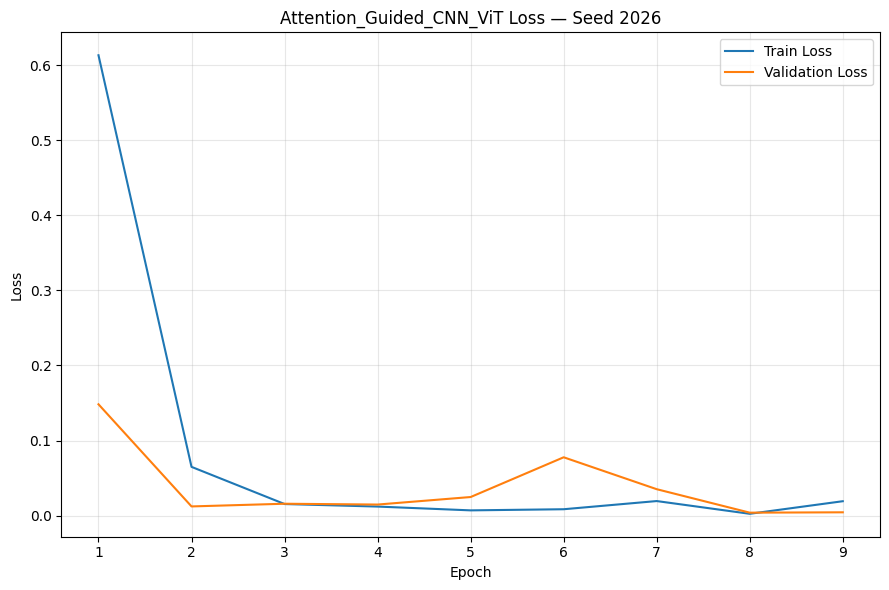

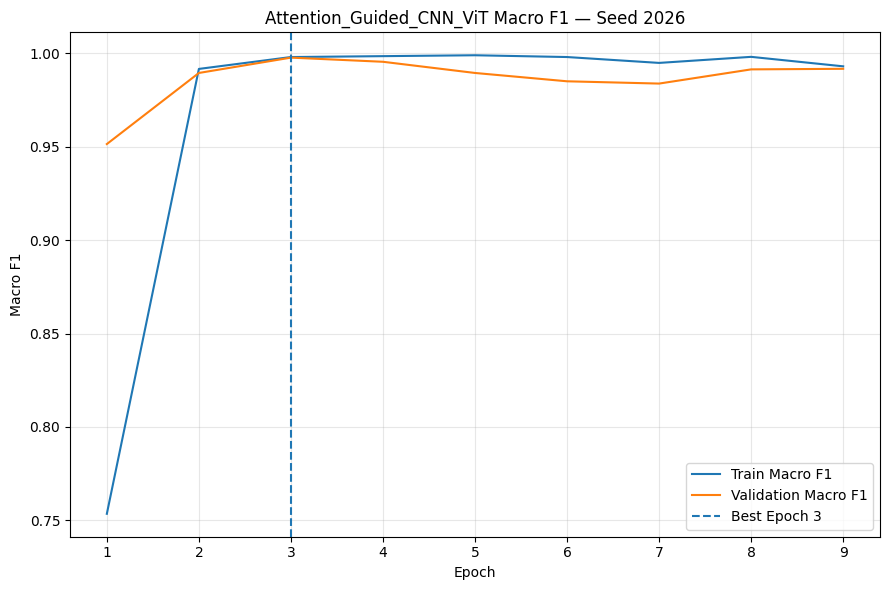

,model,model_key,seed,best_epoch,best_val_macro_f1,internal_test_accuracy,internal_test_macro_precision,internal_test_macro_recall,internal_test_macro_f1,total_parameters,trainable_parameters,session_training_minutes,external_test_used
0,Attention_Guided_CNN_ViT,Attention_Guided_CNN_ViT,2026,3,0.997778,0.996904,0.997792,0.997778,0.997778,10109249,10109249,5.38178,False


,model,seed,status,best_val_macro_f1,internal_macro_f1
0,Attention_Guided_CNN_ViT,2026,completed,0.997778,0.997778


Session status saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/multiseed_runs/latest_additional_seed_session_20260807_090238.csv


In [62]:

# Cell 8: Discover missing runs and train the next one(s)
inventory = []

for seed in TARGET_SEEDS:
    for model_key in MODEL_ORDER:
        paths = output_paths(model_key, seed)
        inventory.append({
            'model':model_key,
            'seed':seed,
            'best_checkpoint_exists':paths['best'].exists(),
            'summary_exists':paths['summary'].exists(),
            'last_checkpoint_exists':paths['last'].exists(),
            'run_complete':paths['best'].exists() and paths['summary'].exists(),
        })

inventory_df = pd.DataFrame(inventory)
display(inventory_df)

missing_runs = [
    (row.model, int(row.seed))
    for row in inventory_df.itertuples(index=False)
    if not row.run_complete
]

print('Completed:', int(inventory_df['run_complete'].sum()), '/ 8')
print('Remaining:', len(missing_runs))

session_plan = missing_runs[:MAX_NEW_RUNS_PER_SESSION]
session_results = []

if not session_plan:
    print('✅ সব additional-seed run complete.')
else:
    print('This session will train:', session_plan)
    for model_key, seed in session_plan:
        session_results.append(train_one_run(model_key, seed))

session_results_df = pd.DataFrame(session_results)
if not session_results_df.empty:
    display(session_results_df)

status_path = RUN_STATUS_DIR / (
    'latest_additional_seed_session_'
    + datetime.now().strftime('%Y%m%d_%H%M%S')
    + '.csv'
)
session_results_df.to_csv(status_path, index=False)
print('Session status saved:', status_path)


In [63]:

# Cell 9: Final inventory and next instruction
final_rows = []

for seed in TARGET_SEEDS:
    for model_key in MODEL_ORDER:
        paths = output_paths(model_key, seed)
        final_rows.append({
            'model':model_key,
            'seed':seed,
            'best_checkpoint_exists':paths['best'].exists(),
            'summary_exists':paths['summary'].exists(),
            'run_complete':paths['best'].exists() and paths['summary'].exists(),
        })

final_inventory_df = pd.DataFrame(final_rows)
final_inventory_path = METADATA_DIR / 'additional_seed_training_inventory.csv'
final_inventory_df.to_csv(final_inventory_path, index=False)

display(final_inventory_df)

completed = int(final_inventory_df['run_complete'].sum())
remaining = len(final_inventory_df) - completed

print('Completed:', completed, '/ 8')
print('Remaining:', remaining)
print('Saved:', final_inventory_path)

if remaining == 0:
    print('✅ Seeds 123 and 2026 are complete for all four models.')
    print('Next: 10_MultiSeed_and_External_Evaluation.ipynb আবার Run all দাও।')
else:
    next_row = final_inventory_df[~final_inventory_df['run_complete']].iloc[0]
    print('✅ Current session finished.')
    print('Next missing:', next_row['model'], 'seed', int(next_row['seed']))
    print('এই notebook আবার Runtime → Run all দাও।')


,model,seed,best_checkpoint_exists,summary_exists,run_complete
0,CNN_EfficientNet_B0,123,True,True,True
1,ViT_DeiT_Tiny,123,True,True,True
2,CNN_ViT_Concatenation,123,True,True,True
3,Attention_Guided_CNN_ViT,123,True,True,True
4,CNN_EfficientNet_B0,2026,True,True,True
5,ViT_DeiT_Tiny,2026,True,True,True
6,CNN_ViT_Concatenation,2026,True,True,True
7,Attention_Guided_CNN_ViT,2026,True,True,True


Completed: 8 / 8
Remaining: 0
Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/02_data/metadata/additional_seed_training_inventory.csv
✅ Seeds 123 and 2026 are complete for all four models.
Next: 10_MultiSeed_and_External_Evaluation.ipynb আবার Run all দাও।


---

# Part 12 — 12. Statistical Comparison and Grad-CAM

**Purpose:** Perform statistical model comparisons from saved predictions and generate Grad-CAM visual explanations for the proposed model.

**Source notebook:** `12_Statistical_Comparison_and_GradCAM.ipynb`

**Preservation note:** The original code cells and their saved execution outputs are retained below. Textual headings/comments are lightly normalized into English where possible without changing experiment logic.


# 12 — Statistical Comparison and Grad-CAM

`10_MultiSeed_and_External_Evaluation.ipynb` সফলভাবে শেষ হওয়ার পর This notebook run this notebook।

> `11_Additional_Seed_Training.ipynb` আগেই আছে, তাই This notebook-এর নম্বর `12`।

This notebook নতুন করে পুরো PLDD-UP inference করবে না। Saved prediction CSV using statistical comparison করবে এবং seed-42 proposed model-এর CNN branch Grad-CAM বানাবে।


In [1]:
# Cell 1: Mount Drive and install packages
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
!pip -q install timm statsmodels


Mounted at /content/drive


In [2]:
# Cell 2: Imports and configuration
from pathlib import Path
import random, numpy as np, pandas as pd, matplotlib.pyplot as plt
from PIL import Image
import torch
from torch import nn
from torchvision import transforms
from torchvision.models import efficientnet_b0
import timm
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from statsmodels.stats.contingency_tables import mcnemar

SEEDS=[42,123,2026]
CLASS_NAMES=['Early_Blight','Late_Blight','Healthy']
PROPOSED='Attention_Guided_CNN_ViT'
BASELINES=['CNN_EfficientNet_B0','ViT_DeiT_Tiny','CNN_ViT_Concatenation']
MODELS=BASELINES+[PROPOSED]
BOOTSTRAP_ITERATIONS=1000
RANDOM_SEED=42
IMAGE_SIZE=224
RESIZE_SIZE=256
MEAN=[0.485,0.456,0.406]
STD=[0.229,0.224,0.225]
DEVICE=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
random.seed(RANDOM_SEED); np.random.seed(RANDOM_SEED); torch.manual_seed(RANDOM_SEED)
print('Device:',DEVICE)


Device: cpu


In [3]:
# Cell 3: Project folders
ROOT=Path('/content/drive/MyDrive/Potato_CNN_ViT_Research')
if not ROOT.exists():
    matches=list(Path('/content/drive/MyDrive').rglob('Potato_CNN_ViT_Research'))
    if not matches: raise FileNotFoundError('Project folder not found')
    ROOT=matches[0]

SPLITS=ROOT/'02_data'/'splits'
CHECKPOINTS=ROOT/'04_checkpoints'
RESULTS=ROOT/'05_results'
PRED=RESULTS/'predictions'
STAT=RESULTS/'statistical_analysis'
EXPL=RESULTS/'explainability'
GRADCAM=EXPL/'gradcam'
TABLES=EXPL/'tables'
for p in [STAT,GRADCAM,TABLES]: p.mkdir(parents=True,exist_ok=True)
print('ROOT:',ROOT)


ROOT: /content/drive/MyDrive/Potato_CNN_ViT_Research


In [4]:
# Cell 4: Load all 24 saved prediction CSV files
def pred_path(model,seed,dataset):
    return PRED/f'{model}_seed{seed}_{dataset}_predictions.csv'

frames={}
missing=[]
for seed in SEEDS:
    for model in MODELS:
        for dataset in ['internal_test','external_test']:
            p=pred_path(model,seed,dataset)
            if not p.exists():
                missing.append(str(p)); continue
            df=pd.read_csv(p).reset_index(drop=True)
            df['true_class_id']=df['true_class_id'].astype(int)
            df['predicted_class_id']=df['predicted_class_id'].astype(int)
            df['is_correct']=df['true_class_id']==df['predicted_class_id']
            frames[(model,seed,dataset)]=df
if missing:
    print('Missing files:'); print('\n'.join(missing)); raise FileNotFoundError('Prediction CSV missing')
print('✅ Loaded',len(frames),'prediction CSV files')


✅ Loaded 24 prediction CSV files


In [5]:
# Cell 5: Helpers
def metrics(y_true,y_pred):
    acc=accuracy_score(y_true,y_pred)
    p,r,f1,_=precision_recall_fscore_support(y_true,y_pred,average='macro',zero_division=0)
    return dict(accuracy=float(acc),macro_precision=float(p),macro_recall=float(r),macro_f1=float(f1))

def exact_mcnemar(prop_correct,base_correct):
    p=np.asarray(prop_correct,bool); b=np.asarray(base_correct,bool)
    both=int(np.sum(p&b)); prop_only=int(np.sum(p&~b)); base_only=int(np.sum(~p&b)); both_wrong=int(np.sum(~p&~b))
    res=mcnemar([[both,base_only],[prop_only,both_wrong]], exact=True)
    return dict(both_correct=both, proposed_only_correct=prop_only, baseline_only_correct=base_only, both_wrong=both_wrong, mcnemar_statistic=float(res.statistic), mcnemar_p_value=float(res.pvalue))

def paired_bootstrap(y,pp,bp,seed,iterations=BOOTSTRAP_ITERATIONS):
    y=np.asarray(y); pp=np.asarray(pp); bp=np.asarray(bp); n=len(y); rng=np.random.default_rng(seed)
    da=[]; df=[]
    for _ in range(iterations):
        idx=rng.integers(0,n,n); yy=y[idx]; p1=pp[idx]; p0=bp[idx]
        da.append(accuracy_score(yy,p1)-accuracy_score(yy,p0))
        _,_,f1p,_=precision_recall_fscore_support(yy,p1,average='macro',zero_division=0)
        _,_,f1b,_=precision_recall_fscore_support(yy,p0,average='macro',zero_division=0)
        df.append(f1p-f1b)
    return dict(accuracy_diff_ci_lower=float(np.percentile(da,2.5)),accuracy_diff_ci_upper=float(np.percentile(da,97.5)),macro_f1_diff_ci_lower=float(np.percentile(df,2.5)),macro_f1_diff_ci_upper=float(np.percentile(df,97.5)))


In [6]:
# Cell 6: Proposed vs baselines — per seed
rows=[]
for dataset in ['internal_test','external_test']:
    for seed in SEEDS:
        prop=frames[(PROPOSED,seed,dataset)]
        yt=prop['true_class_id'].to_numpy(); pp=prop['predicted_class_id'].to_numpy(); pm=metrics(yt,pp)
        for j,base in enumerate(BASELINES):
            bdf=frames[(base,seed,dataset)]
            if len(prop)!=len(bdf) or not np.array_equal(yt,bdf['true_class_id'].to_numpy()):
                raise ValueError(f'Prediction alignment problem: {base}, seed {seed}, {dataset}')
            bp=bdf['predicted_class_id'].to_numpy(); bm=metrics(yt,bp)
            row=dict(dataset=dataset,seed=seed,proposed_model=PROPOSED,baseline_model=base,image_count=len(yt),proposed_accuracy=pm['accuracy'],baseline_accuracy=bm['accuracy'],accuracy_difference=pm['accuracy']-bm['accuracy'],proposed_macro_f1=pm['macro_f1'],baseline_macro_f1=bm['macro_f1'],macro_f1_difference=pm['macro_f1']-bm['macro_f1'])
            row.update(exact_mcnemar(prop['is_correct'],bdf['is_correct']))
            row.update(paired_bootstrap(yt,pp,bp,RANDOM_SEED+seed+j))
            rows.append(row)
stat_df=pd.DataFrame(rows)
stat_df['significant_at_0_05']=stat_df['mcnemar_p_value']<0.05
stat_path=STAT/'proposed_vs_baselines_per_seed.csv'
stat_df.to_csv(stat_path,index=False)
display(stat_df.round(5))
print('Saved:',stat_path)


,dataset,seed,proposed_model,baseline_model,image_count,proposed_accuracy,baseline_accuracy,accuracy_difference,proposed_macro_f1,baseline_macro_f1,...,proposed_only_correct,baseline_only_correct,both_wrong,mcnemar_statistic,mcnemar_p_value,accuracy_diff_ci_lower,accuracy_diff_ci_upper,macro_f1_diff_ci_lower,macro_f1_diff_ci_upper,significant_at_0_05
0,internal_test,42,Attention_Guided_CNN_ViT,CNN_EfficientNet_B0,323,1.00000,1.00000,0.00000,1.00000,1.00000,...,0,0,0,0.0,1.00000,0.00000,0.00000,0.00000,0.00000,False
1,internal_test,42,Attention_Guided_CNN_ViT,ViT_DeiT_Tiny,323,1.00000,1.00000,0.00000,1.00000,1.00000,...,0,0,0,0.0,1.00000,0.00000,0.00000,0.00000,0.00000,False
2,internal_test,42,Attention_Guided_CNN_ViT,CNN_ViT_Concatenation,323,1.00000,1.00000,0.00000,1.00000,1.00000,...,0,0,0,0.0,1.00000,0.00000,0.00000,0.00000,0.00000,False
3,internal_test,123,Attention_Guided_CNN_ViT,CNN_EfficientNet_B0,323,1.00000,1.00000,0.00000,1.00000,1.00000,...,0,0,0,0.0,1.00000,0.00000,0.00000,0.00000,0.00000,False
4,internal_test,123,Attention_Guided_CNN_ViT,ViT_DeiT_Tiny,323,1.00000,1.00000,0.00000,1.00000,1.00000,...,0,0,0,0.0,1.00000,0.00000,0.00000,0.00000,0.00000,False
5,internal_test,123,Attention_Guided_CNN_ViT,CNN_ViT_Concatenation,323,1.00000,1.00000,0.00000,1.00000,1.00000,...,0,0,0,0.0,1.00000,0.00000,0.00000,0.00000,0.00000,False
6,internal_test,2026,Attention_Guided_CNN_ViT,CNN_EfficientNet_B0,323,0.99690,1.00000,-0.00310,0.99778,1.00000,...,0,1,0,0.0,1.00000,-0.00929,0.00000,-0.00678,0.00000,False
7,internal_test,2026,Attention_Guided_CNN_ViT,ViT_DeiT_Tiny,323,0.99690,1.00000,-0.00310,0.99778,1.00000,...,0,1,0,0.0,1.00000,-0.00929,0.00000,-0.00683,0.00000,False
8,internal_test,2026,Attention_Guided_CNN_ViT,CNN_ViT_Concatenation,323,0.99690,1.00000,-0.00310,0.99778,1.00000,...,0,1,0,0.0,1.00000,-0.00929,0.00000,-0.00682,0.00000,False
9,external_test,42,Attention_Guided_CNN_ViT,CNN_EfficientNet_B0,15260,0.50439,0.45688,0.04751,0.44378,0.42815,...,4801,4076,3487,4076.0,0.00000,0.03558,0.05970,0.00561,0.02657,True


Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/statistical_analysis/proposed_vs_baselines_per_seed.csv


In [7]:
# Cell 7: Three-seed summary
summary=(stat_df.groupby(['dataset','baseline_model']).agg(seed_count=('seed','nunique'),proposed_accuracy_mean=('proposed_accuracy','mean'),proposed_accuracy_std=('proposed_accuracy','std'),baseline_accuracy_mean=('baseline_accuracy','mean'),baseline_accuracy_std=('baseline_accuracy','std'),accuracy_difference_mean=('accuracy_difference','mean'),accuracy_difference_std=('accuracy_difference','std'),proposed_macro_f1_mean=('proposed_macro_f1','mean'),proposed_macro_f1_std=('proposed_macro_f1','std'),baseline_macro_f1_mean=('baseline_macro_f1','mean'),baseline_macro_f1_std=('baseline_macro_f1','std'),macro_f1_difference_mean=('macro_f1_difference','mean'),macro_f1_difference_std=('macro_f1_difference','std'),significant_seed_count=('significant_at_0_05','sum')).reset_index())
summary_path=STAT/'proposed_vs_baselines_three_seed_summary.csv'
summary.to_csv(summary_path,index=False)
display(summary.round(5))
print('Saved:',summary_path)


,dataset,baseline_model,seed_count,proposed_accuracy_mean,proposed_accuracy_std,baseline_accuracy_mean,baseline_accuracy_std,accuracy_difference_mean,accuracy_difference_std,proposed_macro_f1_mean,proposed_macro_f1_std,baseline_macro_f1_mean,baseline_macro_f1_std,macro_f1_difference_mean,macro_f1_difference_std,significant_seed_count
0,external_test,CNN_EfficientNet_B0,3,0.56850,0.05784,0.49989,0.03776,0.06861,0.02892,0.53740,0.08383,0.48656,0.05061,0.05084,0.03624,3
1,external_test,CNN_ViT_Concatenation,3,0.56850,0.05784,0.61575,0.07992,-0.04725,0.12808,0.53740,0.08383,0.59031,0.12643,-0.05291,0.19147,3
2,external_test,ViT_DeiT_Tiny,3,0.56850,0.05784,0.63521,0.02145,-0.06671,0.06111,0.53740,0.08383,0.62375,0.03115,-0.08635,0.08403,2
3,internal_test,CNN_EfficientNet_B0,3,0.99897,0.00179,1.00000,0.00000,-0.00103,0.00179,0.99926,0.00128,1.00000,0.00000,-0.00074,0.00128,0
4,internal_test,CNN_ViT_Concatenation,3,0.99897,0.00179,1.00000,0.00000,-0.00103,0.00179,0.99926,0.00128,1.00000,0.00000,-0.00074,0.00128,0
5,internal_test,ViT_DeiT_Tiny,3,0.99897,0.00179,1.00000,0.00000,-0.00103,0.00179,0.99926,0.00128,1.00000,0.00000,-0.00074,0.00128,0


Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/statistical_analysis/proposed_vs_baselines_three_seed_summary.csv


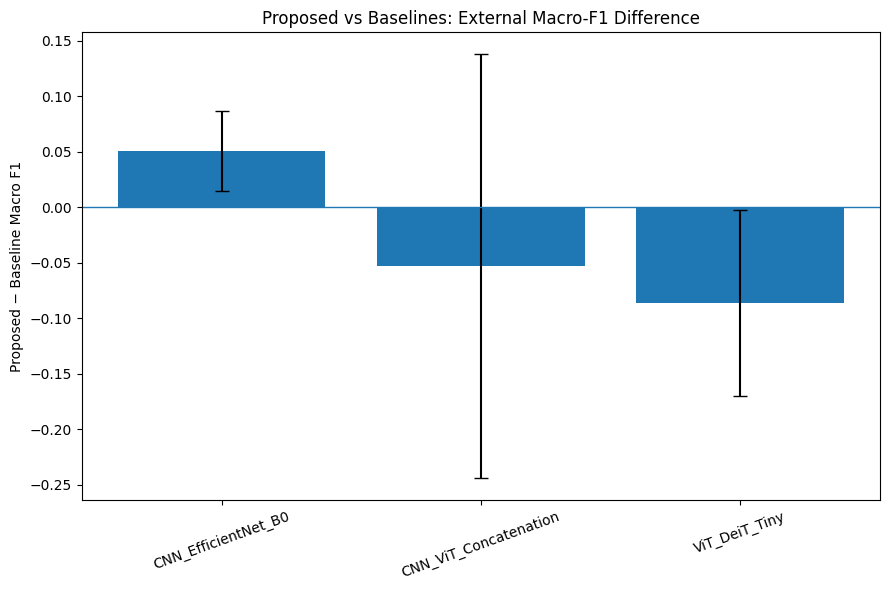

Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/statistical_analysis/external_macro_f1_difference.png


In [8]:
# Cell 8: External comparison plot
ext=summary[summary['dataset']=='external_test'].copy()
fig,ax=plt.subplots(figsize=(9,6))
ax.bar(ext['baseline_model'],ext['macro_f1_difference_mean'],yerr=ext['macro_f1_difference_std'],capsize=5)
ax.axhline(0,linewidth=1)
ax.set_title('Proposed vs Baselines: External Macro-F1 Difference')
ax.set_ylabel('Proposed − Baseline Macro F1')
ax.tick_params(axis='x',rotation=20)
plt.tight_layout()
plot_path=STAT/'external_macro_f1_difference.png'
plt.savefig(plot_path,dpi=200,bbox_inches='tight'); plt.show()
print('Saved:',plot_path)


## Grad-CAM

এখানে full PLDD-UP dataset আবার run হবে না। Seed-42 proposed model-এর saved external predictions থেকে কয়েকটি sample নেওয়া হবে।


In [9]:
# Cell 9: Proposed model architecture
class AttentionGuidedCNNViT(nn.Module):
    def __init__(self,num_classes,vit_model_name,projection_dim=256,classifier_hidden_dim=256,dropout=0.35):
        super().__init__()
        cnn=efficientnet_b0(weights=None)
        self.cnn_features=cnn.features
        self.cnn_pool=nn.AdaptiveAvgPool2d(1)
        cdim=cnn.classifier[1].in_features
        self.vit_backbone=timm.create_model(vit_model_name,pretrained=False,num_classes=0,global_pool='avg')
        vdim=self.vit_backbone.num_features
        self.cnn_projection=nn.Sequential(nn.Linear(cdim,projection_dim),nn.LayerNorm(projection_dim),nn.GELU(),nn.Dropout(dropout))
        self.vit_projection=nn.Sequential(nn.Linear(vdim,projection_dim),nn.LayerNorm(projection_dim),nn.GELU(),nn.Dropout(dropout))
        self.attention_gate=nn.Sequential(nn.Linear(projection_dim*2,projection_dim),nn.GELU(),nn.Dropout(dropout),nn.Linear(projection_dim,2))
        self.classifier=nn.Sequential(nn.LayerNorm(projection_dim),nn.Dropout(dropout),nn.Linear(projection_dim,classifier_hidden_dim),nn.GELU(),nn.Dropout(dropout),nn.Linear(classifier_hidden_dim,num_classes))
    def forward(self,x,return_attention=False):
        cmap=self.cnn_features(x); cr=self.cnn_pool(cmap).flatten(1); vr=self.vit_backbone(x)
        cp=self.cnn_projection(cr); vp=self.vit_projection(vr); joint=torch.cat([cp,vp],1)
        aw=torch.softmax(self.attention_gate(joint),1); fused=aw[:,0:1]*cp+aw[:,1:2]*vp; logits=self.classifier(fused)
        return (logits,aw) if return_attention else logits

def safe_load(path):
    try: return torch.load(path,map_location=DEVICE,weights_only=False)
    except TypeError: return torch.load(path,map_location=DEVICE)


In [10]:
# Cell 10: Load seed-42 proposed checkpoint
ckpt_path=CHECKPOINTS/'attention'/'attention_cnn_vit_best_seed42.pth'
ckpt=safe_load(ckpt_path); cfg=ckpt.get('config',{}); vit_name=ckpt.get('vit_branch','deit_tiny_patch16_224.fb_in1k')
model=AttentionGuidedCNNViT(len(CLASS_NAMES),vit_name,int(cfg.get('projection_dim',256)),int(cfg.get('classifier_hidden_dim',256)),float(cfg.get('dropout',0.35))).to(DEVICE)
model.load_state_dict(ckpt['model_state_dict']); model.eval()
print('✅ Proposed checkpoint loaded:',ckpt_path)


✅ Proposed checkpoint loaded: /content/drive/MyDrive/Potato_CNN_ViT_Research/04_checkpoints/attention/attention_cnn_vit_best_seed42.pth


In [11]:
# Cell 11: External paths and transform
eval_transform=transforms.Compose([transforms.Resize((RESIZE_SIZE,RESIZE_SIZE)),transforms.CenterCrop(IMAGE_SIZE),transforms.ToTensor(),transforms.Normalize(MEAN,STD)])
ext_split=pd.read_csv(SPLITS/'external_test.csv').reset_index(drop=True)
prop42=frames[(PROPOSED,42,'external_test')].copy().reset_index(drop=True)
if len(ext_split)!=len(prop42): raise ValueError('external split/prediction length mismatch')
prop42['gradcam_file_path']=ext_split['file_path'].astype(str).values
missing=int((~prop42['gradcam_file_path'].map(lambda x: Path(x).exists())).sum())
if missing: raise FileNotFoundError(f'{missing} Grad-CAM source images missing')
print('External paths ready:',len(prop42))


External paths ready: 15260


In [12]:
# Cell 12: Grad-CAM helper
class GradCAM:
    def __init__(self,model,target_layer):
        self.model=model; self.a=None; self.g=None
        self.fh=target_layer.register_forward_hook(lambda m,i,o:setattr(self,'a',o))
        self.bh=target_layer.register_full_backward_hook(lambda m,gi,go:setattr(self,'g',go[0]))
    def generate(self,x,target=None):
        self.model.zero_grad(set_to_none=True); logits,att=self.model(x,return_attention=True)
        if target is None: target=int(logits.argmax(1)[0])
        logits[0,target].backward(); grad=self.g[0]; act=self.a[0]; w=grad.mean((1,2),keepdim=True); cam=torch.relu((w*act).sum(0)); cam=(cam-cam.min())/(cam.max()-cam.min()+1e-8)
        prob=torch.softmax(logits,1).detach().cpu().numpy()[0]; att=att.detach().cpu().numpy()[0]
        return cam.detach().cpu().numpy(),int(logits.argmax(1)[0]),prob,float(att[0]),float(att[1])
    def close(self): self.fh.remove(); self.bh.remove()

gradcam=GradCAM(model,model.cnn_features[-1])


In [13]:
# Cell 13: Select representative samples
samples=[]
for cname in CLASS_NAMES:
    sub=prop42[prop42['true_class_name']==cname] if 'true_class_name' in prop42.columns else prop42[prop42['true_class_id']==CLASS_NAMES.index(cname)]
    good=sub[sub['is_correct']]; bad=sub[~sub['is_correct']]
    if not good.empty: samples.append(good.iloc[0])
    if not bad.empty: samples.append(bad.iloc[0])
samples_df=pd.DataFrame(samples).reset_index(drop=True)
sel_path=TABLES/'selected_gradcam_samples_seed42.csv'; samples_df.to_csv(sel_path,index=False)
display(samples_df[['true_class_id','predicted_class_id','is_correct','gradcam_file_path']])
print('Saved:',sel_path)


,true_class_id,predicted_class_id,is_correct,gradcam_file_path
0,0,0,True,/content/drive/MyDrive/Potato_CNN_ViT_Research...
1,0,1,False,/content/drive/MyDrive/Potato_CNN_ViT_Research...
2,1,1,True,/content/drive/MyDrive/Potato_CNN_ViT_Research...
3,1,0,False,/content/drive/MyDrive/Potato_CNN_ViT_Research...
4,2,2,True,/content/drive/MyDrive/Potato_CNN_ViT_Research...
5,2,0,False,/content/drive/MyDrive/Potato_CNN_ViT_Research...


Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/explainability/tables/selected_gradcam_samples_seed42.csv


In [14]:
# Cell 14: Generate Grad-CAM figures
rows=[]
for i,row in samples_df.iterrows():
    p=Path(row['gradcam_file_path'])
    with Image.open(p) as im: rgb=im.convert('RGB')
    x=eval_transform(rgb).unsqueeze(0).to(DEVICE); cam,pid,probs,cw,vw=gradcam.generate(x)
    cam_img=Image.fromarray(np.uint8(np.clip(cam,0,1)*255)).resize((IMAGE_SIZE,IMAGE_SIZE)); cam_r=np.asarray(cam_img)/255.0
    disp=np.asarray(rgb.resize((IMAGE_SIZE,IMAGE_SIZE))).astype(np.float32)/255.0
    fig,axs=plt.subplots(1,3,figsize=(14,4.5)); axs[0].imshow(disp); axs[0].set_title('Original'); axs[0].axis('off'); axs[1].imshow(cam_r,cmap='jet'); axs[1].set_title('CNN Branch Grad-CAM'); axs[1].axis('off'); axs[2].imshow(disp); axs[2].imshow(cam_r,cmap='jet',alpha=.45); axs[2].set_title('Overlay'); axs[2].axis('off')
    true_id=int(row['true_class_id']); corr=pid==true_id
    fig.suptitle(f'True: {CLASS_NAMES[true_id]} | Pred: {CLASS_NAMES[pid]} | {"Correct" if corr else "Wrong"}\nCNN weight: {cw:.3f} | ViT weight: {vw:.3f}')
    plt.tight_layout(); out=GRADCAM/f'seed42_sample{i:02d}_{CLASS_NAMES[true_id]}_{"correct" if corr else "wrong"}.png'; plt.savefig(out,dpi=200,bbox_inches='tight'); plt.show()
    rows.append(dict(sample_index=i,file_path=str(p),true_class=CLASS_NAMES[true_id],predicted_class=CLASS_NAMES[pid],is_correct=corr,cnn_attention_weight=cw,vit_attention_weight=vw,predicted_probability=float(probs[pid]),figure_path=str(out)))
gradcam.close()
gradcam_df=pd.DataFrame(rows); gradcam_path=TABLES/'gradcam_results_seed42.csv'; gradcam_df.to_csv(gradcam_path,index=False); display(gradcam_df); print('Saved:',gradcam_path)


Output hidden; open in https://colab.research.google.com to view.

In [15]:
# Cell 15: Final report
report=pd.DataFrame([
 {'check':'All 24 prediction CSVs loaded','passed':len(frames)==24},
 {'check':'Per-seed statistical comparison saved','passed':stat_path.exists()},
 {'check':'Three-seed statistical summary saved','passed':summary_path.exists()},
 {'check':'McNemar tests completed','passed':'mcnemar_p_value' in stat_df.columns},
 {'check':'Paired bootstrap CIs completed','passed':'accuracy_diff_ci_lower' in stat_df.columns},
 {'check':'Grad-CAM images generated','passed':len(list(GRADCAM.glob('seed42_sample*.png')))>0},
 {'check':'Grad-CAM table saved','passed':gradcam_path.exists()},
])
display(report)
if report['passed'].all():
    print('✅ Statistical comparison and Grad-CAM completed successfully.')
    print('Next step: 13_Ablation_and_Error_Analysis.ipynb')
else:
    print('⚠️ Completed with warnings.')


,check,passed
0,All 24 prediction CSVs loaded,True
1,Per-seed statistical comparison saved,True
2,Three-seed statistical summary saved,True
3,McNemar tests completed,True
4,Paired bootstrap CIs completed,True
5,Grad-CAM images generated,True
6,Grad-CAM table saved,True


✅ Statistical comparison and Grad-CAM completed successfully.
Next step: 13_Ablation_and_Error_Analysis.ipynb


---

# Part 13 — 13. Ablation and Error Analysis

**Purpose:** Compare architecture variants and analyze model errors, confusion patterns, high-confidence mistakes, and representative misclassified examples.

**Source notebook:** `13_Ablation_and_Error_Analysis.ipynb`

**Preservation note:** The original code cells and their saved execution outputs are retained below. Textual headings/comments are lightly normalized into English where possible without changing experiment logic.


# 13 — Ablation and Error Analysis

This notebook আগের saved results using **architectural ablation/comparison** এবং **error analysis** করবে।

## Ablation / architecture comparison

চারটি configuration compare করা হবে:

1. `CNN_EfficientNet_B0` — CNN only
2. `ViT_DeiT_Tiny` — ViT only
3. `CNN_ViT_Concatenation` — CNN + ViT, simple concatenation
4. `Attention_Guided_CNN_ViT` — CNN + ViT + learnable branch attention

এতে দেখা যাবে:
- CNN-only এবং ViT-only performance
- hybrid concatenation-এর contribution
- attention gate যোগ করার পরে improvement বা degradation
- controlled → natural-field generalization gap

## Error analysis

Saved prediction CSV থেকে:
- class-wise accuracy/error rate
- confusion pairs
- per-seed error count
- high-confidence wrong predictions
- proposed model-এর most frequent mistakes
- model-wise external error comparison
- representative misclassified image montage

## Important

- This notebook **will not retrain any model**।
- পুরো PLDD-UP dataset আবার inference করবে না।
- আগের Notebook 10 ও 12-এর saved CSV ব্যবহার করবে।
- Proposed model যদি কোনো baseline-এর চেয়ে খারাপ হয়, notebook সেটাও সঠিকভাবে report করবে; result পরিবর্তন বা hide করবে না।


In [21]:
# Cell 1: Mount Google Drive
from google.colab import drive

drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [22]:
# Cell 2: Imports and experiment settings
from pathlib import Path
import math
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageOps, ImageDraw

from sklearn.metrics import confusion_matrix

SEEDS = [42, 123, 2026]

CLASS_NAMES = [
    'Early_Blight',
    'Late_Blight',
    'Healthy',
]

MODEL_ORDER = [
    'CNN_EfficientNet_B0',
    'ViT_DeiT_Tiny',
    'CNN_ViT_Concatenation',
    'Attention_Guided_CNN_ViT',
]

PROPOSED_MODEL = (
    'Attention_Guided_CNN_ViT'
)

MODEL_LABELS = {
    'CNN_EfficientNet_B0':
        'CNN only (EfficientNet-B0)',

    'ViT_DeiT_Tiny':
        'ViT only (DeiT-Tiny)',

    'CNN_ViT_Concatenation':
        'CNN + ViT Concatenation',

    'Attention_Guided_CNN_ViT':
        'CNN + ViT + Attention',
}

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print('Seeds:', SEEDS)
print('Models:', MODEL_ORDER)


Seeds: [42, 123, 2026]
Models: ['CNN_EfficientNet_B0', 'ViT_DeiT_Tiny', 'CNN_ViT_Concatenation', 'Attention_Guided_CNN_ViT']


In [23]:
# Cell 3: Locate project folders
MY_DRIVE = Path('/content/drive/MyDrive')

standard_project = (
    MY_DRIVE / 'Potato_CNN_ViT_Research'
)

if standard_project.is_dir():
    PROJECT_ROOT = standard_project
else:
    matches = [
        path
        for path in MY_DRIVE.rglob(
            'Potato_CNN_ViT_Research'
        )
        if path.is_dir()
    ]

    if not matches:
        raise FileNotFoundError(
            'Potato_CNN_ViT_Research folder My Drive-এ পাওয়া যায়নি।'
        )

    PROJECT_ROOT = matches[0]

RESULTS_ROOT = (
    PROJECT_ROOT / '05_results'
)

METRICS_DIR = (
    RESULTS_ROOT / 'metrics'
)

PREDICTIONS_DIR = (
    RESULTS_ROOT / 'predictions'
)

STATISTICS_DIR = (
    RESULTS_ROOT / 'statistical_analysis'
)

ABLATION_DIR = (
    RESULTS_ROOT / 'ablation'
)

ERROR_DIR = (
    RESULTS_ROOT / 'error_analysis'
)

ERROR_FIGURE_DIR = (
    ERROR_DIR / 'figures'
)

ERROR_TABLE_DIR = (
    ERROR_DIR / 'tables'
)

for folder in [
    ABLATION_DIR,
    ERROR_DIR,
    ERROR_FIGURE_DIR,
    ERROR_TABLE_DIR,
]:
    folder.mkdir(
        parents=True,
        exist_ok=True,
    )

print('PROJECT_ROOT:', PROJECT_ROOT)
print('ABLATION_DIR:', ABLATION_DIR)
print('ERROR_DIR:', ERROR_DIR)


PROJECT_ROOT: /content/drive/MyDrive/Potato_CNN_ViT_Research
ABLATION_DIR: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/ablation
ERROR_DIR: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/error_analysis


In [24]:
# Cell 4: Load multi-seed metrics from Notebook 10
all_metrics_path = (
    METRICS_DIR
    / 'all_available_seed_internal_external_metrics.csv'
)

multiseed_summary_path = (
    METRICS_DIR
    / 'multiseed_mean_std_summary.csv'
)

if not all_metrics_path.exists():
    raise FileNotFoundError(
        f'Missing: {all_metrics_path}'
    )

all_metrics_df = pd.read_csv(
    all_metrics_path
)

required_metric_columns = {
    'model',
    'seed',
    'dataset',
    'accuracy',
    'macro_precision',
    'macro_recall',
    'macro_f1',
}

missing_columns = (
    required_metric_columns
    - set(all_metrics_df.columns)
)

if missing_columns:
    raise KeyError(
        f'Metric columns missing: '
        f'{sorted(missing_columns)}'
    )

all_metrics_df['seed'] = (
    all_metrics_df['seed'].astype(int)
)

display(
    all_metrics_df.sort_values(
        ['dataset', 'model', 'seed']
    )
)

print(
    'Metric rows loaded:',
    len(all_metrics_df),
)


,model,seed,dataset,image_count,total_parameters,accuracy,macro_precision,macro_recall,macro_f1,evaluation_seconds,images_per_second
1,Attention_Guided_CNN_ViT,42,external_test,15260,10109249,0.504391,0.633935,0.474329,0.443776,1282.089367,11.902446
9,Attention_Guided_CNN_ViT,123,external_test,15260,10109249,0.584338,0.682270,0.555409,0.562921,1269.841158,12.017251
17,Attention_Guided_CNN_ViT,2026,external_test,15260,10109249,0.616776,0.686766,0.599203,0.605494,1278.056360,11.940006
3,CNN_EfficientNet_B0,42,external_test,15260,4011391,0.456881,0.538763,0.492934,0.428153,1276.266296,11.956752
11,CNN_EfficientNet_B0,123,external_test,15260,4011391,0.527588,0.570890,0.552446,0.514052,1244.654434,12.260431
19,CNN_EfficientNet_B0,2026,external_test,15260,4011391,0.515203,0.578050,0.537067,0.517469,1273.079870,11.986679
5,CNN_ViT_Concatenation,42,external_test,15260,10290623,0.661730,0.700940,0.643258,0.652865,1288.961437,11.838989
13,CNN_ViT_Concatenation,123,external_test,15260,10290623,0.662058,0.718204,0.667478,0.673263,1283.093184,11.893135
21,CNN_ViT_Concatenation,2026,external_test,15260,10290623,0.523460,0.645911,0.488151,0.444787,1283.900580,11.885656
7,ViT_DeiT_Tiny,42,external_test,15260,5524995,0.627588,0.696994,0.601806,0.608529,1255.045191,12.158925


Metric rows loaded: 24


In [25]:
# Cell 5: Verify all 4 models × 3 seeds × 2 datasets
expected_rows = []

for model_name in MODEL_ORDER:
    for seed in SEEDS:
        for dataset_name in [
            'internal_test',
            'external_test',
        ]:
            expected_rows.append(
                (
                    model_name,
                    seed,
                    dataset_name,
                )
            )

actual_rows = set(
    zip(
        all_metrics_df['model'],
        all_metrics_df['seed'],
        all_metrics_df['dataset'],
    )
)

missing_experiments = [
    row
    for row in expected_rows
    if row not in actual_rows
]

if missing_experiments:
    display(
        pd.DataFrame(
            missing_experiments,
            columns=[
                'model',
                'seed',
                'dataset',
            ],
        )
    )

    raise RuntimeError(
        'Some expected evaluation rows are missing.'
    )

print(
    '✅ All 24 model-seed-dataset metric rows found.'
)


✅ All 24 model-seed-dataset metric rows found.


In [26]:
# Cell 6: Build three-seed ablation summary
ablation_summary_df = (
    all_metrics_df.groupby(
        [
            'model',
            'dataset',
        ]
    )
    .agg(
        seed_count=(
            'seed',
            'nunique',
        ),

        accuracy_mean=(
            'accuracy',
            'mean',
        ),

        accuracy_std=(
            'accuracy',
            'std',
        ),

        macro_precision_mean=(
            'macro_precision',
            'mean',
        ),

        macro_precision_std=(
            'macro_precision',
            'std',
        ),

        macro_recall_mean=(
            'macro_recall',
            'mean',
        ),

        macro_recall_std=(
            'macro_recall',
            'std',
        ),

        macro_f1_mean=(
            'macro_f1',
            'mean',
        ),

        macro_f1_std=(
            'macro_f1',
            'std',
        ),
    )
    .reset_index()
)

ablation_summary_df[
    'model_label'
] = ablation_summary_df[
    'model'
].map(MODEL_LABELS)

ablation_summary_df[
    'accuracy_mean_std'
] = (
    ablation_summary_df.apply(
        lambda row:
            f'{row["accuracy_mean"]:.4f} '
            f'± {row["accuracy_std"]:.4f}',
        axis=1,
    )
)

ablation_summary_df[
    'macro_f1_mean_std'
] = (
    ablation_summary_df.apply(
        lambda row:
            f'{row["macro_f1_mean"]:.4f} '
            f'± {row["macro_f1_std"]:.4f}',
        axis=1,
    )
)

ablation_summary_path = (
    ABLATION_DIR
    / 'four_model_ablation_summary.csv'
)

ablation_summary_df.to_csv(
    ablation_summary_path,
    index=False,
)

display(
    ablation_summary_df[
        [
            'model_label',
            'dataset',
            'seed_count',
            'accuracy_mean_std',
            'macro_f1_mean_std',
        ]
    ]
)

print(
    'Saved:',
    ablation_summary_path,
)


,model_label,dataset,seed_count,accuracy_mean_std,macro_f1_mean_std
0,CNN + ViT + Attention,external_test,3,0.5685 ± 0.0578,0.5374 ± 0.0838
1,CNN + ViT + Attention,internal_test,3,0.9990 ± 0.0018,0.9993 ± 0.0013
2,CNN only (EfficientNet-B0),external_test,3,0.4999 ± 0.0378,0.4866 ± 0.0506
3,CNN only (EfficientNet-B0),internal_test,3,1.0000 ± 0.0000,1.0000 ± 0.0000
4,CNN + ViT Concatenation,external_test,3,0.6157 ± 0.0799,0.5903 ± 0.1264
5,CNN + ViT Concatenation,internal_test,3,1.0000 ± 0.0000,1.0000 ± 0.0000
6,ViT only (DeiT-Tiny),external_test,3,0.6352 ± 0.0215,0.6238 ± 0.0311
7,ViT only (DeiT-Tiny),internal_test,3,1.0000 ± 0.0000,1.0000 ± 0.0000


Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/ablation/four_model_ablation_summary.csv


In [27]:
# Cell 7: Build compact paper-style ablation table
internal_summary = (
    ablation_summary_df[
        ablation_summary_df[
            'dataset'
        ] == 'internal_test'
    ]
    .set_index('model')
)

external_summary = (
    ablation_summary_df[
        ablation_summary_df[
            'dataset'
        ] == 'external_test'
    ]
    .set_index('model')
)

paper_ablation_rows = []

for model_name in MODEL_ORDER:
    internal_row = (
        internal_summary.loc[
            model_name
        ]
    )

    external_row = (
        external_summary.loc[
            model_name
        ]
    )

    paper_ablation_rows.append({
        'model':
            MODEL_LABELS[
                model_name
            ],

        'cnn_branch':
            'Yes'
            if model_name
            != 'ViT_DeiT_Tiny'
            else 'No',

        'vit_branch':
            'Yes'
            if model_name
            != 'CNN_EfficientNet_B0'
            else 'No',

        'fusion':
            (
                'None'
                if model_name
                in [
                    'CNN_EfficientNet_B0',
                    'ViT_DeiT_Tiny',
                ]
                else (
                    'Concatenation'
                    if model_name
                    == 'CNN_ViT_Concatenation'
                    else 'Attention'
                )
            ),

        'internal_accuracy_mean':
            internal_row[
                'accuracy_mean'
            ],

        'internal_accuracy_std':
            internal_row[
                'accuracy_std'
            ],

        'internal_macro_f1_mean':
            internal_row[
                'macro_f1_mean'
            ],

        'internal_macro_f1_std':
            internal_row[
                'macro_f1_std'
            ],

        'external_accuracy_mean':
            external_row[
                'accuracy_mean'
            ],

        'external_accuracy_std':
            external_row[
                'accuracy_std'
            ],

        'external_macro_f1_mean':
            external_row[
                'macro_f1_mean'
            ],

        'external_macro_f1_std':
            external_row[
                'macro_f1_std'
            ],

        'macro_f1_generalization_drop':
            (
                internal_row[
                    'macro_f1_mean'
                ]
                -
                external_row[
                    'macro_f1_mean'
                ]
            ),
    })


paper_ablation_df = pd.DataFrame(
    paper_ablation_rows
)

paper_ablation_path = (
    ABLATION_DIR
    / 'paper_ablation_table.csv'
)

paper_ablation_df.to_csv(
    paper_ablation_path,
    index=False,
)

display(
    paper_ablation_df.round(4)
)

print(
    'Saved:',
    paper_ablation_path,
)


,model,cnn_branch,vit_branch,fusion,internal_accuracy_mean,internal_accuracy_std,internal_macro_f1_mean,internal_macro_f1_std,external_accuracy_mean,external_accuracy_std,external_macro_f1_mean,external_macro_f1_std,macro_f1_generalization_drop
0,CNN only (EfficientNet-B0),Yes,No,None,1.000,0.0000,1.0000,0.0000,0.4999,0.0378,0.4866,0.0506,0.5134
1,ViT only (DeiT-Tiny),No,Yes,None,1.000,0.0000,1.0000,0.0000,0.6352,0.0215,0.6238,0.0311,0.3762
2,CNN + ViT Concatenation,Yes,Yes,Concatenation,1.000,0.0000,1.0000,0.0000,0.6157,0.0799,0.5903,0.1264,0.4097
3,CNN + ViT + Attention,Yes,Yes,Attention,0.999,0.0018,0.9993,0.0013,0.5685,0.0578,0.5374,0.0838,0.4619


Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/ablation/paper_ablation_table.csv


In [28]:
# Cell 8: Quantify attention contribution over simple concatenation
concat_external = (
    external_summary.loc[
        'CNN_ViT_Concatenation'
    ]
)

attention_external = (
    external_summary.loc[
        'Attention_Guided_CNN_ViT'
    ]
)

attention_vs_concat_df = pd.DataFrame([
    {
        'comparison':
            'Attention vs Concatenation',

        'external_accuracy_difference':
            (
                attention_external[
                    'accuracy_mean'
                ]
                -
                concat_external[
                    'accuracy_mean'
                ]
            ),

        'external_macro_f1_difference':
            (
                attention_external[
                    'macro_f1_mean'
                ]
                -
                concat_external[
                    'macro_f1_mean'
                ]
            ),

        'attention_external_accuracy':
            attention_external[
                'accuracy_mean'
            ],

        'concat_external_accuracy':
            concat_external[
                'accuracy_mean'
            ],

        'attention_external_macro_f1':
            attention_external[
                'macro_f1_mean'
            ],

        'concat_external_macro_f1':
            concat_external[
                'macro_f1_mean'
            ],
    }
])

attention_vs_concat_df[
    'attention_improves_macro_f1'
] = (
    attention_vs_concat_df[
        'external_macro_f1_difference'
    ] > 0
)

attention_vs_concat_path = (
    ABLATION_DIR
    / 'attention_vs_concatenation_effect.csv'
)

attention_vs_concat_df.to_csv(
    attention_vs_concat_path,
    index=False,
)

display(
    attention_vs_concat_df.round(5)
)

if bool(
    attention_vs_concat_df[
        'attention_improves_macro_f1'
    ].iloc[0]
):
    print(
        '✅ Attention improves three-seed '
        'external Macro-F1 over concatenation.'
    )
else:
    print(
        '⚠️ Attention does NOT improve three-seed '
        'external Macro-F1 over concatenation. '
        'Paper-এ result ঠিকভাবেই report করতে হবে.'
    )

print(
    'Saved:',
    attention_vs_concat_path,
)


,comparison,external_accuracy_difference,external_macro_f1_difference,attention_external_accuracy,concat_external_accuracy,attention_external_macro_f1,concat_external_macro_f1,attention_improves_macro_f1
0,Attention vs Concatenation,-0.04725,-0.05291,0.5685,0.61575,0.5374,0.59031,False


⚠️ Attention does NOT improve three-seed external Macro-F1 over concatenation. Paper-এ result ঠিকভাবেই report করতে হবে.
Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/ablation/attention_vs_concatenation_effect.csv


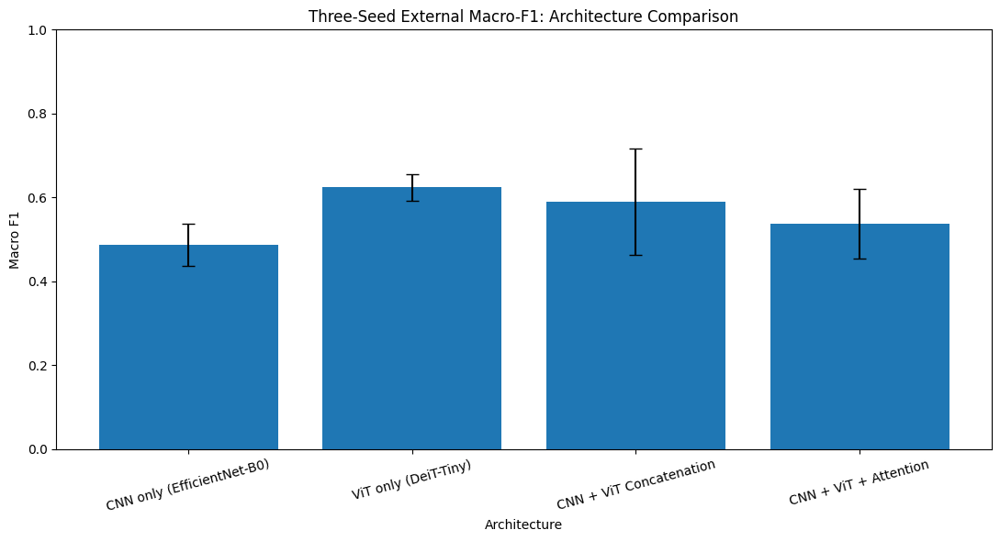

Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/ablation/external_macro_f1_ablation.png


In [29]:
# Cell 9: Plot external ablation comparison
external_plot_df = (
    paper_ablation_df[
        [
            'model',
            'external_macro_f1_mean',
            'external_macro_f1_std',
        ]
    ]
)

fig, axis = plt.subplots(
    figsize=(11, 6)
)

axis.bar(
    external_plot_df['model'],
    external_plot_df[
        'external_macro_f1_mean'
    ],
    yerr=external_plot_df[
        'external_macro_f1_std'
    ],
    capsize=5,
)

axis.set_title(
    'Three-Seed External Macro-F1: '
    'Architecture Comparison'
)

axis.set_xlabel(
    'Architecture'
)

axis.set_ylabel(
    'Macro F1'
)

axis.set_ylim(
    0,
    1.0,
)

axis.tick_params(
    axis='x',
    rotation=15,
)

plt.tight_layout()

ablation_figure_path = (
    ABLATION_DIR
    / 'external_macro_f1_ablation.png'
)

plt.savefig(
    ablation_figure_path,
    dpi=200,
    bbox_inches='tight',
)

plt.show()

print(
    'Saved:',
    ablation_figure_path,
)


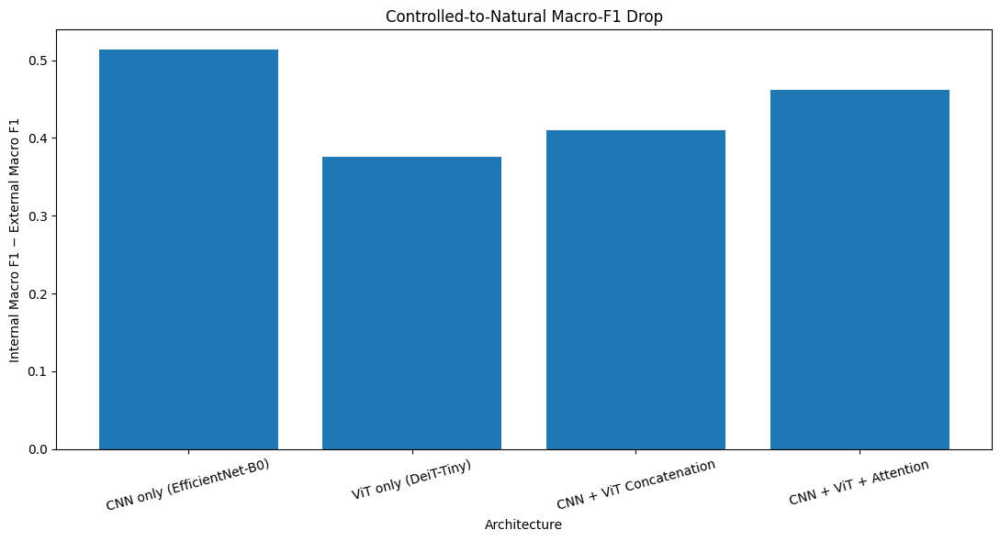

Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/ablation/macro_f1_generalization_drop.png


In [30]:
# Cell 10: Plot generalization gap
gap_plot_df = (
    paper_ablation_df[
        [
            'model',
            'macro_f1_generalization_drop',
        ]
    ]
)

fig, axis = plt.subplots(
    figsize=(11, 6)
)

axis.bar(
    gap_plot_df['model'],
    gap_plot_df[
        'macro_f1_generalization_drop'
    ],
)

axis.set_title(
    'Controlled-to-Natural Macro-F1 Drop'
)

axis.set_xlabel(
    'Architecture'
)

axis.set_ylabel(
    'Internal Macro F1 − External Macro F1'
)

axis.tick_params(
    axis='x',
    rotation=15,
)

plt.tight_layout()

gap_figure_path = (
    ABLATION_DIR
    / 'macro_f1_generalization_drop.png'
)

plt.savefig(
    gap_figure_path,
    dpi=200,
    bbox_inches='tight',
)

plt.show()

print(
    'Saved:',
    gap_figure_path,
)


# Error Analysis

এখন saved external prediction CSV using detailed error analysis করা হবে।


In [31]:
# Cell 11: Load all external prediction CSVs
external_prediction_frames = {}

prediction_inventory_rows = []

for model_name in MODEL_ORDER:
    for seed in SEEDS:
        prediction_path = (
            PREDICTIONS_DIR
            / (
                f'{model_name}_seed{seed}_'
                f'external_test_predictions.csv'
            )
        )

        prediction_inventory_rows.append({
            'model':
                model_name,
            'seed':
                seed,
            'path':
                str(prediction_path),
            'exists':
                prediction_path.exists(),
        })

        if prediction_path.exists():
            frame = pd.read_csv(
                prediction_path
            )

            frame = frame.reset_index(
                drop=True
            )

            frame[
                'true_class_id'
            ] = frame[
                'true_class_id'
            ].astype(int)

            frame[
                'predicted_class_id'
            ] = frame[
                'predicted_class_id'
            ].astype(int)

            frame[
                'is_correct'
            ] = (
                frame[
                    'true_class_id'
                ]
                ==
                frame[
                    'predicted_class_id'
                ]
            )

            external_prediction_frames[
                (
                    model_name,
                    seed,
                )
            ] = frame


prediction_inventory_df = pd.DataFrame(
    prediction_inventory_rows
)

display(
    prediction_inventory_df
)

if not prediction_inventory_df[
    'exists'
].all():
    raise FileNotFoundError(
        'Some external prediction CSVs are missing.'
    )

print(
    '✅ All 12 external prediction files loaded.'
)


,model,seed,path,exists
0,CNN_EfficientNet_B0,42,/content/drive/MyDrive/Potato_CNN_ViT_Research...,True
1,CNN_EfficientNet_B0,123,/content/drive/MyDrive/Potato_CNN_ViT_Research...,True
2,CNN_EfficientNet_B0,2026,/content/drive/MyDrive/Potato_CNN_ViT_Research...,True
3,ViT_DeiT_Tiny,42,/content/drive/MyDrive/Potato_CNN_ViT_Research...,True
4,ViT_DeiT_Tiny,123,/content/drive/MyDrive/Potato_CNN_ViT_Research...,True
5,ViT_DeiT_Tiny,2026,/content/drive/MyDrive/Potato_CNN_ViT_Research...,True
6,CNN_ViT_Concatenation,42,/content/drive/MyDrive/Potato_CNN_ViT_Research...,True
7,CNN_ViT_Concatenation,123,/content/drive/MyDrive/Potato_CNN_ViT_Research...,True
8,CNN_ViT_Concatenation,2026,/content/drive/MyDrive/Potato_CNN_ViT_Research...,True
9,Attention_Guided_CNN_ViT,42,/content/drive/MyDrive/Potato_CNN_ViT_Research...,True


✅ All 12 external prediction files loaded.


In [32]:
# Cell 12: Class-wise external error rates
class_error_rows = []

for (
    model_name,
    seed,
), frame in external_prediction_frames.items():
    for class_id, class_name in enumerate(
        CLASS_NAMES
    ):
        class_frame = frame[
            frame[
                'true_class_id'
            ] == class_id
        ]

        total_count = len(
            class_frame
        )

        correct_count = int(
            class_frame[
                'is_correct'
            ].sum()
        )

        error_count = (
            total_count
            - correct_count
        )

        class_error_rows.append({
            'model':
                model_name,

            'seed':
                seed,

            'class_id':
                class_id,

            'class_name':
                class_name,

            'image_count':
                total_count,

            'correct_count':
                correct_count,

            'error_count':
                error_count,

            'class_accuracy':
                (
                    correct_count
                    / total_count
                    if total_count
                    else np.nan
                ),

            'class_error_rate':
                (
                    error_count
                    / total_count
                    if total_count
                    else np.nan
                ),
        })


class_error_df = pd.DataFrame(
    class_error_rows
)

class_error_summary_df = (
    class_error_df.groupby(
        [
            'model',
            'class_name',
        ]
    )
    .agg(
        seed_count=(
            'seed',
            'nunique',
        ),

        class_accuracy_mean=(
            'class_accuracy',
            'mean',
        ),

        class_accuracy_std=(
            'class_accuracy',
            'std',
        ),

        class_error_rate_mean=(
            'class_error_rate',
            'mean',
        ),

        class_error_rate_std=(
            'class_error_rate',
            'std',
        ),
    )
    .reset_index()
)

class_error_path = (
    ERROR_TABLE_DIR
    / 'classwise_external_error_summary.csv'
)

class_error_summary_df.to_csv(
    class_error_path,
    index=False,
)

display(
    class_error_summary_df.round(4)
)

print(
    'Saved:',
    class_error_path,
)


,model,class_name,seed_count,class_accuracy_mean,class_accuracy_std,class_error_rate_mean,class_error_rate_std
0,Attention_Guided_CNN_ViT,Early_Blight,3,0.4933,0.1621,0.5067,0.1621
1,Attention_Guided_CNN_ViT,Healthy,3,0.3434,0.1880,0.6566,0.1880
2,Attention_Guided_CNN_ViT,Late_Blight,3,0.7923,0.0698,0.2077,0.0698
3,CNN_EfficientNet_B0,Early_Blight,3,0.5005,0.1264,0.4995,0.1264
4,CNN_EfficientNet_B0,Healthy,3,0.8093,0.1350,0.1907,0.1350
5,CNN_EfficientNet_B0,Late_Blight,3,0.2726,0.0957,0.7274,0.0957
6,CNN_ViT_Concatenation,Early_Blight,3,0.5883,0.1581,0.4117,0.1581
7,CNN_ViT_Concatenation,Healthy,3,0.4571,0.3091,0.5429,0.3091
8,CNN_ViT_Concatenation,Late_Blight,3,0.7534,0.1351,0.2466,0.1351
9,ViT_DeiT_Tiny,Early_Blight,3,0.5715,0.0516,0.4285,0.0516


Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/error_analysis/tables/classwise_external_error_summary.csv


In [33]:
# Cell 13: Confusion-pair analysis across seeds
confusion_pair_rows = []

for (
    model_name,
    seed,
), frame in external_prediction_frames.items():
    wrong_df = frame[
        ~frame[
            'is_correct'
        ]
    ].copy()

    grouped = (
        wrong_df.groupby(
            [
                'true_class_id',
                'predicted_class_id',
            ]
        )
        .size()
        .reset_index(
            name='error_count'
        )
    )

    for row in grouped.itertuples(
        index=False
    ):
        confusion_pair_rows.append({
            'model':
                model_name,

            'seed':
                seed,

            'true_class_id':
                int(
                    row.true_class_id
                ),

            'true_class_name':
                CLASS_NAMES[
                    int(
                        row.true_class_id
                    )
                ],

            'predicted_class_id':
                int(
                    row.predicted_class_id
                ),

            'predicted_class_name':
                CLASS_NAMES[
                    int(
                        row.predicted_class_id
                    )
                ],

            'error_count':
                int(
                    row.error_count
                ),
        })


confusion_pairs_df = pd.DataFrame(
    confusion_pair_rows
)

confusion_pair_summary_df = (
    confusion_pairs_df.groupby(
        [
            'model',
            'true_class_name',
            'predicted_class_name',
        ]
    )
    .agg(
        mean_error_count=(
            'error_count',
            'mean',
        ),

        std_error_count=(
            'error_count',
            'std',
        ),

        total_error_count_across_seeds=(
            'error_count',
            'sum',
        ),
    )
    .reset_index()
)

confusion_pair_summary_path = (
    ERROR_TABLE_DIR
    / 'external_confusion_pair_summary.csv'
)

confusion_pair_summary_df.to_csv(
    confusion_pair_summary_path,
    index=False,
)

display(
    confusion_pair_summary_df.sort_values(
        [
            'model',
            'total_error_count_across_seeds',
        ],
        ascending=[
            True,
            False,
        ],
    )
)

print(
    'Saved:',
    confusion_pair_summary_path,
)


,model,true_class_name,predicted_class_name,mean_error_count,std_error_count,total_error_count_across_seeds
1,Attention_Guided_CNN_ViT,Early_Blight,Late_Blight,2357.000000,790.481499,7071
3,Attention_Guided_CNN_ViT,Healthy,Late_Blight,1901.000000,703.418083,5703
4,Attention_Guided_CNN_ViT,Late_Blight,Early_Blight,1240.666667,408.889146,3722
2,Attention_Guided_CNN_ViT,Healthy,Early_Blight,1019.666667,518.957930,3059
0,Attention_Guided_CNN_ViT,Early_Blight,Healthy,46.333333,31.754265,139
5,Attention_Guided_CNN_ViT,Late_Blight,Healthy,30.000000,21.213203,60
10,CNN_EfficientNet_B0,Late_Blight,Early_Blight,3013.666667,683.129075,9041
6,CNN_EfficientNet_B0,Early_Blight,Healthy,1915.666667,705.714768,5747
11,CNN_EfficientNet_B0,Late_Blight,Healthy,1400.666667,558.073771,4202
8,CNN_EfficientNet_B0,Healthy,Early_Blight,796.333333,559.875284,2389


Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/error_analysis/tables/external_confusion_pair_summary.csv


In [34]:
# Cell 14: Proposed model most frequent external errors
proposed_confusion_df = (
    confusion_pair_summary_df[
        confusion_pair_summary_df[
            'model'
        ] == PROPOSED_MODEL
    ]
    .sort_values(
        'total_error_count_across_seeds',
        ascending=False,
    )
    .reset_index(drop=True)
)

proposed_confusion_path = (
    ERROR_TABLE_DIR
    / 'proposed_model_top_confusions.csv'
)

proposed_confusion_df.to_csv(
    proposed_confusion_path,
    index=False,
)

display(
    proposed_confusion_df
)

print(
    'Saved:',
    proposed_confusion_path,
)


,model,true_class_name,predicted_class_name,mean_error_count,std_error_count,total_error_count_across_seeds
0,Attention_Guided_CNN_ViT,Early_Blight,Late_Blight,2357.000000,790.481499,7071
1,Attention_Guided_CNN_ViT,Healthy,Late_Blight,1901.000000,703.418083,5703
2,Attention_Guided_CNN_ViT,Late_Blight,Early_Blight,1240.666667,408.889146,3722
3,Attention_Guided_CNN_ViT,Healthy,Early_Blight,1019.666667,518.957930,3059
4,Attention_Guided_CNN_ViT,Early_Blight,Healthy,46.333333,31.754265,139
5,Attention_Guided_CNN_ViT,Late_Blight,Healthy,30.000000,21.213203,60


Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/error_analysis/tables/proposed_model_top_confusions.csv


In [35]:
# Cell 15: High-confidence wrong predictions
high_confidence_wrong_rows = []

for (
    model_name,
    seed,
), frame in external_prediction_frames.items():
    probability_columns = [
        column
        for column in frame.columns
        if column.startswith(
            'probability_'
        )
    ]

    wrong_df = frame[
        ~frame[
            'is_correct'
        ]
    ].copy()

    if probability_columns:
        wrong_df[
            'predicted_confidence'
        ] = wrong_df[
            probability_columns
        ].max(
            axis=1
        )
    else:
        wrong_df[
            'predicted_confidence'
        ] = np.nan

    wrong_df[
        'analysis_model'
    ] = model_name

    wrong_df[
        'analysis_seed'
    ] = seed

    high_confidence_wrong_rows.append(
        wrong_df
    )


all_wrong_df = pd.concat(
    high_confidence_wrong_rows,
    ignore_index=True,
)

high_confidence_wrong_df = (
    all_wrong_df.sort_values(
        'predicted_confidence',
        ascending=False,
        na_position='last',
    )
    .reset_index(drop=True)
)

high_confidence_wrong_path = (
    ERROR_TABLE_DIR
    / 'all_high_confidence_wrong_predictions.csv'
)

high_confidence_wrong_df.to_csv(
    high_confidence_wrong_path,
    index=False,
)

display_columns = [
    'analysis_model',
    'analysis_seed',
    'true_class_name',
    'predicted_class_name',
    'predicted_confidence',
]

available_display_columns = [
    column
    for column in display_columns
    if column
    in high_confidence_wrong_df.columns
]

display(
    high_confidence_wrong_df[
        available_display_columns
    ].head(30)
)

print(
    'Saved:',
    high_confidence_wrong_path,
)


,analysis_model,analysis_seed,true_class_name,predicted_class_name,predicted_confidence
0,Attention_Guided_CNN_ViT,42,Healthy,Early_Blight,1.0
1,Attention_Guided_CNN_ViT,42,Healthy,Early_Blight,1.0
2,Attention_Guided_CNN_ViT,42,Healthy,Early_Blight,1.0
3,Attention_Guided_CNN_ViT,42,Healthy,Early_Blight,1.0
4,Attention_Guided_CNN_ViT,42,Healthy,Early_Blight,1.0
5,Attention_Guided_CNN_ViT,42,Healthy,Late_Blight,1.0
6,Attention_Guided_CNN_ViT,42,Late_Blight,Early_Blight,1.0
7,Attention_Guided_CNN_ViT,42,Healthy,Early_Blight,1.0
8,Attention_Guided_CNN_ViT,42,Healthy,Late_Blight,1.0
9,Attention_Guided_CNN_ViT,42,Healthy,Early_Blight,1.0


Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/error_analysis/tables/all_high_confidence_wrong_predictions.csv


In [36]:
# Cell 16: Proposed model seed-wise error summary
proposed_seed_error_rows = []

for seed in SEEDS:
    frame = external_prediction_frames[
        (
            PROPOSED_MODEL,
            seed,
        )
    ]

    error_count = int(
        (
            ~frame[
                'is_correct'
            ]
        ).sum()
    )

    proposed_seed_error_rows.append({
        'seed':
            seed,

        'image_count':
            len(frame),

        'correct_count':
            int(
                frame[
                    'is_correct'
                ].sum()
            ),

        'error_count':
            error_count,

        'error_rate':
            (
                error_count
                / len(frame)
            ),
    })


proposed_seed_error_df = pd.DataFrame(
    proposed_seed_error_rows
)

proposed_seed_error_path = (
    ERROR_TABLE_DIR
    / 'proposed_external_error_by_seed.csv'
)

proposed_seed_error_df.to_csv(
    proposed_seed_error_path,
    index=False,
)

display(
    proposed_seed_error_df.round(4)
)

print(
    'Saved:',
    proposed_seed_error_path,
)


,seed,image_count,correct_count,error_count,error_rate
0,42,15260,7697,7563,0.4956
1,123,15260,8917,6343,0.4157
2,2026,15260,9412,5848,0.3832


Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/error_analysis/tables/proposed_external_error_by_seed.csv


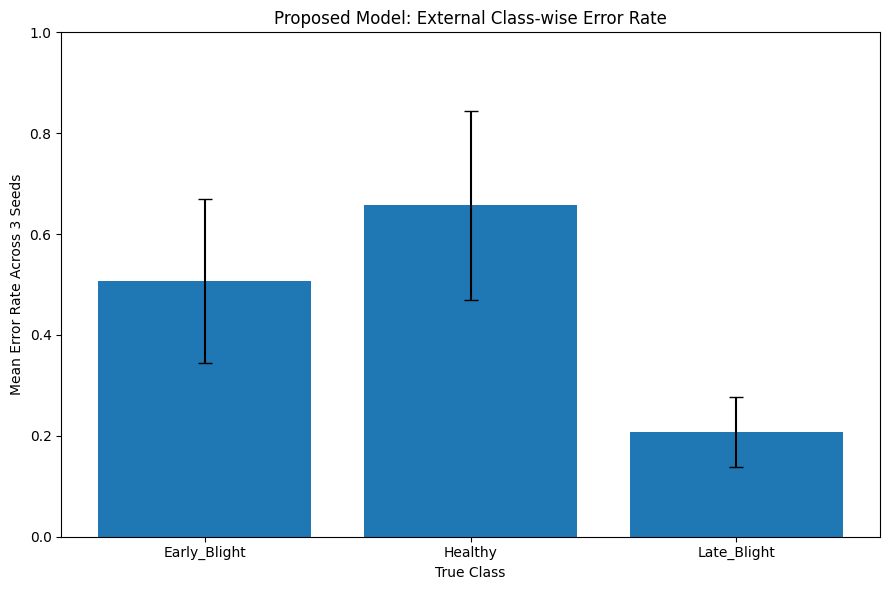

Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/error_analysis/figures/proposed_classwise_error_rate.png


In [37]:
# Cell 17: Proposed model class-wise error figure
proposed_class_error_df = (
    class_error_summary_df[
        class_error_summary_df[
            'model'
        ] == PROPOSED_MODEL
    ]
    .copy()
)

fig, axis = plt.subplots(
    figsize=(9, 6)
)

axis.bar(
    proposed_class_error_df[
        'class_name'
    ],
    proposed_class_error_df[
        'class_error_rate_mean'
    ],
    yerr=proposed_class_error_df[
        'class_error_rate_std'
    ],
    capsize=5,
)

axis.set_title(
    'Proposed Model: External Class-wise Error Rate'
)

axis.set_xlabel(
    'True Class'
)

axis.set_ylabel(
    'Mean Error Rate Across 3 Seeds'
)

axis.set_ylim(
    0,
    1,
)

plt.tight_layout()

class_error_figure_path = (
    ERROR_FIGURE_DIR
    / 'proposed_classwise_error_rate.png'
)

plt.savefig(
    class_error_figure_path,
    dpi=200,
    bbox_inches='tight',
)

plt.show()

print(
    'Saved:',
    class_error_figure_path,
)


In [38]:
# Cell 18: Build representative proposed-model misclassification table
proposed_wrong_frames = []

for seed in SEEDS:
    frame = external_prediction_frames[
        (
            PROPOSED_MODEL,
            seed,
        )
    ].copy()

    wrong_df = frame[
        ~frame[
            'is_correct'
        ]
    ].copy()

    wrong_df[
        'analysis_seed'
    ] = seed

    probability_columns = [
        column
        for column in wrong_df.columns
        if column.startswith(
            'probability_'
        )
    ]

    if probability_columns:
        wrong_df[
            'predicted_confidence'
        ] = wrong_df[
            probability_columns
        ].max(axis=1)
    else:
        wrong_df[
            'predicted_confidence'
        ] = np.nan

    proposed_wrong_frames.append(
        wrong_df
    )


proposed_wrong_all_df = pd.concat(
    proposed_wrong_frames,
    ignore_index=True,
)

representative_rows = []

for (
    true_class_name,
    predicted_class_name,
), group in proposed_wrong_all_df.groupby(
    [
        'true_class_name',
        'predicted_class_name',
    ]
):
    sorted_group = group.sort_values(
        'predicted_confidence',
        ascending=False,
        na_position='last',
    )

    representative_rows.append(
        sorted_group.iloc[0]
    )


representative_errors_df = pd.DataFrame(
    representative_rows
).reset_index(drop=True)

representative_errors_path = (
    ERROR_TABLE_DIR
    / 'proposed_representative_misclassifications.csv'
)

representative_errors_df.to_csv(
    representative_errors_path,
    index=False,
)

display_columns = [
    'analysis_seed',
    'true_class_name',
    'predicted_class_name',
    'predicted_confidence',
    'file_path',
]

available_columns = [
    column
    for column in display_columns
    if column
    in representative_errors_df.columns
]

display(
    representative_errors_df[
        available_columns
    ]
)

print(
    'Saved:',
    representative_errors_path,
)


,analysis_seed,true_class_name,predicted_class_name,predicted_confidence,file_path
0,42,Early_Blight,Healthy,0.999023,/content/drive/MyDrive/Potato_CNN_ViT_Research...
1,42,Early_Blight,Late_Blight,1.000000,/content/drive/MyDrive/Potato_CNN_ViT_Research...
2,42,Healthy,Early_Blight,1.000000,/content/drive/MyDrive/Potato_CNN_ViT_Research...
3,42,Healthy,Late_Blight,1.000000,/content/drive/MyDrive/Potato_CNN_ViT_Research...
4,42,Late_Blight,Early_Blight,1.000000,/content/drive/MyDrive/Potato_CNN_ViT_Research...
5,2026,Late_Blight,Healthy,0.985840,/content/drive/MyDrive/Potato_CNN_ViT_Research...


Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/error_analysis/tables/proposed_representative_misclassifications.csv


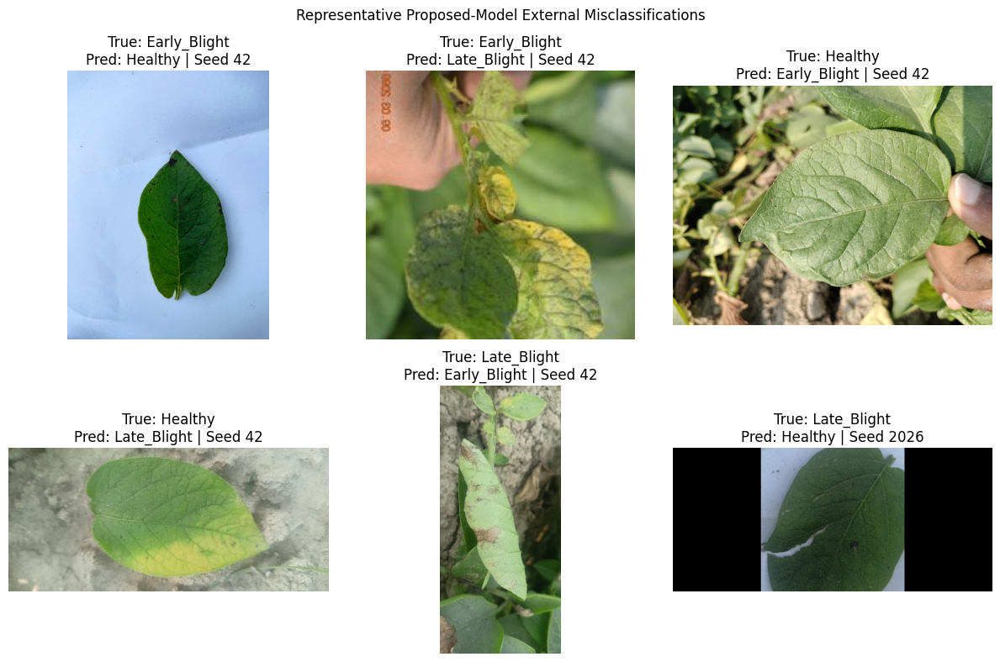

Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/error_analysis/figures/proposed_representative_misclassifications.png


In [39]:
# Cell 19: Create misclassification montage when image paths are available
def find_existing_image_path(row):
    candidate_columns = [
        'file_path',
        'evaluation_file_path',
        'original_drive_path',
    ]

    for column in candidate_columns:
        if column in row.index:
            candidate = Path(
                str(
                    row[column]
                )
            )

            if candidate.exists():
                return candidate

    return None


montage_items = []

for _, row in representative_errors_df.iterrows():
    image_path = find_existing_image_path(
        row
    )

    if image_path is not None:
        montage_items.append(
            (
                image_path,
                str(
                    row[
                        'true_class_name'
                    ]
                ),
                str(
                    row[
                        'predicted_class_name'
                    ]
                ),
                int(
                    row[
                        'analysis_seed'
                    ]
                ),
            )
        )

# Keep montage compact.
montage_items = montage_items[:6]

if montage_items:
    columns = 3
    rows = math.ceil(
        len(montage_items)
        / columns
    )

    figure, axes = plt.subplots(
        rows,
        columns,
        figsize=(
            12,
            4 * rows,
        ),
    )

    axes = np.asarray(
        axes
    ).reshape(-1)

    for axis in axes:
        axis.axis('off')

    for index, (
        image_path,
        true_name,
        predicted_name,
        seed,
    ) in enumerate(
        montage_items
    ):
        with Image.open(
            image_path
        ) as image:
            image = image.convert(
                'RGB'
            )

            axes[index].imshow(
                image
            )

        axes[index].set_title(
            f'True: {true_name}\n'
            f'Pred: {predicted_name} | '
            f'Seed {seed}'
        )

        axes[index].axis('off')

    figure.suptitle(
        'Representative Proposed-Model '
        'External Misclassifications'
    )

    plt.tight_layout()

    montage_path = (
        ERROR_FIGURE_DIR
        / 'proposed_representative_misclassifications.png'
    )

    plt.savefig(
        montage_path,
        dpi=200,
        bbox_inches='tight',
    )

    plt.show()

    print(
        'Saved:',
        montage_path,
    )

else:
    montage_path = None

    print(
        '⚠️ Saved prediction paths do not point '
        'to accessible images, so montage skipped. '
        'CSV error analysis is still complete.'
    )


In [40]:
# Cell 20: Final report
final_report_df = pd.DataFrame([
    {
        'check':
            'All 24 metric rows available',

        'passed':
            len(
                all_metrics_df
            ) >= 24,
    },

    {
        'check':
            'Four-model ablation summary saved',

        'passed':
            ablation_summary_path.exists(),
    },

    {
        'check':
            'Paper ablation table saved',

        'passed':
            paper_ablation_path.exists(),
    },

    {
        'check':
            'Attention-vs-concatenation effect saved',

        'passed':
            attention_vs_concat_path.exists(),
    },

    {
        'check':
            'All 12 external prediction CSVs loaded',

        'passed':
            bool(
                prediction_inventory_df[
                    'exists'
                ].all()
            ),
    },

    {
        'check':
            'Class-wise error analysis saved',

        'passed':
            class_error_path.exists(),
    },

    {
        'check':
            'Confusion-pair analysis saved',

        'passed':
            confusion_pair_summary_path.exists(),
    },

    {
        'check':
            'High-confidence errors saved',

        'passed':
            high_confidence_wrong_path.exists(),
    },

    {
        'check':
            'Representative errors saved',

        'passed':
            representative_errors_path.exists(),
    },
])

display(
    final_report_df
)

if final_report_df[
    'passed'
].all():
    print(
        '✅ Ablation and error analysis '
        'completed successfully.'
    )

    print(
        'Next step: '
        '14_Efficiency_and_Final_Tables.ipynb'
    )

else:
    print(
        '⚠️ Ablation / error analysis '
        'completed with warnings.'
    )


,check,passed
0,All 24 metric rows available,True
1,Four-model ablation summary saved,True
2,Paper ablation table saved,True
3,Attention-vs-concatenation effect saved,True
4,All 12 external prediction CSVs loaded,True
5,Class-wise error analysis saved,True
6,Confusion-pair analysis saved,True
7,High-confidence errors saved,True
8,Representative errors saved,True


✅ Ablation and error analysis completed successfully.
Next step: 14_Efficiency_and_Final_Tables.ipynb


---

# Part 14 — 14. Efficiency and Final Tables

**Purpose:** Benchmark model complexity and efficiency, then consolidate dataset, performance, significance, ablation, efficiency, and master result tables.

**Source notebook:** `14_Efficiency_and_Final_Tables.ipynb`

**Preservation note:** The original code cells and their saved execution outputs are retained below. Textual headings/comments are lightly normalized into English where possible without changing experiment logic.


# 14 — Efficiency and Final Tables

`13_Ablation_and_Error_Analysis.ipynb` সফলভাবে শেষ হওয়ার পর This notebook run this notebook।

## This notebook will perform the following tasks

### Model efficiency
চারটি model-এর জন্য:
- Total parameters
- Trainable parameters
- Estimated weights size (MB)
- Saved best-checkpoint size (MB)
- Approximate GFLOPs / forward pass
- Batch-1 forward latency
- Throughput (images/second)
- GPU peak memory, GPU থাকলে
- Benchmark hardware/device record

### Paper-ready final tables
আগের saved results এক জায়গায় এনে will create:
- Dataset split table
- Three-seed internal results
- Three-seed external results
- Generalization-gap table
- Statistical significance summary
- Ablation table
- Efficiency table
- Master final-result table

## Important

- This notebook **model retrain করবে না**।
- পুরো PLDD-UP dataset আবার inference করবে না।
- শুধু seed-42 checkpoint load করে short synthetic benchmark run this notebook।
- Notebook 10-এর `evaluation_seconds` কে pure inference latency হিসেবে will not be used, কারণ সেখানে image loading/preprocessing-ও ছিল।
- FLOPs library কিছু Transformer operation পুরোপুরি count না করলে result-কে `approximate` হিসেবে report করা হবে।


In [1]:
# Cell 1: Mount Drive and install lightweight analysis packages
from google.colab import drive

drive.mount('/content/drive', force_remount=True)

!pip -q install timm fvcore


Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 3.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 1.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.9/65.9 kB 5.4 MB/s eta 0:00:00


In [2]:
# Cell 2: Imports and settings
from pathlib import Path
from datetime import datetime
import json
import math
import platform
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn
from torchvision.models import efficientnet_b0

import timm

from fvcore.nn import FlopCountAnalysis

SEED = 42

CLASS_NAMES = [
    'Early_Blight',
    'Late_Blight',
    'Healthy',
]

MODEL_ORDER = [
    'CNN_EfficientNet_B0',
    'ViT_DeiT_Tiny',
    'CNN_ViT_Concatenation',
    'Attention_Guided_CNN_ViT',
]

MODEL_LABELS = {
    'CNN_EfficientNet_B0':
        'CNN only (EfficientNet-B0)',

    'ViT_DeiT_Tiny':
        'ViT only (DeiT-Tiny)',

    'CNN_ViT_Concatenation':
        'CNN + ViT Concatenation',

    'Attention_Guided_CNN_ViT':
        'CNN + ViT + Attention',
}

IMAGE_SIZE = 224

DEVICE = torch.device(
    'cuda' if torch.cuda.is_available()
    else 'cpu'
)

if DEVICE.type == 'cuda':
    WARMUP_ITERATIONS = 20
    BENCHMARK_ITERATIONS = 100
else:
    WARMUP_ITERATIONS = 3
    BENCHMARK_ITERATIONS = 10

print('PyTorch:', torch.__version__)
print('timm:', timm.__version__)
print('Device:', DEVICE)
print('Warmup iterations:', WARMUP_ITERATIONS)
print('Benchmark iterations:', BENCHMARK_ITERATIONS)

if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
else:
    print(
        'ℹ️ GPU নেই। CPU benchmark হবে। '
        'Paper-এ hardware name অবশ্যই report করবে।'
    )


PyTorch: 2.11.0+cu128
timm: 1.0.28
Device: cuda
Warmup iterations: 20
Benchmark iterations: 100
GPU: Tesla T4


In [3]:
# Cell 3: Locate project folders
MY_DRIVE = Path('/content/drive/MyDrive')

standard_project = (
    MY_DRIVE / 'Potato_CNN_ViT_Research'
)

if standard_project.is_dir():
    PROJECT_ROOT = standard_project
else:
    matches = [
        path
        for path in MY_DRIVE.rglob(
            'Potato_CNN_ViT_Research'
        )
        if path.is_dir()
    ]

    if not matches:
        raise FileNotFoundError(
            'Potato_CNN_ViT_Research folder My Drive-এ পাওয়া যায়নি।'
        )

    PROJECT_ROOT = matches[0]

DATA_DIR = PROJECT_ROOT / '02_data'
SPLITS_DIR = DATA_DIR / 'splits'
CHECKPOINT_ROOT = PROJECT_ROOT / '04_checkpoints'

RESULTS_ROOT = PROJECT_ROOT / '05_results'
METRICS_DIR = RESULTS_ROOT / 'metrics'
STATISTICS_DIR = RESULTS_ROOT / 'statistical_analysis'
ABLATION_DIR = RESULTS_ROOT / 'ablation'

EFFICIENCY_DIR = RESULTS_ROOT / 'efficiency'
FINAL_TABLES_DIR = RESULTS_ROOT / 'final_tables'
FINAL_FIGURES_DIR = RESULTS_ROOT / 'final_figures'

for folder in [
    EFFICIENCY_DIR,
    FINAL_TABLES_DIR,
    FINAL_FIGURES_DIR,
]:
    folder.mkdir(
        parents=True,
        exist_ok=True,
    )

print('PROJECT_ROOT:', PROJECT_ROOT)
print('EFFICIENCY_DIR:', EFFICIENCY_DIR)
print('FINAL_TABLES_DIR:', FINAL_TABLES_DIR)


PROJECT_ROOT: /content/drive/MyDrive/Potato_CNN_ViT_Research
EFFICIENCY_DIR: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/efficiency
FINAL_TABLES_DIR: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/final_tables


In [4]:
# Cell 4: Define model architectures used in previous notebooks
class CNNViTConcatenationModel(nn.Module):
    def __init__(
        self,
        num_classes,
        vit_model_name,
        hidden_dim=512,
        dropout=0.35,
    ):
        super().__init__()

        cnn_model = efficientnet_b0(
            weights=None
        )

        self.cnn_features = (
            cnn_model.features
        )

        self.cnn_pool = (
            nn.AdaptiveAvgPool2d(1)
        )

        self.cnn_feature_dim = (
            cnn_model.classifier[1]
            .in_features
        )

        self.vit_backbone = (
            timm.create_model(
                vit_model_name,
                pretrained=False,
                num_classes=0,
                global_pool='avg',
            )
        )

        self.vit_model_name = (
            vit_model_name
        )

        self.vit_feature_dim = (
            self.vit_backbone.num_features
        )

        self.concatenated_dim = (
            self.cnn_feature_dim
            + self.vit_feature_dim
        )

        self.classifier = nn.Sequential(
            nn.LayerNorm(
                self.concatenated_dim
            ),
            nn.Dropout(
                p=dropout
            ),
            nn.Linear(
                self.concatenated_dim,
                hidden_dim,
            ),
            nn.GELU(),
            nn.Dropout(
                p=dropout
            ),
            nn.Linear(
                hidden_dim,
                num_classes,
            ),
        )

    def forward(self, images):
        cnn_map = self.cnn_features(
            images
        )

        cnn_features = (
            self.cnn_pool(
                cnn_map
            ).flatten(1)
        )

        vit_features = (
            self.vit_backbone(
                images
            )
        )

        fused = torch.cat(
            [
                cnn_features,
                vit_features,
            ],
            dim=1,
        )

        return self.classifier(
            fused
        )


class AttentionGuidedCNNViT(nn.Module):
    def __init__(
        self,
        num_classes,
        vit_model_name,
        projection_dim=256,
        classifier_hidden_dim=256,
        dropout=0.35,
    ):
        super().__init__()

        cnn_model = efficientnet_b0(
            weights=None
        )

        self.cnn_features = (
            cnn_model.features
        )

        self.cnn_pool = (
            nn.AdaptiveAvgPool2d(1)
        )

        self.cnn_feature_dim = (
            cnn_model.classifier[1]
            .in_features
        )

        self.vit_backbone = (
            timm.create_model(
                vit_model_name,
                pretrained=False,
                num_classes=0,
                global_pool='avg',
            )
        )

        self.vit_model_name = (
            vit_model_name
        )

        self.vit_feature_dim = (
            self.vit_backbone.num_features
        )

        self.cnn_projection = nn.Sequential(
            nn.Linear(
                self.cnn_feature_dim,
                projection_dim,
            ),
            nn.LayerNorm(
                projection_dim
            ),
            nn.GELU(),
            nn.Dropout(
                p=dropout
            ),
        )

        self.vit_projection = nn.Sequential(
            nn.Linear(
                self.vit_feature_dim,
                projection_dim,
            ),
            nn.LayerNorm(
                projection_dim
            ),
            nn.GELU(),
            nn.Dropout(
                p=dropout
            ),
        )

        self.attention_gate = nn.Sequential(
            nn.Linear(
                projection_dim * 2,
                projection_dim,
            ),
            nn.GELU(),
            nn.Dropout(
                p=dropout
            ),
            nn.Linear(
                projection_dim,
                2,
            ),
        )

        self.classifier = nn.Sequential(
            nn.LayerNorm(
                projection_dim
            ),
            nn.Dropout(
                p=dropout
            ),
            nn.Linear(
                projection_dim,
                classifier_hidden_dim,
            ),
            nn.GELU(),
            nn.Dropout(
                p=dropout
            ),
            nn.Linear(
                classifier_hidden_dim,
                num_classes,
            ),
        )

    def forward(self, images):
        cnn_map = self.cnn_features(
            images
        )

        cnn_raw = (
            self.cnn_pool(
                cnn_map
            ).flatten(1)
        )

        vit_raw = (
            self.vit_backbone(
                images
            )
        )

        cnn_projected = (
            self.cnn_projection(
                cnn_raw
            )
        )

        vit_projected = (
            self.vit_projection(
                vit_raw
            )
        )

        joint = torch.cat(
            [
                cnn_projected,
                vit_projected,
            ],
            dim=1,
        )

        attention_weights = (
            torch.softmax(
                self.attention_gate(
                    joint
                ),
                dim=1,
            )
        )

        fused = (
            attention_weights[:, 0:1]
            * cnn_projected
            +
            attention_weights[:, 1:2]
            * vit_projected
        )

        return self.classifier(
            fused
        )


def safe_torch_load(path):
    try:
        return torch.load(
            path,
            map_location='cpu',
            weights_only=False,
        )
    except TypeError:
        return torch.load(
            path,
            map_location='cpu',
        )


In [5]:
# Cell 5: Checkpoint map and model builder
CHECKPOINT_PATHS = {
    'CNN_EfficientNet_B0': (
        CHECKPOINT_ROOT
        / 'cnn'
        / 'efficientnet_b0_best_seed42.pth'
    ),

    'ViT_DeiT_Tiny': (
        CHECKPOINT_ROOT
        / 'vit'
        / 'deit_tiny_best_seed42.pth'
    ),

    'CNN_ViT_Concatenation': (
        CHECKPOINT_ROOT
        / 'concat'
        / 'cnn_vit_concat_best_seed42.pth'
    ),

    'Attention_Guided_CNN_ViT': (
        CHECKPOINT_ROOT
        / 'attention'
        / 'attention_cnn_vit_best_seed42.pth'
    ),
}


def build_model_from_checkpoint(
    model_key,
    checkpoint,
):
    config = checkpoint.get(
        'config',
        {},
    )

    if model_key == 'CNN_EfficientNet_B0':
        model = efficientnet_b0(
            weights=None
        )

        dropout = float(
            config.get(
                'dropout',
                0.30,
            )
        )

        in_features = (
            model.classifier[1]
            .in_features
        )

        model.classifier = nn.Sequential(
            nn.Dropout(
                p=dropout
            ),
            nn.Linear(
                in_features,
                len(CLASS_NAMES),
            ),
        )

        return model


    if model_key == 'ViT_DeiT_Tiny':
        model_name = checkpoint.get(
            'model_name',
            'deit_tiny_patch16_224.fb_in1k',
        )

        dropout = float(
            config.get(
                'dropout',
                0.30,
            )
        )

        return timm.create_model(
            model_name,
            pretrained=False,
            num_classes=len(CLASS_NAMES),
            drop_rate=dropout,
        )


    if model_key == 'CNN_ViT_Concatenation':
        vit_model_name = checkpoint.get(
            'vit_branch',
            'deit_tiny_patch16_224.fb_in1k',
        )

        return CNNViTConcatenationModel(
            num_classes=len(CLASS_NAMES),
            vit_model_name=vit_model_name,
            hidden_dim=int(
                config.get(
                    'fusion_hidden_dim',
                    512,
                )
            ),
            dropout=float(
                config.get(
                    'dropout',
                    0.35,
                )
            ),
        )


    if model_key == 'Attention_Guided_CNN_ViT':
        vit_model_name = checkpoint.get(
            'vit_branch',
            'deit_tiny_patch16_224.fb_in1k',
        )

        return AttentionGuidedCNNViT(
            num_classes=len(CLASS_NAMES),
            vit_model_name=vit_model_name,
            projection_dim=int(
                config.get(
                    'projection_dim',
                    256,
                )
            ),
            classifier_hidden_dim=int(
                config.get(
                    'classifier_hidden_dim',
                    256,
                )
            ),
            dropout=float(
                config.get(
                    'dropout',
                    0.35,
                )
            ),
        )

    raise ValueError(
        f'Unknown model: {model_key}'
    )


checkpoint_inventory_rows = []

for model_key, path in CHECKPOINT_PATHS.items():
    checkpoint_inventory_rows.append({
        'model':
            model_key,
        'checkpoint_path':
            str(path),
        'exists':
            path.exists(),
    })

checkpoint_inventory_df = pd.DataFrame(
    checkpoint_inventory_rows
)

display(checkpoint_inventory_df)

if not checkpoint_inventory_df[
    'exists'
].all():
    raise FileNotFoundError(
        'এক বা একাধিক seed-42 best checkpoint missing।'
    )

print('✅ All four seed-42 checkpoints found.')


,model,checkpoint_path,exists
0,CNN_EfficientNet_B0,/content/drive/MyDrive/Potato_CNN_ViT_Research...,True
1,ViT_DeiT_Tiny,/content/drive/MyDrive/Potato_CNN_ViT_Research...,True
2,CNN_ViT_Concatenation,/content/drive/MyDrive/Potato_CNN_ViT_Research...,True
3,Attention_Guided_CNN_ViT,/content/drive/MyDrive/Potato_CNN_ViT_Research...,True


✅ All four seed-42 checkpoints found.


In [6]:
# Cell 6: Benchmark helpers
def state_dict_size_mb(
    state_dict,
):
    total_bytes = 0

    for tensor in state_dict.values():
        if torch.is_tensor(tensor):
            total_bytes += (
                tensor.numel()
                * tensor.element_size()
            )

    return (
        total_bytes
        / (1024 ** 2)
    )


def synchronize_if_needed():
    if DEVICE.type == 'cuda':
        torch.cuda.synchronize()


def benchmark_forward(
    model,
):
    model.eval()

    dummy = torch.randn(
        1,
        3,
        IMAGE_SIZE,
        IMAGE_SIZE,
        device=DEVICE,
    )

    if DEVICE.type == 'cuda':
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

    with torch.no_grad():
        for _ in range(
            WARMUP_ITERATIONS
        ):
            _ = model(dummy)

        synchronize_if_needed()

        latencies_ms = []

        for _ in range(
            BENCHMARK_ITERATIONS
        ):
            start = time.perf_counter()

            _ = model(dummy)

            synchronize_if_needed()

            end = time.perf_counter()

            latencies_ms.append(
                (end - start)
                * 1000
            )

    mean_latency_ms = float(
        np.mean(latencies_ms)
    )

    std_latency_ms = float(
        np.std(
            latencies_ms,
            ddof=1,
        )
        if len(latencies_ms) > 1
        else 0.0
    )

    throughput = float(
        1000.0
        / mean_latency_ms
    )

    if DEVICE.type == 'cuda':
        peak_memory_mb = float(
            torch.cuda.max_memory_allocated()
            / (1024 ** 2)
        )
    else:
        peak_memory_mb = np.nan

    return {
        'batch1_latency_ms_mean':
            mean_latency_ms,
        'batch1_latency_ms_std':
            std_latency_ms,
        'batch1_throughput_images_per_second':
            throughput,
        'gpu_peak_memory_mb':
            peak_memory_mb,
    }


def estimate_gflops(
    model,
):
    dummy_cpu = torch.randn(
        1,
        3,
        IMAGE_SIZE,
        IMAGE_SIZE,
    )

    model_cpu = model.to('cpu')
    model_cpu.eval()

    try:
        with warnings.catch_warnings():
            warnings.simplefilter(
                'ignore'
            )

            flop_analysis = (
                FlopCountAnalysis(
                    model_cpu,
                    dummy_cpu,
                )
            )

            flop_analysis.unsupported_ops_warnings(
                False
            )

            flop_analysis.uncalled_modules_warnings(
                False
            )

            total_flops = float(
                flop_analysis.total()
            )

        return (
            total_flops / 1e9
        )

    except Exception as error:
        print(
            'FLOPs estimate failed:',
            error,
        )

        return np.nan


In [7]:
# Cell 7: Run short efficiency benchmark
efficiency_rows = []

for model_key in MODEL_ORDER:
    checkpoint_path = (
        CHECKPOINT_PATHS[
            model_key
        ]
    )

    print('\n' + '=' * 80)
    print('Model:', model_key)

    checkpoint = safe_torch_load(
        checkpoint_path
    )

    model = build_model_from_checkpoint(
        model_key,
        checkpoint,
    )

    model.load_state_dict(
        checkpoint[
            'model_state_dict'
        ]
    )

    total_parameters = sum(
        parameter.numel()
        for parameter in model.parameters()
    )

    trainable_parameters = sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )

    model_weights_mb = (
        state_dict_size_mb(
            model.state_dict()
        )
    )

    checkpoint_size_mb = (
        checkpoint_path.stat().st_size
        / (1024 ** 2)
    )

    # FLOPs first on CPU
    approximate_gflops = (
        estimate_gflops(
            model
        )
    )

    # Then benchmark on selected device
    model = model.to(DEVICE)

    benchmark_metrics = (
        benchmark_forward(
            model
        )
    )

    efficiency_rows.append({
        'model':
            model_key,

        'model_label':
            MODEL_LABELS[
                model_key
            ],

        'seed':
            SEED,

        'total_parameters':
            total_parameters,

        'trainable_parameters':
            trainable_parameters,

        'estimated_weights_size_mb':
            model_weights_mb,

        'full_checkpoint_size_mb':
            checkpoint_size_mb,

        'approximate_gflops_batch1':
            approximate_gflops,

        **benchmark_metrics,

        'benchmark_device':
            str(DEVICE),

        'benchmark_gpu':
            (
                torch.cuda.get_device_name(0)
                if torch.cuda.is_available()
                else ''
            ),

        'warmup_iterations':
            WARMUP_ITERATIONS,

        'benchmark_iterations':
            BENCHMARK_ITERATIONS,
    })

    del model
    del checkpoint

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


efficiency_df = pd.DataFrame(
    efficiency_rows
)

efficiency_path = (
    EFFICIENCY_DIR
    / 'model_efficiency_seed42.csv'
)

efficiency_df.to_csv(
    efficiency_path,
    index=False,
)

display(
    efficiency_df.round(4)
)

print(
    'Saved:',
    efficiency_path,
)



Model: CNN_EfficientNet_B0

Model: ViT_DeiT_Tiny

Model: CNN_ViT_Concatenation

Model: Attention_Guided_CNN_ViT


,model,model_label,seed,total_parameters,trainable_parameters,estimated_weights_size_mb,full_checkpoint_size_mb,approximate_gflops_batch1,batch1_latency_ms_mean,batch1_latency_ms_std,batch1_throughput_images_per_second,gpu_peak_memory_mb,benchmark_device,benchmark_gpu,warmup_iterations,benchmark_iterations
0,CNN_EfficientNet_B0,CNN only (EfficientNet-B0),42,4011391,4011391,15.4629,46.3824,0.4004,19.3976,8.4303,51.5528,35.1914,cuda,Tesla T4,20,100
1,ViT_DeiT_Tiny,ViT only (DeiT-Tiny),42,5524995,5524995,21.0762,63.4152,1.0794,5.5128,1.0055,181.3961,32.5303,cuda,Tesla T4,20,100
2,CNN_ViT_Concatenation,CNN + ViT Concatenation,42,10290623,10290623,39.4163,118.4414,1.4803,13.3020,1.5107,75.1764,59.1670,cuda,Tesla T4,20,100
3,Attention_Guided_CNN_ViT,CNN + ViT + Attention,42,10109249,10109249,38.7244,116.3853,1.4802,13.5879,1.8105,73.5947,58.4751,cuda,Tesla T4,20,100


Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/efficiency/model_efficiency_seed42.csv


In [8]:
# Cell 8: Save benchmark environment metadata
environment_info = {
    'created_at':
        datetime.now().isoformat(),

    'python_version':
        platform.python_version(),

    'platform':
        platform.platform(),

    'pytorch_version':
        torch.__version__,

    'timm_version':
        timm.__version__,

    'device':
        str(DEVICE),

    'gpu_name':
        (
            torch.cuda.get_device_name(0)
            if torch.cuda.is_available()
            else None
        ),

    'image_size':
        IMAGE_SIZE,

    'benchmark_batch_size':
        1,

    'warmup_iterations':
        WARMUP_ITERATIONS,

    'benchmark_iterations':
        BENCHMARK_ITERATIONS,

    'latency_definition':
        (
            'Model forward-pass only on synthetic '
            '224x224 RGB tensor; excludes disk I/O '
            'and image preprocessing.'
        ),

    'flops_note':
        (
            'GFLOPs are approximate. fvcore may not '
            'count every Transformer operation.'
        ),
}

environment_path = (
    EFFICIENCY_DIR
    / 'benchmark_environment.json'
)

with environment_path.open(
    'w',
    encoding='utf-8',
) as file_handle:
    json.dump(
        environment_info,
        file_handle,
        indent=2,
        ensure_ascii=False,
    )

print('Saved:', environment_path)
print(json.dumps(
    environment_info,
    indent=2,
    ensure_ascii=False,
))


Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/efficiency/benchmark_environment.json
{
  "created_at": "2026-08-07T14:53:16.738048",
  "python_version": "3.12.13",
  "platform": "Linux-6.6.122+-x86_64-with-glibc2.35",
  "pytorch_version": "2.11.0+cu128",
  "timm_version": "1.0.28",
  "device": "cuda",
  "gpu_name": "Tesla T4",
  "image_size": 224,
  "benchmark_batch_size": 1,
  "warmup_iterations": 20,
  "benchmark_iterations": 100,
  "latency_definition": "Model forward-pass only on synthetic 224x224 RGB tensor; excludes disk I/O and image preprocessing.",
  "flops_note": "GFLOPs are approximate. fvcore may not count every Transformer operation."
}


In [9]:
# Cell 9: Dataset split table
split_rows = []

for split_name, file_name in [
    ('Train', 'train.csv'),
    ('Validation', 'val.csv'),
    ('Internal Test', 'internal_test.csv'),
    ('External Test', 'external_test.csv'),
]:
    path = (
        SPLITS_DIR
        / file_name
    )

    if not path.exists():
        raise FileNotFoundError(
            path
        )

    frame = pd.read_csv(
        path
    )

    for class_name in CLASS_NAMES:
        class_count = int(
            (
                frame[
                    'unified_class'
                ] == class_name
            ).sum()
        )

        split_rows.append({
            'split':
                split_name,

            'class_name':
                class_name,

            'image_count':
                class_count,
        })


dataset_split_long_df = pd.DataFrame(
    split_rows
)

dataset_split_table_df = (
    dataset_split_long_df.pivot(
        index='split',
        columns='class_name',
        values='image_count',
    )
    .fillna(0)
    .astype(int)
    .reset_index()
)

dataset_split_table_df[
    'Total'
] = dataset_split_table_df[
    CLASS_NAMES
].sum(axis=1)

dataset_split_path = (
    FINAL_TABLES_DIR
    / 'table_01_dataset_split_distribution.csv'
)

dataset_split_table_df.to_csv(
    dataset_split_path,
    index=False,
)

display(
    dataset_split_table_df
)

print(
    'Saved:',
    dataset_split_path,
)


class_name,split,Early_Blight,Healthy,Late_Blight,Total
0,External Test,4743,4448,6069,15260
1,Internal Test,150,23,150,323
2,Train,700,106,700,1506
3,Validation,150,23,150,323


Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/final_tables/table_01_dataset_split_distribution.csv


In [10]:
# Cell 10: Load three-seed metrics and build internal/external paper tables
all_metrics_path = (
    METRICS_DIR
    / 'all_available_seed_internal_external_metrics.csv'
)

if not all_metrics_path.exists():
    raise FileNotFoundError(
        all_metrics_path
    )

all_metrics_df = pd.read_csv(
    all_metrics_path
)

three_seed_summary_df = (
    all_metrics_df.groupby(
        [
            'model',
            'dataset',
        ]
    )
    .agg(
        seed_count=(
            'seed',
            'nunique',
        ),

        accuracy_mean=(
            'accuracy',
            'mean',
        ),

        accuracy_std=(
            'accuracy',
            'std',
        ),

        macro_precision_mean=(
            'macro_precision',
            'mean',
        ),

        macro_precision_std=(
            'macro_precision',
            'std',
        ),

        macro_recall_mean=(
            'macro_recall',
            'mean',
        ),

        macro_recall_std=(
            'macro_recall',
            'std',
        ),

        macro_f1_mean=(
            'macro_f1',
            'mean',
        ),

        macro_f1_std=(
            'macro_f1',
            'std',
        ),
    )
    .reset_index()
)

three_seed_summary_df[
    'model_label'
] = three_seed_summary_df[
    'model'
].map(MODEL_LABELS)


def make_paper_result_table(
    dataset_name,
):
    frame = (
        three_seed_summary_df[
            three_seed_summary_df[
                'dataset'
            ] == dataset_name
        ]
        .copy()
    )

    frame[
        'Accuracy (mean ± std)'
    ] = frame.apply(
        lambda row:
            f'{row["accuracy_mean"]:.4f} '
            f'± {row["accuracy_std"]:.4f}',
        axis=1,
    )

    frame[
        'Precision (mean ± std)'
    ] = frame.apply(
        lambda row:
            f'{row["macro_precision_mean"]:.4f} '
            f'± {row["macro_precision_std"]:.4f}',
        axis=1,
    )

    frame[
        'Recall (mean ± std)'
    ] = frame.apply(
        lambda row:
            f'{row["macro_recall_mean"]:.4f} '
            f'± {row["macro_recall_std"]:.4f}',
        axis=1,
    )

    frame[
        'Macro F1 (mean ± std)'
    ] = frame.apply(
        lambda row:
            f'{row["macro_f1_mean"]:.4f} '
            f'± {row["macro_f1_std"]:.4f}',
        axis=1,
    )

    frame = frame[
        [
            'model_label',
            'Accuracy (mean ± std)',
            'Precision (mean ± std)',
            'Recall (mean ± std)',
            'Macro F1 (mean ± std)',
        ]
    ].rename(
        columns={
            'model_label':
                'Model'
        }
    )

    return frame


internal_table_df = (
    make_paper_result_table(
        'internal_test'
    )
)

external_table_df = (
    make_paper_result_table(
        'external_test'
    )
)

internal_table_path = (
    FINAL_TABLES_DIR
    / 'table_02_internal_three_seed_results.csv'
)

external_table_path = (
    FINAL_TABLES_DIR
    / 'table_03_external_three_seed_results.csv'
)

internal_table_df.to_csv(
    internal_table_path,
    index=False,
)

external_table_df.to_csv(
    external_table_path,
    index=False,
)

print('Internal results:')
display(internal_table_df)

print('External results:')
display(external_table_df)

print('Saved:', internal_table_path)
print('Saved:', external_table_path)


Internal results:


,Model,Accuracy (mean ± std),Precision (mean ± std),Recall (mean ± std),Macro F1 (mean ± std)
1,CNN + ViT + Attention,0.9990 ± 0.0018,0.9993 ± 0.0013,0.9993 ± 0.0013,0.9993 ± 0.0013
3,CNN only (EfficientNet-B0),1.0000 ± 0.0000,1.0000 ± 0.0000,1.0000 ± 0.0000,1.0000 ± 0.0000
5,CNN + ViT Concatenation,1.0000 ± 0.0000,1.0000 ± 0.0000,1.0000 ± 0.0000,1.0000 ± 0.0000
7,ViT only (DeiT-Tiny),1.0000 ± 0.0000,1.0000 ± 0.0000,1.0000 ± 0.0000,1.0000 ± 0.0000


External results:


,Model,Accuracy (mean ± std),Precision (mean ± std),Recall (mean ± std),Macro F1 (mean ± std)
0,CNN + ViT + Attention,0.5685 ± 0.0578,0.6677 ± 0.0293,0.5430 ± 0.0634,0.5374 ± 0.0838
2,CNN only (EfficientNet-B0),0.4999 ± 0.0378,0.5626 ± 0.0209,0.5275 ± 0.0309,0.4866 ± 0.0506
4,CNN + ViT Concatenation,0.6157 ± 0.0799,0.6884 ± 0.0378,0.5996 ± 0.0973,0.5903 ± 0.1264
6,ViT only (DeiT-Tiny),0.6352 ± 0.0215,0.7006 ± 0.0032,0.6155 ± 0.0287,0.6238 ± 0.0311


Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/final_tables/table_02_internal_three_seed_results.csv
Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/final_tables/table_03_external_three_seed_results.csv


In [11]:
# Cell 11: Generalization-gap table
internal_numeric = (
    three_seed_summary_df[
        three_seed_summary_df[
            'dataset'
        ] == 'internal_test'
    ]
    .set_index('model')
)

external_numeric = (
    three_seed_summary_df[
        three_seed_summary_df[
            'dataset'
        ] == 'external_test'
    ]
    .set_index('model')
)

gap_rows = []

for model_key in MODEL_ORDER:
    internal_row = (
        internal_numeric.loc[
            model_key
        ]
    )

    external_row = (
        external_numeric.loc[
            model_key
        ]
    )

    gap_rows.append({
        'Model':
            MODEL_LABELS[
                model_key
            ],

        'Internal Accuracy':
            internal_row[
                'accuracy_mean'
            ],

        'External Accuracy':
            external_row[
                'accuracy_mean'
            ],

        'Accuracy Drop':
            (
                internal_row[
                    'accuracy_mean'
                ]
                -
                external_row[
                    'accuracy_mean'
                ]
            ),

        'Internal Macro F1':
            internal_row[
                'macro_f1_mean'
            ],

        'External Macro F1':
            external_row[
                'macro_f1_mean'
            ],

        'Macro F1 Drop':
            (
                internal_row[
                    'macro_f1_mean'
                ]
                -
                external_row[
                    'macro_f1_mean'
                ]
            ),
    })


gap_table_df = pd.DataFrame(
    gap_rows
)

gap_table_path = (
    FINAL_TABLES_DIR
    / 'table_04_generalization_gap.csv'
)

gap_table_df.to_csv(
    gap_table_path,
    index=False,
)

display(
    gap_table_df.round(4)
)

print(
    'Saved:',
    gap_table_path,
)


,Model,Internal Accuracy,External Accuracy,Accuracy Drop,Internal Macro F1,External Macro F1,Macro F1 Drop
0,CNN only (EfficientNet-B0),1.000,0.4999,0.5001,1.0000,0.4866,0.5134
1,ViT only (DeiT-Tiny),1.000,0.6352,0.3648,1.0000,0.6238,0.3762
2,CNN + ViT Concatenation,1.000,0.6157,0.3843,1.0000,0.5903,0.4097
3,CNN + ViT + Attention,0.999,0.5685,0.4305,0.9993,0.5374,0.4619


Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/final_tables/table_04_generalization_gap.csv


In [12]:
# Cell 12: Statistical significance paper table
statistical_path = (
    STATISTICS_DIR
    / 'proposed_vs_baselines_three_seed_summary.csv'
)

per_seed_stat_path = (
    STATISTICS_DIR
    / 'proposed_vs_baselines_per_seed.csv'
)

if not statistical_path.exists():
    raise FileNotFoundError(
        statistical_path
    )

if not per_seed_stat_path.exists():
    raise FileNotFoundError(
        per_seed_stat_path
    )

stat_summary_df = pd.read_csv(
    statistical_path
)

per_seed_stat_df = pd.read_csv(
    per_seed_stat_path
)

external_stat_df = (
    stat_summary_df[
        stat_summary_df[
            'dataset'
        ] == 'external_test'
    ]
    .copy()
)

external_pvalue_summary = (
    per_seed_stat_df[
        per_seed_stat_df[
            'dataset'
        ] == 'external_test'
    ]
    .groupby(
        'baseline_model'
    )
    .agg(
        minimum_mcnemar_p_value=(
            'mcnemar_p_value',
            'min',
        ),

        maximum_mcnemar_p_value=(
            'mcnemar_p_value',
            'max',
        ),

        significant_seed_count=(
            'significant_at_0_05',
            'sum',
        ),
    )
    .reset_index()
)

statistical_paper_df = (
    external_stat_df.merge(
        external_pvalue_summary,
        on='baseline_model',
        how='left',
        suffixes=(
            '',
            '_per_seed',
        ),
    )
)

statistical_paper_df[
    'Baseline'
] = statistical_paper_df[
    'baseline_model'
].map(MODEL_LABELS)

selected_columns = [
    'Baseline',
    'accuracy_difference_mean',
    'accuracy_difference_std',
    'macro_f1_difference_mean',
    'macro_f1_difference_std',
    'minimum_mcnemar_p_value',
    'maximum_mcnemar_p_value',
    'significant_seed_count_per_seed',
]

available_columns = [
    column
    for column in selected_columns
    if column
    in statistical_paper_df.columns
]

statistical_paper_df = (
    statistical_paper_df[
        available_columns
    ]
)

statistical_table_path = (
    FINAL_TABLES_DIR
    / 'table_05_statistical_comparison.csv'
)

statistical_paper_df.to_csv(
    statistical_table_path,
    index=False,
)

display(
    statistical_paper_df.round(6)
)

print(
    'Saved:',
    statistical_table_path,
)


,Baseline,accuracy_difference_mean,accuracy_difference_std,macro_f1_difference_mean,macro_f1_difference_std,minimum_mcnemar_p_value,maximum_mcnemar_p_value,significant_seed_count_per_seed
0,CNN only (EfficientNet-B0),0.068611,0.028917,0.050839,0.036241,0.0,0.000000,3
1,CNN + ViT Concatenation,-0.047248,0.128076,-0.052908,0.191472,0.0,0.000000,3
2,ViT only (DeiT-Tiny),-0.066710,0.061115,-0.086355,0.084028,0.0,0.590687,2


Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/final_tables/table_05_statistical_comparison.csv


In [13]:
# Cell 13: Copy/standardize ablation table into final tables
ablation_source_path = (
    ABLATION_DIR
    / 'paper_ablation_table.csv'
)

if not ablation_source_path.exists():
    raise FileNotFoundError(
        ablation_source_path
    )

ablation_df = pd.read_csv(
    ablation_source_path
)

final_ablation_path = (
    FINAL_TABLES_DIR
    / 'table_06_ablation_study.csv'
)

ablation_df.to_csv(
    final_ablation_path,
    index=False,
)

display(
    ablation_df.round(4)
)

print(
    'Saved:',
    final_ablation_path,
)


,model,cnn_branch,vit_branch,fusion,internal_accuracy_mean,internal_accuracy_std,internal_macro_f1_mean,internal_macro_f1_std,external_accuracy_mean,external_accuracy_std,external_macro_f1_mean,external_macro_f1_std,macro_f1_generalization_drop
0,CNN only (EfficientNet-B0),Yes,No,NaN,1.000,0.0000,1.0000,0.0000,0.4999,0.0378,0.4866,0.0506,0.5134
1,ViT only (DeiT-Tiny),No,Yes,NaN,1.000,0.0000,1.0000,0.0000,0.6352,0.0215,0.6238,0.0311,0.3762
2,CNN + ViT Concatenation,Yes,Yes,Concatenation,1.000,0.0000,1.0000,0.0000,0.6157,0.0799,0.5903,0.1264,0.4097
3,CNN + ViT + Attention,Yes,Yes,Attention,0.999,0.0018,0.9993,0.0013,0.5685,0.0578,0.5374,0.0838,0.4619


Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/final_tables/table_06_ablation_study.csv


In [14]:
# Cell 14: Paper-ready efficiency table
efficiency_paper_df = (
    efficiency_df[
        [
            'model_label',
            'total_parameters',
            'estimated_weights_size_mb',
            'approximate_gflops_batch1',
            'batch1_latency_ms_mean',
            'batch1_latency_ms_std',
            'batch1_throughput_images_per_second',
            'gpu_peak_memory_mb',
            'benchmark_device',
            'benchmark_gpu',
        ]
    ]
    .copy()
)

efficiency_paper_df = (
    efficiency_paper_df.rename(
        columns={
            'model_label':
                'Model',

            'total_parameters':
                'Parameters',

            'estimated_weights_size_mb':
                'Weights Size (MB)',

            'approximate_gflops_batch1':
                'Approx. GFLOPs',

            'batch1_latency_ms_mean':
                'Latency Mean (ms)',

            'batch1_latency_ms_std':
                'Latency Std (ms)',

            'batch1_throughput_images_per_second':
                'Throughput (images/s)',

            'gpu_peak_memory_mb':
                'GPU Peak Memory (MB)',

            'benchmark_device':
                'Device',

            'benchmark_gpu':
                'GPU',
        }
    )
)

efficiency_table_path = (
    FINAL_TABLES_DIR
    / 'table_07_efficiency_comparison.csv'
)

efficiency_paper_df.to_csv(
    efficiency_table_path,
    index=False,
)

display(
    efficiency_paper_df.round(4)
)

print(
    'Saved:',
    efficiency_table_path,
)


,Model,Parameters,Weights Size (MB),Approx. GFLOPs,Latency Mean (ms),Latency Std (ms),Throughput (images/s),GPU Peak Memory (MB),Device,GPU
0,CNN only (EfficientNet-B0),4011391,15.4629,0.4004,19.3976,8.4303,51.5528,35.1914,cuda,Tesla T4
1,ViT only (DeiT-Tiny),5524995,21.0762,1.0794,5.5128,1.0055,181.3961,32.5303,cuda,Tesla T4
2,CNN + ViT Concatenation,10290623,39.4163,1.4803,13.3020,1.5107,75.1764,59.1670,cuda,Tesla T4
3,CNN + ViT + Attention,10109249,38.7244,1.4802,13.5879,1.8105,73.5947,58.4751,cuda,Tesla T4


Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/final_tables/table_07_efficiency_comparison.csv


In [15]:
# Cell 15: Master final-result table
efficiency_indexed = (
    efficiency_df.set_index(
        'model'
    )
)

master_rows = []

for model_key in MODEL_ORDER:
    internal_row = (
        internal_numeric.loc[
            model_key
        ]
    )

    external_row = (
        external_numeric.loc[
            model_key
        ]
    )

    efficiency_row = (
        efficiency_indexed.loc[
            model_key
        ]
    )

    master_rows.append({
        'Model':
            MODEL_LABELS[
                model_key
            ],

        'Internal Accuracy Mean':
            internal_row[
                'accuracy_mean'
            ],

        'Internal Accuracy Std':
            internal_row[
                'accuracy_std'
            ],

        'Internal Macro F1 Mean':
            internal_row[
                'macro_f1_mean'
            ],

        'Internal Macro F1 Std':
            internal_row[
                'macro_f1_std'
            ],

        'External Accuracy Mean':
            external_row[
                'accuracy_mean'
            ],

        'External Accuracy Std':
            external_row[
                'accuracy_std'
            ],

        'External Macro F1 Mean':
            external_row[
                'macro_f1_mean'
            ],

        'External Macro F1 Std':
            external_row[
                'macro_f1_std'
            ],

        'Macro F1 Generalization Drop':
            (
                internal_row[
                    'macro_f1_mean'
                ]
                -
                external_row[
                    'macro_f1_mean'
                ]
            ),

        'Parameters':
            efficiency_row[
                'total_parameters'
            ],

        'Weights Size MB':
            efficiency_row[
                'estimated_weights_size_mb'
            ],

        'Approx GFLOPs':
            efficiency_row[
                'approximate_gflops_batch1'
            ],

        'Latency ms':
            efficiency_row[
                'batch1_latency_ms_mean'
            ],

        'Throughput images/s':
            efficiency_row[
                'batch1_throughput_images_per_second'
            ],
    })


master_final_df = pd.DataFrame(
    master_rows
)

master_final_path = (
    FINAL_TABLES_DIR
    / 'table_08_master_final_results.csv'
)

master_final_df.to_csv(
    master_final_path,
    index=False,
)

display(
    master_final_df.round(4)
)

print(
    'Saved:',
    master_final_path,
)


,Model,Internal Accuracy Mean,Internal Accuracy Std,Internal Macro F1 Mean,Internal Macro F1 Std,External Accuracy Mean,External Accuracy Std,External Macro F1 Mean,External Macro F1 Std,Macro F1 Generalization Drop,Parameters,Weights Size MB,Approx GFLOPs,Latency ms,Throughput images/s
0,CNN only (EfficientNet-B0),1.000,0.0000,1.0000,0.0000,0.4999,0.0378,0.4866,0.0506,0.5134,4011391,15.4629,0.4004,19.3976,51.5528
1,ViT only (DeiT-Tiny),1.000,0.0000,1.0000,0.0000,0.6352,0.0215,0.6238,0.0311,0.3762,5524995,21.0762,1.0794,5.5128,181.3961
2,CNN + ViT Concatenation,1.000,0.0000,1.0000,0.0000,0.6157,0.0799,0.5903,0.1264,0.4097,10290623,39.4163,1.4803,13.3020,75.1764
3,CNN + ViT + Attention,0.999,0.0018,0.9993,0.0013,0.5685,0.0578,0.5374,0.0838,0.4619,10109249,38.7244,1.4802,13.5879,73.5947


Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/final_tables/table_08_master_final_results.csv


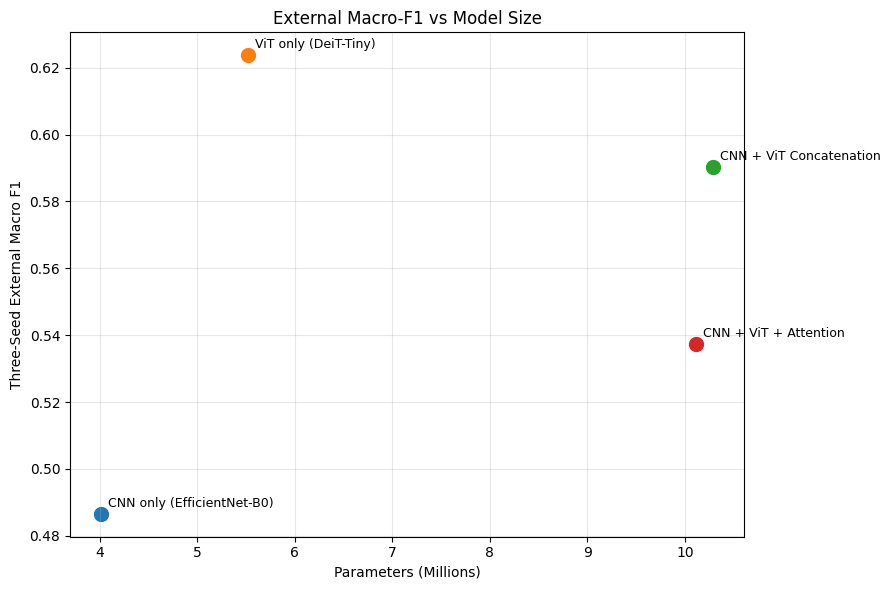

Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/final_figures/external_macro_f1_vs_parameters.png


In [16]:
# Cell 16: Final external performance vs efficiency figure
fig, axis = plt.subplots(
    figsize=(9, 6)
)

for _, row in master_final_df.iterrows():
    axis.scatter(
        row[
            'Parameters'
        ] / 1e6,
        row[
            'External Macro F1 Mean'
        ],
        s=100,
    )

    axis.annotate(
        row['Model'],
        (
            row[
                'Parameters'
            ] / 1e6,
            row[
                'External Macro F1 Mean'
            ],
        ),
        xytext=(5, 5),
        textcoords='offset points',
        fontsize=9,
    )

axis.set_title(
    'External Macro-F1 vs Model Size'
)

axis.set_xlabel(
    'Parameters (Millions)'
)

axis.set_ylabel(
    'Three-Seed External Macro F1'
)

axis.grid(
    alpha=0.3
)

plt.tight_layout()

performance_efficiency_figure_path = (
    FINAL_FIGURES_DIR
    / 'external_macro_f1_vs_parameters.png'
)

plt.savefig(
    performance_efficiency_figure_path,
    dpi=200,
    bbox_inches='tight',
)

plt.show()

print(
    'Saved:',
    performance_efficiency_figure_path,
)


In [17]:
# Cell 17: Export final table index
final_table_files = sorted(
    FINAL_TABLES_DIR.glob(
        'table_*.csv'
    )
)

final_table_index_df = pd.DataFrame([
    {
        'table_number':
            index + 1,

        'file_name':
            path.name,

        'path':
            str(path),
    }
    for index, path in enumerate(
        final_table_files
    )
])

final_table_index_path = (
    FINAL_TABLES_DIR
    / 'final_table_index.csv'
)

final_table_index_df.to_csv(
    final_table_index_path,
    index=False,
)

display(
    final_table_index_df
)

print(
    'Saved:',
    final_table_index_path,
)


,table_number,file_name,path
0,1,table_01_dataset_split_distribution.csv,/content/drive/MyDrive/Potato_CNN_ViT_Research...
1,2,table_02_internal_three_seed_results.csv,/content/drive/MyDrive/Potato_CNN_ViT_Research...
2,3,table_03_external_three_seed_results.csv,/content/drive/MyDrive/Potato_CNN_ViT_Research...
3,4,table_04_generalization_gap.csv,/content/drive/MyDrive/Potato_CNN_ViT_Research...
4,5,table_05_statistical_comparison.csv,/content/drive/MyDrive/Potato_CNN_ViT_Research...
5,6,table_06_ablation_study.csv,/content/drive/MyDrive/Potato_CNN_ViT_Research...
6,7,table_07_efficiency_comparison.csv,/content/drive/MyDrive/Potato_CNN_ViT_Research...
7,8,table_08_master_final_results.csv,/content/drive/MyDrive/Potato_CNN_ViT_Research...


Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/05_results/final_tables/final_table_index.csv


In [18]:
# Cell 18: Final report
required_paths = [
    efficiency_path,
    environment_path,
    dataset_split_path,
    internal_table_path,
    external_table_path,
    gap_table_path,
    statistical_table_path,
    final_ablation_path,
    efficiency_table_path,
    master_final_path,
    performance_efficiency_figure_path,
    final_table_index_path,
]

final_report_df = pd.DataFrame([
    {
        'check':
            'All four seed-42 checkpoints benchmarked',

        'passed':
            len(efficiency_df) == 4,
    },

    {
        'check':
            'Efficiency metrics saved',

        'passed':
            efficiency_path.exists(),
    },

    {
        'check':
            'Benchmark environment saved',

        'passed':
            environment_path.exists(),
    },

    {
        'check':
            'Dataset table saved',

        'passed':
            dataset_split_path.exists(),
    },

    {
        'check':
            'Internal three-seed table saved',

        'passed':
            internal_table_path.exists(),
    },

    {
        'check':
            'External three-seed table saved',

        'passed':
            external_table_path.exists(),
    },

    {
        'check':
            'Generalization-gap table saved',

        'passed':
            gap_table_path.exists(),
    },

    {
        'check':
            'Statistical table saved',

        'passed':
            statistical_table_path.exists(),
    },

    {
        'check':
            'Ablation table saved',

        'passed':
            final_ablation_path.exists(),
    },

    {
        'check':
            'Efficiency paper table saved',

        'passed':
            efficiency_table_path.exists(),
    },

    {
        'check':
            'Master final-result table saved',

        'passed':
            master_final_path.exists(),
    },
])

display(
    final_report_df
)

if final_report_df[
    'passed'
].all():
    print(
        '✅ Efficiency analysis and final tables '
        'completed successfully.'
    )

    print(
        'Next step: '
        '15_Final_Figures_and_Paper_Package.ipynb'
    )

else:
    print(
        '⚠️ Efficiency/final-table analysis '
        'completed with warnings.'
    )


,check,passed
0,All four seed-42 checkpoints benchmarked,True
1,Efficiency metrics saved,True
2,Benchmark environment saved,True
3,Dataset table saved,True
4,Internal three-seed table saved,True
5,External three-seed table saved,True
6,Generalization-gap table saved,True
7,Statistical table saved,True
8,Ablation table saved,True
9,Efficiency paper table saved,True


✅ Efficiency analysis and final tables completed successfully.
Next step: 15_Final_Figures_and_Paper_Package.ipynb


---

# Part 15 — 15. Final Figures and Paper Package

**Purpose:** Assemble paper-ready figures, result summaries, reproducibility notes, artifact indexes, and the final manuscript preparation package.

**Source notebook:** `15_Final_Figures_and_Paper_Package.ipynb`

**Preservation note:** The original code cells and their saved execution outputs are retained below. Textual headings/comments are lightly normalized into English where possible without changing experiment logic.


# 15 — Final Figures and Paper Package

This notebook আগের সব experiment/result থেকে **paper-ready final package** will create।

## This notebook will perform the following tasks

- Final tables verify ও copy করবে
- Important figures এক জায়গায় আনবে
- Internal বনাম External performance figure will create
- Final 3-seed model comparison figure will create
- Generalization-gap figure will create
- Efficiency-vs-performance figure reuse/copy করবে
- Grad-CAM এবং error-analysis figure index will create
- Paper-ready result highlights will create
- Reproducibility summary will create
- Final artifact manifest will create
- `06_paper/` folder-এর মধ্যে manuscript preparation package বানাবে

## Important

- কোনো model train করবে না
- will not rerun inference on the full dataset
- GPU দরকার নেই
- will use previously saved CSV/PNG/JSON outputs


In [1]:
# Cell 1: Mount Google Drive
from google.colab import drive

drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [2]:
# Cell 2: Imports
from pathlib import Path
from datetime import datetime
import json
import shutil
import textwrap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print('Ready.')


Ready.


In [3]:
# Cell 3: Locate project and create paper-package folders
MY_DRIVE = Path('/content/drive/MyDrive')

standard_project = (
    MY_DRIVE / 'Potato_CNN_ViT_Research'
)

if standard_project.is_dir():
    PROJECT_ROOT = standard_project
else:
    matches = [
        path
        for path in MY_DRIVE.rglob(
            'Potato_CNN_ViT_Research'
        )
        if path.is_dir()
    ]

    if not matches:
        raise FileNotFoundError(
            'Potato_CNN_ViT_Research folder My Drive-এ পাওয়া যায়নি।'
        )

    PROJECT_ROOT = matches[0]

RESULTS_ROOT = PROJECT_ROOT / '05_results'

METRICS_DIR = RESULTS_ROOT / 'metrics'
STATISTICS_DIR = RESULTS_ROOT / 'statistical_analysis'
ABLATION_DIR = RESULTS_ROOT / 'ablation'
EFFICIENCY_DIR = RESULTS_ROOT / 'efficiency'
FINAL_TABLES_DIR = RESULTS_ROOT / 'final_tables'
FINAL_FIGURES_DIR = RESULTS_ROOT / 'final_figures'
EXPLAINABILITY_DIR = RESULTS_ROOT / 'explainability'
ERROR_DIR = RESULTS_ROOT / 'error_analysis'

PAPER_ROOT = PROJECT_ROOT / '06_paper'
PAPER_TABLES_DIR = PAPER_ROOT / 'tables'
PAPER_FIGURES_DIR = PAPER_ROOT / 'figures'
PAPER_TEXT_DIR = PAPER_ROOT / 'text'
PAPER_METADATA_DIR = PAPER_ROOT / 'metadata'

for folder in [
    PAPER_ROOT,
    PAPER_TABLES_DIR,
    PAPER_FIGURES_DIR,
    PAPER_TEXT_DIR,
    PAPER_METADATA_DIR,
]:
    folder.mkdir(
        parents=True,
        exist_ok=True,
    )

print('PROJECT_ROOT:', PROJECT_ROOT)
print('PAPER_ROOT:', PAPER_ROOT)


PROJECT_ROOT: /content/drive/MyDrive/Potato_CNN_ViT_Research
PAPER_ROOT: /content/drive/MyDrive/Potato_CNN_ViT_Research/06_paper


In [4]:
# Cell 4: Verify final-table outputs from Notebook 14
required_table_names = [
    'table_01_dataset_split_distribution.csv',
    'table_02_internal_three_seed_results.csv',
    'table_03_external_three_seed_results.csv',
    'table_04_generalization_gap.csv',
    'table_05_statistical_comparison.csv',
    'table_06_ablation_study.csv',
    'table_07_efficiency_comparison.csv',
    'table_08_master_final_results.csv',
]

table_inventory_rows = []

for file_name in required_table_names:
    source = FINAL_TABLES_DIR / file_name

    table_inventory_rows.append({
        'file_name': file_name,
        'source_path': str(source),
        'exists': source.exists(),
    })

table_inventory_df = pd.DataFrame(
    table_inventory_rows
)

display(table_inventory_df)

if not table_inventory_df['exists'].all():
    missing = table_inventory_df[
        ~table_inventory_df['exists']
    ]

    display(missing)

    raise FileNotFoundError(
        'Notebook 14-এর কিছু final table missing।'
    )

print('✅ All required final tables found.')


,file_name,source_path,exists
0,table_01_dataset_split_distribution.csv,/content/drive/MyDrive/Potato_CNN_ViT_Research...,True
1,table_02_internal_three_seed_results.csv,/content/drive/MyDrive/Potato_CNN_ViT_Research...,True
2,table_03_external_three_seed_results.csv,/content/drive/MyDrive/Potato_CNN_ViT_Research...,True
3,table_04_generalization_gap.csv,/content/drive/MyDrive/Potato_CNN_ViT_Research...,True
4,table_05_statistical_comparison.csv,/content/drive/MyDrive/Potato_CNN_ViT_Research...,True
5,table_06_ablation_study.csv,/content/drive/MyDrive/Potato_CNN_ViT_Research...,True
6,table_07_efficiency_comparison.csv,/content/drive/MyDrive/Potato_CNN_ViT_Research...,True
7,table_08_master_final_results.csv,/content/drive/MyDrive/Potato_CNN_ViT_Research...,True


✅ All required final tables found.


In [5]:
# Cell 5: Copy final tables into paper package
paper_table_rows = []

for file_name in required_table_names:
    source = FINAL_TABLES_DIR / file_name
    destination = PAPER_TABLES_DIR / file_name

    shutil.copy2(
        source,
        destination,
    )

    frame = pd.read_csv(
        destination
    )

    paper_table_rows.append({
        'file_name': file_name,
        'rows': len(frame),
        'columns': len(frame.columns),
        'destination': str(destination),
    })

paper_table_inventory_df = pd.DataFrame(
    paper_table_rows
)

display(
    paper_table_inventory_df
)

print(
    '✅ Final tables copied to:',
    PAPER_TABLES_DIR,
)


,file_name,rows,columns,destination
0,table_01_dataset_split_distribution.csv,4,5,/content/drive/MyDrive/Potato_CNN_ViT_Research...
1,table_02_internal_three_seed_results.csv,4,5,/content/drive/MyDrive/Potato_CNN_ViT_Research...
2,table_03_external_three_seed_results.csv,4,5,/content/drive/MyDrive/Potato_CNN_ViT_Research...
3,table_04_generalization_gap.csv,4,7,/content/drive/MyDrive/Potato_CNN_ViT_Research...
4,table_05_statistical_comparison.csv,3,8,/content/drive/MyDrive/Potato_CNN_ViT_Research...
5,table_06_ablation_study.csv,4,13,/content/drive/MyDrive/Potato_CNN_ViT_Research...
6,table_07_efficiency_comparison.csv,4,10,/content/drive/MyDrive/Potato_CNN_ViT_Research...
7,table_08_master_final_results.csv,4,15,/content/drive/MyDrive/Potato_CNN_ViT_Research...


✅ Final tables copied to: /content/drive/MyDrive/Potato_CNN_ViT_Research/06_paper/tables


In [6]:
# Cell 6: Load master final results
MASTER_PATH = (
    FINAL_TABLES_DIR
    / 'table_08_master_final_results.csv'
)

master_df = pd.read_csv(
    MASTER_PATH
)

required_master_columns = {
    'Model',
    'Internal Accuracy Mean',
    'Internal Macro F1 Mean',
    'External Accuracy Mean',
    'External Macro F1 Mean',
    'Macro F1 Generalization Drop',
    'Parameters',
    'Weights Size MB',
}

missing_columns = (
    required_master_columns
    - set(master_df.columns)
)

if missing_columns:
    raise KeyError(
        f'Master table columns missing: '
        f'{sorted(missing_columns)}'
    )

display(
    master_df.round(4)
)


,Model,Internal Accuracy Mean,Internal Accuracy Std,Internal Macro F1 Mean,Internal Macro F1 Std,External Accuracy Mean,External Accuracy Std,External Macro F1 Mean,External Macro F1 Std,Macro F1 Generalization Drop,Parameters,Weights Size MB,Approx GFLOPs,Latency ms,Throughput images/s
0,CNN only (EfficientNet-B0),1.000,0.0000,1.0000,0.0000,0.4999,0.0378,0.4866,0.0506,0.5134,4011391,15.4629,0.4004,19.3976,51.5528
1,ViT only (DeiT-Tiny),1.000,0.0000,1.0000,0.0000,0.6352,0.0215,0.6238,0.0311,0.3762,5524995,21.0762,1.0794,5.5128,181.3961
2,CNN + ViT Concatenation,1.000,0.0000,1.0000,0.0000,0.6157,0.0799,0.5903,0.1264,0.4097,10290623,39.4163,1.4803,13.3020,75.1764
3,CNN + ViT + Attention,0.999,0.0018,0.9993,0.0013,0.5685,0.0578,0.5374,0.0838,0.4619,10109249,38.7244,1.4802,13.5879,73.5947


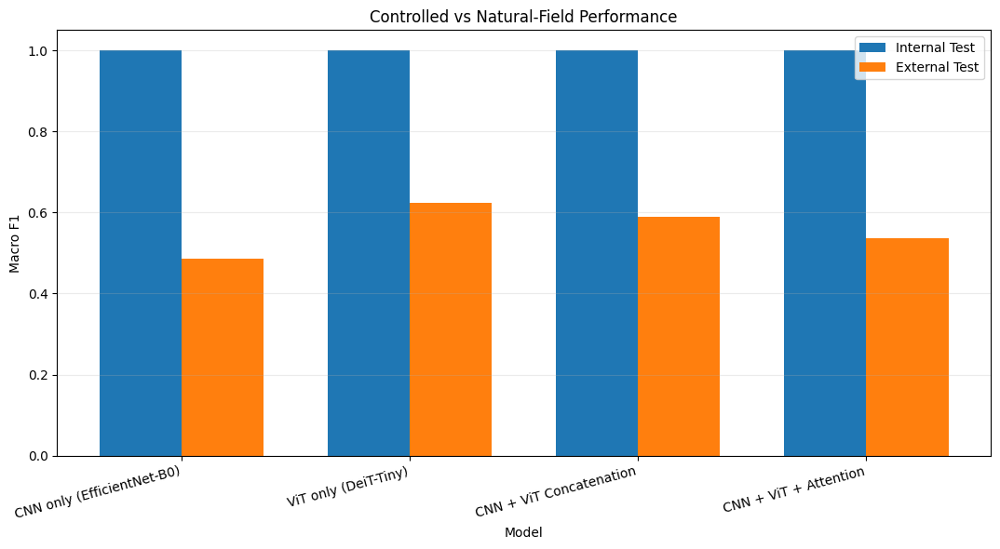

Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/06_paper/figures/figure_internal_vs_external_macro_f1.png


In [7]:
# Cell 7: Final internal vs external Macro-F1 figure
plot_df = master_df[
    [
        'Model',
        'Internal Macro F1 Mean',
        'External Macro F1 Mean',
    ]
].copy()

x = np.arange(
    len(plot_df)
)

width = 0.36

fig, axis = plt.subplots(
    figsize=(11, 6)
)

axis.bar(
    x - width / 2,
    plot_df[
        'Internal Macro F1 Mean'
    ],
    width,
    label='Internal Test',
)

axis.bar(
    x + width / 2,
    plot_df[
        'External Macro F1 Mean'
    ],
    width,
    label='External Test',
)

axis.set_xticks(x)
axis.set_xticklabels(
    plot_df['Model'],
    rotation=15,
    ha='right',
)

axis.set_ylim(
    0,
    1.05,
)

axis.set_ylabel(
    'Macro F1'
)

axis.set_xlabel(
    'Model'
)

axis.set_title(
    'Controlled vs Natural-Field Performance'
)

axis.legend()
axis.grid(
    axis='y',
    alpha=0.25,
)

plt.tight_layout()

internal_external_figure = (
    PAPER_FIGURES_DIR
    / 'figure_internal_vs_external_macro_f1.png'
)

plt.savefig(
    internal_external_figure,
    dpi=300,
    bbox_inches='tight',
)

plt.show()

print(
    'Saved:',
    internal_external_figure,
)


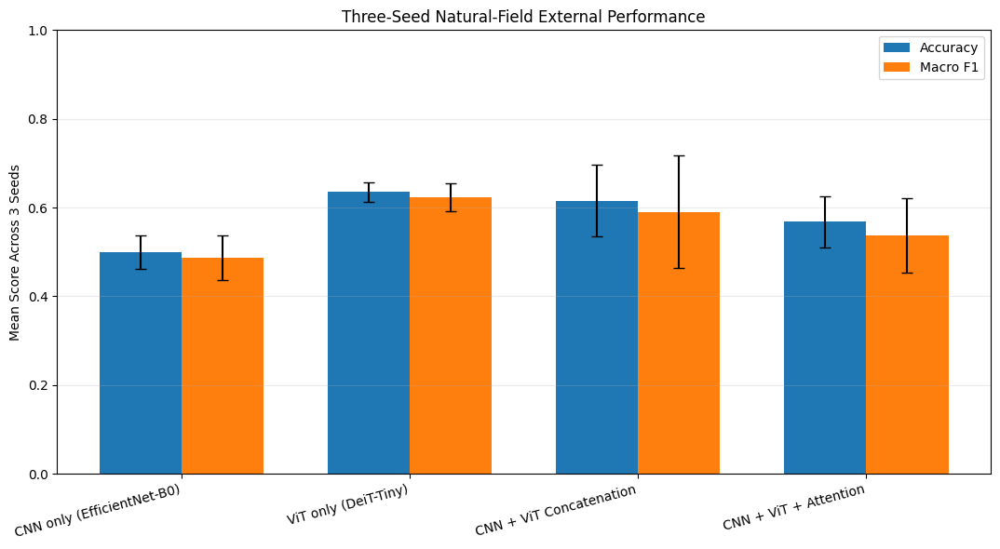

Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/06_paper/figures/figure_external_three_seed_performance.png


In [8]:
# Cell 8: Final external 3-seed comparison figure
external_result_path = (
    FINAL_TABLES_DIR
    / 'table_03_external_three_seed_results.csv'
)

external_results_df = pd.read_csv(
    external_result_path
)

numeric_external = master_df[
    [
        'Model',
        'External Accuracy Mean',
        'External Accuracy Std',
        'External Macro F1 Mean',
        'External Macro F1 Std',
    ]
].copy()

x = np.arange(
    len(numeric_external)
)

width = 0.36

fig, axis = plt.subplots(
    figsize=(11, 6)
)

axis.bar(
    x - width / 2,
    numeric_external[
        'External Accuracy Mean'
    ],
    width,
    yerr=numeric_external[
        'External Accuracy Std'
    ],
    capsize=4,
    label='Accuracy',
)

axis.bar(
    x + width / 2,
    numeric_external[
        'External Macro F1 Mean'
    ],
    width,
    yerr=numeric_external[
        'External Macro F1 Std'
    ],
    capsize=4,
    label='Macro F1',
)

axis.set_xticks(x)
axis.set_xticklabels(
    numeric_external['Model'],
    rotation=15,
    ha='right',
)

axis.set_ylim(
    0,
    1.0,
)

axis.set_ylabel(
    'Mean Score Across 3 Seeds'
)

axis.set_title(
    'Three-Seed Natural-Field External Performance'
)

axis.legend()
axis.grid(
    axis='y',
    alpha=0.25,
)

plt.tight_layout()

external_figure = (
    PAPER_FIGURES_DIR
    / 'figure_external_three_seed_performance.png'
)

plt.savefig(
    external_figure,
    dpi=300,
    bbox_inches='tight',
)

plt.show()

print(
    'Saved:',
    external_figure,
)


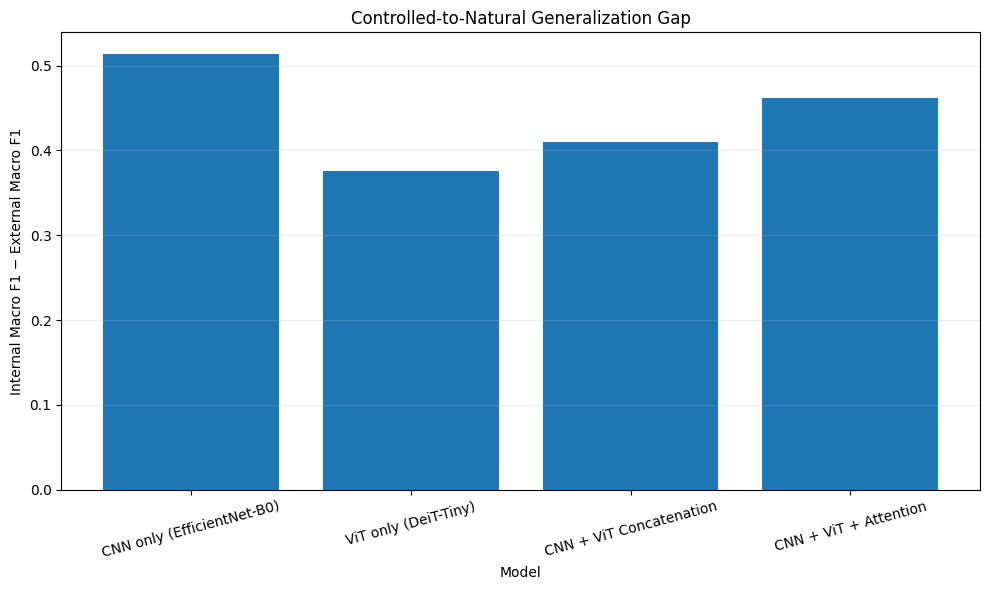

Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/06_paper/figures/figure_generalization_gap.png


In [9]:
# Cell 9: Generalization-gap figure
gap_df = master_df[
    [
        'Model',
        'Macro F1 Generalization Drop',
    ]
].copy()

fig, axis = plt.subplots(
    figsize=(10, 6)
)

axis.bar(
    gap_df['Model'],
    gap_df[
        'Macro F1 Generalization Drop'
    ],
)

axis.set_ylabel(
    'Internal Macro F1 − External Macro F1'
)

axis.set_xlabel(
    'Model'
)

axis.set_title(
    'Controlled-to-Natural Generalization Gap'
)

axis.tick_params(
    axis='x',
    rotation=15,
)

axis.grid(
    axis='y',
    alpha=0.25,
)

plt.tight_layout()

gap_figure = (
    PAPER_FIGURES_DIR
    / 'figure_generalization_gap.png'
)

plt.savefig(
    gap_figure,
    dpi=300,
    bbox_inches='tight',
)

plt.show()

print(
    'Saved:',
    gap_figure,
)


In [10]:
# Cell 10: Copy important existing research figures
candidate_figures = [
    (
        FINAL_FIGURES_DIR
        / 'external_macro_f1_vs_parameters.png',
        'figure_efficiency_vs_performance.png',
    ),

    (
        ABLATION_DIR
        / 'external_macro_f1_ablation.png',
        'figure_ablation_external_macro_f1.png',
    ),

    (
        ABLATION_DIR
        / 'macro_f1_generalization_drop.png',
        'figure_ablation_generalization_drop.png',
    ),

    (
        STATISTICS_DIR
        / 'external_macro_f1_difference.png',
        'figure_statistical_macro_f1_difference.png',
    ),

    (
        ERROR_DIR
        / 'figures'
        / 'proposed_classwise_error_rate.png',
        'figure_proposed_classwise_error_rate.png',
    ),

    (
        ERROR_DIR
        / 'figures'
        / 'proposed_representative_misclassifications.png',
        'figure_representative_misclassifications.png',
    ),
]

copied_figure_rows = []

for source, destination_name in candidate_figures:
    destination = (
        PAPER_FIGURES_DIR
        / destination_name
    )

    copied = False

    if source.exists():
        shutil.copy2(
            source,
            destination,
        )

        copied = True

    copied_figure_rows.append({
        'source': str(source),
        'destination': str(destination),
        'copied': copied,
    })

copied_figure_df = pd.DataFrame(
    copied_figure_rows
)

display(
    copied_figure_df
)


,source,destination,copied
0,/content/drive/MyDrive/Potato_CNN_ViT_Research...,/content/drive/MyDrive/Potato_CNN_ViT_Research...,True
1,/content/drive/MyDrive/Potato_CNN_ViT_Research...,/content/drive/MyDrive/Potato_CNN_ViT_Research...,True
2,/content/drive/MyDrive/Potato_CNN_ViT_Research...,/content/drive/MyDrive/Potato_CNN_ViT_Research...,True
3,/content/drive/MyDrive/Potato_CNN_ViT_Research...,/content/drive/MyDrive/Potato_CNN_ViT_Research...,True
4,/content/drive/MyDrive/Potato_CNN_ViT_Research...,/content/drive/MyDrive/Potato_CNN_ViT_Research...,True
5,/content/drive/MyDrive/Potato_CNN_ViT_Research...,/content/drive/MyDrive/Potato_CNN_ViT_Research...,True


In [11]:
# Cell 11: Copy Grad-CAM examples into paper package
GRADCAM_SOURCE_DIR = (
    EXPLAINABILITY_DIR
    / 'gradcam'
)

gradcam_files = sorted(
    GRADCAM_SOURCE_DIR.glob(
        'seed42_sample*.png'
    )
)

gradcam_copy_rows = []

for index, source in enumerate(
    gradcam_files,
    start=1,
):
    destination = (
        PAPER_FIGURES_DIR
        / f'figure_gradcam_{index:02d}.png'
    )

    shutil.copy2(
        source,
        destination,
    )

    gradcam_copy_rows.append({
        'source': str(source),
        'destination': str(destination),
    })

gradcam_copy_df = pd.DataFrame(
    gradcam_copy_rows
)

display(
    gradcam_copy_df
)

print(
    'Grad-CAM figures copied:',
    len(gradcam_copy_df),
)


,source,destination
0,/content/drive/MyDrive/Potato_CNN_ViT_Research...,/content/drive/MyDrive/Potato_CNN_ViT_Research...
1,/content/drive/MyDrive/Potato_CNN_ViT_Research...,/content/drive/MyDrive/Potato_CNN_ViT_Research...
2,/content/drive/MyDrive/Potato_CNN_ViT_Research...,/content/drive/MyDrive/Potato_CNN_ViT_Research...
3,/content/drive/MyDrive/Potato_CNN_ViT_Research...,/content/drive/MyDrive/Potato_CNN_ViT_Research...
4,/content/drive/MyDrive/Potato_CNN_ViT_Research...,/content/drive/MyDrive/Potato_CNN_ViT_Research...
5,/content/drive/MyDrive/Potato_CNN_ViT_Research...,/content/drive/MyDrive/Potato_CNN_ViT_Research...


Grad-CAM figures copied: 6


In [12]:
# Cell 12: Identify best external model and proposed-model position
best_external_row = master_df.loc[
    master_df[
        'External Macro F1 Mean'
    ].idxmax()
]

proposed_rows = master_df[
    master_df[
        'Model'
    ].astype(str).str.contains(
        'Attention',
        case=False,
        na=False,
    )
]

if proposed_rows.empty:
    raise ValueError(
        'Proposed attention-model row master table-এ পাওয়া যায়নি।'
    )

proposed_row = proposed_rows.iloc[0]

ranked_df = (
    master_df.sort_values(
        'External Macro F1 Mean',
        ascending=False,
    )
    .reset_index(drop=True)
)

ranked_df[
    'External Macro F1 Rank'
] = np.arange(
    1,
    len(ranked_df) + 1,
)

proposed_rank = int(
    ranked_df.loc[
        ranked_df[
            'Model'
        ] == proposed_row[
            'Model'
        ],
        'External Macro F1 Rank',
    ].iloc[0]
)

display(
    ranked_df[
        [
            'External Macro F1 Rank',
            'Model',
            'External Macro F1 Mean',
            'External Macro F1 Std',
            'External Accuracy Mean',
        ]
    ].round(4)
)

print(
    'Best external model:',
    best_external_row['Model'],
)

print(
    'Proposed model rank:',
    proposed_rank,
    '/',
    len(ranked_df),
)


,External Macro F1 Rank,Model,External Macro F1 Mean,External Macro F1 Std,External Accuracy Mean
0,1,ViT only (DeiT-Tiny),0.6238,0.0311,0.6352
1,2,CNN + ViT Concatenation,0.5903,0.1264,0.6157
2,3,CNN + ViT + Attention,0.5374,0.0838,0.5685
3,4,CNN only (EfficientNet-B0),0.4866,0.0506,0.4999


Best external model: ViT only (DeiT-Tiny)
Proposed model rank: 3 / 4


In [13]:
# Cell 13: Create objective paper-result highlights
highlights = []

highlights.append(
    (
        'All four architectures achieved '
        f'internal-test Macro-F1 values ranging from '
        f'{master_df["Internal Macro F1 Mean"].min():.4f} '
        f'to {master_df["Internal Macro F1 Mean"].max():.4f} '
        'across the three-seed evaluation.'
    )
)

highlights.append(
    (
        'On the natural-field external dataset, the '
        f'highest three-seed mean Macro-F1 was '
        f'{best_external_row["External Macro F1 Mean"]:.4f} '
        f'± {best_external_row["External Macro F1 Std"]:.4f}, '
        f'achieved by {best_external_row["Model"]}.'
    )
)

highlights.append(
    (
        'The proposed attention-guided model obtained an '
        f'external Macro-F1 of '
        f'{proposed_row["External Macro F1 Mean"]:.4f} '
        f'± {proposed_row["External Macro F1 Std"]:.4f} '
        f'and ranked {proposed_rank} of {len(ranked_df)} '
        'among the evaluated architectures.'
    )
)

highlights.append(
    (
        'The proposed model showed a controlled-to-natural '
        f'Macro-F1 drop of '
        f'{proposed_row["Macro F1 Generalization Drop"]:.4f}.'
    )
)

highlights.append(
    (
        'The final interpretation must therefore distinguish '
        'high controlled-environment performance from '
        'cross-environment generalization.'
    )
)

result_highlights_text = (
    '# Result Highlights\n\n'
    + '\n\n'.join(
        f'- {item}'
        for item in highlights
    )
)

result_highlights_path = (
    PAPER_TEXT_DIR
    / 'result_highlights.md'
)

result_highlights_path.write_text(
    result_highlights_text,
    encoding='utf-8',
)

print(result_highlights_text)
print(
    '\nSaved:',
    result_highlights_path,
)


# Result Highlights

- All four architectures achieved internal-test Macro-F1 values ranging from 0.9993 to 1.0000 across the three-seed evaluation.

- On the natural-field external dataset, the highest three-seed mean Macro-F1 was 0.6238 ± 0.0311, achieved by ViT only (DeiT-Tiny).

- The proposed attention-guided model obtained an external Macro-F1 of 0.5374 ± 0.0838 and ranked 3 of 4 among the evaluated architectures.

- The proposed model showed a controlled-to-natural Macro-F1 drop of 0.4619.

- The final interpretation must therefore distinguish high controlled-environment performance from cross-environment generalization.

Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/06_paper/text/result_highlights.md


In [14]:
# Cell 14: Create paper-ready Results-section starter
results_section = f'''
# Results Section Starter

## Controlled-environment performance

Across the three random seeds (42, 123, and 2026), all four architectures achieved very high performance on the PlantVillage internal test set. The internal-test results should be reported using the mean ± standard deviation values in `table_02_internal_three_seed_results.csv`.

## Natural-field external performance

Cross-dataset testing on PLDD-UP produced a substantial reduction in performance relative to the controlled PlantVillage test set. The strongest external Macro-F1 was achieved by **{best_external_row["Model"]}**, with a three-seed mean Macro-F1 of **{best_external_row["External Macro F1 Mean"]:.4f} ± {best_external_row["External Macro F1 Std"]:.4f}**.

The proposed attention-guided CNN–ViT model obtained an external Macro-F1 of **{proposed_row["External Macro F1 Mean"]:.4f} ± {proposed_row["External Macro F1 Std"]:.4f}** and an external accuracy of **{proposed_row["External Accuracy Mean"]:.4f} ± {proposed_row["External Accuracy Std"]:.4f}**.

## Generalization gap

The proposed model exhibited a controlled-to-natural Macro-F1 decrease of **{proposed_row["Macro F1 Generalization Drop"]:.4f}**. This confirms that performance measured on controlled-background datasets cannot be assumed to transfer directly to field imagery.

## Architectural comparison

The architecture comparison includes CNN-only, ViT-only, simple CNN–ViT concatenation, and attention-guided CNN–ViT fusion. The final paper should use `table_06_ablation_study.csv` to describe whether the learnable attention gate improved or reduced external performance relative to simple concatenation.

## Statistical analysis

McNemar testing and paired bootstrap confidence intervals were computed from matched saved predictions. The final significance claims must be taken directly from `table_05_statistical_comparison.csv` and must not be inferred only from mean-score differences.

## Explainability and error analysis

Grad-CAM visualizations were generated from the CNN branch of the proposed model, together with learned CNN/ViT branch-attention weights. Error analysis includes class-wise error rates, frequent confusion pairs, high-confidence mistakes, and representative external misclassifications.

'''

results_section_path = (
    PAPER_TEXT_DIR
    / 'results_section_starter.md'
)

results_section_path.write_text(
    textwrap.dedent(
        results_section
    ).strip()
    + '\n',
    encoding='utf-8',
)

print(
    'Saved:',
    results_section_path,
)


Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/06_paper/text/results_section_starter.md


In [15]:
# Cell 15: Create reproducibility summary
benchmark_environment_path = (
    EFFICIENCY_DIR
    / 'benchmark_environment.json'
)

benchmark_environment = {}

if benchmark_environment_path.exists():
    benchmark_environment = json.loads(
        benchmark_environment_path.read_text(
            encoding='utf-8'
        )
    )

reproducibility = {
    'project_title':
        (
            'An Attention-Guided Lightweight CNN–ViT '
            'Fusion Network for Potato Leaf Disease '
            'Classification Across Controlled and '
            'Natural Environments'
        ),

    'training_dataset':
        'PlantVillage potato subset',

    'external_dataset':
        'PLDD-UP natural-field potato dataset',

    'classes':
        [
            'Early_Blight',
            'Late_Blight',
            'Healthy',
        ],

    'training_seeds':
        [
            42,
            123,
            2026,
        ],

    'external_data_used_for_training_or_tuning':
        False,

    'models':
        [
            'EfficientNet-B0',
            'DeiT-Tiny',
            'CNN–ViT simple concatenation',
            'Attention-guided CNN–ViT',
        ],

    'evaluation_reporting':
        'three-seed mean ± standard deviation',

    'statistical_tests':
        [
            'Exact McNemar test',
            'Paired bootstrap confidence interval',
        ],

    'explainability':
        [
            'CNN-branch Grad-CAM',
            'CNN/ViT learned branch-attention weights',
        ],

    'benchmark_environment':
        benchmark_environment,
}

reproducibility_path = (
    PAPER_METADATA_DIR
    / 'reproducibility_summary.json'
)

reproducibility_path.write_text(
    json.dumps(
        reproducibility,
        indent=2,
        ensure_ascii=False,
    ),
    encoding='utf-8',
)

print(
    'Saved:',
    reproducibility_path,
)


Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/06_paper/metadata/reproducibility_summary.json


In [16]:
# Cell 16: Create figure and table manifest
paper_table_files = sorted(
    PAPER_TABLES_DIR.glob(
        '*'
    )
)

paper_figure_files = sorted(
    PAPER_FIGURES_DIR.glob(
        '*'
    )
)

manifest_rows = []

for path in paper_table_files:
    manifest_rows.append({
        'artifact_type':
            'table',

        'file_name':
            path.name,

        'path':
            str(path),
    })

for path in paper_figure_files:
    manifest_rows.append({
        'artifact_type':
            'figure',

        'file_name':
            path.name,

        'path':
            str(path),
    })

paper_manifest_df = pd.DataFrame(
    manifest_rows
)

paper_manifest_path = (
    PAPER_METADATA_DIR
    / 'paper_artifact_manifest.csv'
)

paper_manifest_df.to_csv(
    paper_manifest_path,
    index=False,
)

display(
    paper_manifest_df
)

print(
    'Saved:',
    paper_manifest_path,
)


,artifact_type,file_name,path
0,table,table_01_dataset_split_distribution.csv,/content/drive/MyDrive/Potato_CNN_ViT_Research...
1,table,table_02_internal_three_seed_results.csv,/content/drive/MyDrive/Potato_CNN_ViT_Research...
2,table,table_03_external_three_seed_results.csv,/content/drive/MyDrive/Potato_CNN_ViT_Research...
3,table,table_04_generalization_gap.csv,/content/drive/MyDrive/Potato_CNN_ViT_Research...
4,table,table_05_statistical_comparison.csv,/content/drive/MyDrive/Potato_CNN_ViT_Research...
5,table,table_06_ablation_study.csv,/content/drive/MyDrive/Potato_CNN_ViT_Research...
6,table,table_07_efficiency_comparison.csv,/content/drive/MyDrive/Potato_CNN_ViT_Research...
7,table,table_08_master_final_results.csv,/content/drive/MyDrive/Potato_CNN_ViT_Research...
8,figure,figure_ablation_external_macro_f1.png,/content/drive/MyDrive/Potato_CNN_ViT_Research...
9,figure,figure_ablation_generalization_drop.png,/content/drive/MyDrive/Potato_CNN_ViT_Research...


Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/06_paper/metadata/paper_artifact_manifest.csv


In [17]:
# Cell 17: Create final paper-package README
readme_text = f'''
# Potato CNN–ViT Research — Paper Package

Generated: {datetime.now().isoformat()}

## Folder structure

- `tables/` — final paper-ready CSV tables
- `figures/` — final plots, Grad-CAM, ablation and error-analysis figures
- `text/` — result highlights and Results-section starter
- `metadata/` — reproducibility summary and artifact manifest

## Main reporting files

1. `tables/table_01_dataset_split_distribution.csv`
2. `tables/table_02_internal_three_seed_results.csv`
3. `tables/table_03_external_three_seed_results.csv`
4. `tables/table_04_generalization_gap.csv`
5. `tables/table_05_statistical_comparison.csv`
6. `tables/table_06_ablation_study.csv`
7. `tables/table_07_efficiency_comparison.csv`
8. `tables/table_08_master_final_results.csv`

## Important scientific rule

Report the observed results exactly as produced.

If the proposed attention-guided model is not the strongest external model,
do not describe it as outperforming the baselines. Instead discuss what the
ablation, statistical analysis, generalization gap, explainability, and error
analysis show.

## Next stage

Use this package to write the full manuscript:
Abstract → Introduction → Related Work → Methods → Experiments → Results →
Discussion → Limitations → Conclusion → References.
'''

readme_path = (
    PAPER_ROOT
    / 'README.md'
)

readme_path.write_text(
    textwrap.dedent(
        readme_text
    ).strip()
    + '\n',
    encoding='utf-8',
)

print(
    'Saved:',
    readme_path,
)


Saved: /content/drive/MyDrive/Potato_CNN_ViT_Research/06_paper/README.md


In [18]:
# Cell 18: Final validation
final_report_df = pd.DataFrame([
    {
        'check':
            'All 8 final tables copied',

        'passed':
            len(
                list(
                    PAPER_TABLES_DIR.glob(
                        'table_*.csv'
                    )
                )
            ) >= 8,
    },

    {
        'check':
            'Internal-vs-external figure saved',

        'passed':
            internal_external_figure.exists(),
    },

    {
        'check':
            'External three-seed figure saved',

        'passed':
            external_figure.exists(),
    },

    {
        'check':
            'Generalization-gap figure saved',

        'passed':
            gap_figure.exists(),
    },

    {
        'check':
            'Result highlights saved',

        'passed':
            result_highlights_path.exists(),
    },

    {
        'check':
            'Results-section starter saved',

        'passed':
            results_section_path.exists(),
    },

    {
        'check':
            'Reproducibility summary saved',

        'passed':
            reproducibility_path.exists(),
    },

    {
        'check':
            'Paper artifact manifest saved',

        'passed':
            paper_manifest_path.exists(),
    },

    {
        'check':
            'Paper-package README saved',

        'passed':
            readme_path.exists(),
    },
])

display(
    final_report_df
)

if final_report_df[
    'passed'
].all():
    print(
        '✅ Final figures and paper package '
        'completed successfully.'
    )

    print(
        'Research experiment pipeline is complete.'
    )

    print(
        'Next step: Full manuscript writing '
        'and final research-paper preparation.'
    )

else:
    print(
        '⚠️ Final paper package completed '
        'with warnings.'
    )


,check,passed
0,All 8 final tables copied,True
1,Internal-vs-external figure saved,True
2,External three-seed figure saved,True
3,Generalization-gap figure saved,True
4,Result highlights saved,True
5,Results-section starter saved,True
6,Reproducibility summary saved,True
7,Paper artifact manifest saved,True
8,Paper-package README saved,True


✅ Final figures and paper package completed successfully.
Research experiment pipeline is complete.
Next step: Full manuscript writing and final research-paper preparation.
